# Filipino Audio Archive Search
## How do transcription errors affect what we find?

**Engineering preview · Candidate · DIMER composed-systems capstone**

**Standard:** DIMER NOTEBOOK_SPEC 2.2 · **Profile:** `E2E` · **Mode:** `GUIDED` · **Carrier:** standalone.

**Input → System → Output:** Filipino read-speech recordings → Whisper transcripts → lexical or Qwen3 search → ranked, playable recordings with visible evidence.

You will measure transcription errors, compare six search conditions, trace failures through the pipeline, change one development-only setting and export a reproducible search artifact. Basic Python and Colab familiarity is enough; no prior ML experience is assumed.

**Evidence boundary:** the 60 queries are AI-authored drafts. All 7,200 relevance cells are unjudged, including nominated anchors. Default results are **anchor-recovery engineering diagnostics**, not Recall@5, MRR or nDCG benchmark results. Human review and a fresh hosted run are required before qualification. Completion/reflection notes are optional, not required submissions.

Use a **fresh Colab T4** and **Runtime → Run all**. No secret, login, paid API or repository clone is needed. Resource targets are 60 minutes, 20 GiB free disk and ≤12 GiB peak allocated GPU memory; these are unverified targets, not measured guarantees.


### 1. Orient and predict

A transcript can contain many errors yet preserve the key concept. One wrong name can also make a mostly correct transcript hard to find. **Predict:** which matters more for your search query—overall transcription accuracy or preservation of its useful evidence?

| Method | Reference transcripts | Whisper transcripts |
|---|---|---|
| BM25 keyword matching | R-BM25 | A-BM25 |
| Qwen3 cosine similarity | R-Dense | A-Dense |
| Dense top 10 → Qwen3 reranking | R-Rerank | A-Rerank |

All six conditions use the same 120 document IDs and 60 queries. The 40 development and 80 evaluation recordings contribute 20 and 40 query anchors respectively. All recordings are searchable distractors in both roles. Reference text is an oracle **input condition**, not a guaranteed performance ceiling.

The pinned models are [Whisper large-v3-turbo](https://huggingface.co/openai/whisper-large-v3-turbo), [Qwen3 Embedding 0.6B](https://huggingface.co/Qwen/Qwen3-Embedding-0.6B) and [Qwen3 Reranker 0.6B](https://huggingface.co/Qwen/Qwen3-Reranker-0.6B). Immutable revisions and file hashes are carried in `model_manifest.json`. **No fine-tuning occurs:** you construct and evaluate a search system around frozen pretrained models.

Data: [Google FLEURS](https://huggingface.co/datasets/google/fleurs), `fil_ph`, CC BY 4.0; [Conneau et al. (2022)](https://arxiv.org/abs/2205.12446). Read speech does not establish performance on meetings, regional accents or noisy archives. Sentence families are not verified speaker identities; source/pretraining overlap is unknown.


### 2. Infrastructure — prepare an isolated environment

The next cells verify the target runtime, materialize embedded source and hash-bound manifests, and install a locked Python environment. The second cell carries several hundred thousand characters of embedded source and data, so it starts collapsed: select **Show code** (Colab) or the collapsed-input bar (Jupyter) to inspect it. Models run in sequential subprocesses to release GPU memory. A failure is visible and stops execution; do not skip failed cells or accept incomplete output as a successful run.


In [1]:
from pathlib import Path
import os, sys, json, hashlib, platform, shutil, subprocess, zipfile, urllib.request
from IPython.display import display, Markdown, Audio, Image, HTML

ROOT = Path('/content/dimer_fil_audio_preview')
assert platform.system() == 'Linux', 'Use a fresh hosted Colab T4 runtime.'
assert shutil.disk_usage('/').free >= 20 * 1024**3, 'At least 20 GiB free disk required.'
gpu = subprocess.check_output(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], text=True)
assert 'T4' in gpu, f'This candidate targets a Colab T4; found {gpu.strip()}'
ROOT.mkdir(parents=True, exist_ok=True)
print('GPU:', gpu.strip())
print('Engineering preview: human relevance review is pending. No benchmark-quality claim.')


GPU: Tesla T4
Engineering preview: human relevance review is pending. No benchmark-quality claim.


In [2]:
# @title Infrastructure: embedded source, manifests and locked install (expand to inspect)
# Embedded, inspectable source and manifests; no remote DIMER code import.
FILES = {'audio_runtime.py': '"""Standalone Filipino audio archive experiment and safe search artifacts."""\n\nfrom __future__ import annotations\n\nimport argparse\nimport csv\nimport hashlib\nimport json\nimport os\nimport time\nimport zipfile\nfrom pathlib import Path\n\nimport numpy as np\n\nimport audio_core as core\nimport audio_data as data\nimport audio_models as models\n\nSTAGES = ("prepare", "asr", "index", "evaluate", "activity", "reload", "report")\nSYSTEMS = tuple(\n    f"{condition}_{method}" for condition in ("reference", "asr") for method in ("bm25", "dense", "rerank")\n)\nPORTABLE_EXTRA = (\n    "audio_core.py",\n    "audio_models.py",\n    "search_archive.py",\n    "requirements.txt",\n    "RECONSTRUCT.md",\n)\nPACKAGE_FILES = frozenset(\n    {\n        "asr_index_documents.json",\n        "asr_embeddings.npy",\n        "lexical_statistics.json",\n        "model_manifest.json",\n        "DATA_LICENSE.md",\n        "audio_acquisition.json",\n        "asr_settings.json",\n        *PORTABLE_EXTRA,\n    }\n)\nSEARCH_HELPER = \'\'\'"""Search the exported automatic-transcript archive; no evaluation files required."""\nimport argparse, hashlib, json\nfrom pathlib import Path\nimport numpy as np\nimport audio_core as core\nimport audio_models as models\n\ndef run(root, query):\n    manifest=json.loads((root/\'index_manifest.json\').read_text())\n    if manifest[\'format\']!=\'dimer_audio_archive\' or manifest[\'version\']!=1:\n        raise ValueError(\'Unknown index version\')\n    for name, expected in manifest[\'files\'].items():\n        if Path(name).name!=name or hashlib.sha256((root/name).read_bytes()).hexdigest()!=expected:\n            raise ValueError(\'Archive integrity failure: \'+name)\n    model_hash=hashlib.sha256((root/\'model_manifest.json\').read_bytes()).hexdigest()\n    if model_hash!=manifest[\'model_manifest_sha256\']:\n        raise ValueError(\'Model identity changed\')\n    if models.SETTINGS!=manifest[\'model_settings\']:\n        raise ValueError(\'Inference settings changed\')\n    docs=json.loads((root/\'asr_index_documents.json\').read_text())\n    ids=[d[\'doc_id\'] for d in docs]\n    vectors=np.load(root/\'asr_embeddings.npy\',allow_pickle=False)\n    if ids!=manifest[\'doc_ids\'] or vectors.shape!=(len(ids),manifest[\'dimension\']):\n        raise ValueError(\'Index order/shape mismatch\')\n    audio={a[\'doc_id\']:a for a in manifest[\'audio\']}\n    if list(audio)!=ids:\n        raise ValueError(\'Audio identity/order mismatch\')\n    model=models.load_model(\'embedding\',root)\n    try: vector=models.embed(model,[query],query=True)[0]\n    finally: models.unload(model)\n    chosen=core.dense_rank(ids,vectors,vector)[:10]\n    texts={d[\'doc_id\']:d[\'text\'] for d in docs}\n    model=models.load_model(\'reranker\',root)\n    try: scores=models.rerank(model,query,[texts[d[\'doc_id\']] for d in chosen])\n    finally: models.unload(model)\n    ranked=core.rank_scores([d[\'doc_id\'] for d in chosen],scores)[:5]\n    return [{**d,\'transcript\':texts[d[\'doc_id\']],\'audio_path\':audio[d[\'doc_id\']][\'path\'],\n             \'audio_sha256\':audio[d[\'doc_id\']][\'sha256\']} for d in ranked]\n\nif __name__==\'__main__\':\n    parser=argparse.ArgumentParser();parser.add_argument(\'--root\',type=Path,default=Path(__file__).parent)\n    parser.add_argument(\'--query\',required=True);args=parser.parse_args()\n    print(json.dumps(run(args.root,args.query),ensure_ascii=False,indent=2))\n\'\'\'\n\n\ndef read(path):\n    return json.loads(Path(path).read_text(encoding="utf-8"))\n\n\ndef write(path, value):\n    Path(path).parent.mkdir(parents=True, exist_ok=True)\n    Path(path).write_text(\n        json.dumps(value, indent=2, ensure_ascii=False, allow_nan=False), encoding="utf-8", newline="\\n"\n    )\n\n\ndef sha(path):\n    return hashlib.sha256(Path(path).read_bytes()).hexdigest()\n\n\ndef digest(value):\n    return hashlib.sha256(\n        json.dumps(value, sort_keys=True, ensure_ascii=False, allow_nan=False).encode()\n    ).hexdigest()\n\n\ndef out(root):\n    return root / "results"\n\n\ndef table(path, rows):\n    if not rows:\n        raise ValueError("Cannot export empty table: " + str(path))\n    with Path(path).open("w", encoding="utf-8", newline="") as handle:\n        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))\n        writer.writeheader()\n        writer.writerows(rows)\n\n\ndef identity(root):\n    files = [\n        "source.json",\n        "sample_manifest.json",\n        "queries.json",\n        "qrels.json",\n        "annotation_manifest.json",\n        "model_manifest.json",\n    ]\n    hashes = {name: sha(root / name) for name in files}\n    for name, checksum in read(root / "source.json").get("files", {}).items():\n        if Path(name).name != name or sha(root / name) != checksum:\n            raise ValueError("Embedded source changed: " + name)\n    for module in (core, data, models):\n        hashes[Path(module.__file__).name] = sha(module.__file__)\n    hashes["runtime"] = sha(__file__)\n    return digest(hashes)\n\n\ndef corpus(root):\n    rows = read(out(root) / "corpus.json")\n    if len({r["doc_id"] for r in rows}) != len(rows):\n        raise ValueError("Duplicate document ID")\n    return rows\n\n\ndef waves(root, records):\n    import soundfile as sf\n\n    audio = []\n    for row in records:\n        path = (root / row["path"]).resolve()\n        if not path.is_relative_to(root.resolve()) or sha(path) != row["sha256"]:\n            raise ValueError("Audio path/hash mismatch")\n        signal, rate = sf.read(path, dtype="float32")\n        if signal.ndim != 1 or rate != 16000 or not 2 <= len(signal) / rate <= 25:\n            raise ValueError("Unsupported audio duration/rate/channels")\n        if not np.isfinite(signal).all() or not np.any(signal):\n            raise ValueError("Nonfinite or silent audio")\n        audio.append(signal)\n    return audio\n\n\ndef annotations(root):\n    docs = corpus(root)\n    queries = read(root / "queries.json")\n    qrels = read(root / "qrels.json")\n    manifest = read(root / "annotation_manifest.json")\n    ids = {d["doc_id"] for d in docs}\n    qids = {q["query_id"] for q in queries}\n    if len(qids) != len(queries) or len(queries) != 60:\n        raise ValueError("Expected 60 unique queries")\n    if sum(q["role"] == "dev" for q in queries) != 20 or sum(q["role"] == "test" for q in queries) != 40:\n        raise ValueError("Expected 20 development and 40 evaluation queries")\n    if len(qrels) != len(ids) * len(qids) or {(r["query_id"], r["doc_id"]) for r in qrels} != {\n        (q, d) for q in qids for d in ids\n    }:\n        raise ValueError("Missing/duplicated annotation matrix cells")\n    for q in queries:\n        if not q["text"].strip() or q["anchor_doc_id"] not in ids or q["role"] not in ("dev", "test"):\n            raise ValueError("Invalid query or anchor")\n        doc = next(d for d in docs if d["doc_id"] == q["anchor_doc_id"])\n        if doc["role"] != q["role"]:\n            raise ValueError("Query role crosses corpus role")\n        if q.get("target_family_id") != doc["family_id"] or q.get("group_id") != doc["family_id"]:\n            raise ValueError("Query anchor and bootstrap family differ")\n    roles = {"dev": "development", "test": "evaluation"}\n    validation = core.validate_annotations(\n        [{**d, "role": roles[d["role"]]} for d in docs],\n        [{**q, "role": roles[q["role"]]} for q in queries],\n        qrels,\n        manifest,\n    )\n    qualified = validation["benchmark_qualified"]\n    for name in ("queries.json", "qrels.json"):\n        entry = manifest["files"][name]\n        if entry["sha256"] != sha(root / name) or entry["bytes"] != (root / name).stat().st_size:\n            raise ValueError("Annotations changed without a versioned manifest")\n    sample = manifest["files"]["audio_manifest.json"]\n    if (\n        sample["sha256"] != sha(root / "sample_manifest.json")\n        or sample["bytes"] != (root / "sample_manifest.json").stat().st_size\n    ):\n        raise ValueError("Annotation source corpus changed")\n    return queries, qrels, qualified\n\n\ndef prepare(root):\n    for name in ("dataset_audit.json", "DATA_LICENSE.md"):\n        if not (root / name).is_file() or not (root / name).read_text(encoding="utf-8").strip():\n            raise ValueError("Required provenance absent: " + name)\n    if read(root / "dataset_audit.json").get("manifest_sha256") != sha(root / "sample_manifest.json"):\n        raise ValueError("Dataset audit does not bind the frozen corpus")\n    records = data.acquire(root)\n    if (\n        len(records) != 120\n        or sum(r["role"] == "dev" for r in records) != 40\n        or sum(r["role"] == "test" for r in records) != 80\n    ):\n        raise ValueError("Frozen corpus must contain 40 development and 80 evaluation clips")\n    write(out(root) / "corpus.json", records)\n    queries, qrels, qualified = annotations(root)\n    write(\n        out(root) / "qualification.json",\n        {\n            "human_labels_verified": qualified,\n            "mode": "reviewed_benchmark" if qualified else "engineering_preview_anchor_recovery",\n            "limitations": [\n                "Read speech only",\n                "No verified speaker-independent claim",\n                "Unknown pretraining overlap",\n                "Curated queries are not representative user logs",\n            ],\n            "queries": len(queries),\n            "judgement_cells": len(qrels),\n            "unjudged_cells": sum(r.get("grade") is None for r in qrels),\n        },\n    )\n    write(\n        out(root) / "experiment_lock.json",\n        {\n            "identity": identity(root),\n            "candidate_depth": 10,\n            "activity_depth": 20,\n            "seed": 42,\n            "bm25": {"k1": 1.2, "b": 0.75},\n            "tie_break": "doc_id ascending",\n            "models": read(root / "model_manifest.json"),\n            "annotation_qualified": qualified,\n            "model_settings": models.SETTINGS,\n        },\n    )\n    table(\n        out(root) / "annotation_review.csv",\n        [\n            {\n                "query_id": r["query_id"],\n                "query": next(q["text"] for q in queries if q["query_id"] == r["query_id"]),\n                "doc_id": r["doc_id"],\n                "reference": next(d["reference"] for d in records if d["doc_id"] == r["doc_id"]),\n                "grade": r.get("grade"),\n                "status": r.get("status"),\n                "reviewer": "",\n                "rationale": "",\n            }\n            for r in qrels\n        ],\n    )\n\n\ndef asr(root):\n    records = corpus(root)\n    model = models.load_model("whisper", root)\n    write(\n        out(root) / "asr_settings.json",\n        {\n            "generation_config": model["generation_config"],\n            "generation_overrides": model["generation_overrides"],\n            "language_token_id": model["language_token_id"],\n            "prefix_length": model["prefix_length"],\n        },\n    )\n    hypotheses = []\n    started = time.perf_counter()\n    try:\n        for begin in range(0, len(records), 4):\n            batch = records[begin : begin + 4]\n            hypotheses.extend(models.transcribe(model, waves(root, batch)))\n            print(f"Transcribed {len(hypotheses)}/{len(records)}", flush=True)\n        seconds = time.perf_counter() - started\n    finally:\n        models.unload(model)\n    if len(hypotheses) != len(records):\n        raise ValueError("ASR output count mismatch")\n    documents = [{"doc_id": r["doc_id"], "text": h} for r, h in zip(records, hypotheses, strict=True)]\n    write(out(root) / "asr_documents.json", documents)\n    metrics = {}\n    for role in ("dev", "test"):\n        pairs = [(r, h) for r, h in zip(records, hypotheses, strict=True) if r["role"] == role]\n        metrics[role] = core.asr_metrics([r["reference"] for r, h in pairs], [h for r, h in pairs])\n    write(out(root) / "asr_metrics.json", metrics)\n    write(\n        out(root) / "asr_timing.json",\n        {\n            "seconds": seconds,\n            "audio_seconds": sum(r["duration"] for r in records),\n            "real_time_factor": seconds / sum(r["duration"] for r in records),\n            "includes_loading": False,\n            "includes_audio_decode": True,\n            "includes_unload": False,\n            "warm_state": "first clip cold; subsequent clips warm",\n        },\n    )\n    table(\n        out(root) / "transcriptions.csv",\n        [\n            {\n                "doc_id": r["doc_id"],\n                "role": r["role"],\n                "reference": r["reference"],\n                "hypothesis": h,\n                "empty_hypothesis": not bool(core.normalize(h)),\n            }\n            for r, h in zip(records, hypotheses, strict=True)\n        ],\n    )\n\n\nRECONSTRUCT = (\n    "# Reconstruct the automatic-transcript search archive\\n\\n"\n    "Use a fresh hosted Colab/Kaggle T4 with Python 3.12. Install the pinned wheel lock with "\n    "`pip install --require-hashes -r requirements.txt`, then run "\n    \'`python search_archive.py --root . --query "Ano ang hinahanap mo?"`. \'\n    "The helper verifies all file hashes and loads pinned query/reranking snapshots sequentially. "\n    "Search requires no source references, qrels or audio. "\n    "It returns document IDs, automatic transcripts and each recording\'s relative audio path and SHA256. "\n    "{playback} "\n    "Source audio and pretrained weights are excluded. "\n    "{license}\\n"\n)\n\n\ndef write_search_package(package, root, docs, vectors, acquisition, license_text, asr_settings, source):\n    """Write the one portable automatic-transcript search format shared by default and BYOD runs.\n\n    The package holds automatic transcripts, embeddings, audio identities and the search consumer.\n    References, queries, qrels and evaluation records are never written here.\n    """\n    package = Path(package)\n    package.mkdir(parents=True, exist_ok=True)\n    if any(set(d) != {"doc_id", "text"} or not isinstance(d["text"], str) for d in docs):\n        raise ValueError("Search package accepts only document IDs and automatic transcripts")\n    ids = [d["doc_id"] for d in docs]\n    if [r["doc_id"] for r in acquisition["records"]] != ids:\n        raise ValueError("Audio records must follow the index document order")\n    write(package / "asr_index_documents.json", docs)\n    np.save(package / "asr_embeddings.npy", vectors, allow_pickle=False)\n    lexical = core.BM25(ids, [d["text"] for d in docs])\n    write(\n        package / "lexical_statistics.json",\n        {\n            "doc_ids": lexical.doc_ids,\n            "token_counts": [dict(counts) for counts in lexical.tokens],\n            "document_frequency": dict(lexical.df),\n            "document_lengths": lexical.lengths.tolist(),\n            "average_length": lexical.average_length,\n            "k1": lexical.k1,\n            "b": lexical.b,\n            "normalization": core.NORMALIZATION_VERSION,\n        },\n    )\n    write(package / "audio_acquisition.json", acquisition)\n    write(package / "asr_settings.json", asr_settings)\n    (package / "model_manifest.json").write_bytes((root / "model_manifest.json").read_bytes())\n    (package / "DATA_LICENSE.md").write_text(license_text, encoding="utf-8", newline="\\n")\n    for module in (core, models):\n        (package / Path(module.__file__).name).write_bytes(Path(module.__file__).read_bytes())\n    (package / "requirements.txt").write_bytes((root / "requirements.txt").read_bytes())\n    (package / "search_archive.py").write_text(SEARCH_HELPER, encoding="utf-8", newline="\\n")\n    playback = (\n        "For playback, reacquire audio using audio_acquisition.json: verify the pinned Parquet, select "\n        "the recorded row and source ID, verify the original audio checksum and restore the relative path."\n        if source == "fleurs_frozen_sample"\n        else "For playback, supply your original recordings at the listed relative paths; "\n        "the notebook plays a file only when its SHA256 matches."\n    )\n    (package / "RECONSTRUCT.md").write_text(\n        RECONSTRUCT.format(playback=playback, license="Preserve DATA_LICENSE.md and source attribution."),\n        encoding="utf-8",\n        newline="\\n",\n    )\n    files = {name: sha(package / name) for name in sorted(PACKAGE_FILES)}\n    write(\n        package / "index_manifest.json",\n        {\n            "format": "dimer_audio_archive",\n            "version": 1,\n            "source": source,\n            "files": files,\n            "doc_ids": ids,\n            "dimension": int(vectors.shape[1]),\n            "lexical": {\n                "k1": 1.2,\n                "b": 0.75,\n                "normalization": "NFC lower punctuation-to-space whitespace collapse",\n            },\n            "model_manifest_sha256": sha(root / "model_manifest.json"),\n            "model_settings": models.SETTINGS,\n            "audio": [\n                {"doc_id": r["doc_id"], "path": r["path"], "sha256": r["sha256"]}\n                for r in acquisition["records"]\n            ],\n        },\n    )\n    return package\n\n\ndef index(root):\n    records = corpus(root)\n    hypotheses = read(out(root) / "asr_documents.json")\n    if [d["doc_id"] for d in hypotheses] != [r["doc_id"] for r in records]:\n        raise ValueError("Index document order differs")\n    documents = {\n        "reference": [{"doc_id": r["doc_id"], "text": r["reference"]} for r in records],\n        "asr": hypotheses,\n    }\n    model = models.load_model("embedding", root)\n    try:\n        for condition, docs in documents.items():\n            vectors = models.embed(model, [d["text"] for d in docs])\n            if vectors.shape[0] != 120 or not np.isfinite(vectors).all():\n                raise ValueError("Bad document embeddings")\n            np.save(out(root) / f"{condition}_embeddings.npy", vectors, allow_pickle=False)\n            write(out(root) / f"{condition}_index_documents.json", docs)\n    finally:\n        models.unload(model)\n    # This portable artifact contains automatic transcripts only, never references or qrels.\n    sample = read(root / "sample_manifest.json")\n    audio_fields = (\n        "doc_id",\n        "source_split",\n        "source_id",\n        "row_index",\n        "path",\n        "sha256",\n        "sample_rate",\n        "channels",\n        "frames",\n        "duration",\n    )\n    acquisition = {\n        key: sample[key]\n        for key in ("dataset", "configuration", "revision", "license", "attribution", "files")\n    }\n    acquisition["records"] = [{key: r[key] for key in audio_fields} for r in records]\n    acquisition["reacquisition"] = (\n        "Download the exact hashed Parquet source, select source_split/row_index, "\n        "verify source_id and original audio SHA256, then restore the relative audio path. "\n        "No reference transcript is needed for search."\n    )\n    write_search_package(\n        out(root),\n        root,\n        hypotheses,\n        np.load(out(root) / "asr_embeddings.npy", allow_pickle=False),\n        acquisition,\n        (root / "DATA_LICENSE.md").read_text(encoding="utf-8"),\n        read(out(root) / "asr_settings.json"),\n        "fleurs_frozen_sample",\n    )\n\n\ndef ranked_rerank(model, query, docs, candidates, depth):\n    chosen = candidates[:depth]\n    texts = {d["doc_id"]: d["text"] for d in docs}\n    scores = np.asarray(models.rerank(model, query, [texts[p["doc_id"]] for p in chosen]))\n    if scores.shape != (len(chosen),) or not np.isfinite(scores).all():\n        raise ValueError("Reranker output mismatch")\n    return sorted(\n        [{"doc_id": p["doc_id"], "score": float(s)} for p, s in zip(chosen, scores, strict=True)],\n        key=lambda p: (-p["score"], p["doc_id"]),\n    )\n\n\ndef run_search(root, queries, depth):\n    documents = {\n        condition: read(out(root) / f"{condition}_index_documents.json") for condition in ("reference", "asr")\n    }\n    results = {q["query_id"]: {} for q in queries}\n    times = []\n    embedding = models.load_model("embedding", root)\n    try:\n        started = time.perf_counter()\n        query_vectors = models.embed(embedding, [q["text"] for q in queries], query=True)\n        times.append(\n            {\n                "stage": "query_embeddings",\n                "seconds": time.perf_counter() - started,\n                "queries": len(queries),\n                "includes_load": False,\n                "warm_state": "first batch cold; remainder warm",\n            }\n        )\n    finally:\n        models.unload(embedding)\n    for condition, docs in documents.items():\n        ids = [d["doc_id"] for d in docs]\n        bm25 = core.BM25(ids, [d["text"] for d in docs])\n        vectors = np.load(out(root) / f"{condition}_embeddings.npy", allow_pickle=False)\n        started = time.perf_counter()\n        for q in queries:\n            results[q["query_id"]][f"{condition}_bm25"] = bm25.rank(q["text"])\n        times.append(\n            {\n                "stage": condition + "_bm25",\n                "seconds": time.perf_counter() - started,\n                "queries": len(queries),\n                "includes_load": False,\n                "warm_state": "first query cold; remainder warm",\n            }\n        )\n        started = time.perf_counter()\n        for q, v in zip(queries, query_vectors, strict=True):\n            results[q["query_id"]][f"{condition}_dense"] = core.dense_rank(ids, vectors, v)\n        times.append(\n            {\n                "stage": condition + "_dense",\n                "seconds": time.perf_counter() - started,\n                "queries": len(queries),\n                "includes_load": False,\n                "warm_state": "first query cold; remainder warm",\n            }\n        )\n    reranker = models.load_model("reranker", root)\n    try:\n        for condition, docs in documents.items():\n            started = time.perf_counter()\n            per_query = []\n            for q in queries:\n                runs = results[q["query_id"]]\n                began = time.perf_counter()\n                runs[f"{condition}_rerank"] = ranked_rerank(\n                    reranker, q["text"], docs, runs[f"{condition}_dense"], depth\n                )\n                per_query.append(\n                    {\n                        "query_id": q["query_id"],\n                        "seconds": time.perf_counter() - began,\n                        "pairs": min(depth, len(docs)),\n                    }\n                )\n            times.append(\n                {\n                    "stage": condition + "_rerank",\n                    "seconds": time.perf_counter() - started,\n                    "queries": len(queries),\n                    "candidate_depth": depth,\n                    "includes_load": False,\n                    "warm_state": "first reference pair cold; subsequent pairs warm",\n                    "per_query": per_query,\n                }\n            )\n    finally:\n        models.unload(reranker)\n    return results, times\n\n\ndef score_runs(queries, qrels, runs, qualified):\n    per_query = []\n    for q in queries:\n        for system in SYSTEMS:\n            ranking = [p["doc_id"] for p in runs[q["query_id"]][system]]\n            if len(ranking) != len(set(ranking)):\n                raise ValueError("Duplicate ranked documents")\n            if qualified:\n                labels = {r["doc_id"]: r["grade"] for r in qrels if r["query_id"] == q["query_id"]}\n                measures = core.retrieval_metrics(ranking, labels)\n            else:\n                anchor = q["anchor_doc_id"]\n                rank = ranking.index(anchor) + 1 if anchor in ranking else None\n                measures = {\n                    "anchor_hit_at_5": float(rank is not None and rank <= 5),\n                    "anchor_reciprocal_rank_at_10": 1.0 / rank if rank is not None and rank <= 10 else 0.0,\n                }\n            per_query.append(\n                {\n                    "query_id": q["query_id"],\n                    "group": q["group_id"],\n                    "role": q["role"],\n                    "system": system,\n                    **measures,\n                }\n            )\n    summary = {}\n    measure_names = (\n        ("recall_at_5", "mrr_at_10", "ndcg_at_10")\n        if qualified\n        else ("anchor_hit_at_5", "anchor_reciprocal_rank_at_10")\n    )\n    for role in sorted({q["role"] for q in queries}):\n        summary[role] = {}\n        for system in SYSTEMS:\n            selected = [p for p in per_query if p["role"] == role and p["system"] == system]\n            summary[role][system] = {\n                "n": len(selected),\n                **{m: float(np.mean([p[m] for p in selected])) for m in measure_names},\n            }\n    return per_query, summary\n\n\ndef evaluate(root):\n    queries, qrels, qualified = annotations(root)\n    lock = read(out(root) / "experiment_lock.json")\n    if lock["identity"] != identity(root):\n        raise ValueError("Experiment changed after lock")\n    runs, timing = run_search(root, queries, 10)\n    per_query, summary = score_runs(queries, qrels, runs, qualified)\n    write(out(root) / "ranked_runs.json", runs)\n    write(out(root) / "retrieval_timing.json", timing)\n    table(out(root) / "per_query_results.csv", per_query)\n    write(\n        out(root) / "retrieval_results.json",\n        {\n            "mode": "reviewed_benchmark" if qualified else "engineering_preview_anchor_recovery",\n            "not_a_benchmark": not qualified,\n            "scores": summary,\n        },\n    )\n    measure = "recall_at_5" if qualified else "anchor_hit_at_5"\n    comparisons = {}\n    for a, b in [("reference_rerank", "asr_rerank"), ("asr_dense", "asr_rerank"), ("asr_bm25", "asr_dense")]:\n        ids = [q for q in queries if q["role"] == "test"]\n\n        def find(q, s):\n            return next(p[measure] for p in per_query if p["query_id"] == q["query_id"] and p["system"] == s)\n\n        result = core.paired_bootstrap(\n            [find(q, b) for q in ids], [find(q, a) for q in ids], [q["group_id"] for q in ids]\n        )\n        comparisons[b + "_minus_" + a] = {**result, "a_system": b, "b_system": a}\n    write(\n        out(root) / "paired_comparisons.json",\n        {"measure": measure, "provisional": not qualified, "comparisons": comparisons},\n    )\n    errors = []\n    for q in queries:\n        if q["role"] != "test":\n            continue\n        run = runs[q["query_id"]]\n        anchor = q["anchor_doc_id"]\n        errors.append(\n            {\n                "query_id": q["query_id"],\n                "query": q["text"],\n                "nominated_anchor": anchor,\n                "asr_dense_candidate_missing": anchor not in [r["doc_id"] for r in run["asr_dense"][:10]],\n                "asr_rerank_top5_missing": anchor not in [r["doc_id"] for r in run["asr_rerank"][:5]],\n                "reference_rerank_top5_missing": anchor\n                not in [r["doc_id"] for r in run["reference_rerank"][:5]],\n                "annotation_status": "reviewed" if qualified else "unreviewed_anchor_only",\n            }\n        )\n    table(out(root) / "error_trace.csv", errors)\n\n\ndef activity(root):\n    queries, qrels, qualified = annotations(root)\n    dev = [q for q in queries if q["role"] == "dev"]\n    runs, timing = run_search(root, dev, 20)\n    values, summary = score_runs(dev, qrels, runs, qualified)\n    candidates = []\n    for q in dev:\n        targets = (\n            {r["doc_id"] for r in qrels if r["query_id"] == q["query_id"] and r["grade"] == 2}\n            if qualified\n            else {q["anchor_doc_id"]}\n        )\n        for condition in ("reference", "asr"):\n            ranking = [r["doc_id"] for r in runs[q["query_id"]][condition + "_dense"]]\n            for depth in (10, 20):\n                candidates.append(\n                    {\n                        "query_id": q["query_id"],\n                        "condition": condition,\n                        "candidate_depth": depth,\n                        "measure": "candidate_recall" if qualified else "nominated_anchor_candidate_hit",\n                        "value": len(targets.intersection(ranking[:depth])) / len(targets),\n                        "denominator": len(targets),\n                        "provisional": not qualified,\n                    }\n                )\n    table(out(root) / "activity_candidates.csv", candidates)\n    latency, paired = paired_depth_latency(root, dev, runs)\n    table(out(root) / "activity_latency.csv", latency)\n    write(out(root) / "activity_runs.json", runs)\n    write(\n        out(root) / "activity_summary.json",\n        {\n            "candidate_depth": 20,\n            "provisional": not qualified,\n            "scores": summary,\n            "timing": timing,\n            "paired_latency": paired,\n        },\n    )\n    table(out(root) / "activity_results.csv", values)\n\n\ndef paired_depth_latency(root, queries, runs):\n    """Time depth 10 and depth 20 reranking on the same queries, process and warm model.\n\n    Depth changes only the reranking stage, so both depths rerank the same dense candidates.\n    One untimed warm-up call precedes timing; the depth order alternates per query so neither\n    depth always runs first. Whether depth-10 IDs reproduce the canonical evaluation run is\n    recorded rather than enforced: re-batched query embeddings may reorder near-tied candidates.\n    """\n    documents = {c: read(out(root) / f"{c}_index_documents.json") for c in ("reference", "asr")}\n    canonical = read(out(root) / "ranked_runs.json")\n    rows = []\n    reranker = models.load_model("reranker", root)\n    try:\n        first = queries[0]\n        ranked_rerank(reranker, first["text"], documents["asr"], runs[first["query_id"]]["asr_dense"], 10)\n        for number, q in enumerate(queries):\n            for condition, docs in documents.items():\n                dense = runs[q["query_id"]][condition + "_dense"]\n                seconds, ranked = {}, {}\n                for depth in (10, 20) if number % 2 == 0 else (20, 10):\n                    began = time.perf_counter()\n                    ranked[depth] = ranked_rerank(reranker, q["text"], docs, dense, depth)\n                    seconds[depth] = time.perf_counter() - began\n                rows.append(\n                    {\n                        "query_id": q["query_id"],\n                        "condition": condition,\n                        "depth10_seconds": seconds[10],\n                        "depth20_seconds": seconds[20],\n                        "depth10_pairs": min(10, len(docs)),\n                        "depth20_pairs": min(20, len(docs)),\n                        "first_timed_depth": 10 if number % 2 == 0 else 20,\n                        "depth10_matches_canonical": [r["doc_id"] for r in ranked[10]]\n                        == [r["doc_id"] for r in canonical[q["query_id"]][condition + "_rerank"]],\n                    }\n                )\n    finally:\n        models.unload(reranker)\n    paired = {}\n    for condition in documents:\n        selected = [r for r in rows if r["condition"] == condition]\n        paired[condition] = {\n            "query_ids": [r["query_id"] for r in selected],\n            "queries": len(selected),\n            **{\n                f"depth{d}_{k}": v\n                for d in (10, 20)\n                for k, v in (\n                    ("total_seconds", sum(r[f"depth{d}_seconds"] for r in selected)),\n                    ("mean_seconds_per_query", float(np.mean([r[f"depth{d}_seconds"] for r in selected]))),\n                    ("pairs", sum(r[f"depth{d}_pairs"] for r in selected)),\n                )\n            },\n        }\n    paired["conditions"] = (\n        "Same development queries, same process and loaded reranker; one untimed warm-up call; "\n        "depth order alternates per query; excludes model load, query embedding and dense search, "\n        "which depth does not change. Wall-clock timing of one run, not a benchmark."\n    )\n    return rows, paired\n\n\ndef verify_package(package, model_manifest):\n    """Verify any exported search package (default or BYOD) before it is searched."""\n    package = Path(package)\n    manifest = read(package / "index_manifest.json")\n    if manifest.get("format") != "dimer_audio_archive" or manifest.get("version") != 1:\n        raise ValueError("Unknown index format")\n    if set(manifest["files"]) != PACKAGE_FILES:\n        raise ValueError("Index file inventory differs")\n    if manifest["model_manifest_sha256"] != sha(model_manifest):\n        raise ValueError("Search model identity changed")\n    if manifest["model_settings"] != models.SETTINGS:\n        raise ValueError("Search model settings changed")\n    for name, checksum in manifest["files"].items():\n        if Path(name).name != name or sha(package / name) != checksum:\n            raise ValueError("Index artifact hash mismatch")\n    docs = read(package / "asr_index_documents.json")\n    if any(set(d) != {"doc_id", "text"} or not isinstance(d["text"], str) for d in docs):\n        raise ValueError("Index must contain only automatic transcripts and document IDs")\n    if len({d["doc_id"] for d in docs}) != len(docs):\n        raise ValueError("Duplicate index document ID")\n    vectors = np.load(package / "asr_embeddings.npy", allow_pickle=False)\n    if [d["doc_id"] for d in docs] != manifest["doc_ids"] or vectors.shape != (\n        len(docs),\n        manifest["dimension"],\n    ):\n        raise ValueError("Index shape/order mismatch")\n    if [a["doc_id"] for a in manifest["audio"]] != manifest["doc_ids"]:\n        raise ValueError("Index audio identity/order mismatch")\n    if not np.isfinite(vectors).all() or not np.allclose(np.linalg.norm(vectors, axis=1), 1, atol=1e-5):\n        raise ValueError("Invalid embedding vectors")\n    return docs, vectors\n\n\ndef verify_index(root):\n    return verify_package(out(root), root / "model_manifest.json")\n\n\ndef reload(root):\n    if read(out(root) / "receipt_index.json")["pid"] == os.getpid():\n        raise ValueError("Index reload must cross a fresh process boundary")\n    docs, vectors = verify_index(root)\n    # Replay exactly the first embedding batch of the original index and evaluation calls.\n    # fp16 embeddings depend on batch composition (left-padding length), so a smaller or\n    # differently composed batch is a different computation, not a reconstruction.\n    batch = models.SETTINGS["embedding_batch_size"]\n    queries = read(root / "queries.json")[:batch]\n    baseline = read(out(root) / "ranked_runs.json")\n    model = models.load_model("embedding", root)\n    try:\n        qvectors = models.embed(model, [q["text"] for q in queries], query=True)\n        rebuilt = models.embed(model, [d["text"] for d in docs[:batch]])\n        np.testing.assert_allclose(rebuilt, vectors[:batch], atol=1e-5, rtol=1e-4)\n    finally:\n        models.unload(model)\n    reranker = models.load_model("reranker", root)\n    try:\n        lexical = core.BM25([d["doc_id"] for d in docs], [d["text"] for d in docs])\n        for q, v in zip(queries, qvectors, strict=True):\n            dense = core.dense_rank([d["doc_id"] for d in docs], vectors, v)\n            ranked = {\n                "asr_bm25": lexical.rank(q["text"]),\n                "asr_dense": dense,\n                "asr_rerank": ranked_rerank(reranker, q["text"], docs, dense, 10),\n            }\n            for method, ranking in ranked.items():\n                expected = baseline[q["query_id"]][method]\n                if [r["doc_id"] for r in ranking] != [r["doc_id"] for r in expected]:\n                    raise ValueError("Reload ranking mismatch")\n                np.testing.assert_allclose(\n                    [r["score"] for r in ranking], [r["score"] for r in expected], atol=1e-5, rtol=1e-4\n                )\n    finally:\n        models.unload(reranker)\n    whisper = models.load_model("whisper", root)\n    try:\n        repeated = models.transcribe(whisper, waves(root, corpus(root)[:3]))\n    finally:\n        models.unload(whisper)\n    if repeated != [d["text"] for d in docs[:3]]:\n        raise ValueError("Retranscription differs from frozen ASR run")\n    write(\n        out(root) / "verification.json",\n        {\n            "passed": True,\n            "queries_replayed": len(queries),\n            "clips_retranscribed": 3,\n            "documents_reembedded": min(batch, len(docs)),\n            "replay_batch": "first original embedding batch, identical composition",\n            "fresh_process": True,\n            "atol": 1e-5,\n            "rtol": 1e-4,\n        },\n    )\n\n\ndef search(root, query, package=None):\n    """Search the default or a selected (e.g. BYOD) package; results carry audio identity."""\n    package = Path(package) if package is not None else out(root)\n    docs, vectors = verify_package(package, root / "model_manifest.json")\n    manifest = read(package / "index_manifest.json")\n    model = models.load_model("embedding", root)\n    try:\n        v = models.embed(model, [query], query=True)[0]\n    finally:\n        models.unload(model)\n    dense = core.dense_rank([d["doc_id"] for d in docs], vectors, v)\n    reranker = models.load_model("reranker", root)\n    try:\n        ranking = ranked_rerank(reranker, query, docs, dense, 10)\n    finally:\n        models.unload(reranker)\n    values = {d["doc_id"]: d["text"] for d in docs}\n    audio = {a["doc_id"]: a for a in manifest["audio"]}\n    result = [\n        {\n            **p,\n            "transcript": values[p["doc_id"]],\n            "audio_path": audio[p["doc_id"]]["path"],\n            "audio_sha256": audio[p["doc_id"]]["sha256"],\n        }\n        for p in ranking[:5]\n    ]\n    write(\n        root / "interactive_search.json",\n        {\n            "query": query,\n            "unscored": True,\n            "index": str(package),\n            "source": manifest["source"],\n            "results": result,\n        },\n    )\n\n\ndef figures(root, stage):\n    import matplotlib\n\n    matplotlib.use("Agg")\n    import matplotlib.pyplot as plt\n\n    if stage == "prepare":\n        records = corpus(root)\n        fig, ax = plt.subplots(figsize=(9, 4))\n        for role in ("dev", "test"):\n            ax.hist(\n                [r["duration"] for r in records if r["role"] == role],\n                bins=[2, 8, 15, 25],\n                alpha=0.5,\n                label=role,\n            )\n        ax.set(xlabel="Clip duration (seconds)", ylabel="Recordings", title="Frozen sample · read speech")\n        ax.legend()\n    elif stage == "evaluate":\n        value = read(out(root) / "retrieval_results.json")\n        scores = value["scores"]["test"]\n        metric = "anchor_hit_at_5" if value["not_a_benchmark"] else "recall_at_5"\n        fig, ax = plt.subplots(figsize=(10, 5))\n        ax.barh(list(scores), [v[metric] for v in scores.values()])\n        ax.set(\n            xlim=(0, 1),\n            xlabel=metric,\n            title="UNREVIEWED ANCHOR PREVIEW — not benchmark relevance"\n            if value["not_a_benchmark"]\n            else "Reviewed evaluation queries",\n        )\n    else:\n        return\n    fig.tight_layout()\n    fig.savefig(out(root) / f"{stage}.png", dpi=130)\n    plt.close(fig)\n\n\ndef report(root):\n    verify_index(root)\n    queries, qrels, qualified = annotations(root)\n    values, scores = score_runs(queries, qrels, read(out(root) / "ranked_runs.json"), qualified)\n    if digest(scores) != digest(read(out(root) / "retrieval_results.json")["scores"]):\n        raise ValueError("Retrieval scores fail recomputation")\n    with (out(root) / "per_query_results.csv").open(encoding="utf-8", newline="") as handle:\n        saved = list(csv.DictReader(handle))\n    if saved != [{k: str(v) for k, v in row.items()} for row in values]:\n        raise ValueError("Per-query CSV mismatch")\n    if not read(out(root) / "verification.json")["passed"]:\n        raise ValueError("Reload missing")\n    import importlib.metadata\n\n    write(\n        out(root) / "environment.json",\n        {\n            name: importlib.metadata.version(name)\n            for name in ("numpy", "torch", "transformers", "soundfile", "pyarrow")\n        },\n    )\n    for name in (\n        "sample_manifest.json",\n        "model_manifest.json",\n        "queries.json",\n        "qrels.json",\n        "annotation_manifest.json",\n        "source.json",\n    ):\n        (out(root) / name).write_bytes((root / name).read_bytes())\n    (out(root) / "audio_manifest.json").write_bytes((root / "sample_manifest.json").read_bytes())\n    (out(root) / "queries.jsonl").write_text(\n        "".join(json.dumps(q, ensure_ascii=False) + "\\n" for q in queries), encoding="utf-8", newline="\\n"\n    )\n    table(out(root) / "qrels.csv", qrels)\n    for name in ("DATA_LICENSE.md", "dataset_audit.json"):\n        if not (root / name).is_file() or not (root / name).read_text(encoding="utf-8").strip():\n            raise ValueError("Required provenance absent: " + name)\n        (out(root) / name).write_bytes((root / name).read_bytes())\n    write(\n        out(root) / "run_summary.json",\n        {\n            "status": "Candidate",\n            "annotation_qualified": qualified,\n            "scope": "small read-speech corpus; no operational or speaker independence claim",\n            "mode": "reviewed_benchmark" if qualified else "engineering_preview_anchor_recovery",\n            "warning": None\n            if qualified\n            else "Human query/qrel review incomplete. Scores measure nominated-anchor recovery only.",\n            "verification": read(out(root) / "verification.json"),\n            "stages": {s: read(out(root) / f"receipt_{s}.json") for s in STAGES[:-1]},\n        },\n    )\n    portable = ["index_manifest.json", *read(out(root) / "index_manifest.json")["files"]]\n    with zipfile.ZipFile(out(root) / "search_index.zip", "w", zipfile.ZIP_DEFLATED) as archive:\n        for name in portable:\n            archive.write(out(root) / name, name)\n    files = {\n        p.name: sha(p)\n        for p in out(root).iterdir()\n        if p.is_file() and p.name not in ("results.zip", "checksums.json", "receipt_report.json")\n    }\n    write(out(root) / "checksums.json", files)\n    with zipfile.ZipFile(out(root) / "results.zip", "w", zipfile.ZIP_DEFLATED) as archive:\n        for name in [*files, "checksums.json"]:\n            archive.write(out(root) / name, name)\n    with zipfile.ZipFile(out(root) / "results.zip") as archive:\n        if archive.testzip():\n            raise ValueError("Corrupt export")\n    if (out(root) / "results.zip").stat().st_size > 100 * 1024**2:\n        raise ValueError("Export exceeds100MiB")\n\n\ndef main():\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--root", type=Path, required=True)\n    parser.add_argument("--stage", choices=STAGES)\n    parser.add_argument("--query")\n    parser.add_argument("--index", type=Path, help="search package directory (default: this run)")\n    args = parser.parse_args()\n    root = args.root.resolve()\n    out(root).mkdir(parents=True, exist_ok=True)\n    if args.query is not None:\n        search(root, args.query, args.index.resolve() if args.index else None)\n        return\n    if not args.stage:\n        raise ValueError("A stage or query is required")\n    previous = None\n    for stage in STAGES[: STAGES.index(args.stage)]:\n        receipt = read(out(root) / f"receipt_{stage}.json")\n        if (\n            not receipt.get("completed")\n            or receipt["identity"] != identity(root)\n            or receipt["previous"] != previous\n        ):\n            raise ValueError("Stale experiment receipt")\n        for name, checksum in receipt["outputs"].items():\n            if sha(out(root) / name) != checksum:\n                raise ValueError("Changed output: " + name)\n        previous = sha(out(root) / f"receipt_{stage}.json")\n    prior = out(root) / f"receipt_{args.stage}.json"\n    owned = set(read(prior)["outputs"]) if prior.exists() else set()\n    prior.unlink(missing_ok=True)\n    # Preserve downstream output ownership even when deterministic reruns produce\n    # identical bytes. Invalidated receipts can never satisfy the predecessor gate.\n    for stage in STAGES[STAGES.index(args.stage) + 1 :]:\n        path = out(root) / f"receipt_{stage}.json"\n        if path.exists():\n            stale = read(path)\n            stale.update(completed=False, invalidated_by=args.stage)\n            write(path, stale)\n    before = {p.name: sha(p) for p in out(root).iterdir() if p.is_file()}\n    started = time.monotonic()\n    gpu = args.stage in ("asr", "index", "evaluate", "activity", "reload")\n    if gpu:\n        import torch\n\n        if not torch.cuda.is_available():\n            raise RuntimeError("Use the documented hosted T4 runtime")\n        torch.cuda.reset_peak_memory_stats()\n    globals()[args.stage](root)\n    figures(root, args.stage)\n    produced = {\n        p.name: sha(p) for p in out(root).iterdir() if p.is_file() and not p.name.startswith("receipt_")\n    }\n    write(\n        out(root) / f"receipt_{args.stage}.json",\n        {\n            "completed": True,\n            "identity": identity(root),\n            "previous": previous,\n            "pid": os.getpid(),\n            "seconds": time.monotonic() - started,\n            "peak_allocated_gpu_bytes": int(torch.cuda.max_memory_allocated()) if gpu else None,\n            "outputs": {n: h for n, h in produced.items() if before.get(n) != h or n in owned},\n        },\n    )\n    print(args.stage + ": PASS", flush=True)\n\n\nif __name__ == "__main__":\n    main()\n', 'audio_core.py': '"""Model-independent scientific contracts for the Filipino audio-search capstone."""\n\nfrom __future__ import annotations\n\nimport math\nimport unicodedata\nfrom collections import Counter\nfrom collections.abc import Sequence\n\nimport numpy as np\n\nNORMALIZATION_VERSION = "nfc-lower-punctuation-space-collapse-v1"\n\n\ndef normalize(text: str) -> str:\n    """Preserve diacritics and lexical content; map Unicode punctuation to spaces."""\n    if not isinstance(text, str):\n        raise ValueError("Text must be a string")\n    text = unicodedata.normalize("NFC", text).lower()\n    return " ".join("".join(" " if unicodedata.category(c).startswith("P") else c for c in text).split())\n\n\ndef edit_counts(reference: Sequence, hypothesis: Sequence) -> dict:\n    """Levenshtein alignment; equal-cost precedence is substitution, deletion, insertion."""\n    previous = [(j, 0, 0, j) for j in range(len(hypothesis) + 1)]\n    for i, token in enumerate(reference, 1):\n        current = [(i, 0, i, 0)]\n        for j, other in enumerate(hypothesis, 1):\n            if token == other:\n                current.append(previous[j - 1])\n            else:\n                cost, sub, delete, insert = previous[j - 1]\n                candidates = [(cost + 1, sub + 1, delete, insert)]\n                cost, sub, delete, insert = previous[j]\n                candidates.append((cost + 1, sub, delete + 1, insert))\n                cost, sub, delete, insert = current[j - 1]\n                candidates.append((cost + 1, sub, delete, insert + 1))\n                current.append(min(candidates, key=lambda item: item[0]))\n        previous = current\n    errors, substitutions, deletions, insertions = previous[-1]\n    return dict(\n        errors=errors,\n        substitutions=substitutions,\n        deletions=deletions,\n        insertions=insertions,\n        reference_units=len(reference),\n    )\n\n\ndef asr_metrics(references: list[str], hypotheses: list[str]) -> dict:\n    """Corpus edit totals, not the mean of individual error rates; CER includes spaces."""\n    if len(references) != len(hypotheses) or not references:\n        raise ValueError("ASR requires equal, nonempty collections")\n    per_clip = []\n    for reference, hypothesis in zip(references, hypotheses, strict=True):\n        ref, hyp = normalize(reference), normalize(hypothesis)\n        if not ref:\n            raise ValueError("Empty normalized reference")\n        word, char = edit_counts(ref.split(), hyp.split()), edit_counts(ref, hyp)\n        per_clip.append(\n            dict(\n                reference=ref,\n                hypothesis=hyp,\n                word=word,\n                character=char,\n                wer=word["errors"] / word["reference_units"],\n                cer=char["errors"] / char["reference_units"],\n            )\n        )\n    totals = {\n        kind: {key: sum(row[kind][key] for row in per_clip) for key in per_clip[0][kind]}\n        for kind in ("word", "character")\n    }\n    return dict(\n        normalization=NORMALIZATION_VERSION,\n        cer_spaces_included=True,\n        per_clip=per_clip,\n        **totals,\n        wer=totals["word"]["errors"] / totals["word"]["reference_units"],\n        cer=totals["character"]["errors"] / totals["character"]["reference_units"],\n    )\n\n\ndef rank_scores(doc_ids: list[str], scores: Sequence[float]) -> list[dict]:\n    """Descending score, then ascending stable document ID; all documents remain present."""\n    if len(doc_ids) != len(scores) or len(set(doc_ids)) != len(doc_ids) or not doc_ids:\n        raise ValueError("Unique document IDs and matching scores required")\n    values = np.asarray(scores, dtype=np.float64)\n    if values.shape != (len(doc_ids),) or not np.isfinite(values).all():\n        raise ValueError("Scores must be finite scalars")\n    return [\n        dict(doc_id=doc_ids[i], score=float(values[i]))\n        for i in sorted(range(len(doc_ids)), key=lambda i: (-values[i], doc_ids[i]))\n    ]\n\n\nclass BM25:\n    """Robertson BM25 with positive log(1 + (N-df+.5)/(df+.5)) IDF.\n\n    Repeated query tokens contribute once per occurrence. Empty documents and\n    empty queries have zero lexical score. Each condition fits its own corpus.\n    """\n\n    def __init__(self, doc_ids: list[str], texts: list[str], k1: float = 1.2, b: float = 0.75):\n        rank_scores(doc_ids, np.zeros(len(texts)))\n        if not math.isfinite(k1) or k1 <= 0 or not math.isfinite(b) or not 0 <= b <= 1:\n            raise ValueError("Invalid BM25 parameters")\n        self.doc_ids, self.k1, self.b = list(doc_ids), k1, b\n        self.tokens = [Counter(normalize(text).split()) for text in texts]\n        self.lengths = np.array([sum(tokens.values()) for tokens in self.tokens], dtype=float)\n        self.average_length = float(self.lengths.mean())\n        self.df = Counter(term for tokens in self.tokens for term in tokens)\n\n    def rank(self, query: str) -> list[dict]:\n        """Rank all documents, retaining blank hypotheses as zero-score candidates."""\n        scores = np.zeros(len(self.doc_ids))\n        if self.average_length:\n            norm = self.k1 * (1 - self.b + self.b * self.lengths / self.average_length)\n            for term in normalize(query).split():\n                df = self.df[term]\n                idf = math.log1p((len(self.doc_ids) - df + 0.5) / (df + 0.5))\n                tf = np.array([tokens[term] for tokens in self.tokens], dtype=float)\n                scores += np.divide(\n                    idf * tf * (self.k1 + 1),\n                    tf + norm,\n                    out=np.zeros_like(tf),\n                    where=(tf + norm) > 0,\n                )\n        return rank_scores(self.doc_ids, scores)\n\n\ndef dense_rank(doc_ids: list[str], embeddings: np.ndarray, query_embedding: np.ndarray) -> list[dict]:\n    """Exact cosine ranking, rejecting invalid/zero vectors rather than hiding them."""\n    docs, query = np.asarray(embeddings, dtype=float), np.asarray(query_embedding, dtype=float)\n    if docs.ndim != 2 or docs.shape[0] != len(doc_ids) or query.shape != (docs.shape[1],):\n        raise ValueError("Embedding dimensions disagree")\n    if not np.isfinite(docs).all() or not np.isfinite(query).all():\n        raise ValueError("Embeddings must be finite")\n    norms, query_norm = np.linalg.norm(docs, axis=1), np.linalg.norm(query)\n    if np.any(norms == 0) or query_norm == 0:\n        raise ValueError("Zero embeddings have undefined cosine")\n    return rank_scores(doc_ids, (docs / norms[:, None]) @ (query / query_norm))\n\n\ndef retrieval_metrics(ranked_ids: list[str], qrels: dict[str, int]) -> dict:\n    """Grade-2 Recall@5/MRR@10 and exponential-gain nDCG@10."""\n    if not qrels or any(type(grade) is not int or grade not in (0, 1, 2) for grade in qrels.values()):\n        raise ValueError("Relevance grades must be integers 0, 1, 2")\n    if len(set(ranked_ids)) != len(ranked_ids) or not set(ranked_ids) <= qrels.keys():\n        raise ValueError("Unknown or repeated ranked document")\n    positives = {doc for doc, grade in qrels.items() if grade == 2}\n    if not positives:\n        raise ValueError("Every query needs a directly relevant reference")\n    grades = [qrels[doc] for doc in ranked_ids[:10]]\n    dcg = sum((2**grade - 1) / math.log2(i + 2) for i, grade in enumerate(grades))\n    ideal = sorted(qrels.values(), reverse=True)[:10]\n    idcg = sum((2**grade - 1) / math.log2(i + 2) for i, grade in enumerate(ideal))\n    return dict(\n        recall_at_5=len(positives.intersection(ranked_ids[:5])) / len(positives),\n        mrr_at_10=next((1 / (i + 1) for i, grade in enumerate(grades) if grade == 2), 0.0),\n        ndcg_at_10=dcg / idcg,\n        relevant_count=len(positives),\n        retrieved_relevant_at_5=len(positives.intersection(ranked_ids[:5])),\n    )\n\n\ndef validate_annotations(\n    documents: list[dict], queries: list[dict], qrels: list[dict], manifest: dict\n) -> dict:\n    """Validate complete labels while keeping engineering drafts explicitly unqualified.\n\n    documents: doc_id, family_id, role. queries: query_id, text, target_family_id,\n    role. qrels: query_id, doc_id, grade, rationale. A reviewed manifest additionally\n    requires reviewer_ids, review_evidence, reconciliation and human_review_complete=True.\n    Independent review may be unavailable only with one named reviewer and an explicit\n    single_reviewer_limitation. These are recorded claims, not identity proof.\n    """\n    docs = {row["doc_id"]: row for row in documents}\n    qs = {row["query_id"]: row for row in queries}\n    if not docs or not qs or len(docs) != len(documents) or len(qs) != len(queries):\n        raise ValueError("Duplicate or empty document/query IDs")\n    families = {}\n    for row in documents:\n        if row["role"] not in ("development", "evaluation"):\n            raise ValueError("Unknown document role")\n        family = row["family_id"]\n        if not family or families.setdefault(family, row["role"]) != row["role"]:\n            raise ValueError("Text family crosses roles")\n    for row in queries:\n        if not normalize(row["text"]) or families.get(row["target_family_id"]) != row["role"]:\n            raise ValueError("Query target role mismatch or empty text")\n    status = manifest.get("status")\n    if status not in ("engineering_preview", "draft", "human_reviewed"):\n        raise ValueError("Explicit annotation status required")\n    reviewed = status == "human_reviewed"\n    seen, matrix = set(), {query: {} for query in qs}\n    for row in qrels:\n        pair = row["query_id"], row["doc_id"]\n        if pair in seen or pair[0] not in qs or pair[1] not in docs:\n            raise ValueError("Duplicate or unknown qrel pair")\n        grade = row["grade"]\n        if reviewed and row.get("status") != "reviewed":\n            raise ValueError("Every graded pair must have completed reviewed status")\n        if grade is None and not reviewed:\n            if row.get("status") != "unjudged":\n                raise ValueError("Null relevance must be explicitly unjudged")\n            seen.add(pair)\n            matrix[pair[0]][pair[1]] = None\n            continue\n        if type(grade) is not int or grade not in (0, 1, 2):\n            raise ValueError("Invalid relevance grade")\n        if grade and not str(row.get("rationale", "")).strip():\n            raise ValueError("Nonzero relevance needs a rationale")\n        seen.add(pair)\n        matrix[pair[0]][pair[1]] = grade\n    if len(seen) != len(docs) * len(qs):\n        raise ValueError("Incomplete query-document judgement matrix")\n    if reviewed:\n        for labels in matrix.values():\n            retrieval_metrics([], labels)\n        if (\n            manifest.get("human_review_complete") is not True\n            or not manifest.get("reviewer_ids")\n            or not manifest.get("review_evidence")\n            or not manifest.get("reconciliation")\n        ):\n            raise ValueError("Human review lacks evidence records")\n        reviewers = manifest["reviewer_ids"]\n        if (\n            not isinstance(reviewers, list)\n            or any(not isinstance(reviewer, str) or not reviewer.strip() for reviewer in reviewers)\n            or len(set(reviewers)) != len(reviewers)\n        ):\n            raise ValueError("Reviewer IDs must be distinct nonempty strings")\n        if manifest.get("independent_review") is True and len(reviewers) < 2:\n            # Counting IDs cannot prove independence, but one reviewer cannot be independent review.\n            raise ValueError("Independent review requires at least two distinct reviewers")\n        if manifest.get("independent_review") is not True:\n            limitation = manifest.get("single_reviewer_limitation")\n            if (\n                manifest.get("independent_review") is not False\n                or len(reviewers) != 1\n                or not isinstance(limitation, str)\n                or not limitation.strip()\n            ):\n                raise ValueError("Independent review or explicit single-reviewer limitation required")\n    elif manifest.get("human_review_complete") or manifest.get("benchmark_qualified"):\n        raise ValueError("Draft annotations cannot claim completed human review")\n    return dict(\n        benchmark_qualified=reviewed,\n        annotation_status=status,\n        queries=len(qs),\n        documents=len(docs),\n        matrix_entries=len(seen),\n        judgements=sum(grade is not None for labels in matrix.values() for grade in labels.values()),\n        single_reviewer_limitation=(\n            manifest.get("single_reviewer_limitation")\n            if reviewed and manifest.get("independent_review") is False\n            else None\n        ),\n        qrels_by_query=matrix,\n    )\n\n\ndef anchor_metrics(ranked_ids: list[str], anchor_doc_id: str) -> dict:\n    """Engineering diagnostic only; an intended anchor is not exhaustive relevance."""\n    if not anchor_doc_id or len(set(ranked_ids)) != len(ranked_ids):\n        raise ValueError("Unique ranked IDs and a nominated anchor required")\n    rank = ranked_ids.index(anchor_doc_id) + 1 if anchor_doc_id in ranked_ids else None\n    return dict(\n        anchor_hit_at_5=int(rank is not None and rank <= 5),\n        anchor_reciprocal_rank=1 / rank if rank else 0.0,\n        anchor_rank=rank,\n        benchmark_qualified=False,\n    )\n\n\ndef paired_bootstrap(\n    a: Sequence[float], b: Sequence[float], groups: Sequence[str], n_boot: int = 2000, seed: int = 42\n) -> dict:\n    """Resample whole target families; query-weighted paired difference is A minus B."""\n    left, right = np.asarray(a, dtype=float), np.asarray(b, dtype=float)\n    if (\n        left.ndim != 1\n        or left.shape != right.shape\n        or len(left) != len(groups)\n        or not len(left)\n        or not np.isfinite(left).all()\n        or not np.isfinite(right).all()\n        or n_boot < 1\n    ):\n        raise ValueError("Invalid paired observations")\n    if any(not isinstance(group, str) or not group for group in groups):\n        raise ValueError("Nonempty source family IDs required")\n    unique = sorted(set(groups))\n    members = [np.flatnonzero(np.asarray(groups) == group) for group in unique]\n    rng = np.random.default_rng(seed)\n    samples = np.empty((n_boot, 3))\n    for i in range(n_boot):\n        idx = np.concatenate([members[j] for j in rng.integers(len(unique), size=len(unique))])\n        av, bv = float(left[idx].mean()), float(right[idx].mean())\n        samples[i] = av, bv, av - bv\n    return dict(\n        a=float(left.mean()),\n        b=float(right.mean()),\n        difference=float((left - right).mean()),\n        ci95=np.quantile(samples, [0.025, 0.975], axis=0).T.tolist(),\n        ci95_order=["a", "b", "a_minus_b"],\n        family_count=len(unique),\n        query_count=len(left),\n        replicates=n_boot,\n        seed=seed,\n        resampling_unit="target_source_family",\n    )\n', 'audio_data.py': '"""Acquire the frozen FLEURS cohort without executing remote dataset code."""\n\nfrom __future__ import annotations\n\nimport hashlib\nimport io\nimport json\nimport unicodedata\nimport urllib.request\nfrom pathlib import Path\n\nimport numpy as np\nimport pyarrow.parquet as pq\nimport soundfile as sf\n\n\ndef sha256(path: Path) -> str:\n    h = hashlib.sha256()\n    with path.open("rb") as handle:\n        for chunk in iter(lambda: handle.read(8 * 1024 * 1024), b""):\n            h.update(chunk)\n    return h.hexdigest()\n\n\ndef normalize(text: str) -> str:\n    text = unicodedata.normalize("NFC", text).lower()\n    return " ".join("".join(" " if unicodedata.category(c).startswith("P") else c for c in text).split())\n\n\ndef safe_path(root: Path, relative: str) -> Path:\n    candidate = (root / relative).resolve()\n    if (\n        Path(relative).is_absolute()\n        or candidate == root.resolve()\n        or not candidate.is_relative_to(root.resolve())\n    ):\n        raise ValueError("Unsafe relative path")\n    return candidate\n\n\ndef inspect_audio(data: bytes) -> dict:\n    """Validate entire recording; conversion is deliberately unnecessary for FLEURS."""\n    values, rate = sf.read(io.BytesIO(data), dtype="float32", always_2d=True)\n    if rate != 16000 or values.shape[1] != 1:\n        raise ValueError("Expected original 16 kHz mono audio")\n    duration = len(values) / rate\n    if not 2 <= duration <= 25:\n        raise ValueError("Duration outside 2–25 seconds")\n    if not np.isfinite(values).all() or not np.any(values != 0):\n        raise ValueError("Nonfinite or silent audio")\n    return {\n        "sample_rate": rate,\n        "channels": 1,\n        "frames": len(values),\n        "duration": duration,\n        "sha256": hashlib.sha256(data).hexdigest(),\n    }\n\n\ndef download(item: dict, destination: Path) -> None:\n    """Bounded atomic transfer with verification of both cache and downloads."""\n    if destination.exists():\n        if destination.stat().st_size == item["bytes"] and sha256(destination) == item["sha256"]:\n            return\n        raise ValueError(f"Cached source integrity failure: {destination.name}")\n    destination.parent.mkdir(parents=True, exist_ok=True)\n    partial = destination.with_suffix(destination.suffix + ".part")\n    request = urllib.request.Request(item["url"], headers={"User-Agent": "DIMER-audio-capstone/1"})\n    try:\n        with urllib.request.urlopen(request, timeout=120) as response, partial.open("wb") as out:\n            total = 0\n            for chunk in iter(lambda: response.read(8 * 1024 * 1024), b""):\n                total += len(chunk)\n                if total > item["bytes"]:\n                    raise ValueError("Source exceeds pinned byte count")\n                out.write(chunk)\n        if total != item["bytes"] or sha256(partial) != item["sha256"]:\n            raise ValueError("Source integrity failure")\n        partial.replace(destination)\n    finally:\n        if partial.exists():\n            partial.unlink()\n\n\ndef acquire(root: Path | str) -> list[dict]:\n    """Verify two pinned Parquets and extract only the 120 frozen original WAVs."""\n    root = Path(root)\n    manifest = json.loads((root / "sample_manifest.json").read_text(encoding="utf-8"))\n    records = manifest["records"]\n    validate_manifest(manifest)\n    if sum(f["bytes"] for f in manifest["files"]) > 2_000_000_000:\n        raise ValueError("Source download budget exceeded")\n    for item in manifest["files"]:\n        source = safe_path(root / "cache", item["filename"])\n        download(item, source)\n        wanted = {r["row_index"]: r for r in records if r["source_split"] == item["split"]}\n        offset = 0\n        for batch in pq.ParquetFile(source).iter_batches(batch_size=32):\n            for local_index, row in enumerate(batch.to_pylist()):\n                index = offset + local_index\n                if index not in wanted:\n                    continue\n                record = wanted[index]\n                if str(row["id"]) != record["source_id"] or row["raw_transcription"] != record["reference"]:\n                    raise ValueError("Source reference/ID drift")\n                data = row["audio"]["bytes"]\n                actual = inspect_audio(data)\n                for field in ("sha256", "sample_rate", "channels", "frames", "duration"):\n                    if actual[field] != record[field]:\n                        raise ValueError(f"Audio integrity failure: {field}")\n                target = safe_path(root, record["path"])\n                target.parent.mkdir(parents=True, exist_ok=True)\n                if target.exists() and sha256(target) != record["sha256"]:\n                    raise ValueError("Cached audio integrity failure")\n                target.write_bytes(data)\n            offset += len(batch)\n    for record in records:\n        if sha256(safe_path(root, record["path"])) != record["sha256"]:\n            raise ValueError("Missing or corrupt extracted audio")\n    return records\n\n\ndef validate_manifest(manifest: dict) -> None:\n    records = manifest["records"]\n    if len(records) != 120 or len({r["doc_id"] for r in records}) != 120:\n        raise ValueError("Expected 120 unique documents")\n    for field in ("family_id", "source_id", "reference_normalized", "sha256", "path"):\n        if len({r[field] for r in records}) != 120:\n            raise ValueError(f"Duplicate {field}")\n    for role, split, count in [("dev", "validation", 40), ("test", "test", 80)]:\n        selected = [r for r in records if r["role"] == role]\n        if len(selected) != count or any(r["source_split"] != split for r in selected):\n            raise ValueError("Invalid role/source split")\n    for record in records:\n        if (\n            record["path"] != f"audio/{record[\'doc_id\']}.wav"\n            or "/" in record["doc_id"]\n            or "\\\\" in record["doc_id"]\n        ):\n            raise ValueError("Invalid audio path")\n        if (\n            normalize(record["reference"]) != record["reference_normalized"]\n            or not record["reference_normalized"]\n        ):\n            raise ValueError("Reference normalization mismatch")\n    if {f["split"] for f in manifest["files"]} != {"validation", "test"} or len(manifest["files"]) != 2:\n        raise ValueError("Invalid source file inventory")\n    for item in manifest["files"]:\n        expected = f"https://huggingface.co/datasets/google/fleurs/resolve/{manifest[\'revision\']}/parquet-data/fil_ph/{item[\'split\']}-00000-of-00001.parquet"\n        if item["url"] != expected or item["filename"] != f"{item[\'split\']}-00000-of-00001.parquet":\n            raise ValueError("Unexpected source URL/path")\n', 'audio_models.py': '"""Pinned upstream inference, with bounded inputs and no silent truncation.\n\nNo package from a DIMER worker is imported. Heavy libraries load only inside\ninference functions; contracts can be exercised on CPU with synthetic objects.\n"""\n\nfrom __future__ import annotations\n\nimport gc\nimport hashlib\nimport json\nimport re\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\n\nINSTRUCTION = "Given a web search query, retrieve relevant passages that answer the query"\nPREFIX = (\n    "<|im_start|>system\\nJudge whether the Document meets the requirements based on the Query and the "\n    \'Instruct provided. Note that the answer can only be "yes" or "no".<|im_end|>\\n<|im_start|>user\\n\'\n)\nSUFFIX = "<|im_end|>\\n<|im_start|>assistant\\n<think>\\n\\n</think>\\n\\n"\nSETTINGS = {\n    "instruction": INSTRUCTION,\n    "embedding_pooling": "last_nonpadding_token",\n    "embedding_normalization": "L2_float32",\n    "text_token_limit": 8192,\n    "text_truncation": "refuse",\n    "embedding_batch_size": 4,\n    "reranker_batch_size": 1,\n    "reranker_prefix": PREFIX,\n    "reranker_suffix": SUFFIX,\n    "reranker_score": "softmax([no,yes])[yes]; not calibrated",\n    "empty_document_policy": (\n        "retain; embedding tokenizer special-token-only input; reranker empty Document prompt"\n    ),\n    "asr": {\n        "language": "tl",\n        "task": "transcribe",\n        "do_sample": False,\n        "num_beams": 1,\n        "max_new_tokens": 440,\n        "condition_on_prev_tokens": False,\n        "return_timestamps": False,\n        "return_dict_in_generate": True,\n        "temperature": 0.0,\n        "compression_ratio_threshold": None,\n        "logprob_threshold": None,\n        "no_speech_threshold": None,\n    },\n}\n\n\ndef file_digest(path: Path) -> str:\n    """Hash without reading a multi-gigabyte weight into RAM."""\n    with path.open("rb") as stream:\n        return hashlib.file_digest(stream, "sha256").hexdigest()\n\n\ndef verify_snapshot(directory: Path, manifest: dict) -> None:\n    """Verify byte counts, hashes and bounded relative names, including cache hits."""\n    if not re.fullmatch(r"[0-9a-f]{40}", manifest["revision"]):\n        raise ValueError("An immutable full model revision is required")\n    names = set()\n    for row in manifest["files"]:\n        name = row["path"]\n        if not isinstance(name, str) or "\\\\" in name or ":" in name:\n            raise ValueError("Unsafe snapshot file name")\n        relative = Path(name)\n        if relative.is_absolute() or ".." in relative.parts or name in names:\n            raise ValueError("Unsafe or duplicate snapshot file name")\n        names.add(name)\n        path = directory / relative\n        if not path.resolve().is_relative_to(directory.resolve()):\n            raise ValueError("Snapshot path escapes cache")\n        if not path.is_file() or path.stat().st_size != row["bytes"] or file_digest(path) != row["sha256"]:\n            raise ValueError(f"Snapshot integrity failure: {name}")\n\n\ndef acquire_snapshot(root: Path, manifest: dict) -> Path:\n    """Download only inventoried files, then verify every file before loading."""\n    from huggingface_hub import snapshot_download\n\n    destination = root / "models" / manifest["modelKey"]\n    # Verify before download to avoid overwriting an already corrupt cache silently.\n    if destination.exists() and all((destination / f["path"]).exists() for f in manifest["files"]):\n        verify_snapshot(destination, manifest)\n        return destination\n    snapshot_download(\n        manifest["modelId"],\n        revision=manifest["revision"],\n        allow_patterns=[row["path"] for row in manifest["files"]],\n        local_dir=destination,\n        max_workers=2,\n    )\n    verify_snapshot(destination, manifest)\n    return destination\n\n\ndef load_model(kind: str, root: Path | str) -> dict[str, Any]:\n    """Load one verified model on a hosted CUDA device. Caller unloads between families."""\n    import torch\n    from transformers import (\n        AutoModel,\n        AutoModelForCausalLM,\n        AutoProcessor,\n        AutoTokenizer,\n        WhisperForConditionalGeneration,\n    )\n\n    if kind not in ("whisper", "embedding", "reranker"):\n        raise ValueError(f"Unknown model kind: {kind}")\n    if not torch.cuda.is_available():\n        raise RuntimeError("Model inference requires a hosted Colab/Kaggle GPU; local validation is CPU-only")\n    root = Path(root)\n    path = root / "model_manifest.json"\n    if not path.exists():\n        path = Path(__file__).with_name("audio_models.json")\n    manifest = json.loads(path.read_text(encoding="utf-8"))[kind]\n    snapshot = acquire_snapshot(root, manifest)\n    torch.manual_seed(42)\n    torch.backends.cuda.matmul.allow_tf32 = False\n    torch.backends.cudnn.allow_tf32 = False\n    torch.backends.cudnn.benchmark = False\n    options = dict(local_files_only=True, trust_remote_code=False)\n    constructor = {\n        "whisper": WhisperForConditionalGeneration,\n        "embedding": AutoModel,\n        "reranker": AutoModelForCausalLM,\n    }[kind]\n    model = (\n        constructor.from_pretrained(\n            snapshot,\n            **options,\n            torch_dtype=torch.float16,\n            use_safetensors=True,\n            attn_implementation="sdpa",\n        )\n        .to("cuda")\n        .eval()\n    )\n    handle = {"kind": kind, "model": model, "device": "cuda", "manifest": manifest}\n    if kind == "whisper":\n        processor = AutoProcessor.from_pretrained(snapshot, **options)\n        language_id = processor.tokenizer.convert_tokens_to_ids("<|tl|>")\n        if model.generation_config.lang_to_id.get("<|tl|>") != language_id:\n            raise ValueError("Pinned tokenizer and generation language token disagree")\n        prompt = processor.get_decoder_prompt_ids(language="tl", task="transcribe", no_timestamps=True)\n        prefix_length = 1 + len(prompt)\n        if prefix_length + SETTINGS["asr"]["max_new_tokens"] > model.config.max_target_positions:\n            raise ValueError("ASR generation budget exceeds decoder context")\n        model.generation_config.forced_decoder_ids = None\n        handle.update(\n            processor=processor,\n            language_token_id=language_id,\n            prefix_length=prefix_length,\n            generation_config=model.generation_config.to_dict(),\n            generation_overrides=dict(SETTINGS["asr"]),\n        )\n    else:\n        tokenizer = AutoTokenizer.from_pretrained(snapshot, **options, padding_side="left")\n        if kind == "reranker" and [tokenizer.convert_tokens_to_ids(x) for x in ("no", "yes")] != [2152, 9693]:\n            raise ValueError("Pinned reranker yes/no token identities changed")\n        handle["tokenizer"] = tokenizer\n    return handle\n\n\ndef validate_wave(wave: np.ndarray) -> np.ndarray:\n    """Accept already resampled, mono, non-silent 2–25 second float waveforms only."""\n    wave = np.asarray(wave, dtype=np.float32)\n    if wave.ndim != 1 or not 32000 <= len(wave) <= 400000:\n        raise ValueError("Expected mono 16 kHz audio lasting 2–25 seconds; no truncation")\n    if not np.isfinite(wave).all() or not np.any(wave != 0):\n        raise ValueError("Audio must be finite and non-silent")\n    return wave\n\n\ndef verify_stopping(sequence: list[int], eos_token_id: int, prefix_length: int = 4) -> None:\n    """A real EOS after the forced prefix is required; reaching the cap fails."""\n    if eos_token_id not in sequence[prefix_length:]:\n        raise ValueError("Whisper generation did not reach EOS; possible length-cap truncation")\n\n\ndef transcribe(handle: dict, waves: list[np.ndarray]) -> list[str]:\n    """Greedy, independent Filipino transcription; reject length-cap outputs."""\n    import torch\n\n    if handle["kind"] != "whisper":\n        raise ValueError("ASR requires a Whisper handle")\n    processor, model = handle["processor"], handle["model"]\n    result = []\n    for wave in waves:\n        wave = validate_wave(wave)\n        inputs = processor(\n            wave,\n            sampling_rate=16000,\n            return_tensors="pt",\n            truncation=False,\n            padding="max_length",\n            return_attention_mask=True,\n        )\n        inputs = {\n            key: value.to(handle["device"], dtype=torch.float16 if key == "input_features" else value.dtype)\n            for key, value in inputs.items()\n        }\n        with torch.inference_mode():\n            generated = model.generate(**inputs, **SETTINGS["asr"])\n        ids = generated.sequences[0].detach().cpu().tolist()\n        verify_stopping(ids, model.generation_config.eos_token_id, handle.get("prefix_length", 4))\n        result.append(processor.batch_decode([ids], skip_special_tokens=True)[0].strip())\n    return result\n\n\ndef bounded_text(text: str) -> str:\n    if not isinstance(text, str) or len(text) > 100000:\n        raise ValueError("Text must be a string of at most 100000 characters")\n    return text\n\n\ndef embedding_text(text: str, query: bool = False) -> str:\n    text = bounded_text(text)\n    if query and not text.strip():\n        raise ValueError("Empty search query")\n    return f"Instruct: {INSTRUCTION}\\nQuery:{text}" if query else text\n\n\ndef pair_ids(tokenizer: Any, query: str, document: str) -> list[int]:\n    """Exact upstream three-part tokenization, with an explicit length refusal."""\n    bounded_text(query)\n    bounded_text(document)\n    if not query.strip():\n        raise ValueError("Empty search query")\n    body = f"<Instruct>: {INSTRUCTION}\\n<Query>: {query}\\n<Document>: {document}"\n    ids = sum((tokenizer.encode(x, add_special_tokens=False) for x in (PREFIX, body, SUFFIX)), [])\n    if len(ids) > SETTINGS["text_token_limit"]:\n        raise ValueError("Reranker prompt exceeds token limit; truncation forbidden")\n    return ids\n\n\ndef embed(handle: dict, texts: list[str], query: bool = False) -> np.ndarray:\n    """Official query-only instruction, left padding, last-token pooling and L2 norm."""\n    import torch\n\n    if handle["kind"] != "embedding":\n        raise ValueError("Embedding requires an embedding handle")\n    if not texts:\n        return np.empty((0, 1024), dtype=np.float32)\n    tokenizer, model = handle["tokenizer"], handle["model"]\n    rows = []\n    for start in range(0, len(texts), SETTINGS["embedding_batch_size"]):\n        batch = [\n            embedding_text(text, query) for text in texts[start : start + SETTINGS["embedding_batch_size"]]\n        ]\n        encoded = tokenizer(batch, padding=False, truncation=False)\n        if any(len(ids) > SETTINGS["text_token_limit"] or not ids for ids in encoded["input_ids"]):\n            raise ValueError("Empty tokenization or embedding token limit exceeded; truncation forbidden")\n        inputs = tokenizer.pad(encoded, padding=True, return_tensors="pt").to(handle["device"])\n        if not bool(inputs["attention_mask"][:, -1].all()):\n            raise ValueError("Embedding tokenizer must use left padding")\n        with torch.inference_mode():\n            vectors = model(**inputs).last_hidden_state[:, -1].float()\n            if not bool(torch.isfinite(vectors).all()) or bool((vectors.norm(dim=1) == 0).any()):\n                raise ValueError("Invalid embedding vector")\n            vectors = torch.nn.functional.normalize(vectors, p=2, dim=1)\n        rows.append(vectors.cpu().numpy())\n    return np.concatenate(rows).astype(np.float32)\n\n\ndef rerank(handle: dict, query: str, docs: list[str]) -> np.ndarray:\n    """Score one pair at a time to bound full-vocabulary logits memory on T4."""\n    import torch\n\n    if handle["kind"] != "reranker":\n        raise ValueError("Reranking requires a reranker handle")\n    tokenizer, model = handle["tokenizer"], handle["model"]\n    result = []\n    for doc in docs:\n        ids = pair_ids(tokenizer, query, doc)\n        inputs = tokenizer.pad({"input_ids": [ids]}, padding=True, return_tensors="pt").to(handle["device"])\n        with torch.inference_mode():\n            # Qwen3 supports logits_to_keep: avoid allocating [length, 151936] logits.\n            logits = model(**inputs, logits_to_keep=1).logits[0, -1, [2152, 9693]].float()\n            if not bool(torch.isfinite(logits).all()):\n                raise ValueError("Non-finite reranker logits")\n            result.append(torch.softmax(logits, dim=0)[1].item())\n    return np.asarray(result, dtype=np.float32)\n\n\ndef unload(handle: dict) -> None:\n    """Release references and CUDA allocations before loading the next family."""\n    import torch\n\n    handle.clear()\n    gc.collect()\n    if torch.cuda.is_available():\n        torch.cuda.empty_cache()\n', 'audio_byod.py': '"""Optional, explicit-consent BYOD audio search; never called by default Run all."""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport os\nimport re\nimport subprocess\nimport sys\nimport uuid\nimport zipfile\nfrom pathlib import Path\n\nimport numpy as np\nimport soundfile as sf\n\nimport audio_core as core\nimport audio_models as models\nimport audio_runtime as runtime\nfrom audio_data import inspect_audio, safe_path, sha256\n\n\ndef read(path: Path) -> dict:\n    return json.loads(path.read_text(encoding="utf-8"))\n\n\ndef write(path: Path, value: object) -> None:\n    path.write_text(json.dumps(value, indent=2, ensure_ascii=False) + "\\n", encoding="utf-8")\n\n\ndef validate_input(path: Path) -> tuple[dict, list[dict]]:\n    """Validate explicit rights and bounded local inputs before downloading models."""\n    if path.stat().st_size > 1_000_000:\n        raise ValueError("BYOD manifest exceeds 1 MB")\n    manifest = read(path)\n    if manifest.get("rights_confirmed") is not True or not str(manifest.get("source_notes", "")).strip():\n        raise ValueError("Explicit rights/consent acknowledgement and source notes required")\n    records = manifest.get("records", [])\n    if not 1 <= len(records) <= 120:\n        raise ValueError("BYOD accepts 1–120 recordings")\n    ids = [r["doc_id"] for r in records]\n    if len(set(ids)) != len(ids) or any(not re.fullmatch(r"[A-Za-z0-9_-]{1,80}", name) for name in ids):\n        raise ValueError("Invalid/duplicate document IDs")\n    verified = []\n    for record in sorted(records, key=lambda r: r["doc_id"]):\n        source = safe_path(path.parent, record["path"])\n        if source.suffix.lower() not in (".wav", ".flac") or not 0 < source.stat().st_size <= 4_000_000:\n            raise ValueError("Only bounded WAV/FLAC inputs (4 MB each) are supported")\n        data = source.read_bytes()\n        verified.append({**record, **inspect_audio(data), "local_path": str(source)})\n        reference = record.get("reference")\n        if reference is not None and (not isinstance(reference, str) or not core.normalize(reference)):\n            raise ValueError("Supplied references must contain valid nonempty text")\n    query = manifest.get("probe_query")\n    if query is not None and (not isinstance(query, str) or not query.strip() or len(query) > 2000):\n        raise ValueError("Optional probe query must be nonempty and at most 2000 characters")\n    return manifest, verified\n\n\ndef waves(records: list[dict]) -> list[np.ndarray]:\n    values = []\n    for row in records:\n        source = Path(row["local_path"])\n        if sha256(source) != row["sha256"]:\n            raise ValueError("BYOD audio changed after validation")\n        values.append(sf.read(source, dtype="float32")[0])\n    return values\n\n\ndef rankings(root: Path, docs: list[dict], vectors: np.ndarray, query: str) -> dict:\n    model = models.load_model("embedding", root)\n    try:\n        query_vector = models.embed(model, [query], query=True)[0]\n    finally:\n        models.unload(model)\n    ids = [r["doc_id"] for r in docs]\n    dense = core.dense_rank(ids, vectors, query_vector)\n    lookup = {r["doc_id"]: r["text"] for r in docs}\n    candidates = dense[:10]\n    model = models.load_model("reranker", root)\n    try:\n        scores = models.rerank(model, query, [lookup[r["doc_id"]] for r in candidates])\n    finally:\n        models.unload(model)\n    return {\n        "bm25": core.BM25(ids, [r["text"] for r in docs]).rank(query),\n        "dense": dense,\n        "rerank": core.rank_scores([r["doc_id"] for r in candidates], scores),\n    }\n\n\ndef verify(root: Path, source: Path, bundle: Path) -> None:\n    """Fresh-process reconstruction check; needs the original manifest and audio, unlike search."""\n    receipt = read(bundle / "build_receipt.json")\n    if receipt["pid"] == os.getpid() or sha256(source) != receipt["input_manifest_sha256"]:\n        raise ValueError("Fresh process and unchanged input manifest required")\n    package = bundle / "search"\n    if sha256(package / "index_manifest.json") != receipt["search_manifest_sha256"]:\n        raise ValueError("BYOD search package changed after build")\n    docs, vectors = runtime.verify_package(package, root / "model_manifest.json")\n    _, records = validate_input(source)\n    expected_audio = read(package / "audio_acquisition.json")["records"]\n    if [(r["doc_id"], r["sha256"]) for r in records] != [(r["doc_id"], r["sha256"]) for r in expected_audio]:\n        raise ValueError("Audio identity changed")\n    count = min(3, len(docs))\n    # Re-embed exactly the build\'s first embedding batch: fp16 vectors depend on batch composition.\n    embedded = min(models.SETTINGS["embedding_batch_size"], len(docs))\n    model = models.load_model("embedding", root)\n    try:\n        rebuilt = models.embed(model, [r["text"] for r in docs[:embedded]])\n    finally:\n        models.unload(model)\n    np.testing.assert_allclose(rebuilt, vectors[:embedded], atol=1e-5, rtol=1e-4)\n    expected = read(bundle / "probe.json")\n    actual = rankings(root, docs, vectors, expected["query"])\n    for method, ranked in actual.items():\n        previous = expected["rankings"][method]\n        if [r["doc_id"] for r in ranked] != [r["doc_id"] for r in previous]:\n            raise ValueError("BYOD replay ranking mismatch")\n        np.testing.assert_allclose(\n            [r["score"] for r in ranked], [r["score"] for r in previous], atol=1e-5, rtol=1e-4\n        )\n    model = models.load_model("whisper", root)\n    try:\n        replayed = models.transcribe(model, waves(records[:count]))\n    finally:\n        models.unload(model)\n    if replayed != [r["text"] for r in docs[:count]]:\n        raise ValueError("BYOD retranscription mismatch")\n    write(\n        bundle / "verification.json",\n        {\n            "passed": True,\n            "fresh_process": True,\n            "retranscribed": count,\n            "reembedded": embedded,\n            "probe_query_replayed": True,\n            "atol": 1e-5,\n            "rtol": 1e-4,\n        },\n    )\n\n\nLICENSE = """# User-supplied recordings\n\nThese recordings were supplied by the person who ran this BYOD build, who confirmed they have\nthe rights and consent to process them. Source notes supplied with the build:\n\n{notes}\n\nAutomatic transcripts in this package are model output. Do not redistribute this package beyond\nthe permissions that apply to the original recordings.\n"""\n\n\ndef build(root: Path, source: Path, verify_in_subprocess: bool = True) -> Path:\n    """Transcribe, index and export BYOD recordings in the same format as the default archive.\n\n    Layout: ``search/`` is the portable automatic-transcript package (searchable by\n    ``audio_runtime.py --index`` or its own ``search_archive.py``); ``evaluation.json`` holds any\n    supplied references and stays outside it. ``search_index.zip`` is ``search/`` zipped.\n    """\n    provided, records = validate_input(source)\n    if not (root / "model_manifest.json").is_file():\n        raise ValueError("Run root must contain the pinned model_manifest.json")\n    bundle = root / "byod" / uuid.uuid4().hex\n    bundle.mkdir(parents=True)\n    model = models.load_model("whisper", root)\n    try:\n        asr_settings = {\n            key: model[key]\n            for key in ("generation_config", "generation_overrides", "language_token_id", "prefix_length")\n        }\n        texts = models.transcribe(model, waves(records))\n    finally:\n        models.unload(model)\n    if len(texts) != len(records):\n        raise ValueError("ASR output count mismatch")\n    docs = [{"doc_id": r["doc_id"], "text": text} for r, text in zip(records, texts, strict=True)]\n    model = models.load_model("embedding", root)\n    try:\n        vectors = models.embed(model, texts)\n    finally:\n        models.unload(model)\n    if vectors.shape[0] != len(docs) or not np.isfinite(vectors).all():\n        raise ValueError("Bad document embeddings")\n    acquisition = {\n        "instructions": "Supply the original local audio at these relative paths; audio is not bundled.",\n        "records": [\n            {k: r[k] for k in ("doc_id", "path", "sha256", "sample_rate", "channels", "frames", "duration")}\n            for r in records\n        ],\n    }\n    package = runtime.write_search_package(\n        bundle / "search",\n        root,\n        docs,\n        vectors,\n        acquisition,\n        LICENSE.format(notes=str(provided["source_notes"]).strip()),\n        asr_settings,\n        "byod",\n    )\n    runtime.verify_package(package, root / "model_manifest.json")\n    with zipfile.ZipFile(bundle / "search_index.zip", "w", zipfile.ZIP_DEFLATED) as archive:\n        for path in sorted(package.iterdir()):\n            archive.write(path, path.name)\n    query = provided.get("probe_query") or next(\n        (t for t in texts if t.strip()), "Ano ang nilalaman ng audio?"\n    )\n    write(\n        bundle / "probe.json",\n        {\n            "query": query,\n            "purpose": "Mechanical reconstruction probe; no accuracy claim",\n            "rankings": rankings(root, docs, vectors, query),\n        },\n    )\n    references = [\n        (r["doc_id"], r["reference"], text)\n        for r, text in zip(records, texts, strict=True)\n        if r.get("reference")\n    ]\n    metrics = (\n        core.asr_metrics([ref for _, ref, _ in references], [hyp for _, _, hyp in references])\n        if references\n        else None\n    )\n    # Evaluation evidence (including supplied references) lives beside, never inside, search/.\n    write(\n        bundle / "evaluation.json",\n        {\n            "asr_status": "measured_on_supplied_references" if references else "not_measurable",\n            "recordings": len(records),\n            "reference_count": len(references),\n            "reference_doc_ids": [doc_id for doc_id, _, _ in references],\n            "asr": metrics,\n            "retrieval_status": "not_measurable",\n            "reason": "No reviewed query/relevance labels supplied; BYOD v1 does not import qrels.",\n        },\n    )\n    write(\n        bundle / "build_receipt.json",\n        {\n            "pid": os.getpid(),\n            "input_manifest_sha256": sha256(source),\n            "model_manifest_sha256": sha256(root / "model_manifest.json"),\n            "search_manifest_sha256": sha256(package / "index_manifest.json"),\n            "search_index_zip_sha256": sha256(bundle / "search_index.zip"),\n        },\n    )\n    if verify_in_subprocess:\n        subprocess.run(\n            [\n                sys.executable,\n                str(Path(__file__).resolve()),\n                "--root",\n                str(root),\n                "--manifest",\n                str(source),\n                "--verify",\n                str(bundle),\n            ],\n            check=True,\n        )\n    write(\n        root / "byod" / "latest.json",\n        {\n            "bundle": str(bundle),\n            "search_dir": str(package),\n            "search_index_zip": str(bundle / "search_index.zip"),\n            "evaluation": str(bundle / "evaluation.json"),\n            "verification": str(bundle / "verification.json"),\n            "audio_base": str(source.parent),\n            "input_manifest": str(source),\n        },\n    )\n    return bundle\n\n\nif __name__ == "__main__":\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--root", type=Path, required=True)\n    parser.add_argument("--manifest", type=Path, required=True)\n    parser.add_argument("--verify", type=Path)\n    args = parser.parse_args()\n    if args.verify:\n        verify(args.root.resolve(), args.manifest.resolve(), args.verify.resolve())\n    else:\n        print(build(args.root.resolve(), args.manifest.resolve()))\n', 'sample_manifest.json': '{\n  "format_version": 1,\n  "dataset": "google/fleurs",\n  "configuration": "fil_ph",\n  "revision": "70bb2e84b976b7e960aa89f1c648e09c59f894dd",\n  "license": "CC-BY-4.0",\n  "attribution": "Google FLEURS; Conneau et al. (2022), FLEURS: Few-shot Learning Evaluation of Universal Representations of Speech; https://arxiv.org/abs/2205.12446",\n  "transformations": "Selected 120 original 16 kHz mono recordings; original encoded audio and display transcripts preserved. NFC/lowercase/punctuation-to-space normalized text stored separately.",\n  "seed": 42,\n  "selection": "SHA256(seed:stable-recording-key), one per connected ID/text/audio family, round-robin duration bands",\n  "files": [\n    {\n      "split": "validation",\n      "bytes": 454686207,\n      "sha256": "693d176879c83b3ce9fa86d350f2351237e41e4f5e85bad1d8d7c0b7137d9f43",\n      "filename": "validation-00000-of-00001.parquet",\n      "path": "parquet-data/fil_ph/validation-00000-of-00001.parquet",\n      "url": "https://huggingface.co/datasets/google/fleurs/resolve/70bb2e84b976b7e960aa89f1c648e09c59f894dd/parquet-data/fil_ph/validation-00000-of-00001.parquet"\n    },\n    {\n      "split": "test",\n      "bytes": 1102327716,\n      "sha256": "cf89a30f324ca7c10dcc3d768d24c21966d7c9d66e1e9bc687237413e1cd88e8",\n      "filename": "test-00000-of-00001.parquet",\n      "path": "parquet-data/fil_ph/test-00000-of-00001.parquet",\n      "url": "https://huggingface.co/datasets/google/fleurs/resolve/70bb2e84b976b7e960aa89f1c648e09c59f894dd/parquet-data/fil_ph/test-00000-of-00001.parquet"\n    }\n  ],\n  "records": [\n    {\n      "doc_id": "fil-027e061e5a9dffc2",\n      "recording_key": "test:000044:1926",\n      "source_split": "test",\n      "row_index": 44,\n      "role": "test",\n      "source_id": "1926",\n      "reference": "Tinatanggap ang mga pananaw ni Aristotle tungkol sa lahat ng usapin sa siyensya, kabilang ang sikolohiya.",\n      "reference_normalized": "tinatanggap ang mga pananaw ni aristotle tungkol sa lahat ng usapin sa siyensya kabilang ang sikolohiya",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 111360,\n      "duration": 6.96,\n      "sha256": "f7fa9c47ca481a5a876ff7b0a9ae798da73f6e7c5a075fb4738f77b273493266",\n      "family_id": "family-fca51abfb47406d9",\n      "path": "audio/fil-027e061e5a9dffc2.wav"\n    },\n    {\n      "doc_id": "fil-044b100716ec2d2b",\n      "recording_key": "test:000489:1846",\n      "source_split": "test",\n      "row_index": 489,\n      "role": "test",\n      "source_id": "1846",\n      "reference": "Ang aspect ratio ng pormat na ito (i-divide sa labindalawa upang makuha ang pinakasimpleng whole-number na ratio) sa makatuwid ay 3:2.",\n      "reference_normalized": "ang aspect ratio ng pormat na ito i divide sa labindalawa upang makuha ang pinakasimpleng whole number na ratio sa makatuwid ay 3 2",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 103680,\n      "duration": 6.48,\n      "sha256": "e11af646059f53d964a0fc35d45a7d28413fb5b298f6f7d451998df4399d6ce5",\n      "family_id": "family-6a3bc38d66a36022",\n      "path": "audio/fil-044b100716ec2d2b.wav"\n    },\n    {\n      "doc_id": "fil-0a0ab810bfd25a30",\n      "recording_key": "test:000345:1721",\n      "source_split": "test",\n      "row_index": 345,\n      "role": "test",\n      "source_id": "1721",\n      "reference": "Matapos maitayo ang dam noong 1963, ang pana-panahong pagbaha na nagkakalat ng mga deposito sa buong ilog ay nahinto.",\n      "reference_normalized": "matapos maitayo ang dam noong 1963 ang pana panahong pagbaha na nagkakalat ng mga deposito sa buong ilog ay nahinto",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 295680,\n      "duration": 18.48,\n      "sha256": "594f9f5f5a78579160b8fd102f5e64f23493acf0ceb870a7d868cc708f941b08",\n      "family_id": "family-af49f45ee0aad639",\n      "path": "audio/fil-0a0ab810bfd25a30.wav"\n    },\n    {\n      "doc_id": "fil-0acc50d2582cbc78",\n      "recording_key": "test:000510:1738",\n      "source_split": "test",\n      "row_index": 510,\n      "role": "test",\n      "source_id": "1738",\n      "reference": "Sinalakay din nito ang anumang pumasok sa tubig; kahit na ang higanteng dinosauro gaya ng T. rex ay hindi mananaig dito.",\n      "reference_normalized": "sinalakay din nito ang anumang pumasok sa tubig kahit na ang higanteng dinosauro gaya ng t rex ay hindi mananaig dito",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 239040,\n      "duration": 14.94,\n      "sha256": "70c5e9eae6eee978db1028703c2c08c619e0e05b71888103d54b8239664b9834",\n      "family_id": "family-65e934cc96e0fa06",\n      "path": "audio/fil-0acc50d2582cbc78.wav"\n    },\n    {\n      "doc_id": "fil-0b24b1d224980b09",\n      "recording_key": "test:000137:1679",\n      "source_split": "test",\n      "row_index": 137,\n      "role": "test",\n      "source_id": "1679",\n      "reference": "Kinansela ng Aerosmith ang mga nalalabi nilang konsyerto sa kanilang paglalakbay.",\n      "reference_normalized": "kinansela ng aerosmith ang mga nalalabi nilang konsyerto sa kanilang paglalakbay",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 194880,\n      "duration": 12.18,\n      "sha256": "e8950826954bb6c9bb530dcd8f33a48a4032f1ae4013179557d178b5029cee77",\n      "family_id": "family-6e9ddaa34eee8fb7",\n      "path": "audio/fil-0b24b1d224980b09.wav"\n    },\n    {\n      "doc_id": "fil-0c1a8429c9c00921",\n      "recording_key": "validation:000100:1625",\n      "source_split": "validation",\n      "row_index": 100,\n      "role": "dev",\n      "source_id": "1625",\n      "reference": "Ang mga kilalang mang-aawit sa buong bansa ay naghandog ng bhajans, o mga banal na kanta, sa mga paa ng Shri Shyam.",\n      "reference_normalized": "ang mga kilalang mang aawit sa buong bansa ay naghandog ng bhajans o mga banal na kanta sa mga paa ng shri shyam",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 168960,\n      "duration": 10.56,\n      "sha256": "87f8fe23b2be95ac64a838d883a09b2fbe0f5ed8b0abb89350cf712fa2670d4d",\n      "family_id": "family-72b15a691645cc36",\n      "path": "audio/fil-0c1a8429c9c00921.wav"\n    },\n    {\n      "doc_id": "fil-0df8fae152961b7a",\n      "recording_key": "validation:000246:1551",\n      "source_split": "validation",\n      "row_index": 246,\n      "role": "dev",\n      "source_id": "1551",\n      "reference": "Sinusubukan pa rin nilang alamin kung gaano talaga kalawak ang banggaan at kung paano maaapektuhan ang Earth.",\n      "reference_normalized": "sinusubukan pa rin nilang alamin kung gaano talaga kalawak ang banggaan at kung paano maaapektuhan ang earth",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 118080,\n      "duration": 7.38,\n      "sha256": "ac9cf94d6a4398c09eea96a867fcc0a8c9c1c22c89849c11f06ccd965a27a4ba",\n      "family_id": "family-ed13d9df0c8e3035",\n      "path": "audio/fil-0df8fae152961b7a.wav"\n    },\n    {\n      "doc_id": "fil-0e11c0b26ee593d9",\n      "recording_key": "test:000842:1945",\n      "source_split": "test",\n      "row_index": 842,\n      "role": "test",\n      "source_id": "1945",\n      "reference": "Ang Casablanca ay isa sa mga lugar sa buong Morocco na hindi kawili-wiling puntahan para mamili.",\n      "reference_normalized": "ang casablanca ay isa sa mga lugar sa buong morocco na hindi kawili wiling puntahan para mamili",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 200640,\n      "duration": 12.54,\n      "sha256": "3e9970d411472396eb88ed2eceafca69fd82ed8f4ac1b9577bf30860ddd7021d",\n      "family_id": "family-c463356c0389990a",\n      "path": "audio/fil-0e11c0b26ee593d9.wav"\n    },\n    {\n      "doc_id": "fil-0ee75639709a04a9",\n      "recording_key": "test:000112:1778",\n      "source_split": "test",\n      "row_index": 112,\n      "role": "test",\n      "source_id": "1778",\n      "reference": "Ipinakita sa mga ulat sa telebisyon ang puting usok na nagmumula sa planta.",\n      "reference_normalized": "ipinakita sa mga ulat sa telebisyon ang puting usok na nagmumula sa planta",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 160320,\n      "duration": 10.02,\n      "sha256": "9cf5c03d14fa2cd1608506304ad36e6137c9a2ebfbcb01e2a3bc8fea923bc970",\n      "family_id": "family-e57e6fc63c548696",\n      "path": "audio/fil-0ee75639709a04a9.wav"\n    },\n    {\n      "doc_id": "fil-0eec85083746457c",\n      "recording_key": "validation:000414:1650",\n      "source_split": "validation",\n      "row_index": 414,\n      "role": "dev",\n      "source_id": "1650",\n      "reference": "Ang mga buwaya sa maalat na tubig ay hindi aktibong nananahan sa karagatan, ang kanilang pangunahing tirahan ay sa mga wawa ng ilog na nasa hilaga mula sa Rockhampton.",\n      "reference_normalized": "ang mga buwaya sa maalat na tubig ay hindi aktibong nananahan sa karagatan ang kanilang pangunahing tirahan ay sa mga wawa ng ilog na nasa hilaga mula sa rockhampton",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 337920,\n      "duration": 21.12,\n      "sha256": "65743346044b6142dc2a03e71d983b42d6700e0a5f4f4ee755f84f84c140514c",\n      "family_id": "family-9d64c79f96050496",\n      "path": "audio/fil-0eec85083746457c.wav"\n    },\n    {\n      "doc_id": "fil-0f582d6bf3e9580e",\n      "recording_key": "test:000757:1821",\n      "source_split": "test",\n      "row_index": 757,\n      "role": "test",\n      "source_id": "1821",\n      "reference": "Itinataguyod ng mga siyentipiko sa kanilang pananaliksik ang koneksyon sa pagitan ng patolohiya ng utak at ng pag-uugali.",\n      "reference_normalized": "itinataguyod ng mga siyentipiko sa kanilang pananaliksik ang koneksyon sa pagitan ng patolohiya ng utak at ng pag uugali",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 271680,\n      "duration": 16.98,\n      "sha256": "56a84d13a7a10177420c27918a8784d4fd7a70075cc8eaec187ae882e7ea38b9",\n      "family_id": "family-5047f2def4d5cb16",\n      "path": "audio/fil-0f582d6bf3e9580e.wav"\n    },\n    {\n      "doc_id": "fil-100289182394d17a",\n      "recording_key": "test:000340:1891",\n      "source_split": "test",\n      "row_index": 340,\n      "role": "test",\n      "source_id": "1891",\n      "reference": "Ipinresenta rin ni Lakkha Singh ang chhappan bhog. Sinasamahan siya noon ng mangangantang si Raju Khandelwal.",\n      "reference_normalized": "ipinresenta rin ni lakkha singh ang chhappan bhog sinasamahan siya noon ng mangangantang si raju khandelwal",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 155520,\n      "duration": 9.72,\n      "sha256": "8a80273f85ad7f5ead91fc19df481b34aa0d24537546948223777c657bc90a99",\n      "family_id": "family-1d7dbf880e850a9f",\n      "path": "audio/fil-100289182394d17a.wav"\n    },\n    {\n      "doc_id": "fil-1150820b2c556a98",\n      "recording_key": "validation:000130:1572",\n      "source_split": "validation",\n      "row_index": 130,\n      "role": "dev",\n      "source_id": "1572",\n      "reference": "Tatlo pang bomba ang sumabog malapit sa mga gusali ng gobyerno sa loob ng dalawang oras.",\n      "reference_normalized": "tatlo pang bomba ang sumabog malapit sa mga gusali ng gobyerno sa loob ng dalawang oras",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 123840,\n      "duration": 7.74,\n      "sha256": "0cc8ed903e0fb0b03e54961931912e826e34193e247bd28e5d21ebf92a264811",\n      "family_id": "family-68582efa779b3f4e",\n      "path": "audio/fil-1150820b2c556a98.wav"\n    },\n    {\n      "doc_id": "fil-126acd78b483657a",\n      "recording_key": "test:000199:1837",\n      "source_split": "test",\n      "row_index": 199,\n      "role": "test",\n      "source_id": "1837",\n      "reference": "Ang liberal na kritisismo ng pagsisikap sa muling pagtatayo ay nakapokus sa paggagawad ng mga kontrata sa muling pagtatayo sa mga itinuturing na tagaloob ng Washington.",\n      "reference_normalized": "ang liberal na kritisismo ng pagsisikap sa muling pagtatayo ay nakapokus sa paggagawad ng mga kontrata sa muling pagtatayo sa mga itinuturing na tagaloob ng washington",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 326400,\n      "duration": 20.4,\n      "sha256": "a6a8737ffcaf193d514f0beb9e50c5920bdd68ecf8ed26f294193c6f6aaea387",\n      "family_id": "family-12e8c552f5f47996",\n      "path": "audio/fil-126acd78b483657a.wav"\n    },\n    {\n      "doc_id": "fil-12dc558141e0cbe9",\n      "recording_key": "test:000832:1713",\n      "source_split": "test",\n      "row_index": 832,\n      "role": "test",\n      "source_id": "1713",\n      "reference": "Bagaman sapat na ligtas naman ang Goma, anumang pagbisita sa labas ng Goma ay dapat na saliksikin upang maintindihan ang lagay ng labanan na nagpapatuloy sa probinsya ng Hilagang Kivu.",\n      "reference_normalized": "bagaman sapat na ligtas naman ang goma anumang pagbisita sa labas ng goma ay dapat na saliksikin upang maintindihan ang lagay ng labanan na nagpapatuloy sa probinsya ng hilagang kivu",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 356160,\n      "duration": 22.26,\n      "sha256": "e6b14a547ffac2057d065b257ea29bb1f4fd0266d36fb8d147a165f7adb88ee5",\n      "family_id": "family-33e979a27233a34a",\n      "path": "audio/fil-12dc558141e0cbe9.wav"\n    },\n    {\n      "doc_id": "fil-15e7c0302f1bf1e2",\n      "recording_key": "test:000948:1954",\n      "source_split": "test",\n      "row_index": 948,\n      "role": "test",\n      "source_id": "1954",\n      "reference": "Ang kanilang madisiplinang depensa, mga kasanayan sa paghawak ng bola at napakahusay na pagtutulungan ng koponan ang nakapagpabukod-tangi sa kanila at naging maliwanag na ito ang koponang tataluhin.",\n      "reference_normalized": "ang kanilang madisiplinang depensa mga kasanayan sa paghawak ng bola at napakahusay na pagtutulungan ng koponan ang nakapagpabukod tangi sa kanila at naging maliwanag na ito ang koponang tataluhin",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 373440,\n      "duration": 23.34,\n      "sha256": "e563acd86c6d442098846ca364976583952d99cf439c3fd5464d38ee62beed3a",\n      "family_id": "family-773a9b607c7b1b8c",\n      "path": "audio/fil-15e7c0302f1bf1e2.wav"\n    },\n    {\n      "doc_id": "fil-16f0138d81211918",\n      "recording_key": "test:000019:1906",\n      "source_split": "test",\n      "row_index": 19,\n      "role": "test",\n      "source_id": "1906",\n      "reference": "\\"Hindi ito mauuwi sa pamamaalam. Pagsasara ito ng isang yugto at pagbubukas ng panibago.\\"",\n      "reference_normalized": "hindi ito mauuwi sa pamamaalam pagsasara ito ng isang yugto at pagbubukas ng panibago",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 109440,\n      "duration": 6.84,\n      "sha256": "e84c74faaea3fb97c500598b1ece0a81d667244a2108b19e1dca57c2d4e77b84",\n      "family_id": "family-042d9b473fe2784f",\n      "path": "audio/fil-16f0138d81211918.wav"\n    },\n    {\n      "doc_id": "fil-1756878a690d0eb1",\n      "recording_key": "test:000144:1786",\n      "source_split": "test",\n      "row_index": 144,\n      "role": "test",\n      "source_id": "1786",\n      "reference": "Ang kayarian ng mga kristal na ito ay kapareho doon sa mga nakita sa ihi ng mga naapektuhang alagang hayop kung ikukumpara gamit ang infrared spectroscopy (FTIR).",\n      "reference_normalized": "ang kayarian ng mga kristal na ito ay kapareho doon sa mga nakita sa ihi ng mga naapektuhang alagang hayop kung ikukumpara gamit ang infrared spectroscopy ftir",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 337920,\n      "duration": 21.12,\n      "sha256": "1b21274191ad286e78dacda810c4d10abc0226f707afc55317c8d97d53d072c7",\n      "family_id": "family-7af69f2bfc0e772c",\n      "path": "audio/fil-1756878a690d0eb1.wav"\n    },\n    {\n      "doc_id": "fil-1a2bf0d01f25f129",\n      "recording_key": "test:000470:1838",\n      "source_split": "test",\n      "row_index": 470,\n      "role": "test",\n      "source_id": "1838",\n      "reference": "Ang Great Pyramid sa Giza ay ang tanging isa sa pitong kamangha-manghang tanawin na nananatili pa ngayon.",\n      "reference_normalized": "ang great pyramid sa giza ay ang tanging isa sa pitong kamangha manghang tanawin na nananatili pa ngayon",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 203520,\n      "duration": 12.72,\n      "sha256": "cf545a01ecb2182ba73b528e50acbf83febd6f09495f5d597f9b2e1a222ae32d",\n      "family_id": "family-aaa747c7175efdd0",\n      "path": "audio/fil-1a2bf0d01f25f129.wav"\n    },\n    {\n      "doc_id": "fil-1acd2e765d5343d4",\n      "recording_key": "test:000688:1962",\n      "source_split": "test",\n      "row_index": 688,\n      "role": "test",\n      "source_id": "1962",\n      "reference": "Ang lebel ng pH ay ipinapahiwatig ng dami ng ion ng Hidroheno (ang H sa pH) sa sinuring kemikal.",\n      "reference_normalized": "ang lebel ng ph ay ipinapahiwatig ng dami ng ion ng hidroheno ang h sa ph sa sinuring kemikal",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 241920,\n      "duration": 15.12,\n      "sha256": "85c5c9a7125ed50dd78d218f858a77b944423885b33d8b8a085641cdd592b3d4",\n      "family_id": "family-af1deb77e43fe855",\n      "path": "audio/fil-1acd2e765d5343d4.wav"\n    },\n    {\n      "doc_id": "fil-2256d52600041a2b",\n      "recording_key": "test:000876:1756",\n      "source_split": "test",\n      "row_index": 876,\n      "role": "test",\n      "source_id": "1756",\n      "reference": "Gabi na noong Linggo, ang Pangulo ng Estados Unidos na si Donald Trump, sa isang pahayag na inihatid ng kalihim ng pahayagan, ay inanunsiyo na aalis na sa Syria ang mga hukbo ng Estados Unidos.",\n      "reference_normalized": "gabi na noong linggo ang pangulo ng estados unidos na si donald trump sa isang pahayag na inihatid ng kalihim ng pahayagan ay inanunsiyo na aalis na sa syria ang mga hukbo ng estados unidos",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 369600,\n      "duration": 23.1,\n      "sha256": "d715c277a7bd154244b6074ebaffb9f9ca9b003c3146475ec8956310312dcf7f",\n      "family_id": "family-13082b564bd277f2",\n      "path": "audio/fil-2256d52600041a2b.wav"\n    },\n    {\n      "doc_id": "fil-2700ce6701df0485",\n      "recording_key": "validation:000381:1651",\n      "source_split": "validation",\n      "row_index": 381,\n      "role": "dev",\n      "source_id": "1651",\n      "reference": "Ang lalong sumisikat na opsyon sa pagbiyahe para sa mga nagpaplano ng pagitang-taon ay ang maglakbay at matuto.",\n      "reference_normalized": "ang lalong sumisikat na opsyon sa pagbiyahe para sa mga nagpaplano ng pagitang taon ay ang maglakbay at matuto",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 225600,\n      "duration": 14.1,\n      "sha256": "ff1be5010211e153903bcaf1f0edf9f0b7197e656b15d3a1fb92946bffdbbb08",\n      "family_id": "family-451857ab1d906c70",\n      "path": "audio/fil-2700ce6701df0485.wav"\n    },\n    {\n      "doc_id": "fil-27064150463dfa7f",\n      "recording_key": "validation:000417:1635",\n      "source_split": "validation",\n      "row_index": 417,\n      "role": "dev",\n      "source_id": "1635",\n      "reference": "Maaari tayong magsimulang mamuhay nang mas hindi nakakasira sa ating kapaligiran, maaari tayong sumali sa kilusang pangkapaligiran, at maaari pa nga tayong maging mga aktibista upang mabawasan ang pagdurusa sa hinaharap kahit paano.",\n      "reference_normalized": "maaari tayong magsimulang mamuhay nang mas hindi nakakasira sa ating kapaligiran maaari tayong sumali sa kilusang pangkapaligiran at maaari pa nga tayong maging mga aktibista upang mabawasan ang pagdurusa sa hinaharap kahit paano",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 261120,\n      "duration": 16.32,\n      "sha256": "6d1751608e2d58b6d34f991687794a78b28a313b9e93aad693ffe46fc771e8bb",\n      "family_id": "family-27064150463dfa7f",\n      "path": "audio/fil-27064150463dfa7f.wav"\n    },\n    {\n      "doc_id": "fil-272725e7966708fc",\n      "recording_key": "test:000847:1908",\n      "source_split": "test",\n      "row_index": 847,\n      "role": "test",\n      "source_id": "1908",\n      "reference": "ito ay mahalagang paraan upang makilala ang pagkakaiba sa pagitan ng ilang pandiwa at layon.",\n      "reference_normalized": "ito ay mahalagang paraan upang makilala ang pagkakaiba sa pagitan ng ilang pandiwa at layon",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 201600,\n      "duration": 12.6,\n      "sha256": "99f41eeb5aee4bf63ea06473f1cf0ad1b74b8416f97b0969d90c08823f828964",\n      "family_id": "family-3e1aea54ccc8ac5e",\n      "path": "audio/fil-272725e7966708fc.wav"\n    },\n    {\n      "doc_id": "fil-28cf9779f871fe99",\n      "recording_key": "test:000175:1718",\n      "source_split": "test",\n      "row_index": 175,\n      "role": "test",\n      "source_id": "1718",\n      "reference": "Walang pandaigdigang pagpapakahulugan kung aling mga bagay na ginawa ang mga antigo. Ang ibang mga ahensiya sa pagbubuwis ay binigyang kahulugan ang mga produktong higit pa sa 100 taon bilang mga antigo.",\n      "reference_normalized": "walang pandaigdigang pagpapakahulugan kung aling mga bagay na ginawa ang mga antigo ang ibang mga ahensiya sa pagbubuwis ay binigyang kahulugan ang mga produktong higit pa sa 100 taon bilang mga antigo",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 266880,\n      "duration": 16.68,\n      "sha256": "779a421de424dc08172f2be5483da7d960cdee1f780e5409aad0760604b4f6f5",\n      "family_id": "family-db1e9a973260e7e7",\n      "path": "audio/fil-28cf9779f871fe99.wav"\n    },\n    {\n      "doc_id": "fil-2901f33ca180340a",\n      "recording_key": "validation:000044:1533",\n      "source_split": "validation",\n      "row_index": 44,\n      "role": "dev",\n      "source_id": "1533",\n      "reference": "Maraming mga karaniwang pormat (pamilyang APS ng mga pormat, halimbawa) ay humigit-kumulang o katumbas ng aspect ratio na ito.",\n      "reference_normalized": "maraming mga karaniwang pormat pamilyang aps ng mga pormat halimbawa ay humigit kumulang o katumbas ng aspect ratio na ito",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 278400,\n      "duration": 17.4,\n      "sha256": "22652256253a58e9fa4828f4686d608fe547b4e3720159da7cdad1f7ad5c1a14",\n      "family_id": "family-7a85e07f8852a98c",\n      "path": "audio/fil-2901f33ca180340a.wav"\n    },\n    {\n      "doc_id": "fil-29f34180216090a6",\n      "recording_key": "validation:000370:1565",\n      "source_split": "validation",\n      "row_index": 370,\n      "role": "dev",\n      "source_id": "1565",\n      "reference": "Ang pinakalayunin ng agham ay upang malaman kung paano gumagana ang mundo sa pamamagitan ng siyentipikong pamamaraan. Ang paraang ito sa katunayan ay gumagabay sa karamihan ng siyentipikong pananaliksik.",\n      "reference_normalized": "ang pinakalayunin ng agham ay upang malaman kung paano gumagana ang mundo sa pamamagitan ng siyentipikong pamamaraan ang paraang ito sa katunayan ay gumagabay sa karamihan ng siyentipikong pananaliksik",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 367680,\n      "duration": 22.98,\n      "sha256": "be9f0904cb1618f1825e2479750babbc18188585e374b7154519e179713d3b30",\n      "family_id": "family-5adaee1bac01d17f",\n      "path": "audio/fil-29f34180216090a6.wav"\n    },\n    {\n      "doc_id": "fil-2bb52c540729e266",\n      "recording_key": "test:000778:1981",\n      "source_split": "test",\n      "row_index": 778,\n      "role": "test",\n      "source_id": "1981",\n      "reference": "Kung bababa ka lang sa dalampasigan gamit ang barko para sa pamamasyal hindi mo kakailanganin ang hiwalay na bisa (magmula noong 2009).",\n      "reference_normalized": "kung bababa ka lang sa dalampasigan gamit ang barko para sa pamamasyal hindi mo kakailanganin ang hiwalay na bisa magmula noong 2009",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 168000,\n      "duration": 10.5,\n      "sha256": "150587b8900483d246f9466ff6315df77ac87d9271766ab7e72ed9a9edc90faf",\n      "family_id": "family-9460e878daa5cb58",\n      "path": "audio/fil-2bb52c540729e266.wav"\n    },\n    {\n      "doc_id": "fil-2d9eab69bd1f850c",\n      "recording_key": "test:000635:1812",\n      "source_split": "test",\n      "row_index": 635,\n      "role": "test",\n      "source_id": "1812",\n      "reference": "Bagaman ang isang eksperimental na bakuna ay nagpapakita ng kakayahang bawasan ang dami ng namamatay sa Ebola, hanggang ngayon, wala pa ring mga gamot na malinaw na naipakitang angkop na panggamot sa umiiral na impeksyon.",\n      "reference_normalized": "bagaman ang isang eksperimental na bakuna ay nagpapakita ng kakayahang bawasan ang dami ng namamatay sa ebola hanggang ngayon wala pa ring mga gamot na malinaw na naipakitang angkop na panggamot sa umiiral na impeksyon",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 232320,\n      "duration": 14.52,\n      "sha256": "05b48b70c02d0b7e3915794f7f0e008f0c2bf70dc386d36d46dc2e448457215d",\n      "family_id": "family-348b451ae78dcdae",\n      "path": "audio/fil-2d9eab69bd1f850c.wav"\n    },\n    {\n      "doc_id": "fil-30a9a29352f586ff",\n      "recording_key": "test:000210:1818",\n      "source_split": "test",\n      "row_index": 210,\n      "role": "test",\n      "source_id": "1818",\n      "reference": "Maaaring hindi inaakala ng mga tao na ang pasensya at pang-unawa ay kailangan din para sa mga manlalakbay na papauwi.",\n      "reference_normalized": "maaaring hindi inaakala ng mga tao na ang pasensya at pang unawa ay kailangan din para sa mga manlalakbay na papauwi",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 237120,\n      "duration": 14.82,\n      "sha256": "a48ffd55372a8cb61cd78ad65dabbe26f9d367bd8224aa09839a5463dfa8e869",\n      "family_id": "family-34557a8810722e5c",\n      "path": "audio/fil-30a9a29352f586ff.wav"\n    },\n    {\n      "doc_id": "fil-3139c88d3e2f9810",\n      "recording_key": "validation:000336:1526",\n      "source_split": "validation",\n      "row_index": 336,\n      "role": "dev",\n      "source_id": "1526",\n      "reference": "Kung pupuntahan mo ang mga lugar ng Arctic o Antarctic sa taglamig mararanasan mo ang mahabang gabi o polar night, na ang ibig sabihin ay hindi sumisikat ang araw.",\n      "reference_normalized": "kung pupuntahan mo ang mga lugar ng arctic o antarctic sa taglamig mararanasan mo ang mahabang gabi o polar night na ang ibig sabihin ay hindi sumisikat ang araw",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 185280,\n      "duration": 11.58,\n      "sha256": "9817cb0d70e37bb3074fdaac147c32a58289b5fdee5ad599aaa2360a282fa338",\n      "family_id": "family-37ddbd474120ce3d",\n      "path": "audio/fil-3139c88d3e2f9810.wav"\n    },\n    {\n      "doc_id": "fil-3239c660754f1c78",\n      "recording_key": "test:000342:1731",\n      "source_split": "test",\n      "row_index": 342,\n      "role": "test",\n      "source_id": "1731",\n      "reference": "Sa mga arkipelago at mga lawa ay hindi mo naman palaging kakailanganin ang yate.",\n      "reference_normalized": "sa mga arkipelago at mga lawa ay hindi mo naman palaging kakailanganin ang yate",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 186240,\n      "duration": 11.64,\n      "sha256": "bd1b490265c7e4af53cf2f4647eb0fbd2171567964d479b7b84c74f0f2611c69",\n      "family_id": "family-cf17d6aa50bfb438",\n      "path": "audio/fil-3239c660754f1c78.wav"\n    },\n    {\n      "doc_id": "fil-3962c36667917289",\n      "recording_key": "test:000402:1950",\n      "source_split": "test",\n      "row_index": 402,\n      "role": "test",\n      "source_id": "1950",\n      "reference": "Sa dakong hilaga at madaling marating ay ang romantiko at nakabibighaning bayan ng Sintra na naging kilala sa mga dayuhan matapos ang isang nagmamalaking salaysay ng mga karilagan nito na isinulat ni Lord Byron.",\n      "reference_normalized": "sa dakong hilaga at madaling marating ay ang romantiko at nakabibighaning bayan ng sintra na naging kilala sa mga dayuhan matapos ang isang nagmamalaking salaysay ng mga karilagan nito na isinulat ni lord byron",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 285120,\n      "duration": 17.82,\n      "sha256": "3e732c0a4825b6a47e2c87152d80e0aa27e3489081f3d9bd3278abfd3d682759",\n      "family_id": "family-0cd79fa443b62fec",\n      "path": "audio/fil-3962c36667917289.wav"\n    },\n    {\n      "doc_id": "fil-41b1db7990079a26",\n      "recording_key": "validation:000219:1579",\n      "source_split": "validation",\n      "row_index": 219,\n      "role": "dev",\n      "source_id": "1579",\n      "reference": "Ito ay nagbanta na walang sinuman ang makatitiyak na anumang pagkilos ng Iraq sa yugtong ito ay makapipigil sa kaguluhan ng mga sekta, dumaraming pang-aabuso, o kaguluhan.",\n      "reference_normalized": "ito ay nagbanta na walang sinuman ang makatitiyak na anumang pagkilos ng iraq sa yugtong ito ay makapipigil sa kaguluhan ng mga sekta dumaraming pang aabuso o kaguluhan",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 216960,\n      "duration": 13.56,\n      "sha256": "47a5402181138b5a992a478413d3d073dd7bbcf3155e55cd78964cd11dcfba6f",\n      "family_id": "family-29917e800ad0222d",\n      "path": "audio/fil-41b1db7990079a26.wav"\n    },\n    {\n      "doc_id": "fil-4349747061f28f09",\n      "recording_key": "validation:000313:1528",\n      "source_split": "validation",\n      "row_index": 313,\n      "role": "dev",\n      "source_id": "1528",\n      "reference": "Ang ilang mga kapistahan ay may mga nakatalagang lugar sa pagka-camping para sa mga pamilyang may maliliit na bata.",\n      "reference_normalized": "ang ilang mga kapistahan ay may mga nakatalagang lugar sa pagka camping para sa mga pamilyang may maliliit na bata",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 191040,\n      "duration": 11.94,\n      "sha256": "20c3baaadf01cc387f01347ac767d0bb2635f11b095d6b9ba308a27f35e04933",\n      "family_id": "family-b6bd8fc47e4e371a",\n      "path": "audio/fil-4349747061f28f09.wav"\n    },\n    {\n      "doc_id": "fil-47240c1a749eed64",\n      "recording_key": "test:000680:1902",\n      "source_split": "test",\n      "row_index": 680,\n      "role": "test",\n      "source_id": "1902",\n      "reference": "Una na siyang naospital sa Ospital ng James Paget sa Great Yarmouth.",\n      "reference_normalized": "una na siyang naospital sa ospital ng james paget sa great yarmouth",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 165120,\n      "duration": 10.32,\n      "sha256": "3056591c22248c8aed3ab2a895f8016e4cfd5c90273f46c4924cdc84ed14dd06",\n      "family_id": "family-48dc2409d4c7f16f",\n      "path": "audio/fil-47240c1a749eed64.wav"\n    },\n    {\n      "doc_id": "fil-48d4a16ac7385277",\n      "recording_key": "validation:000018:1564",\n      "source_split": "validation",\n      "row_index": 18,\n      "role": "dev",\n      "source_id": "1564",\n      "reference": "Iniisip ni Dr. Moll na maaaring nakuha ng ilang mga pasyente ang bakterya sa ospital, at hindi kukulangin sa dalawa ay mga manggagawang pangkalusugan sa ospital.",\n      "reference_normalized": "iniisip ni dr moll na maaaring nakuha ng ilang mga pasyente ang bakterya sa ospital at hindi kukulangin sa dalawa ay mga manggagawang pangkalusugan sa ospital",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 208320,\n      "duration": 13.02,\n      "sha256": "f661a9c58a567669ea6412a9431a6b0f7397b7501f345b22745e2b2b44d4ca06",\n      "family_id": "family-6121179d2358b57f",\n      "path": "audio/fil-48d4a16ac7385277.wav"\n    },\n    {\n      "doc_id": "fil-4b332b55c069f27f",\n      "recording_key": "test:000820:1714",\n      "source_split": "test",\n      "row_index": 820,\n      "role": "test",\n      "source_id": "1714",\n      "reference": "Ang satellite sa kalawakan ay ipinadadala sa pamamagitan ng rocket. Ang mga siyentista ay gumagamit ng mga teleskopyo sa kalawakan dahil ang atmospera ng Daigdig ay nagdudulot ng pagbaluktot ng ilan sa ating liwanag at nakikita.",\n      "reference_normalized": "ang satellite sa kalawakan ay ipinadadala sa pamamagitan ng rocket ang mga siyentista ay gumagamit ng mga teleskopyo sa kalawakan dahil ang atmospera ng daigdig ay nagdudulot ng pagbaluktot ng ilan sa ating liwanag at nakikita",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 342720,\n      "duration": 21.42,\n      "sha256": "0d632c8dda03255a9b8ae3059d1a95728d7995fed079bc9882785c4d475e1c2f",\n      "family_id": "family-fd47356cd3d34014",\n      "path": "audio/fil-4b332b55c069f27f.wav"\n    },\n    {\n      "doc_id": "fil-4b94b2199cf29ca2",\n      "recording_key": "test:000758:1734",\n      "source_split": "test",\n      "row_index": 758,\n      "role": "test",\n      "source_id": "1734",\n      "reference": "Ang mga siyentista ay nakagawa rin ng kongklusyon na naaapektuhan ng madilim na bagay o dark matter ang iba pang madilim na bagay sa parehong paraan kung paano ang karaniwang bagay ay nakaaapekto sa kaparehong bagay.",\n      "reference_normalized": "ang mga siyentista ay nakagawa rin ng kongklusyon na naaapektuhan ng madilim na bagay o dark matter ang iba pang madilim na bagay sa parehong paraan kung paano ang karaniwang bagay ay nakaaapekto sa kaparehong bagay",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 261120,\n      "duration": 16.32,\n      "sha256": "d7fbca276d1b7aab3d5c9267596fca3f4e946df0559402184eadd9c37fe7c51e",\n      "family_id": "family-03f8d240c796f3b9",\n      "path": "audio/fil-4b94b2199cf29ca2.wav"\n    },\n    {\n      "doc_id": "fil-4e282e1bf777bb66",\n      "recording_key": "validation:000329:1548",\n      "source_split": "validation",\n      "row_index": 329,\n      "role": "dev",\n      "source_id": "1548",\n      "reference": "Kapag tumawag ka sa isang taong libo-libong milya ang layo, gumagamit ka ng satellite.",\n      "reference_normalized": "kapag tumawag ka sa isang taong libo libong milya ang layo gumagamit ka ng satellite",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 94080,\n      "duration": 5.88,\n      "sha256": "672407f1e67267e7c886a257baef1c272e821cc825b73d8ee071750438307da8",\n      "family_id": "family-0a367fb5aecb19c6",\n      "path": "audio/fil-4e282e1bf777bb66.wav"\n    },\n    {\n      "doc_id": "fil-515d920211f2231c",\n      "recording_key": "test:000457:1928",\n      "source_split": "test",\n      "row_index": 457,\n      "role": "test",\n      "source_id": "1928",\n      "reference": "Noong taong 1976, tatlumpung porsiyento ng Machu Picchu ang naisaayos at nagpapatuloy ang pagsasaayos hanggang sa ngayon.",\n      "reference_normalized": "noong taong 1976 tatlumpung porsiyento ng machu picchu ang naisaayos at nagpapatuloy ang pagsasaayos hanggang sa ngayon",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 324480,\n      "duration": 20.28,\n      "sha256": "6baef32f8636d655be6bfdd71b54bafece2d1469e77a1f5c3123d666294a390f",\n      "family_id": "family-3dc9746bf20f569c",\n      "path": "audio/fil-515d920211f2231c.wav"\n    },\n    {\n      "doc_id": "fil-5189dd5249d07c41",\n      "recording_key": "validation:000288:1516",\n      "source_split": "validation",\n      "row_index": 288,\n      "role": "dev",\n      "source_id": "1516",\n      "reference": "Mangyaring tratuhin ang lugar nang may lahat ng karangalan, kataimtiman at respetong karapat-dapat para dito. Huwag magbiro tungkol sa Holocaust o sa mga Nazi.",\n      "reference_normalized": "mangyaring tratuhin ang lugar nang may lahat ng karangalan kataimtiman at respetong karapat dapat para dito huwag magbiro tungkol sa holocaust o sa mga nazi",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 325440,\n      "duration": 20.34,\n      "sha256": "286084e3fadc4f53f9e660de9215dd2b736aa703e40c1686bb2e0cf8cda50b7a",\n      "family_id": "family-b03dd57b3efb1ed7",\n      "path": "audio/fil-5189dd5249d07c41.wav"\n    },\n    {\n      "doc_id": "fil-53d3df4c9ef30224",\n      "recording_key": "validation:000002:1656",\n      "source_split": "validation",\n      "row_index": 2,\n      "role": "dev",\n      "source_id": "1656",\n      "reference": "Sinabi ng pulisya na mukhang mga isang araw nang naroon ang katawan.",\n      "reference_normalized": "sinabi ng pulisya na mukhang mga isang araw nang naroon ang katawan",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 88320,\n      "duration": 5.52,\n      "sha256": "d2c053f49ce7d4acf3a607d447efb98794264adbd93ec94327531a9b9d4411b0",\n      "family_id": "family-a5e875c5bd5bd671",\n      "path": "audio/fil-53d3df4c9ef30224.wav"\n    },\n    {\n      "doc_id": "fil-555099d59534da25",\n      "recording_key": "test:000833:1978",\n      "source_split": "test",\n      "row_index": 833,\n      "role": "test",\n      "source_id": "1978",\n      "reference": "Para sa Springbooks, nagtapos ito sa limang sunod-sunod ang talong laban.",\n      "reference_normalized": "para sa springbooks nagtapos ito sa limang sunod sunod ang talong laban",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 147840,\n      "duration": 9.24,\n      "sha256": "4b9a3eb484de3e53f99d3a84500b9c379c3b5f0cb027c10fdc8b478818390ef1",\n      "family_id": "family-1efaf0db806fa322",\n      "path": "audio/fil-555099d59534da25.wav"\n    },\n    {\n      "doc_id": "fil-5875e0cbe12e6388",\n      "recording_key": "test:000600:1793",\n      "source_split": "test",\n      "row_index": 600,\n      "role": "test",\n      "source_id": "1793",\n      "reference": "Kung hindi ka sanay magmaneho sa mga kalye ng probinsya, maging alerto: matarik, makipot, at biglang may mga liko ang madaanan.",\n      "reference_normalized": "kung hindi ka sanay magmaneho sa mga kalye ng probinsya maging alerto matarik makipot at biglang may mga liko ang madaanan",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 142080,\n      "duration": 8.88,\n      "sha256": "e10813f0cfe11baa813d1adeb1139550e7ba1bc77c5dcd462dcbf2b64e38737e",\n      "family_id": "family-f8bcab26a5a54270",\n      "path": "audio/fil-5875e0cbe12e6388.wav"\n    },\n    {\n      "doc_id": "fil-5a7b0182ee3cc976",\n      "recording_key": "test:000083:1663",\n      "source_split": "test",\n      "row_index": 83,\n      "role": "test",\n      "source_id": "1663",\n      "reference": "CochamÃ³ Valley - ang nangungunang lugar na inaakyat sa Chile, na kilala bilang ang Yosemite ng South America, at may iba\'t ibang malalaking granitong pader at dalisdis.",\n      "reference_normalized": "cochamã³ valley ang nangungunang lugar na inaakyat sa chile na kilala bilang ang yosemite ng south america at may iba t ibang malalaking granitong pader at dalisdis",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 212160,\n      "duration": 13.26,\n      "sha256": "dd069a4b1e8768e3f0909f6881475ed0f3e9ee24e8b855c555397a72cc14223b",\n      "family_id": "family-0bd29075d36ee249",\n      "path": "audio/fil-5a7b0182ee3cc976.wav"\n    },\n    {\n      "doc_id": "fil-6081fbfd068a1710",\n      "recording_key": "validation:000378:1602",\n      "source_split": "validation",\n      "row_index": 378,\n      "role": "dev",\n      "source_id": "1602",\n      "reference": "Ang lutuing Mojarcan, gaya ng nasa mga kaparehong rehiyon ng Mediterranean, ay base sa tinapay, mga gulay at karne (lalo na ang karne ng baboy), at gumagamit ng langis ng olibo.",\n      "reference_normalized": "ang lutuing mojarcan gaya ng nasa mga kaparehong rehiyon ng mediterranean ay base sa tinapay mga gulay at karne lalo na ang karne ng baboy at gumagamit ng langis ng olibo",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 247680,\n      "duration": 15.48,\n      "sha256": "eccf917b353bc4c38587c06c7a346f993ace622f244c6410bb196aa42e6b4a2f",\n      "family_id": "family-3fb05424b8fc98ac",\n      "path": "audio/fil-6081fbfd068a1710.wav"\n    },\n    {\n      "doc_id": "fil-60dde0b73f9f56a2",\n      "recording_key": "test:000520:1905",\n      "source_split": "test",\n      "row_index": 520,\n      "role": "test",\n      "source_id": "1905",\n      "reference": "Ang kabisera ng Moldova ay ChiÅŸinÄƒu. Ang lokal na wika ay Romaniano, nguni\'t malawakang ginagamit ang wikang Ruso.",\n      "reference_normalized": "ang kabisera ng moldova ay chiåÿinäƒu ang lokal na wika ay romaniano nguni t malawakang ginagamit ang wikang ruso",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 216960,\n      "duration": 13.56,\n      "sha256": "e42de6c66ce33d8dc585a167d8fde816940ebc517dee86f30b7d5e749205d85f",\n      "family_id": "family-3cc6606e518e9792",\n      "path": "audio/fil-60dde0b73f9f56a2.wav"\n    },\n    {\n      "doc_id": "fil-617b02528cf212b4",\n      "recording_key": "test:000869:1725",\n      "source_split": "test",\n      "row_index": 869,\n      "role": "test",\n      "source_id": "1725",\n      "reference": "Ang ASUS Eee PC na kamakailan lang ay inilunsad sa lahat ng panig ng daigdig dahil sa baba ng halaga at husay ng operasyon, ay naging mainit na paksa noong 2007 sa Buwan ng IT sa Taipei.",\n      "reference_normalized": "ang asus eee pc na kamakailan lang ay inilunsad sa lahat ng panig ng daigdig dahil sa baba ng halaga at husay ng operasyon ay naging mainit na paksa noong 2007 sa buwan ng it sa taipei",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 395520,\n      "duration": 24.72,\n      "sha256": "778a11c86281a3b3f40b00ba67cc7aa9af1b7ad221b1ce37ed8d77800d84c70e",\n      "family_id": "family-1397019daa022b05",\n      "path": "audio/fil-617b02528cf212b4.wav"\n    },\n    {\n      "doc_id": "fil-6685e3dd2a78579d",\n      "recording_key": "test:000881:1772",\n      "source_split": "test",\n      "row_index": 881,\n      "role": "test",\n      "source_id": "1772",\n      "reference": "Kaya nga, maaaring ang maikling tala ay inilagay upang magsilbing marka lamang.",\n      "reference_normalized": "kaya nga maaaring ang maikling tala ay inilagay upang magsilbing marka lamang",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 167040,\n      "duration": 10.44,\n      "sha256": "1c365f1ed9da9eed749fe156ea75eb2e90b38bb13e0bbb58a83b4938c3b5969b",\n      "family_id": "family-de29ee4bb92df03b",\n      "path": "audio/fil-6685e3dd2a78579d.wav"\n    },\n    {\n      "doc_id": "fil-69c35b01a18e52fa",\n      "recording_key": "validation:000297:1636",\n      "source_split": "validation",\n      "row_index": 297,\n      "role": "dev",\n      "source_id": "1636",\n      "reference": "Sinimulan ng mga Espanyol ang panahon ng pananakop na tumagal nang tatlong siglo.",\n      "reference_normalized": "sinimulan ng mga espanyol ang panahon ng pananakop na tumagal nang tatlong siglo",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 89280,\n      "duration": 5.58,\n      "sha256": "0f208287af5e963419d2dcb61ee2d4bafe7741be3b34a5ed269fbaaa45a6e17f",\n      "family_id": "family-6a50bab98c813816",\n      "path": "audio/fil-69c35b01a18e52fa.wav"\n    },\n    {\n      "doc_id": "fil-6a8a6ad02d4604a9",\n      "recording_key": "test:000165:1742",\n      "source_split": "test",\n      "row_index": 165,\n      "role": "test",\n      "source_id": "1742",\n      "reference": "Ang Pulo ng Hong Kong ang siyang nagkakaloob ng pangalan nito sa teritoryo ng Hong Kong at ang lugar na kinikilala ng maraming turista bilang pangunahing pinagtutuunan.",\n      "reference_normalized": "ang pulo ng hong kong ang siyang nagkakaloob ng pangalan nito sa teritoryo ng hong kong at ang lugar na kinikilala ng maraming turista bilang pangunahing pinagtutuunan",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 273600,\n      "duration": 17.1,\n      "sha256": "48690e96425e02da3895967e4b35e34c1762cbfc56c7d3d5d49383ccd9725dc5",\n      "family_id": "family-a9838c453b1b341b",\n      "path": "audio/fil-6a8a6ad02d4604a9.wav"\n    },\n    {\n      "doc_id": "fil-6b876371aae614f3",\n      "recording_key": "test:000484:1987",\n      "source_split": "test",\n      "row_index": 484,\n      "role": "test",\n      "source_id": "1987",\n      "reference": "Nagganap ang pagbagsak sa mataas na bahagi ng mabundok na lupain, at pinaniniwalaang resulta ng masamang sunog.",\n      "reference_normalized": "nagganap ang pagbagsak sa mataas na bahagi ng mabundok na lupain at pinaniniwalaang resulta ng masamang sunog",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 221760,\n      "duration": 13.86,\n      "sha256": "7142deb8f44dd71391b7c673f73ce344a4004649bce070fcb09f3a9cfdb1d812",\n      "family_id": "family-176c60e70f5dbc88",\n      "path": "audio/fil-6b876371aae614f3.wav"\n    },\n    {\n      "doc_id": "fil-6df1309d44174075",\n      "recording_key": "test:000247:1975",\n      "source_split": "test",\n      "row_index": 247,\n      "role": "test",\n      "source_id": "1975",\n      "reference": "Ang populasyon ng Lungsod ng Vatican ay halos 800. Ito ang pinakamaliit na malayang bansa sa mundo at ang bansang may pinakakaunting populasyon.",\n      "reference_normalized": "ang populasyon ng lungsod ng vatican ay halos 800 ito ang pinakamaliit na malayang bansa sa mundo at ang bansang may pinakakaunting populasyon",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 186240,\n      "duration": 11.64,\n      "sha256": "c05a33ab468ed8dc276221052eafa687288abca211164ae1ca262694ba48a459",\n      "family_id": "family-9bf8c6e263678c86",\n      "path": "audio/fil-6df1309d44174075.wav"\n    },\n    {\n      "doc_id": "fil-7447cb1a15fdaed4",\n      "recording_key": "test:000889:1799",\n      "source_split": "test",\n      "row_index": 889,\n      "role": "test",\n      "source_id": "1799",\n      "reference": "Maliban pa sa paligsahan noong Miyerkules, lumaban si Carpanedo sa dalawang karerang pang-indibidwal sa Kampeonato.",\n      "reference_normalized": "maliban pa sa paligsahan noong miyerkules lumaban si carpanedo sa dalawang karerang pang indibidwal sa kampeonato",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 200640,\n      "duration": 12.54,\n      "sha256": "49cf48be97dc2ecd0f42877188513a3bd78470ebe58a3ccdeac9766d675c9359",\n      "family_id": "family-c54058bd6f0bed46",\n      "path": "audio/fil-7447cb1a15fdaed4.wav"\n    },\n    {\n      "doc_id": "fil-79787a8504b2bf31",\n      "recording_key": "test:000925:1988",\n      "source_split": "test",\n      "row_index": 925,\n      "role": "test",\n      "source_id": "1988",\n      "reference": "Sa panahon ng 1920s, ang nananaig na kaugalian ng karamihan sa mga mamamayan at ng mga bansa ay ang pasipismo at pagbubukod.",\n      "reference_normalized": "sa panahon ng 1920s ang nananaig na kaugalian ng karamihan sa mga mamamayan at ng mga bansa ay ang pasipismo at pagbubukod",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 264000,\n      "duration": 16.5,\n      "sha256": "70f6fd9b58d7cd294913c82300d0c9c6ff8f2f479dbfcf729e272d0f1430db4c",\n      "family_id": "family-f357f511ac025bc4",\n      "path": "audio/fil-79787a8504b2bf31.wav"\n    },\n    {\n      "doc_id": "fil-7e32cd9df2bc5d16",\n      "recording_key": "test:000323:1789",\n      "source_split": "test",\n      "row_index": 323,\n      "role": "test",\n      "source_id": "1789",\n      "reference": "Kabilang sa iba pang nominasyon ang Best Picture, Director, Cinematography, Costume Design, Film-editing, Original Score, Production Design, Sound Editing, Sound Mixing at Original Screenplay.",\n      "reference_normalized": "kabilang sa iba pang nominasyon ang best picture director cinematography costume design film editing original score production design sound editing sound mixing at original screenplay",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 393600,\n      "duration": 24.6,\n      "sha256": "30c9dd2db9a5c144e2b9af9481e6ed2a1ede74f8565f9c749240851c91e041eb",\n      "family_id": "family-79b9734b124e5de5",\n      "path": "audio/fil-7e32cd9df2bc5d16.wav"\n    },\n    {\n      "doc_id": "fil-8078a04842ea5bfd",\n      "recording_key": "validation:000404:1577",\n      "source_split": "validation",\n      "row_index": 404,\n      "role": "dev",\n      "source_id": "1577",\n      "reference": "Tila hindi iyon nagkaroon ng kabuluhan para sa akin; tiyak na hindi iyon patas.",\n      "reference_normalized": "tila hindi iyon nagkaroon ng kabuluhan para sa akin tiyak na hindi iyon patas",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 96000,\n      "duration": 6.0,\n      "sha256": "ccfc3075ccdd357efa964d132291f90d9a1c39838564673af6003f6827d13ab6",\n      "family_id": "family-9d00de1e41a37b9e",\n      "path": "audio/fil-8078a04842ea5bfd.wav"\n    },\n    {\n      "doc_id": "fil-807ae4e5206f5a72",\n      "recording_key": "test:000928:1667",\n      "source_split": "test",\n      "row_index": 928,\n      "role": "test",\n      "source_id": "1667",\n      "reference": "Sa pangkalahatan, dalawang pag-uugali ang maaaring lumitaw habang ang mga tagapamahala ay nagsisimulang pamunuan ang kanilang dating mga kasamahan. Ang isang dulo ng ispektrum ay ang pagsubok na manatiling \\"isa sa mga kasamahang lalaki\\" (o mga babae).",\n      "reference_normalized": "sa pangkalahatan dalawang pag uugali ang maaaring lumitaw habang ang mga tagapamahala ay nagsisimulang pamunuan ang kanilang dating mga kasamahan ang isang dulo ng ispektrum ay ang pagsubok na manatiling isa sa mga kasamahang lalaki o mga babae",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 305280,\n      "duration": 19.08,\n      "sha256": "817fc1fae5b329c4083b9290ed46c2e45967145677798c787f3c610b8b2f4c52",\n      "family_id": "family-807ae4e5206f5a72",\n      "path": "audio/fil-807ae4e5206f5a72.wav"\n    },\n    {\n      "doc_id": "fil-8309ddc72b01decd",\n      "recording_key": "test:000679:1828",\n      "source_split": "test",\n      "row_index": 679,\n      "role": "test",\n      "source_id": "1828",\n      "reference": "Ang paghahanap sa Internet para sa \'Kurso Tungkol sa Kapaligirang May Poot\' ay malamang na makapagbibigay ng adres ng isang lokal na kompanya.",\n      "reference_normalized": "ang paghahanap sa internet para sa kurso tungkol sa kapaligirang may poot ay malamang na makapagbibigay ng adres ng isang lokal na kompanya",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 184320,\n      "duration": 11.52,\n      "sha256": "8251ce7e46dca363840d01d976b929eebd6c91102ebf20de4cc8ffddcde80c7d",\n      "family_id": "family-eb5152c5eaecd1dd",\n      "path": "audio/fil-8309ddc72b01decd.wav"\n    },\n    {\n      "doc_id": "fil-837cdbfceaffe413",\n      "recording_key": "validation:000134:1510",\n      "source_split": "validation",\n      "row_index": 134,\n      "role": "dev",\n      "source_id": "1510",\n      "reference": "Inaasahan din ng U.N. na tapusin ang isang pondo na tutulong sa mga bansang apektado ng pag-init ng daigdig na makayanan ang mga epekto nito.",\n      "reference_normalized": "inaasahan din ng u n na tapusin ang isang pondo na tutulong sa mga bansang apektado ng pag init ng daigdig na makayanan ang mga epekto nito",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 222720,\n      "duration": 13.92,\n      "sha256": "35337eac736dad3421dfd366120cfca83eab511efff380149c7936984aa70843",\n      "family_id": "family-57afaab8c261e509",\n      "path": "audio/fil-837cdbfceaffe413.wav"\n    },\n    {\n      "doc_id": "fil-838a315a5504a07e",\n      "recording_key": "validation:000333:1569",\n      "source_split": "validation",\n      "row_index": 333,\n      "role": "dev",\n      "source_id": "1569",\n      "reference": "Ang Ulat ay nagsimula na may pakiusap para sa pangmadlang debate at pagtatatag ng kasunduan sa Estados Unidos tungkol sa polisiya para sa Gitnang Silangan.",\n      "reference_normalized": "ang ulat ay nagsimula na may pakiusap para sa pangmadlang debate at pagtatatag ng kasunduan sa estados unidos tungkol sa polisiya para sa gitnang silangan",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 331200,\n      "duration": 20.7,\n      "sha256": "8447551f003158c9150f36159868177636db14dc61fb3fc8ef556c83ffd5a00e",\n      "family_id": "family-24c2f8e11e1b9cb1",\n      "path": "audio/fil-838a315a5504a07e.wav"\n    },\n    {\n      "doc_id": "fil-84afe4bcd009712e",\n      "recording_key": "validation:000062:1515",\n      "source_split": "validation",\n      "row_index": 62,\n      "role": "dev",\n      "source_id": "1515",\n      "reference": "Ito ang ikalimang CEP ni Martelly sa loob ng apat na taon.",\n      "reference_normalized": "ito ang ikalimang cep ni martelly sa loob ng apat na taon",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 139200,\n      "duration": 8.7,\n      "sha256": "f68f2b9152e58f5e06603ee1ada610c6560c1c250b8527716b23fae5644499f4",\n      "family_id": "family-52bcbd7c5374560e",\n      "path": "audio/fil-84afe4bcd009712e.wav"\n    },\n    {\n      "doc_id": "fil-859035e1261a92c3",\n      "recording_key": "test:000781:1715",\n      "source_split": "test",\n      "row_index": 781,\n      "role": "test",\n      "source_id": "1715",\n      "reference": "Ang regular na mga anunsyo sa Metro ay ginawa lang sa Catalan, ngunit ang di naplanong pagkakagambala ay inaanunsyo sa pamamagitan ng isang awtomatikong sistema sa iba\'t ibang wika kasama na ang Espanyol, Ingles, Pranses, Arabic, at Hapon.",\n      "reference_normalized": "ang regular na mga anunsyo sa metro ay ginawa lang sa catalan ngunit ang di naplanong pagkakagambala ay inaanunsyo sa pamamagitan ng isang awtomatikong sistema sa iba t ibang wika kasama na ang espanyol ingles pranses arabic at hapon",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 268800,\n      "duration": 16.8,\n      "sha256": "bdc6b90613ba91fb071a4892dd312430a18fbedd123d03569250796f65b7aed7",\n      "family_id": "family-78a18b20e7afbea5",\n      "path": "audio/fil-859035e1261a92c3.wav"\n    },\n    {\n      "doc_id": "fil-866104bbebe7cd7a",\n      "recording_key": "test:000766:1840",\n      "source_split": "test",\n      "row_index": 766,\n      "role": "test",\n      "source_id": "1840",\n      "reference": "Sa marami pang ibang siyudad ng Italya at sa iba pang bahagi ng daigdig, lalo na sa Poland, ginawa ang mga katulad na kaayusan, na pinanood ng napakalaking bilang ng mga tao.",\n      "reference_normalized": "sa marami pang ibang siyudad ng italya at sa iba pang bahagi ng daigdig lalo na sa poland ginawa ang mga katulad na kaayusan na pinanood ng napakalaking bilang ng mga tao",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 330240,\n      "duration": 20.64,\n      "sha256": "644ad9ef087e9abe53f582c3e3a29dcb09ae604d50a00c291323f1d047e942cf",\n      "family_id": "family-11dd3aa883aed1e9",\n      "path": "audio/fil-866104bbebe7cd7a.wav"\n    },\n    {\n      "doc_id": "fil-87acb80497279c8e",\n      "recording_key": "test:000032:1998",\n      "source_split": "test",\n      "row_index": 32,\n      "role": "test",\n      "source_id": "1998",\n      "reference": "Mayroon silang mga paang may mga kaliskis at kuko, nangingitlog sila, at naglalakad sila gamit ang dalawa nilang likurang paa katulad ng T-Rex.",\n      "reference_normalized": "mayroon silang mga paang may mga kaliskis at kuko nangingitlog sila at naglalakad sila gamit ang dalawa nilang likurang paa katulad ng t rex",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 174720,\n      "duration": 10.92,\n      "sha256": "ed6212677d7fab2df23fbd4e4d05fc75ce4055a4bd148e8bfd1959fdcebe4b80",\n      "family_id": "family-fec21625f5dfeff4",\n      "path": "audio/fil-87acb80497279c8e.wav"\n    },\n    {\n      "doc_id": "fil-8a159bc7ca44971b",\n      "recording_key": "validation:000263:1573",\n      "source_split": "validation",\n      "row_index": 263,\n      "role": "dev",\n      "source_id": "1573",\n      "reference": "Ang satellite na telepono ay hindi karaniwang pamalit para sa mobile na telepono, dahil kailangan ay nasa labas ka at may malinaw na pagtanaw sa satellite upang makatawag sa telepono.",\n      "reference_normalized": "ang satellite na telepono ay hindi karaniwang pamalit para sa mobile na telepono dahil kailangan ay nasa labas ka at may malinaw na pagtanaw sa satellite upang makatawag sa telepono",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 303360,\n      "duration": 18.96,\n      "sha256": "868fa6f44f8629fda58ceb4c3674e46055a954153c3e04201255816ec423f488",\n      "family_id": "family-3cceb81f6c193410",\n      "path": "audio/fil-8a159bc7ca44971b.wav"\n    },\n    {\n      "doc_id": "fil-8b11caa6928fb6cc",\n      "recording_key": "test:000534:1953",\n      "source_split": "test",\n      "row_index": 534,\n      "role": "test",\n      "source_id": "1953",\n      "reference": "Pagkatapos ay muli siyang inilipat sa Ospital ng Addenbrooke sa Cambridge.",\n      "reference_normalized": "pagkatapos ay muli siyang inilipat sa ospital ng addenbrooke sa cambridge",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 109440,\n      "duration": 6.84,\n      "sha256": "fc319e413f1b60083e93621b6bd53cc9ad62e5de983762b0567bc27c46fed6b2",\n      "family_id": "family-790104f84f2ae17d",\n      "path": "audio/fil-8b11caa6928fb6cc.wav"\n    },\n    {\n      "doc_id": "fil-8c74f774efee3c17",\n      "recording_key": "test:000071:1697",\n      "source_split": "test",\n      "row_index": 71,\n      "role": "test",\n      "source_id": "1697",\n      "reference": "Hindi niya magawang uminom ng mga drogang kailangan upang mapawi ang sakit na kanyang nararamdaman dahil ipinagbabawal ito sa mga Laro.",\n      "reference_normalized": "hindi niya magawang uminom ng mga drogang kailangan upang mapawi ang sakit na kanyang nararamdaman dahil ipinagbabawal ito sa mga laro",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 159360,\n      "duration": 9.96,\n      "sha256": "30fac72cb67c05f6adc070af2a05550f948f73da86328d526b4ae7467b792983",\n      "family_id": "family-f1291dab20b9d8f7",\n      "path": "audio/fil-8c74f774efee3c17.wav"\n    },\n    {\n      "doc_id": "fil-8f1cf0d9847b6179",\n      "recording_key": "validation:000226:1567",\n      "source_split": "validation",\n      "row_index": 226,\n      "role": "dev",\n      "source_id": "1567",\n      "reference": "Ang pinakamahalagang torneo ng taon ay nangyayari sa Disyembre sa parang na pang-polo sa Las CaÃ±itas.",\n      "reference_normalized": "ang pinakamahalagang torneo ng taon ay nangyayari sa disyembre sa parang na pang polo sa las caã±itas",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 228480,\n      "duration": 14.28,\n      "sha256": "12f314848d8da46eb8b14922696553c56a3a74629ece469b6e415ee0c496f27a",\n      "family_id": "family-c7da93562aa64ea4",\n      "path": "audio/fil-8f1cf0d9847b6179.wav"\n    },\n    {\n      "doc_id": "fil-90955fcdaeaf90cd",\n      "recording_key": "test:000761:1747",\n      "source_split": "test",\n      "row_index": 761,\n      "role": "test",\n      "source_id": "1747",\n      "reference": "Pinarangalan din ng mga katulad niyang mambubuno si Luna.",\n      "reference_normalized": "pinarangalan din ng mga katulad niyang mambubuno si luna",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 87360,\n      "duration": 5.46,\n      "sha256": "5beb64c287ba111e575842b78292c4418fada198344f7855b77438e4b77592c5",\n      "family_id": "family-05c56cafa4fa3de7",\n      "path": "audio/fil-90955fcdaeaf90cd.wav"\n    },\n    {\n      "doc_id": "fil-93cb7e07a02b4b7f",\n      "recording_key": "test:000401:1920",\n      "source_split": "test",\n      "row_index": 401,\n      "role": "test",\n      "source_id": "1920",\n      "reference": "Karaniwan ay may mga alok silang espesyal na pagkain, inumin at libangan, upang mapanatiling maganda ang pakiramdam ng mga bisita, at mapanatili sila sa lugar.",\n      "reference_normalized": "karaniwan ay may mga alok silang espesyal na pagkain inumin at libangan upang mapanatiling maganda ang pakiramdam ng mga bisita at mapanatili sila sa lugar",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 276480,\n      "duration": 17.28,\n      "sha256": "e269c3ffbce8170925318b87ee0dcf2156fe8edda68d6cd0cbee4585ca916262",\n      "family_id": "family-d68b44ff2679e3be",\n      "path": "audio/fil-93cb7e07a02b4b7f.wav"\n    },\n    {\n      "doc_id": "fil-94933bfd6ec3617d",\n      "recording_key": "validation:000076:1589",\n      "source_split": "validation",\n      "row_index": 76,\n      "role": "dev",\n      "source_id": "1589",\n      "reference": "Ang mga katangiang tumutukoy sa isang sub-kultura bilang natatangi ay maaaring lingguwistika, estetiko, relihiyoso, politikal, sekswal, heograpikal, o kombinasyon ng mga salik na ito.",\n      "reference_normalized": "ang mga katangiang tumutukoy sa isang sub kultura bilang natatangi ay maaaring lingguwistika estetiko relihiyoso politikal sekswal heograpikal o kombinasyon ng mga salik na ito",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 312960,\n      "duration": 19.56,\n      "sha256": "01669d0d3963bda715ea54956f310cabd74b3b9355ee52afe8c8824290ca9ef7",\n      "family_id": "family-3b74b6bda311eb88",\n      "path": "audio/fil-94933bfd6ec3617d.wav"\n    },\n    {\n      "doc_id": "fil-999ec61bd83d7079",\n      "recording_key": "test:000075:1808",\n      "source_split": "test",\n      "row_index": 75,\n      "role": "test",\n      "source_id": "1808",\n      "reference": "Sa loob ng dalawang taon pagtatapos ng digmaan, ang dating magkaalyado ay naging magkalaban na at nagsimula ang Malamig na Digmaan.",\n      "reference_normalized": "sa loob ng dalawang taon pagtatapos ng digmaan ang dating magkaalyado ay naging magkalaban na at nagsimula ang malamig na digmaan",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 312960,\n      "duration": 19.56,\n      "sha256": "a45a486cc1ec3eac11853d7f80d3918d911e5dda6be06cf19735cdfbe5dba1a4",\n      "family_id": "family-0b06901f4de4677a",\n      "path": "audio/fil-999ec61bd83d7079.wav"\n    },\n    {\n      "doc_id": "fil-9d347c5f31fcf4e9",\n      "recording_key": "validation:000321:1537",\n      "source_split": "validation",\n      "row_index": 321,\n      "role": "dev",\n      "source_id": "1537",\n      "reference": "Mamamasdan mo ang mga piramide sa dilim at mamamasdan mo sila nang tahimik bago mag-umpisa ang palabas.",\n      "reference_normalized": "mamamasdan mo ang mga piramide sa dilim at mamamasdan mo sila nang tahimik bago mag umpisa ang palabas",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 192000,\n      "duration": 12.0,\n      "sha256": "fce40888908be938534d2ae9a4e9dc53d708b03f8e9654f88bb84b835dc78459",\n      "family_id": "family-0d589147c1188237",\n      "path": "audio/fil-9d347c5f31fcf4e9.wav"\n    },\n    {\n      "doc_id": "fil-9fe3752d459bbba5",\n      "recording_key": "test:000898:1851",\n      "source_split": "test",\n      "row_index": 898,\n      "role": "test",\n      "source_id": "1851",\n      "reference": "Ang mga malalakas na alon ay ang bumabalik na daloy mula sa mga alon na nawawasak sa dalampasigan, kadalasan sa batuhan sa dagat o reef o kahalintulad nito.",\n      "reference_normalized": "ang mga malalakas na alon ay ang bumabalik na daloy mula sa mga alon na nawawasak sa dalampasigan kadalasan sa batuhan sa dagat o reef o kahalintulad nito",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 264000,\n      "duration": 16.5,\n      "sha256": "50bb8edbfa6bd70e4618ebf1d4f34854518e6ac56aaebc325c7da319c1d0d947",\n      "family_id": "family-f88886136c13ac36",\n      "path": "audio/fil-9fe3752d459bbba5.wav"\n    },\n    {\n      "doc_id": "fil-a000fc4b70495066",\n      "recording_key": "test:000606:1941",\n      "source_split": "test",\n      "row_index": 606,\n      "role": "test",\n      "source_id": "1941",\n      "reference": "Maaaring magpasya ang mag-asawa na gawing ampon ang kanilang sanggol.",\n      "reference_normalized": "maaaring magpasya ang mag asawa na gawing ampon ang kanilang sanggol",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 89280,\n      "duration": 5.58,\n      "sha256": "614063055d9eba685c4ed419f2085e10b3238d060bdfd0bdaf60591f0dcb5086",\n      "family_id": "family-b83863f7dc652daf",\n      "path": "audio/fil-a000fc4b70495066.wav"\n    },\n    {\n      "doc_id": "fil-a20e0bd0f1974df3",\n      "recording_key": "test:000196:1959",\n      "source_split": "test",\n      "row_index": 196,\n      "role": "test",\n      "source_id": "1959",\n      "reference": "Gayunpaman, sundin ang payo ng mga awtoridad, sundin ang lahat ng karatula, at bigyang atensyon ang mga babalang pangkaligtasan.",\n      "reference_normalized": "gayunpaman sundin ang payo ng mga awtoridad sundin ang lahat ng karatula at bigyang atensyon ang mga babalang pangkaligtasan",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 146880,\n      "duration": 9.18,\n      "sha256": "458cd4170b2bca055ee2f1ab785d3cab8218a64567f1d594ae1a850d6a978f92",\n      "family_id": "family-e0d98678f5195cf1",\n      "path": "audio/fil-a20e0bd0f1974df3.wav"\n    },\n    {\n      "doc_id": "fil-a22e88f4f0791d64",\n      "recording_key": "test:000725:1971",\n      "source_split": "test",\n      "row_index": 725,\n      "role": "test",\n      "source_id": "1971",\n      "reference": "Malalakas na hangin, graniso, labis na pag-ulan, at mga sunog sa gubat ay mga uri at epekto ng matinding lagay ng panahon, gaya rin ng mga pag-ulang may pagkulog at pagkidlat, mga buhawi, mga ipo-ipo sa ibabaw ng dagat, at mga bagyo.",\n      "reference_normalized": "malalakas na hangin graniso labis na pag ulan at mga sunog sa gubat ay mga uri at epekto ng matinding lagay ng panahon gaya rin ng mga pag ulang may pagkulog at pagkidlat mga buhawi mga ipo ipo sa ibabaw ng dagat at mga bagyo",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 386880,\n      "duration": 24.18,\n      "sha256": "6d784790a2d3e9bf88d64069fb924336cd391aec371ec3269243fb71e3ffba06",\n      "family_id": "family-a22e88f4f0791d64",\n      "path": "audio/fil-a22e88f4f0791d64.wav"\n    },\n    {\n      "doc_id": "fil-a407336b461a33e7",\n      "recording_key": "test:000694:1900",\n      "source_split": "test",\n      "row_index": 694,\n      "role": "test",\n      "source_id": "1900",\n      "reference": "Sa katunayan, hindi talaga ito madaling mahanap kahit na may nakakaalam na umiral ito. Kapag nasa loob na ng kuweba, talagang nakahiwalay na.",\n      "reference_normalized": "sa katunayan hindi talaga ito madaling mahanap kahit na may nakakaalam na umiral ito kapag nasa loob na ng kuweba talagang nakahiwalay na",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 168960,\n      "duration": 10.56,\n      "sha256": "ed76a309080710ed02c2cd4477a9cd35d6a7a788b5cad907114e733a7827b079",\n      "family_id": "family-d64865cb42cea2a7",\n      "path": "audio/fil-a407336b461a33e7.wav"\n    },\n    {\n      "doc_id": "fil-a4ec17ac2ee0f10f",\n      "recording_key": "test:000110:1850",\n      "source_split": "test",\n      "row_index": 110,\n      "role": "test",\n      "source_id": "1850",\n      "reference": "Papayagan nito na maging pabalik na magkatugma ito sa 802.11a, 802.11b at 802.11g, sa kundisyong ang baseng istasyon ay may dalawahang radyo.",\n      "reference_normalized": "papayagan nito na maging pabalik na magkatugma ito sa 802 11a 802 11b at 802 11g sa kundisyong ang baseng istasyon ay may dalawahang radyo",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 319680,\n      "duration": 19.98,\n      "sha256": "aa41d2ddf2eaba768620eb3cc59383105843a46002f845aaf6370a3033074d82",\n      "family_id": "family-eac883c282633176",\n      "path": "audio/fil-a4ec17ac2ee0f10f.wav"\n    },\n    {\n      "doc_id": "fil-a6ff3084f76c54a0",\n      "recording_key": "test:000922:1944",\n      "source_split": "test",\n      "row_index": 922,\n      "role": "test",\n      "source_id": "1944",\n      "reference": "Ang mga ito ay minsan mataong dalampasigan na pinupuntahan ng mga pamilya at may magandang hanay ng mga tindahan na makikita sa pampang. Ligtas ang maligo sa dagat.",\n      "reference_normalized": "ang mga ito ay minsan mataong dalampasigan na pinupuntahan ng mga pamilya at may magandang hanay ng mga tindahan na makikita sa pampang ligtas ang maligo sa dagat",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 267840,\n      "duration": 16.74,\n      "sha256": "f672a07ec453d849f3aa628fd093296201d7a6b4955d4d423c0934ef45b79d60",\n      "family_id": "family-8efc9e2964e370bf",\n      "path": "audio/fil-a6ff3084f76c54a0.wav"\n    },\n    {\n      "doc_id": "fil-aa7aa649ec95965f",\n      "recording_key": "test:000085:1677",\n      "source_split": "test",\n      "row_index": 85,\n      "role": "test",\n      "source_id": "1677",\n      "reference": "Ngayon, ang tanging mga insekto na hindi maitupi ang kanilang mga pakpak ay mga tutubi at mga mayfly.",\n      "reference_normalized": "ngayon ang tanging mga insekto na hindi maitupi ang kanilang mga pakpak ay mga tutubi at mga mayfly",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 228480,\n      "duration": 14.28,\n      "sha256": "bed3eef23f7e83019cb4dd8e6f9b75c199af4ed9ca234905544d8bf594190f85",\n      "family_id": "family-53cc953094dd6f4e",\n      "path": "audio/fil-aa7aa649ec95965f.wav"\n    },\n    {\n      "doc_id": "fil-aeaeb55eae56ddbe",\n      "recording_key": "test:000006:1856",\n      "source_split": "test",\n      "row_index": 6,\n      "role": "test",\n      "source_id": "1856",\n      "reference": "Ang Finland ay napakagandang destinasyon para sa pagbabangka. Ang \\"Lupain ng libo-libong lawa\\" ay mayroon ding libo-libong isla, na nasa mga lawa at mga kapuluan sa kahabaan ng baybayin.",\n      "reference_normalized": "ang finland ay napakagandang destinasyon para sa pagbabangka ang lupain ng libo libong lawa ay mayroon ding libo libong isla na nasa mga lawa at mga kapuluan sa kahabaan ng baybayin",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 344640,\n      "duration": 21.54,\n      "sha256": "57938ce29a5c5b29d92cd8d49cce52fe41b71105f3fa9b1c08eb52a74614065b",\n      "family_id": "family-7eebef18052331e6",\n      "path": "audio/fil-aeaeb55eae56ddbe.wav"\n    },\n    {\n      "doc_id": "fil-afc207b2e6f08eb7",\n      "recording_key": "test:000830:1974",\n      "source_split": "test",\n      "row_index": 830,\n      "role": "test",\n      "source_id": "1974",\n      "reference": "Gayundin naman, kinakailangang magsuot ng mga kalalakihan ng pantalong tumatakip sa mga tuhod.",\n      "reference_normalized": "gayundin naman kinakailangang magsuot ng mga kalalakihan ng pantalong tumatakip sa mga tuhod",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 110400,\n      "duration": 6.9,\n      "sha256": "01f805d5dec555d19b3be634ae9adbf49ca9d3a3aadf4cf48ce4ca4426384046",\n      "family_id": "family-5cb4a0af2ac6c1bc",\n      "path": "audio/fil-afc207b2e6f08eb7.wav"\n    },\n    {\n      "doc_id": "fil-b39c0899b782b468",\n      "recording_key": "validation:000324:1512",\n      "source_split": "validation",\n      "row_index": 324,\n      "role": "dev",\n      "source_id": "1512",\n      "reference": "Ang bagong kapaligirang ito ay may ibang mga mapagkukunan at ibang mga kakompetensya, kaya ang bagong populasyon ay mangangailangan ng ibang mga katangian o pag-aangkop upang maging malakas na kakompetensya kaysa sa dati na nilang kinailangan.",\n      "reference_normalized": "ang bagong kapaligirang ito ay may ibang mga mapagkukunan at ibang mga kakompetensya kaya ang bagong populasyon ay mangangailangan ng ibang mga katangian o pag aangkop upang maging malakas na kakompetensya kaysa sa dati na nilang kinailangan",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 361920,\n      "duration": 22.62,\n      "sha256": "858f1eec478a1b143f1c4dd58f674103b990850091a12c1596ed9991520ab1b5",\n      "family_id": "family-b39c0899b782b468",\n      "path": "audio/fil-b39c0899b782b468.wav"\n    },\n    {\n      "doc_id": "fil-baedb5085e878056",\n      "recording_key": "test:000184:1994",\n      "source_split": "test",\n      "row_index": 184,\n      "role": "test",\n      "source_id": "1994",\n      "reference": "Hindi na kailangan pang sabihin, kung may alam kang wikang Romanse, magiging mas madali para sa iyo ang mag-aral ng Portuges.",\n      "reference_normalized": "hindi na kailangan pang sabihin kung may alam kang wikang romanse magiging mas madali para sa iyo ang mag aral ng portuges",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 240000,\n      "duration": 15.0,\n      "sha256": "9f7bdb948795f2c9477efe7728b9cd0143fe4eade5fc41c630574513aeabb991",\n      "family_id": "family-d6812ebd85a095e4",\n      "path": "audio/fil-baedb5085e878056.wav"\n    },\n    {\n      "doc_id": "fil-c09d6943264b208c",\n      "recording_key": "validation:000145:1555",\n      "source_split": "validation",\n      "row_index": 145,\n      "role": "dev",\n      "source_id": "1555",\n      "reference": "Sa bakuran ng simbahan, mayroong mga kawili-wiling marmol na eskultura ng mga kalapati sa ibabaw ng ilang puntod.",\n      "reference_normalized": "sa bakuran ng simbahan mayroong mga kawili wiling marmol na eskultura ng mga kalapati sa ibabaw ng ilang puntod",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 139200,\n      "duration": 8.7,\n      "sha256": "ed9818af6dbffb0dbbfd9ff9319e7967c66f2d8ad0b36364ed52f847e23f4f88",\n      "family_id": "family-ba5ba46e3d36b9fa",\n      "path": "audio/fil-c09d6943264b208c.wav"\n    },\n    {\n      "doc_id": "fil-c4fccbda485161c6",\n      "recording_key": "validation:000170:1591",\n      "source_split": "validation",\n      "row_index": 170,\n      "role": "dev",\n      "source_id": "1591",\n      "reference": "Nagtapos ang dating Tagapagsalita ng Kamara na si Newt Gindrich, ang gobernador ng Texas na si Rick Perry, at Kongresistang si Michele Bachmann bilang ikaapat, ikalima, at ikaanim na puwesto, ayon sa pagkakasunud-sunod.",\n      "reference_normalized": "nagtapos ang dating tagapagsalita ng kamara na si newt gindrich ang gobernador ng texas na si rick perry at kongresistang si michele bachmann bilang ikaapat ikalima at ikaanim na puwesto ayon sa pagkakasunud sunod",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 357120,\n      "duration": 22.32,\n      "sha256": "c11f3dc1365ff74b453e3c09336e697898845dfba7e77324250dd784497af409",\n      "family_id": "family-3bd196fcf0303ebf",\n      "path": "audio/fil-c4fccbda485161c6.wav"\n    },\n    {\n      "doc_id": "fil-c8580993c51595f2",\n      "recording_key": "test:000432:1896",\n      "source_split": "test",\n      "row_index": 432,\n      "role": "test",\n      "source_id": "1896",\n      "reference": "Ang Gymnastics ng USA at ang USOC ay may magkaparehong tunguhin â€” ang gawin ang isport na gymnastics, at iba pa, na ligtas hangga\'t maaari upang masundan ng mga atleta ang kanilang mga pangarap sa isang ligtas, positibo at nabigyang-kapangyarihang kapaligiran.",\n      "reference_normalized": "ang gymnastics ng usa at ang usoc ay may magkaparehong tunguhin â€ ang gawin ang isport na gymnastics at iba pa na ligtas hangga t maaari upang masundan ng mga atleta ang kanilang mga pangarap sa isang ligtas positibo at nabigyang kapangyarihang kapaligiran",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 358080,\n      "duration": 22.38,\n      "sha256": "7f7c17abfb0c15f5d8c7f0472416c5019ee6f5c7e210f21bee79a407a358e083",\n      "family_id": "family-7a68647e9b1ceaf9",\n      "path": "audio/fil-c8580993c51595f2.wav"\n    },\n    {\n      "doc_id": "fil-c87e3b44275099cc",\n      "recording_key": "test:000607:1761",\n      "source_split": "test",\n      "row_index": 607,\n      "role": "test",\n      "source_id": "1761",\n      "reference": "Kalaunan ay humalili ang mga potograpo sa isang may-edad na babae dahil kinakailangan nitong gumamit ng palikuran. Binaril si Mendoza.",\n      "reference_normalized": "kalaunan ay humalili ang mga potograpo sa isang may edad na babae dahil kinakailangan nitong gumamit ng palikuran binaril si mendoza",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 237120,\n      "duration": 14.82,\n      "sha256": "107991e9bac50ea4ecbe921cb1729dbf6c13c00d52d1053b3782c2006e19c028",\n      "family_id": "family-98ea48211bdb37fc",\n      "path": "audio/fil-c87e3b44275099cc.wav"\n    },\n    {\n      "doc_id": "fil-cbcb5615fca5afce",\n      "recording_key": "validation:000081:1581",\n      "source_split": "validation",\n      "row_index": 81,\n      "role": "dev",\n      "source_id": "1581",\n      "reference": "Pinakamalawak na ilog din sa Mundo ang Amazon, na kung minsan ay anim na milya ang lawak.",\n      "reference_normalized": "pinakamalawak na ilog din sa mundo ang amazon na kung minsan ay anim na milya ang lawak",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 97920,\n      "duration": 6.12,\n      "sha256": "67062330a2b7b52dcf0c0956efe1b264b2bb5438823c8c46448155e124871a80",\n      "family_id": "family-bcf621be4a5063c2",\n      "path": "audio/fil-cbcb5615fca5afce.wav"\n    },\n    {\n      "doc_id": "fil-cd95facf02aae5a6",\n      "recording_key": "validation:000298:1658",\n      "source_split": "validation",\n      "row_index": 298,\n      "role": "dev",\n      "source_id": "1658",\n      "reference": "Dahil lalabingwalo ang medalyang mapapanalunan kada araw, ilang bansa ang nabigong makatuntong sa entablado kung saan iginagawad ang mga medalya.",\n      "reference_normalized": "dahil lalabingwalo ang medalyang mapapanalunan kada araw ilang bansa ang nabigong makatuntong sa entablado kung saan iginagawad ang mga medalya",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 250560,\n      "duration": 15.66,\n      "sha256": "44fc17fd217ecbee2f2be3994b1270f75017cc2a0d39b581f7386e92fe95f3c2",\n      "family_id": "family-a8b25a9496ce339e",\n      "path": "audio/fil-cd95facf02aae5a6.wav"\n    },\n    {\n      "doc_id": "fil-ce1ae47c8c035346",\n      "recording_key": "test:000437:1687",\n      "source_split": "test",\n      "row_index": 437,\n      "role": "test",\n      "source_id": "1687",\n      "reference": "Hinahalo ng paghihiwalay at rekombinasyon ang baryasyon nang pabalik-balik sa pagitan ng dalawang pool sa bawat henerasyon.",\n      "reference_normalized": "hinahalo ng paghihiwalay at rekombinasyon ang baryasyon nang pabalik balik sa pagitan ng dalawang pool sa bawat henerasyon",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 137280,\n      "duration": 8.58,\n      "sha256": "204ae9a7e0199d6bf60bc611692fe38221c6896ca1f9fb9cb46e50e4716df1e9",\n      "family_id": "family-6c345b05e1e604fd",\n      "path": "audio/fil-ce1ae47c8c035346.wav"\n    },\n    {\n      "doc_id": "fil-cf5e3875ba9242d9",\n      "recording_key": "test:000460:1935",\n      "source_split": "test",\n      "row_index": 460,\n      "role": "test",\n      "source_id": "1935",\n      "reference": "Subali\'t, hindi iyan totoo. Bagaman mayroong nakasulat sa likod ng dokumento, hindi ito mapa ng kayamanan.",\n      "reference_normalized": "subali t hindi iyan totoo bagaman mayroong nakasulat sa likod ng dokumento hindi ito mapa ng kayamanan",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 185280,\n      "duration": 11.58,\n      "sha256": "ec5ae3dead2e51c24f9e38844b6b6b38544a235d0668b71134c7d30601c417bd",\n      "family_id": "family-4983f91235a5a8b0",\n      "path": "audio/fil-cf5e3875ba9242d9.wav"\n    },\n    {\n      "doc_id": "fil-cf85e87981b785bf",\n      "recording_key": "validation:000326:1621",\n      "source_split": "validation",\n      "row_index": 326,\n      "role": "dev",\n      "source_id": "1621",\n      "reference": "Noong una, ang pananamit ay mabigat na naimpluwensiyahan ng kulturang Byzantine sa silangan.",\n      "reference_normalized": "noong una ang pananamit ay mabigat na naimpluwensiyahan ng kulturang byzantine sa silangan",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 178560,\n      "duration": 11.16,\n      "sha256": "014c3be13809ec0386f37c69ab59a4b6a35d03f4cbc8fe50cf9c508098cb7fe2",\n      "family_id": "family-d1b2ab0131dd7f58",\n      "path": "audio/fil-cf85e87981b785bf.wav"\n    },\n    {\n      "doc_id": "fil-d159c592aac0e5f0",\n      "recording_key": "validation:000216:1616",\n      "source_split": "validation",\n      "row_index": 216,\n      "role": "dev",\n      "source_id": "1616",\n      "reference": "Ang agham ngayon ay nagpapahiwatig na itong malawakang ekonomiya ng karbon ay nagtanggal sa sistema ng ekolohiya (biosphere) mula sa isa nitong matatag na estado na sumuporta sa ebolusyon ng tao sa nakalipas na dalawang milyong taon.",\n      "reference_normalized": "ang agham ngayon ay nagpapahiwatig na itong malawakang ekonomiya ng karbon ay nagtanggal sa sistema ng ekolohiya biosphere mula sa isa nitong matatag na estado na sumuporta sa ebolusyon ng tao sa nakalipas na dalawang milyong taon",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 389760,\n      "duration": 24.36,\n      "sha256": "a25ba11a4fd399d3162515d4d0a6828c4d4230e0517292e9f0ea2ab297d03843",\n      "family_id": "family-d6e65b02c73cce28",\n      "path": "audio/fil-d159c592aac0e5f0.wav"\n    },\n    {\n      "doc_id": "fil-d41845f7139dc8ee",\n      "recording_key": "validation:000109:1545",\n      "source_split": "validation",\n      "row_index": 109,\n      "role": "dev",\n      "source_id": "1545",\n      "reference": "Ang isang curry ay maaring alinman sa \\"tuyo\\" o \\"basa\\" depende sa dami ng likido.",\n      "reference_normalized": "ang isang curry ay maaring alinman sa tuyo o basa depende sa dami ng likido",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 197760,\n      "duration": 12.36,\n      "sha256": "cf36a0cb001038da9c19a1f43553be7627657f10f04b734a78e9dd6ba0d6a5f8",\n      "family_id": "family-c8dab10015276d0d",\n      "path": "audio/fil-d41845f7139dc8ee.wav"\n    },\n    {\n      "doc_id": "fil-d4415b70fa4f83a4",\n      "recording_key": "test:000017:1873",\n      "source_split": "test",\n      "row_index": 17,\n      "role": "test",\n      "source_id": "1873",\n      "reference": "Maging matibay sa pagtanggi sa mga lalaki, at huwag matakot na manindigan (may mga pagkakaiba man sa kultura o wala, hindi pa rin ito katanggap-tanggap!).",\n      "reference_normalized": "maging matibay sa pagtanggi sa mga lalaki at huwag matakot na manindigan may mga pagkakaiba man sa kultura o wala hindi pa rin ito katanggap tanggap",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 273600,\n      "duration": 17.1,\n      "sha256": "6e2692479ed35831072b502849324d68d71a54b7629ce5569351e975966a8f53",\n      "family_id": "family-de428157018d75fb",\n      "path": "audio/fil-d4415b70fa4f83a4.wav"\n    },\n    {\n      "doc_id": "fil-d470c812f5fc3943",\n      "recording_key": "test:000516:1755",\n      "source_split": "test",\n      "row_index": 516,\n      "role": "test",\n      "source_id": "1755",\n      "reference": "Sumabog ang isang bomba sa labas ng opisina ng gubernador heneral.",\n      "reference_normalized": "sumabog ang isang bomba sa labas ng opisina ng gubernador heneral",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 151680,\n      "duration": 9.48,\n      "sha256": "bbbd20e2f9897b45c593157084aa27e19a7267f64a9ad26229138e64d322ef3a",\n      "family_id": "family-be6fc293fefdb692",\n      "path": "audio/fil-d470c812f5fc3943.wav"\n    },\n    {\n      "doc_id": "fil-d5361b7fea82f044",\n      "recording_key": "test:000132:1661",\n      "source_split": "test",\n      "row_index": 132,\n      "role": "test",\n      "source_id": "1661",\n      "reference": "Hindi siya nagtakda ng numero para sa mga pagbawas, at sinabi niyang ang mga ito ay gagawin batay sa produksyon ng ekonomiya ng Tsina.",\n      "reference_normalized": "hindi siya nagtakda ng numero para sa mga pagbawas at sinabi niyang ang mga ito ay gagawin batay sa produksyon ng ekonomiya ng tsina",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 140160,\n      "duration": 8.76,\n      "sha256": "b35aa3bdec3fb37b7888a14467bbc5c3ce539d621f566f074339bef4a0fb719f",\n      "family_id": "family-6a6fc21eab6dd40e",\n      "path": "audio/fil-d5361b7fea82f044.wav"\n    },\n    {\n      "doc_id": "fil-d6e9f43e3cbb23f9",\n      "recording_key": "test:000122:1996",\n      "source_split": "test",\n      "row_index": 122,\n      "role": "test",\n      "source_id": "1996",\n      "reference": "Nagtapos na ikalabing-isa ang Australianong si Mitchell Gourley sa patayong Super-G ng kalalakihan. Nagtapos na ikalabing-anim ang manlalarong Czech na si Oldrich Jelinek sa paupong Super-G ng kalalakihan.",\n      "reference_normalized": "nagtapos na ikalabing isa ang australianong si mitchell gourley sa patayong super g ng kalalakihan nagtapos na ikalabing anim ang manlalarong czech na si oldrich jelinek sa paupong super g ng kalalakihan",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 269760,\n      "duration": 16.86,\n      "sha256": "3331b14256920a5b32449b0c0da45d04597d1c94c67e172019765d084cfc0e3c",\n      "family_id": "family-086c5894469dabfd",\n      "path": "audio/fil-d6e9f43e3cbb23f9.wav"\n    },\n    {\n      "doc_id": "fil-d852e40b0ba16d01",\n      "recording_key": "test:000921:1895",\n      "source_split": "test",\n      "row_index": 921,\n      "role": "test",\n      "source_id": "1895",\n      "reference": "Sa nangyaring pagbaba ng kaalaman ng Griyego, nasumpungan ng Kanluran na nalayo na ito sa mga pinagmulan nitong pilisopiya at siyensiyang Griyego.",\n      "reference_normalized": "sa nangyaring pagbaba ng kaalaman ng griyego nasumpungan ng kanluran na nalayo na ito sa mga pinagmulan nitong pilisopiya at siyensiyang griyego",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 165120,\n      "duration": 10.32,\n      "sha256": "7be123046fda491dd82addeb0491104eb20e25a5b6afebceab9b4d24674b4ac3",\n      "family_id": "family-50ee29d4b7fcaf55",\n      "path": "audio/fil-d852e40b0ba16d01.wav"\n    },\n    {\n      "doc_id": "fil-d93f1de9ab243c25",\n      "recording_key": "validation:000211:1558",\n      "source_split": "validation",\n      "row_index": 211,\n      "role": "dev",\n      "source_id": "1558",\n      "reference": "Bago pa magawang magkaroon ng organisasyon ng mga makabagong ideya, ang pamunuan ay dapat lumikha ng kultura ng inobasyon gayundin ng ibinabahaging kaalaman at pag-aaral bilang organisasyon.",\n      "reference_normalized": "bago pa magawang magkaroon ng organisasyon ng mga makabagong ideya ang pamunuan ay dapat lumikha ng kultura ng inobasyon gayundin ng ibinabahaging kaalaman at pag aaral bilang organisasyon",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 327360,\n      "duration": 20.46,\n      "sha256": "819476ed36498362b4e804b25621ac7e7ee4545948051f1d346ef4b5a3ad0a63",\n      "family_id": "family-0657270d2a15959f",\n      "path": "audio/fil-d93f1de9ab243c25.wav"\n    },\n    {\n      "doc_id": "fil-d9782b51bbcfaf3a",\n      "recording_key": "test:000517:1673",\n      "source_split": "test",\n      "row_index": 517,\n      "role": "test",\n      "source_id": "1673",\n      "reference": "Sa panahon ng Rebolusyunaryong Digmaan, ang labintatlong mga estado ay unang nakabuo ng isang mahinang sentral na gobyernoâ€”ang Kongreso bilang natatangi nitong bahagiâ€”sa ilalim ng mga Artikulo ng Kompederasyon.",\n      "reference_normalized": "sa panahon ng rebolusyunaryong digmaan ang labintatlong mga estado ay unang nakabuo ng isang mahinang sentral na gobyernoâ€ ang kongreso bilang natatangi nitong bahagiâ€ sa ilalim ng mga artikulo ng kompederasyon",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 252480,\n      "duration": 15.78,\n      "sha256": "12c6cdc0a5de6969d6c60625802e234b2c234aa02f56920960574f62ba1417d5",\n      "family_id": "family-f04ceff6a0e5bd5c",\n      "path": "audio/fil-d9782b51bbcfaf3a.wav"\n    },\n    {\n      "doc_id": "fil-db70c01293290f57",\n      "recording_key": "test:000297:1736",\n      "source_split": "test",\n      "row_index": 297,\n      "role": "test",\n      "source_id": "1736",\n      "reference": "Binaril ni Rolando Mendoza ang mga turista gamit ang kanyang M16 na baril.",\n      "reference_normalized": "binaril ni rolando mendoza ang mga turista gamit ang kanyang m16 na baril",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 163200,\n      "duration": 10.2,\n      "sha256": "61c40ed35008ef38bdd2be794130780534b551ad9bc5bedc2a6b37cf07295270",\n      "family_id": "family-bbf01cea448cf7ff",\n      "path": "audio/fil-db70c01293290f57.wav"\n    },\n    {\n      "doc_id": "fil-de0260608985feb5",\n      "recording_key": "validation:000148:1550",\n      "source_split": "validation",\n      "row_index": 148,\n      "role": "dev",\n      "source_id": "1550",\n      "reference": "Ang pag-iiski ay isang pangunahing aktibidad kapag paglalakbay na marami ang may hilig, na kung minsan ay kilala bilang \\"ski bums,\\" na nagpaplano ng mga buong bakasyon na nakasentro sa pag-iiski sa isang partikular na lokasyon.",\n      "reference_normalized": "ang pag iiski ay isang pangunahing aktibidad kapag paglalakbay na marami ang may hilig na kung minsan ay kilala bilang ski bums na nagpaplano ng mga buong bakasyon na nakasentro sa pag iiski sa isang partikular na lokasyon",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 293760,\n      "duration": 18.36,\n      "sha256": "ade44fcebe4c044dc534ebaa8954ec3bd5cd9d7a0b8136b49c2481834dda7d77",\n      "family_id": "family-314f168bca29e8e7",\n      "path": "audio/fil-de0260608985feb5.wav"\n    },\n    {\n      "doc_id": "fil-e5f3c70ebbb12058",\n      "recording_key": "validation:000097:1543",\n      "source_split": "validation",\n      "row_index": 97,\n      "role": "dev",\n      "source_id": "1543",\n      "reference": "Ang pasyente ay nagpunta na sa Nigeria, kung saan nagkaroon na ng ilang kaso ng virus na Ebola.",\n      "reference_normalized": "ang pasyente ay nagpunta na sa nigeria kung saan nagkaroon na ng ilang kaso ng virus na ebola",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 191040,\n      "duration": 11.94,\n      "sha256": "847fc24b1455c93bfcfc03bbd75720b9908e019bbd2501d86ade075261b2b78a",\n      "family_id": "family-f6c99967bbb02052",\n      "path": "audio/fil-e5f3c70ebbb12058.wav"\n    },\n    {\n      "doc_id": "fil-eaee0ffa80b1efbb",\n      "recording_key": "validation:000123:1652",\n      "source_split": "validation",\n      "row_index": 123,\n      "role": "dev",\n      "source_id": "1652",\n      "reference": "Ang pangunahing relihiyon sa Moldova ay Kristiyanong Ortodokso.",\n      "reference_normalized": "ang pangunahing relihiyon sa moldova ay kristiyanong ortodokso",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 155520,\n      "duration": 9.72,\n      "sha256": "3fe6c6a0d1853197e6c7ff71d8307e84461c384eb6231d52ca37d50362ae965a",\n      "family_id": "family-09486ae1f3b63869",\n      "path": "audio/fil-eaee0ffa80b1efbb.wav"\n    },\n    {\n      "doc_id": "fil-eb1bf0f12fcf65f5",\n      "recording_key": "test:000468:1764",\n      "source_split": "test",\n      "row_index": 468,\n      "role": "test",\n      "source_id": "1764",\n      "reference": "Napakaraming tao ang naroroon anupat hindi naging posibleng makapasok ang lahat sa libing sa St. Peter\'s Square.",\n      "reference_normalized": "napakaraming tao ang naroroon anupat hindi naging posibleng makapasok ang lahat sa libing sa st peter s square",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 126720,\n      "duration": 7.92,\n      "sha256": "4e452ef179fd44bae16ec10388c5a6b8c53198903b88982793f1a43ce6f7490d",\n      "family_id": "family-3f8845ef040992f7",\n      "path": "audio/fil-eb1bf0f12fcf65f5.wav"\n    },\n    {\n      "doc_id": "fil-eec7429b3d08d5e0",\n      "recording_key": "test:000548:1777",\n      "source_split": "test",\n      "row_index": 548,\n      "role": "test",\n      "source_id": "1777",\n      "reference": "Ang Ottawa ay kabisera ng Canada na kahali-halina, dalawang wika ang gamit at nagtatampok ng maraming galerya at museo ng sining na ipinapakita ang noon at ngayon ng Canada.",\n      "reference_normalized": "ang ottawa ay kabisera ng canada na kahali halina dalawang wika ang gamit at nagtatampok ng maraming galerya at museo ng sining na ipinapakita ang noon at ngayon ng canada",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 209280,\n      "duration": 13.08,\n      "sha256": "c02f77faf262dd731b26785838ae75583936b4d514b8b6aa7f93eb825719fed7",\n      "family_id": "family-cc968a5d3aaff652",\n      "path": "audio/fil-eec7429b3d08d5e0.wav"\n    },\n    {\n      "doc_id": "fil-f1af3fb7a1add181",\n      "recording_key": "test:000570:1948",\n      "source_split": "test",\n      "row_index": 570,\n      "role": "test",\n      "source_id": "1948",\n      "reference": "Ang Tatlong Kaharian ay isa sa mga pinakamadugong panahon sa kasaysayan ng Lumang Tsina, libo-libong tao ang pumanaw na nakikipagtunggali upang maluklok sa pinakamataas na posisyon sa marangyang palasyo sa Xiâ€™an.",\n      "reference_normalized": "ang tatlong kaharian ay isa sa mga pinakamadugong panahon sa kasaysayan ng lumang tsina libo libong tao ang pumanaw na nakikipagtunggali upang maluklok sa pinakamataas na posisyon sa marangyang palasyo sa xiâ€™an",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 288000,\n      "duration": 18.0,\n      "sha256": "c90999f6d46f8d06ae1154c7057bf2ed490026c2ab65d8a438a5b55e31c032a0",\n      "family_id": "family-d0bbbe940e1d0d57",\n      "path": "audio/fil-f1af3fb7a1add181.wav"\n    },\n    {\n      "doc_id": "fil-f6a37952062b512e",\n      "recording_key": "test:000633:1703",\n      "source_split": "test",\n      "row_index": 633,\n      "role": "test",\n      "source_id": "1703",\n      "reference": "Nanumpa kahapon kay Martelly ang bagong Provisional Council (CEP) na binubuo ng siyam na kasapi.",\n      "reference_normalized": "nanumpa kahapon kay martelly ang bagong provisional council cep na binubuo ng siyam na kasapi",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 187200,\n      "duration": 11.7,\n      "sha256": "fa96e4e9024cf366803fa7762a3334488a5d591b6c47195849d841c2bd4bc4b5",\n      "family_id": "family-883d1fe79e05457f",\n      "path": "audio/fil-f6a37952062b512e.wav"\n    },\n    {\n      "doc_id": "fil-f7039610dde66152",\n      "recording_key": "test:000182:1861",\n      "source_split": "test",\n      "row_index": 182,\n      "role": "test",\n      "source_id": "1861",\n      "reference": "Dahil dito, humihithit ng mga nakarolyong cannabis ang mga artista sa entablado, at hinihimok ng teatro mismo ang mga nanonood na sumali.",\n      "reference_normalized": "dahil dito humihithit ng mga nakarolyong cannabis ang mga artista sa entablado at hinihimok ng teatro mismo ang mga nanonood na sumali",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 269760,\n      "duration": 16.86,\n      "sha256": "15b6afc3f2460bfd46162f767f21647c20cdc10d7ade6fd45893d9579b824606",\n      "family_id": "family-1c4e3b23ed4066e4",\n      "path": "audio/fil-f7039610dde66152.wav"\n    },\n    {\n      "doc_id": "fil-f714215dc1785b2a",\n      "recording_key": "validation:000030:1655",\n      "source_split": "validation",\n      "row_index": 30,\n      "role": "dev",\n      "source_id": "1655",\n      "reference": "Halimbawa, ang \\"pag-aaral\\" at \\"pakikisalamuha\\" ay iminumungkahi bilang mahahalagang motibo para sa paggamit ng Internet (James et al., 1995).",\n      "reference_normalized": "halimbawa ang pag aaral at pakikisalamuha ay iminumungkahi bilang mahahalagang motibo para sa paggamit ng internet james et al 1995",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 155520,\n      "duration": 9.72,\n      "sha256": "b8023e51e2c54beae4267dc43400f35a23c8e5c1a2c30876ea430dfc88068ec6",\n      "family_id": "family-537da31b980c6d8a",\n      "path": "audio/fil-f714215dc1785b2a.wav"\n    },\n    {\n      "doc_id": "fil-f862ccd31f057960",\n      "recording_key": "test:000521:1942",\n      "source_split": "test",\n      "row_index": 521,\n      "role": "test",\n      "source_id": "1942",\n      "reference": "Ginagawa namin ang aming mga bahay mula sa mga halaman at yumayari ng mga damit mula sa mga halaman. Halos lahat ng pagkaing kinakain namin ay mga halaman. Kung walang mga halaman, hindi mabubuhay ang mga hayop.",\n      "reference_normalized": "ginagawa namin ang aming mga bahay mula sa mga halaman at yumayari ng mga damit mula sa mga halaman halos lahat ng pagkaing kinakain namin ay mga halaman kung walang mga halaman hindi mabubuhay ang mga hayop",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 384000,\n      "duration": 24.0,\n      "sha256": "ca515c450e5ae00a4d3020089dcc780257bf0c0773db5911df4428895dd284c1",\n      "family_id": "family-50d35ccca385d0e9",\n      "path": "audio/fil-f862ccd31f057960.wav"\n    },\n    {\n      "doc_id": "fil-fa33bd156de69766",\n      "recording_key": "validation:000242:1615",\n      "source_split": "validation",\n      "row_index": 242,\n      "role": "dev",\n      "source_id": "1615",\n      "reference": "Libo-libong taon na ang nakakaraan, sinabi ng isang lalaki na tinatawag na Aristarchus na ang Sistemang Solar ay umiikot sa Araw.",\n      "reference_normalized": "libo libong taon na ang nakakaraan sinabi ng isang lalaki na tinatawag na aristarchus na ang sistemang solar ay umiikot sa araw",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 270720,\n      "duration": 16.92,\n      "sha256": "53ba4e70c31dc9b49fe3c3a2ef0876c6f523f84804663c2809f31c17d3b3c6f6",\n      "family_id": "family-d3b9b91df6c8819e",\n      "path": "audio/fil-fa33bd156de69766.wav"\n    },\n    {\n      "doc_id": "fil-feac6e343eb6e522",\n      "recording_key": "validation:000019:1531",\n      "source_split": "validation",\n      "row_index": 19,\n      "role": "dev",\n      "source_id": "1531",\n      "reference": "Ang mga isla sa Silangang Aprika ay nasa Karagatan ng India sa silangang dalampasigan ng Aprika.",\n      "reference_normalized": "ang mga isla sa silangang aprika ay nasa karagatan ng india sa silangang dalampasigan ng aprika",\n      "duration_band": 1,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 176640,\n      "duration": 11.04,\n      "sha256": "05388036ceec8861ed0753a4ec0e35d30f0d67dd17b2adf59cd5581054994cba",\n      "family_id": "family-54a37201efb0ac53",\n      "path": "audio/fil-feac6e343eb6e522.wav"\n    },\n    {\n      "doc_id": "fil-fece665aa2c365dd",\n      "recording_key": "test:000938:1918",\n      "source_split": "test",\n      "row_index": 938,\n      "role": "test",\n      "source_id": "1918",\n      "reference": "Idineklarang isang Pandaigdigang Pamanang Pook ng UNESCO ang Sundarbans. Ang bahagi ng kagubatan na nasa teritoryo ng India ay tinatawag na Pambansang Parke ng Sundarbans.",\n      "reference_normalized": "idineklarang isang pandaigdigang pamanang pook ng unesco ang sundarbans ang bahagi ng kagubatan na nasa teritoryo ng india ay tinatawag na pambansang parke ng sundarbans",\n      "duration_band": 2,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 328320,\n      "duration": 20.52,\n      "sha256": "14d3de7dfa9bfe2c75f52c05454cfee6b906a6a39fbd331bab46d00bdf20df4d",\n      "family_id": "family-b38624563cbd5de6",\n      "path": "audio/fil-fece665aa2c365dd.wav"\n    },\n    {\n      "doc_id": "fil-feecd6eeed6d45ff",\n      "recording_key": "test:000040:1748",\n      "source_split": "test",\n      "row_index": 40,\n      "role": "test",\n      "source_id": "1748",\n      "reference": "Sa wakas ay napatay ng mga bumberong tagasagip ang sunog noong 11:35 pm.",\n      "reference_normalized": "sa wakas ay napatay ng mga bumberong tagasagip ang sunog noong 11 35 pm",\n      "duration_band": 0,\n      "sample_rate": 16000,\n      "channels": 1,\n      "frames": 103680,\n      "duration": 6.48,\n      "sha256": "0ebb4a829e33b7cbd402db1ef00259aa8c82c54b8aba85f2aa728e38dcddf8a9",\n      "family_id": "family-b96eb8d599407ebd",\n      "path": "audio/fil-feecd6eeed6d45ff.wav"\n    }\n  ]\n}\n', 'dataset_audit.json': '{\n  "format_version": 1,\n  "source_revision": "70bb2e84b976b7e960aa89f1c648e09c59f894dd",\n  "source_files": [\n    {\n      "split": "validation",\n      "bytes": 454686207,\n      "sha256": "693d176879c83b3ce9fa86d350f2351237e41e4f5e85bad1d8d7c0b7137d9f43",\n      "filename": "validation-00000-of-00001.parquet",\n      "path": "parquet-data/fil_ph/validation-00000-of-00001.parquet",\n      "url": "https://huggingface.co/datasets/google/fleurs/resolve/70bb2e84b976b7e960aa89f1c648e09c59f894dd/parquet-data/fil_ph/validation-00000-of-00001.parquet"\n    },\n    {\n      "split": "test",\n      "bytes": 1102327716,\n      "sha256": "cf89a30f324ca7c10dcc3d768d24c21966d7c9d66e1e9bc687237413e1cd88e8",\n      "filename": "test-00000-of-00001.parquet",\n      "path": "parquet-data/fil_ph/test-00000-of-00001.parquet",\n      "url": "https://huggingface.co/datasets/google/fleurs/resolve/70bb2e84b976b7e960aa89f1c648e09c59f894dd/parquet-data/fil_ph/test-00000-of-00001.parquet"\n    }\n  ],\n  "source_rows": {\n    "validation": 418,\n    "test": 964\n  },\n  "decoded_eligible_rows": 1199,\n  "cross_role_duplicate_rows_excluded": 0,\n  "eligible_unique_families": 464,\n  "selected_clips": 120,\n  "selected_roles": {\n    "test": 80,\n    "dev": 40\n  },\n  "duration_bands": {\n    "dev": {\n      "1": 17,\n      "0": 7,\n      "2": 16\n    },\n    "test": {\n      "0": 9,\n      "2": 35,\n      "1": 36\n    }\n  },\n  "total_audio_seconds": 1715.46,\n  "exclusions": [\n    {\n      "recording_key": "validation:000004:1617",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000005:1653",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000008:1583",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000014:1527",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000015:1539",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000022:1620",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000026:1512",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000032:1637",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000045:1539",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000049:1594",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000051:1546",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000056:1524",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000061:1637",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000064:1546",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000072:1538",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000096:1623",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000098:1635",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000111:1608",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000112:1574",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000119:1632",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000128:1539",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000129:1653",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000150:1520",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000162:1574",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000171:1527",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000187:1620",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000206:1524",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000215:1604",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000221:1608",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000245:1541",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000259:1635",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000260:1626",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000267:1568",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000269:1519",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000279:1527",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000286:1614",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000291:1522",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000325:1626",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000328:1618",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000341:1546",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000342:1608",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000364:1618",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000379:1525",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000389:1580",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000395:1522",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000396:1532",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000399:1525",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000402:1574",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000025:1859",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000026:1665",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000031:1753",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000034:1712",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000038:1940",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000048:1670",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000052:1989",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000072:1682",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000077:1852",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000089:1971",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000092:1780",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000094:1751",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000100:1667",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000115:1785",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000125:1785",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000126:1990",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000139:1685",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000150:1806",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000151:1869",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000158:1735",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000160:1795",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000161:1961",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000180:1831",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000188:1716",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000190:1877",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000192:1719",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000198:1984",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000200:1788",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000204:1883",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000209:1836",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000213:1878",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000227:1985",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000235:1690",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000259:1688",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000267:1722",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000290:1690",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000314:1733",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000317:1984",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000327:1715",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000330:1990",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000332:1864",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000336:1722",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000341:1864",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000348:1824",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000352:1812",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000353:1824",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000357:1983",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000361:1749",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000368:1937",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000372:1735",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000375:1810",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000379:1670",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000383:1682",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000384:1782",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000394:1667",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000403:1723",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000404:1686",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000408:1784",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000443:1671",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000454:1989",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000456:1804",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000459:1883",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000463:1937",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000465:1843",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000473:1688",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000476:1789",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000481:1683",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000491:1960",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000498:1725",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000529:1932",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000540:1681",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000554:1716",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000556:1712",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000557:1961",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000564:1968",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000576:1927",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000578:1729",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000584:1862",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000586:1785",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000587:1790",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000592:1668",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000596:1735",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000609:1932",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000613:1665",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000617:1685",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000623:1932",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000631:1790",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000632:1729",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000644:1878",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000647:1729",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000648:1836",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000655:1795",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000657:2008",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000668:1670",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000669:1996",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000695:1936",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000698:1714",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000707:1931",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000718:1688",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000723:1862",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000729:1961",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000744:1852",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000745:1983",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000746:1722",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000747:1995",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000751:1706",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000768:1683",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000774:1753",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000787:1896",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000794:1946",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000795:2001",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000800:1751",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000804:1681",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000806:1743",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000812:1671",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000815:1937",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000817:1836",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000829:1877",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000839:1784",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000840:2008",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000844:1852",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000852:1678",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000855:1946",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000857:1801",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000875:1855",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000877:1689",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000887:1681",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000890:1806",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000894:1689",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000905:1863",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000908:1759",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000931:1983",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000941:1809",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000943:1936",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "test:000952:1842",\n      "reason": "Duration outside 2–25 seconds"\n    },\n    {\n      "recording_key": "validation:000222:1648",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000090:1648",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000033:1599",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000401:1599",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000358:1656",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000412:1656",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000037:1511",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000243:1511",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000006:1594",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000046:1581",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000007:1581",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000108:1593",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000198:1572",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000010:1572",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000063:1623",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000176:1551",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000012:1551",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000223:1515",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000013:1515",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000169:1557",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000016:1557",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000017:1534",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000050:1534",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000031:1564",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000411:1564",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000307:1531",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000234:1531",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000057:1587",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000020:1587",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000021:1562",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000165:1562",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000085:1657",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000023:1657",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000416:1514",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000410:1514",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000025:1530",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000287:1530",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000393:1571",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000027:1571",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000028:1644",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000029:1545",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000079:1545",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000309:1655",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000250:1655",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000034:1555",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000035:1621",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000074:1621",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000182:1639",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000036:1639",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000159:1577",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000038:1577",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000327:1510",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000039:1510",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000155:1529",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000087:1529",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000041:1550",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000352:1550",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000193:1633",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000042:1633",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000043:1549",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000133:1533",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000060:1533",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000153:1517",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000047:1517",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000139:1553",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000048:1553",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000052:1536",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000204:1536",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000320:1526",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000053:1526",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000054:1603",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000247:1603",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000092:1612",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000114:1612",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000059:1615",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000386:1615",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000149:1592",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000065:1592",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000066:1576",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000166:1576",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000296:1585",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000067:1585",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000373:1659",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000293:1659",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000354:1561",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000337:1561",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000077:1540",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000070:1540",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000071:1649",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000091:1649",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000073:1560",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000131:1560",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000137:1543",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000075:1543",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000082:1589",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000361:1589",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000078:1569",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000237:1569",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000080:1582",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000174:1582",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000197:1542",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000084:1542",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000230:1606",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000088:1606",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000089:1584",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000141:1584",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000093:1627",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000252:1627",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000391:1575",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000094:1575",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000095:1518",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000110:1518",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000366:1597",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000099:1597",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000409:1625",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000308:1625",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000302:1580",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000345:1595",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000102:1595",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000103:1607",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000151:1607",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000104:1629",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000105:1628",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000125:1628",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000106:1596",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000181:1596",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000118:1605",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000268:1605",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000113:1559",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000192:1654",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000115:1654",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000117:1638",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000143:1638",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000120:1647",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000294:1647",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000158:1538",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000122:1566",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000368:1652",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000385:1652",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000124:1579",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000231:1579",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000126:1573",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000346:1573",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000310:1554",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000152:1554",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000377:1570",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000220:1570",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000239:1632",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000142:1590",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000177:1590",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000271:1630",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000167:1630",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000154:1513",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000347:1513",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000156:1651",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000280:1651",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000390:1578",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000160:1611",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000168:1548",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000384:1548",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000195:1591",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000200:1591",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000175:1521",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000331:1521",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000191:1642",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000235:1642",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000186:1567",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000179:1567",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000180:1588",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000306:1588",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000344:1658",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000183:1658",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000272:1622",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000188:1622",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000189:1650",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000194:1646",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000257:1646",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000199:1643",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000274:1565",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000202:1565",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000203:1631",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000218:1631",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000284:1558",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000375:1558",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000212:1636",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000330:1636",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000238:1563",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000213:1563",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000244:1598",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000405:1598",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000334:1616",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000382:1616",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000217:1641",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000374:1641",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000383:1600",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000224:1600",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000394:1610",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000365:1610",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000292:1552",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000318:1552",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000229:1535",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000233:1640",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000332:1640",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000236:1602",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000387:1602",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000351:1613",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000240:1613",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000415:1634",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000314:1634",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000363:1541",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000407:1547",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000253:1547",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000303:1624",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000256:1624",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000343:1619",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000289:1619",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000275:1516",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000264:1516",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000266:1583",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000276:1519",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000281:1614",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000285:1523",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000312:1537",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000300:1537",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000398:1528",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000301:1528",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000315:1617",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000388:1645",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "validation:000372:1645",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000752:1930",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000001:1930",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000002:1830",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000414:1875",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000003:1875",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000183:1814",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000103:1814",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000005:1897",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000260:1897",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000171:1856",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000208:1856",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000007:1951",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000090:1891",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000008:1891",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000009:1813",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000156:1813",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000501:1691",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000518:1691",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000373:1911",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000254:1911",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000321:1744",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000012:1744",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000369:1684",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000013:1684",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000836:1909",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000582:1909",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000015:1826",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000583:1826",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000222:1750",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000016:1750",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000067:1873",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000123:1873",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000863:1926",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000018:1926",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000865:1906",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000322:1906",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000020:1980",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000543:1980",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000021:1786",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000777:1786",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000023:1732",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000079:2000",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000226:2000",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000585:1707",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000816:1707",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000918:1763",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000683:1763",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000950:1740",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000611:1998",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000580:1998",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000283:1676",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000121:1676",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000225:1674",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000035:1674",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000737:1890",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000036:1890",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000037:1865",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000039:1992",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000872:1748",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000041:1922",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000042:1718",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000043:1837",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000559:1837",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000124:1700",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000292:1700",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000828:1807",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000046:1807",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000301:1887",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000878:1887",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000049:1860",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000640:1860",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000699:1853",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000423:1853",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000513:1943",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000594:1943",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000053:1845",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000098:1845",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000472:1666",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000935:1929",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000257:1929",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000395:1745",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000056:1745",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000748:1675",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000057:1675",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000903:1810",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000059:1979",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000541:1979",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000060:1715",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000061:1957",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000382:1957",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000838:1832",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000717:1832",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000063:1765",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000064:1884",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000634:1884",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000065:1701",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000528:1701",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000237:1846",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000066:1846",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000783:1703",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000069:1703",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000070:1764",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000535:1764",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000686:1697",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000344:1697",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000073:1847",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000223:1847",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000093:1858",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000719:1858",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000904:1808",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000076:1972",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000542:1972",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000885:1769",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000078:1769",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000080:1905",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000097:1668",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000168:1892",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000862:1892",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000651:1663",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000678:1663",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000084:1974",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000932:1974",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000389:1677",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000598:1677",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000917:1796",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000086:1796",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000087:1919",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000091:1966",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000187:1966",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000095:1939",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000232:1939",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000096:1982",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000261:1982",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000099:1900",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000271:1900",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000101:1821",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000915:1821",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000946:1781",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000464:1781",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000104:1794",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000105:1778",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000784:1778",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000106:1779",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000127:1779",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000466:2002",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000107:2002",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000273:1963",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000291:1963",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000603:1673",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000109:1673",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000506:1850",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000445:1850",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000286:1713",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000111:1713",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000113:1958",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000248:1958",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000663:1771",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000114:1771",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000550:1955",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000116:1955",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000169:1920",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000117:1920",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000118:1754",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000637:1754",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000119:1931",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000120:1938",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000677:1938",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000691:1996",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000130:1817",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000482:1817",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000131:1915",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000515:1661",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000366:1661",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000334:1734",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000133:1734",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000134:1839",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000953:1839",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000304:1727",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000135:1727",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000136:1770",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000544:1770",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000910:1679",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000214:1679",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000138:1669",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000253:1669",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000140:1956",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000685:1956",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000221:1730",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000197:1730",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000142:1802",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000279:1802",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000530:1964",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000143:1964",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000145:1843",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000371:1844",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000146:1844",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000262:1995",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000191:1746",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000560:1746",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000602:1766",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000149:1766",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000405:1695",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000166:1695",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000153:1793",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000492:1793",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000892:1672",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000155:1672",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000480:1977",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000157:1977",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000951:1757",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000162:1757",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000627:1719",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000458:1803",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000792:1803",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000359:1742",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000263:1742",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000207:1914",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000167:1914",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000636:1976",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000741:1976",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000172:1898",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000620:1660",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000173:1660",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000174:1935",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000274:1935",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000639:1686",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000380:1694",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000939:1694",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000185:1861",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000821:1861",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000926:1994",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000255:1994",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000186:1721",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000667:1721",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000810:1767",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000189:1767",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000906:1739",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000619:1739",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000278:1775",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000265:1775",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000834:1959",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000597:1959",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000337:1731",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000201:1731",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000202:1978",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000825:1978",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000203:1944",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000684:1944",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000239:1997",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000604:1818",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000527:1818",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000325:1965",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000726:1965",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000893:1952",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000216:1973",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000525:1973",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000217:1705",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000641:1702",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000643:1702",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000219:1886",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000242:1886",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000411:1947",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000220:1947",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000808:1762",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000228:1762",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000537:1849",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000229:1849",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000230:1910",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000955:1910",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000231:1819",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000275:1819",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000233:1967",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000664:1967",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000236:1680",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000947:1680",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000238:1940",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000240:1868",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000295:1868",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000241:2005",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000244:1828",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000328:1828",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000755:1768",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000625:1768",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000649:1816",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000246:1816",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000713:1975",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000835:1975",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000782:1942",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000251:1942",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000252:1907",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000406:1907",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000523:1820",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000256:1820",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000690:1950",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000258:1950",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000264:1876",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000670:1876",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000789:1855",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000268:1879",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000339:1879",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000269:1760",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000469:1760",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000270:1945",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000866:1945",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000409:1888",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000390:1888",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000276:1948",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000785:1948",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000451:1866",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000735:1866",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000280:1800",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000326:1800",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000281:1901",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000621:1854",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000846:1854",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000934:2001",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000710:1927",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000914:1737",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000288:1737",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000289:1933",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000412:1933",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000770:1720",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000920:1720",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000566:1792",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000294:1792",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000958:1801",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000299:1736",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000796:1736",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000396:1870",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000727:1969",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000711:1969",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000302:1774",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000438:1774",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000308:1696",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000493:1696",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000306:1908",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000945:1908",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000307:1805",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000703:1805",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000310:1918",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000709:1918",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000788:1809",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000312:1752",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000477:1752",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000313:1894",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000736:1894",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000315:1728",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000462:1728",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000860:1776",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000447:1747",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000318:1747",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000722:1999",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000693:1962",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000320:1962",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000720:1789",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000324:1758",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000545:1872",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000886:1872",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000333:1838",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000769:1788",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000851:1840",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000349:1840",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000662:1848",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000350:1848",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000612:1815",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000692:1815",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000355:1985",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000505:1833",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000356:1833",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000358:1798",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000531:1798",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000397:1912",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000391:1912",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000511:1783",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000362:1783",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000363:1708",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000381:2003",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000572:1902",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000365:1902",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000502:1916",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000705:1916",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000803:1859",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000377:1988",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000791:1988",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000378:1851",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000749:1851",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000823:1917",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000448:1917",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000883:1726",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000388:1829",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000624:1949",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000393:1949",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000732:1755",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000400:1755",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000731:1881",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000854:1881",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000949:2004",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000410:2004",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000413:1834",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000724:1834",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000415:1899",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000490:1899",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000765:1889",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000433:1889",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000891:1842",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000896:1693",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000605:1934",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000874:1934",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000422:1714",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000425:1953",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000936:1970",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000733:1970",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000841:1986",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000427:1986",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000428:1921",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000902:1921",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000871:1699",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000759:1699",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000916:1896",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000867:1925",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000434:1925",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000764:1711",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000913:1711",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000933:1687",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000514:1687",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000615:1678",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000440:1664",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000819:1664",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000441:1756",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000547:1756",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000798:1692",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000449:1692",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000776:1799",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000450:1799",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000532:1717",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000671:1717",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000558:1928",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000461:1787",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000588:1787",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000779:1895",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000467:1895",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000471:1791",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000706:1791",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000738:1987",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000793:1987",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000780:1797",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000485:1797",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000743:1761",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000486:1761",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000487:1880",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000569:1880",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000519:1662",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000495:1825",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000595:1825",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000899:1773",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000818:1773",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000567:1822",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000775:1822",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000507:1874",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000629:2007",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000508:2007",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000756:1698",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000805:1698",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000845:1738",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000599:1738",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000616:1867",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000539:1867",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000760:1960",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000944:1777",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000897:1777",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000790:1941",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000549:1941",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000927:1709",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000571:1709",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000763:1871",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000574:1871",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000575:1968",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000589:1904",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000827:1904",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000799:1954",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000590:1954",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000767:1903",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000771:1903",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000940:1835",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000608:1835",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000715:1991",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000622:1991",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000628:1841",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000676:1857",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000753:1812",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000650:2006",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000658:2006",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000661:1831",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000672:1993",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000689:1993",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000861:2009",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000702:2009",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000708:1704",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000740:1782",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000797:1981",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000957:1981",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000849:1725",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000901:1749",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000959:1772",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000929:1772",\n      "reason": "Repeated family; one deterministic representative"\n    },\n    {\n      "recording_key": "test:000942:1780",\n      "reason": "Repeated family; one deterministic representative"\n    }\n  ],\n  "manifest_sha256": "fff4e00572cc2dc74ff5813064ff95a5b82e139ec41ddc9db2d89c91026d6e16",\n  "audio_gate_passed": true,\n  "benchmark_qualified": false,\n  "limitations": [\n    "No verified speaker independence or capture location metadata.",\n    "Unknown pretraining overlap.",\n    "Read speech only.",\n    "Search relevance annotations require separate human review."\n  ]\n}\n', 'queries.json': '[\n  {\n    "query_id": "dev-01",\n    "text": "Paano ginagamit ng agham ang sistematikong pananaliksik upang maunawaan ang mundo?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-29f34180216090a6",\n    "group_id": "family-5adaee1bac01d17f",\n    "target_family_id": "family-5adaee1bac01d17f",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-02",\n    "text": "Ano pa ang kailangang malaman tungkol sa laki ng banggaan at sa posibleng epekto nito sa ating planeta?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-0df8fae152961b7a",\n    "group_id": "family-ed13d9df0c8e3035",\n    "target_family_id": "family-ed13d9df0c8e3035",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-03",\n    "text": "Saang pahayag ipinapakita ng nagsasalita na hindi niya matanggap ang isang bagay dahil hindi ito makatarungan?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-8078a04842ea5bfd",\n    "group_id": "family-9d00de1e41a37b9e",\n    "target_family_id": "family-9d00de1e41a37b9e",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-04",\n    "text": "Anong mga pangunahing sangkap at langis ang ginagamit sa lutuing Mojarcan?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-6081fbfd068a1710",\n    "group_id": "family-3fb05424b8fc98ac",\n    "target_family_id": "family-3fb05424b8fc98ac",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-05",\n    "text": "Ayon sa tantiya ng pulisya, gaano katagal nang nasa lugar ang natagpuang bangkay?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-53d3df4c9ef30224",\n    "group_id": "family-a5e875c5bd5bd671",\n    "target_family_id": "family-a5e875c5bd5bd671",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-06",\n    "text": "Ano ang mararanasan sa mga rehiyong polar kapag taglamig at walang pagsikat ng araw?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-3139c88d3e2f9810",\n    "group_id": "family-37ddbd474120ce3d",\n    "target_family_id": "family-37ddbd474120ce3d",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-07",\n    "text": "Aling pamilya ng karaniwang pormat ang ibinigay na halimbawa sa pagtalakay sa aspect ratio?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-2901f33ca180340a",\n    "group_id": "family-7a85e07f8852a98c",\n    "target_family_id": "family-7a85e07f8852a98c",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-08",\n    "text": "Paano makatutulong ang pagbabago ng pamumuhay at pakikilahok sa kilusang pangkalikasan sa hinaharap?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-27064150463dfa7f",\n    "group_id": "family-27064150463dfa7f",\n    "target_family_id": "family-27064150463dfa7f",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-09",\n    "text": "Ano ang pagkakasunod ng mga puwestong nakuha nina Newt Gindrich, Rick Perry at Michele Bachmann?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-c4fccbda485161c6",\n    "group_id": "family-3bd196fcf0303ebf",\n    "target_family_id": "family-3bd196fcf0303ebf",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-10",\n    "text": "Sino ang sinaunang palaisip na nagmungkahi na sa Araw umiikot ang Sistemang Solar?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-fa33bd156de69766",\n    "group_id": "family-d3b9b91df6c8819e",\n    "target_family_id": "family-d3b9b91df6c8819e",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-11",\n    "text": "Anong uri ng awiting panrelihiyon ang inihandog ng mga mang-aawit kay Shri Shyam?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-0c1a8429c9c00921",\n    "group_id": "family-72b15a691645cc36",\n    "target_family_id": "family-72b15a691645cc36",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-12",\n    "text": "Saan karaniwang naninirahan ang mga buwayang-alat sa halip na sa bukas na karagatan?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-0eec85083746457c",\n    "group_id": "family-9d64c79f96050496",\n    "target_family_id": "family-9d64c79f96050496",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-13",\n    "text": "Anong kultura ang kailangang itaguyod ng pamunuan para magkaroon ng mga bagong ideya ang organisasyon?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-d93f1de9ab243c25",\n    "group_id": "family-0657270d2a15959f",\n    "target_family_id": "family-0657270d2a15959f",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-14",\n    "text": "Saang karagatan matatagpuan ang mga isla sa silangang bahagi ng Aprika?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-feac6e343eb6e522",\n    "group_id": "family-54a37201efb0ac53",\n    "target_family_id": "family-54a37201efb0ac53",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-15",\n    "text": "Ilang siglo tumagal ang pananakop na sinimulan ng mga Espanyol sa salaysay?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-69c35b01a18e52fa",\n    "group_id": "family-6a50bab98c813816",\n    "target_family_id": "family-6a50bab98c813816",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-16",\n    "text": "Ano ang unang panawagan ng ulat tungkol sa pagbuo ng patakaran ng Estados Unidos para sa Gitnang Silangan?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-838a315a5504a07e",\n    "group_id": "family-24c2f8e11e1b9cb1",\n    "target_family_id": "family-24c2f8e11e1b9cb1",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-17",\n    "text": "Ilang medalya ang maaaring mapanalunan bawat araw sa paligsahang binanggit?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-cd95facf02aae5a6",\n    "group_id": "family-a8b25a9496ce339e",\n    "target_family_id": "family-a8b25a9496ce339e",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-18",\n    "text": "Anong dalawang motibo sa paggamit ng Internet ang iniugnay sa pag-aaral nina James at mga kasama?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-f714215dc1785b2a",\n    "group_id": "family-537da31b980c6d8a",\n    "target_family_id": "family-537da31b980c6d8a",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-19",\n    "text": "Paano iniuugnay ng agham ang ekonomiyang nakabatay sa karbon sa pagbabago ng katatagan ng biosphere?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-d159c592aac0e5f0",\n    "group_id": "family-d6e65b02c73cce28",\n    "target_family_id": "family-d6e65b02c73cce28",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "dev-20",\n    "text": "Ilang CEP na ang nagkaroon si Martelly sa loob ng apat na taon?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-84afe4bcd009712e",\n    "group_id": "family-52bcbd7c5374560e",\n    "target_family_id": "family-52bcbd7c5374560e",\n    "role": "dev",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-01",\n    "text": "Ano ang naging epekto sa Kanluran ng paghina ng kaalaman nito sa Griyego?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-d852e40b0ba16d01",\n    "group_id": "family-50ee29d4b7fcaf55",\n    "target_family_id": "family-50ee29d4b7fcaf55",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-02",\n    "text": "Anu-anong mapaminsalang pangyayari ang binanggit bilang mga anyo o epekto ng matinding panahon?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-a22e88f4f0791d64",\n    "group_id": "family-a22e88f4f0791d64",\n    "target_family_id": "family-a22e88f4f0791d64",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-03",\n    "text": "Ilang sunod na pagkatalo ang dinanas ng Springbooks?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-555099d59534da25",\n    "group_id": "family-1efaf0db806fa322",\n    "target_family_id": "family-1efaf0db806fa322",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-04",\n    "text": "Aling mga insekto ang hindi kayang itiklop ang kanilang mga pakpak?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-aa7aa649ec95965f",\n    "group_id": "family-53cc953094dd6f4e",\n    "target_family_id": "family-53cc953094dd6f4e",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-05",\n    "text": "Ilang miyembro ang bumubuo sa bagong CEP na nanumpa kay Martelly?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-f6a37952062b512e",\n    "group_id": "family-883d1fe79e05457f",\n    "target_family_id": "family-883d1fe79e05457f",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-06",\n    "text": "Ano ang pinaniniwalaang sanhi ng pagbagsak na nangyari sa mataas na bulubunduking lugar?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-6b876371aae614f3",\n    "group_id": "family-176c60e70f5dbc88",\n    "target_family_id": "family-176c60e70f5dbc88",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-07",\n    "text": "Kaninong mga pananaw ang tinanggap sa iba\'t ibang larangan ng siyensya, pati sa sikolohiya?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-027e061e5a9dffc2",\n    "group_id": "family-fca51abfb47406d9",\n    "target_family_id": "family-fca51abfb47406d9",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-08",\n    "text": "Paano pinagkaiba sa salaysay ang pangako ng eksperimental na bakuna sa Ebola at ang ebidensya para sa gamot sa umiiral na impeksyon?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-2d9eab69bd1f850c",\n    "group_id": "family-348b451ae78dcdae",\n    "target_family_id": "family-348b451ae78dcdae",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-09",\n    "text": "Paano inilalarawan ang hirap ng paghahanap at ang pakiramdam ng pagkakahiwalay sa loob ng kuweba?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-a407336b461a33e7",\n    "group_id": "family-d64865cb42cea2a7",\n    "target_family_id": "family-d64865cb42cea2a7",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-10",\n    "text": "Bukod sa Italya, aling bansa ang partikular na binanggit na may mga katulad na kaayusang pinanood ng maraming tao?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-866104bbebe7cd7a",\n    "group_id": "family-11dd3aa883aed1e9",\n    "target_family_id": "family-11dd3aa883aed1e9",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-11",\n    "text": "Bakit inilalarawan bilang madugo ang panahon ng Tatlong Kaharian sa sinaunang Tsina?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-f1af3fb7a1add181",\n    "group_id": "family-d0bbbe940e1d0d57",\n    "target_family_id": "family-d0bbbe940e1d0d57",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-12",\n    "text": "Ayon sa tuntuning binanggit para sa 2009, kailangan ba ng hiwalay na bisa kung saglit lamang bababa sa barko para mamasyal?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-2bb52c540729e266",\n    "group_id": "family-9460e878daa5cb58",\n    "target_family_id": "family-9460e878daa5cb58",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-13",\n    "text": "Gaano kalaking bahagi ng Machu Picchu ang naibalik na sa ayos pagsapit ng 1976?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-515d920211f2231c",\n    "group_id": "family-3dc9746bf20f569c",\n    "target_family_id": "family-3dc9746bf20f569c",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-14",\n    "text": "Paano inayos ang unang sentral na pamahalaan ng labintatlong estado sa ilalim ng mga Artikulo ng Kompederasyon?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-d9782b51bbcfaf3a",\n    "group_id": "family-f04ceff6a0e5bd5c",\n    "target_family_id": "family-f04ceff6a0e5bd5c",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-15",\n    "text": "Anong pagsusuri ang ginamit upang ihambing ang kayarian ng mga kristal sa mga nasa ihi ng apektadong alagang hayop?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-1756878a690d0eb1",\n    "group_id": "family-7af69f2bfc0e772c",\n    "target_family_id": "family-7af69f2bfc0e772c",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-16",\n    "text": "Anong mga kakayahan at paraan ng pagtutulungan ang nagpatanyag sa koponang kailangang talunin?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-15e7c0302f1bf1e2",\n    "group_id": "family-773a9b607c7b1b8c",\n    "target_family_id": "family-773a9b607c7b1b8c",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-17",\n    "text": "Paano ginagamit ang mga alok na pagkain, inumin at libangan upang manatili ang mga bisita?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-93cb7e07a02b4b7f",\n    "group_id": "family-d68b44ff2679e3be",\n    "target_family_id": "family-d68b44ff2679e3be",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-18",\n    "text": "Ano ang kulay ng usok mula sa planta na nakita sa mga ulat sa telebisyon?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-0ee75639709a04a9",\n    "group_id": "family-e57e6fc63c548696",\n    "target_family_id": "family-e57e6fc63c548696",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-19",\n    "text": "Sa anong mga anyong-tubig o pook na binanggit maaaring hindi kailangan ang isang yate?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-3239c660754f1c78",\n    "group_id": "family-cf17d6aa50bfb438",\n    "target_family_id": "family-cf17d6aa50bfb438",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-20",\n    "text": "Anong uri ng baril ang ginamit ni Rolando Mendoza laban sa mga turista?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-db70c01293290f57",\n    "group_id": "family-bbf01cea448cf7ff",\n    "target_family_id": "family-bbf01cea448cf7ff",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-21",\n    "text": "Ano ang magkaparehong layunin ng Gymnastics ng USA at USOC para sa kapaligiran ng mga atleta?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-c8580993c51595f2",\n    "group_id": "family-7a68647e9b1ceaf9",\n    "target_family_id": "family-7a68647e9b1ceaf9",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-22",\n    "text": "Anong dalawang pananaw tungkol sa pakikidigma at pakikialam ang laganap noong dekada 1920?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-79787a8504b2bf31",\n    "group_id": "family-f357f511ac025bc4",\n    "target_family_id": "family-f357f511ac025bc4",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-23",\n    "text": "Anong hakbang tungkol sa mga sundalong Amerikano sa Syria ang inanunsiyo ni Donald Trump?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-2256d52600041a2b",\n    "group_id": "family-13082b564bd277f2",\n    "target_family_id": "family-13082b564bd277f2",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-24",\n    "text": "Anong pasya tungkol sa pagpapaampon ng sanggol ang maaaring gawin ng mag-asawa?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-a000fc4b70495066",\n    "group_id": "family-b83863f7dc652daf",\n    "target_family_id": "family-b83863f7dc652daf",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-25",\n    "text": "Ano ang nangyari sa pana-panahong pagbaha at pagkalat ng mga deposito matapos maitayo ang dam noong 1963?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-0a0ab810bfd25a30",\n    "group_id": "family-af49f45ee0aad639",\n    "target_family_id": "family-af49f45ee0aad639",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-26",\n    "text": "Bakit hindi magamit ang kailangang pampawala ng sakit habang sumasali sa mga Laro?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-8c74f774efee3c17",\n    "group_id": "family-f1291dab20b9d8f7",\n    "target_family_id": "family-f1291dab20b9d8f7",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-27",\n    "text": "Anong mga katangian ng mga kalsada sa probinsya ang dapat pag-ingatan ng hindi sanay na drayber?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-5875e0cbe12e6388",\n    "group_id": "family-f8bcab26a5a54270",\n    "target_family_id": "family-f8bcab26a5a54270",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-28",\n    "text": "Aling pulo ang pinagmulan ng pangalan ng Hong Kong at pangunahing pinagtutuunan ng maraming turista?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-6a8a6ad02d4604a9",\n    "group_id": "family-a9838c453b1b341b",\n    "target_family_id": "family-a9838c453b1b341b",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-29",\n    "text": "Anong ugnayan sa pagitan ng utak at kilos ng tao ang sinusuri ng mga siyentipiko?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-0f582d6bf3e9580e",\n    "group_id": "family-5047f2def4d5cb16",\n    "target_family_id": "family-5047f2def4d5cb16",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-30",\n    "text": "Saang bayan matatagpuan ang James Paget Hospital na binanggit sa salaysay?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-47240c1a749eed64",\n    "group_id": "family-48dc2409d4c7f16f",\n    "target_family_id": "family-48dc2409d4c7f16f",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-31",\n    "text": "Aling lungsod sa Morocco ang inilarawang hindi kawili-wiling destinasyon para sa pamimili?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-0e11c0b26ee593d9",\n    "group_id": "family-c463356c0389990a",\n    "target_family_id": "family-c463356c0389990a",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-32",\n    "text": "Anong oras tuluyang naapula ng mga bumbero ang sunog?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-feecd6eeed6d45ff",\n    "group_id": "family-b96eb8d599407ebd",\n    "target_family_id": "family-b96eb8d599407ebd",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-33",\n    "text": "Anong gulang ng isang bagay ang ginagamit ng ilang ahensiya sa pagbubuwis upang ituring itong antigo?",\n    "query_type": "paraphrased_fact",\n    "anchor_doc_id": "fil-28cf9779f871fe99",\n    "group_id": "family-db1e9a973260e7e7",\n    "target_family_id": "family-db1e9a973260e7e7",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-34",\n    "text": "Anong asal ang maaaring ipakita ng bagong tagapamahala kapag pinamumunuan na niya ang dati niyang mga kasamahan?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-807ae4e5206f5a72",\n    "group_id": "family-807ae4e5206f5a72",\n    "target_family_id": "family-807ae4e5206f5a72",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-35",\n    "text": "Anong mga nominasyon para sa musika at tunog ang kasama sa listahan ng mga parangal sa pelikula?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-7e32cd9df2bc5d16",\n    "group_id": "family-79b9734b124e5de5",\n    "target_family_id": "family-79b9734b124e5de5",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-36",\n    "text": "Sinong manunulat ang nakatulong na ipakilala sa mga dayuhan ang kagandahan ng Sintra?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-3962c36667917289",\n    "group_id": "family-0cd79fa443b62fec",\n    "target_family_id": "family-0cd79fa443b62fec",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-37",\n    "text": "Humigit-kumulang ilang tao ang nakatira sa Vatican, ang pinakamaliit na malayang bansa?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-6df1309d44174075",\n    "group_id": "family-9bf8c6e263678c86",\n    "target_family_id": "family-9bf8c6e263678c86",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-38",\n    "text": "Paano inilalarawan ng nagsasalita ang pagbabago bilang bagong simula sa halip na pamamaalam?",\n    "query_type": "relationship_action",\n    "anchor_doc_id": "fil-16f0138d81211918",\n    "group_id": "family-042d9b473fe2784f",\n    "target_family_id": "family-042d9b473fe2784f",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-39",\n    "text": "Ano ang nangyari sa mga natitirang konsyerto ng Aerosmith sa kanilang paglilibot?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-0b24b1d224980b09",\n    "group_id": "family-6e9ddaa34eee8fb7",\n    "target_family_id": "family-6e9ddaa34eee8fb7",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  },\n  {\n    "query_id": "test-40",\n    "text": "Anong katangian ng baseng istasyon ang kailangan para sa pabalik na pagiging tugma sa 802.11a, 802.11b at 802.11g?",\n    "query_type": "distinctive_term",\n    "anchor_doc_id": "fil-a4ec17ac2ee0f10f",\n    "group_id": "family-eac883c282633176",\n    "target_family_id": "family-eac883c282633176",\n    "role": "test",\n    "annotation_status": "ai_draft_unreviewed",\n    "provenance": "AI-authored paraphrase from pinned reference text before ASR or retrieval; audio correspondence and relevance not human-verified."\n  }\n]\n', 'annotation_manifest.json': '{\n  "format_version": 1,\n  "annotation_version": "ai-draft-v1",\n  "status": "engineering_preview",\n  "human_review_complete": false,\n  "benchmark_qualified": false,\n  "reviewer_ids": [],\n  "independent_review": false,\n  "reconciliation": null,\n  "review_evidence": [],\n  "query_count": 60,\n  "corpus_count": 120,\n  "matrix_entries": 7200,\n  "judged_pairs": 0,\n  "unjudged_pairs": 7200,\n  "role_counts": {\n    "dev": 20,\n    "test": 40\n  },\n  "query_type_counts": {\n    "relationship_action": 20,\n    "paraphrased_fact": 17,\n    "distinctive_term": 23\n  },\n  "provenance": "60 individually AI-authored Filipino query drafts based only on pinned source references. No ASR predictions or rankings consulted. Nominated anchor IDs are engineering targets, not relevance judgements; every qrel remains null, including anchors.",\n  "selection": "Python random.Random(42), dev then test; sample 20/40 without replacement from document-ID-sorted role lists.",\n  "review_required": "Competent Filipino-language human review of naturalness, answerability and audio/reference correspondence; full 7200 pair relevance judgments; independent review of nonzero and ambiguous labels and deterministic 20% zero sample; reconcile and freeze before model comparison.",\n  "annotation_rights": "AI-assisted maintainer-authored drafts derived from CC-BY-4.0 FLEURS reference material; preserve source attribution and transformation notice.",\n  "files": {\n    "queries.json": {\n      "source_file": "audio_queries.json",\n      "sha256": "ec69e92f94be30c7741e037bf78c54930ffa709bd82881e15accee9b9eb90f23",\n      "bytes": 32200\n    },\n    "qrels.json": {\n      "source_file": "audio_qrels.json",\n      "sha256": "0fe203bf35a08de6112a7001a9cc1be51556224b87fbbd83a7ab2c956d7ad865",\n      "bytes": 998403\n    },\n    "audio_manifest.json": {\n      "source_file": "audio_sample.json",\n      "sha256": "fff4e00572cc2dc74ff5813064ff95a5b82e139ec41ddc9db2d89c91026d6e16",\n      "bytes": 102097\n    }\n  }\n}\n', 'model_manifest.json': '{\n  "whisper": {\n    "format": "dimer_hf_snapshot",\n    "formatVersion": 1,\n    "modelKey": "whisper-large-v3-turbo",\n    "modelId": "openai/whisper-large-v3-turbo",\n    "revision": "41f01f3fe87f28c78e2fbf8b568835947dd65ed9",\n    "files": [\n      {\n        "path": "README.md",\n        "bytes": 21196,\n        "sha256": "aaef74a740faca90fa1899c4233ebe17f2093b9846d0acf16d9131bf650e9585"\n      },\n      {\n        "path": "added_tokens.json",\n        "bytes": 34648,\n        "sha256": "3c51f66c4c21f9e126970078f11ae77a78c74aee8df606ee9daba86e467108e0"\n      },\n      {\n        "path": "config.json",\n        "bytes": 1256,\n        "sha256": "c5b526b3e3cd64cd8940dabb45e8ba726629e22d8ed389c29b552f9140daf04a"\n      },\n      {\n        "path": "generation_config.json",\n        "bytes": 3772,\n        "sha256": "cce11bfe3aaa6ae9e072ea2637caaec8795e68d9b67e655a5af16ee509681a4c"\n      },\n      {\n        "path": "merges.txt",\n        "bytes": 493869,\n        "sha256": "2df2990a395e35e8dfbc7511e08c12d56018d8d04691e0133e5d63b21e154dc6"\n      },\n      {\n        "path": "model.safetensors",\n        "bytes": 1617824864,\n        "sha256": "542566a422ae4f3fd23f1ba11add198fca01bbf82e66e6a2857b3f608b1eb9d1"\n      },\n      {\n        "path": "normalizer.json",\n        "bytes": 52666,\n        "sha256": "bf1c507dc8724ca9cf9903640dacfb69dae2f00edee4f21ceba106a7392f26dd"\n      },\n      {\n        "path": "preprocessor_config.json",\n        "bytes": 340,\n        "sha256": "7ccc62c6f2765af1f3b46c00c9b5894426835a05021c8b9c01eecb6dfb542711"\n      },\n      {\n        "path": "special_tokens_map.json",\n        "bytes": 2186,\n        "sha256": "baea4ea09372eb4fca86b4e4346139fd73cb807d5087e9de0948e971739c3e74"\n      },\n      {\n        "path": "tokenizer.json",\n        "bytes": 2710337,\n        "sha256": "297b13372ac43916285644fb9687add3cc62ee2a1adb60da3dc25cc94c1871fd"\n      },\n      {\n        "path": "tokenizer_config.json",\n        "bytes": 282843,\n        "sha256": "844b642c73a91359722f47b35705f7174686df33d252695d8572cf9ac03a6389"\n      },\n      {\n        "path": "vocab.json",\n        "bytes": 1036558,\n        "sha256": "e2aa043ef015641d363d8288e7c241c85e36a5c761fb303598e0710233344387"\n      }\n    ],\n    "totalBytes": 1622464535\n  },\n  "embedding": {\n    "format": "dimer_hf_snapshot",\n    "formatVersion": 1,\n    "modelKey": "qwen3-embedding-0.6b",\n    "modelId": "Qwen/Qwen3-Embedding-0.6B",\n    "revision": "97b0c614be4d77ee51c0cef4e5f07c00f9eb65b3",\n    "files": [\n      {\n        "path": "1_Pooling/config.json",\n        "bytes": 313,\n        "sha256": "37bf193fa101f19101bfad9c31d3eb0f786e247b7b1e5cb7f007d730eed1ddbd"\n      },\n      {\n        "path": "README.md",\n        "bytes": 17237,\n        "sha256": "c34d9b7e5a267ad3fdd13227a253686bc90844ff4744a2a6a86c7c905e3d06f3"\n      },\n      {\n        "path": "config.json",\n        "bytes": 727,\n        "sha256": "b5bf1f51fc45be473a54718cef92448d90a1be001bf9b9a44b8c7f10a19feaa9"\n      },\n      {\n        "path": "config_sentence_transformers.json",\n        "bytes": 215,\n        "sha256": "10667c72ddb772627bf1780cb7f86af8e2ae0032b8c243c731172064105c6961"\n      },\n      {\n        "path": "generation_config.json",\n        "bytes": 117,\n        "sha256": "28396d421a2108acce96383f6a7de78008f7f1b17f807958f3c14c51dbfb65fb"\n      },\n      {\n        "path": "merges.txt",\n        "bytes": 1671853,\n        "sha256": "8831e4f1a044471340f7c0a83d7bd71306a5b867e95fd870f74d0c5308a904d5"\n      },\n      {\n        "path": "model.safetensors",\n        "bytes": 1191586416,\n        "sha256": "0437e45c94563b09e13cb7a64478fc406947a93cb34a7e05870fc8dcd48e23fd"\n      },\n      {\n        "path": "modules.json",\n        "bytes": 349,\n        "sha256": "84e40c8e006c9b1d6c122e02cba9b02458120b5fb0c87b746c41e0207cf642cf"\n      },\n      {\n        "path": "tokenizer.json",\n        "bytes": 11423705,\n        "sha256": "def76fb086971c7867b829c23a26261e38d9d74e02139253b38aeb9df8b4b50a"\n      },\n      {\n        "path": "tokenizer_config.json",\n        "bytes": 9706,\n        "sha256": "253153d0738ceb4c668d2eff957714dd2bea0b56de772a9fdccd96cbf517e6a0"\n      },\n      {\n        "path": "vocab.json",\n        "bytes": 2776833,\n        "sha256": "ca10d7e9fb3ed18575dd1e277a2579c16d108e32f27439684afa0e10b1440910"\n      }\n    ],\n    "totalBytes": 1207487471\n  },\n  "reranker": {\n    "format": "dimer_hf_snapshot",\n    "formatVersion": 1,\n    "modelKey": "qwen3-reranker-0.6b",\n    "modelId": "Qwen/Qwen3-Reranker-0.6B",\n    "revision": "e61197ed45024b0ed8a2d74b80b4d909f1255473",\n    "files": [\n      {\n        "path": "1_LogitScore/config.json",\n        "bytes": 57,\n        "sha256": "73e3156450564d8a98b7e47bcf5aace0f29600828b51937da545571e84db3ff3"\n      },\n      {\n        "path": "README.md",\n        "bytes": 14742,\n        "sha256": "5bba8c734f6dd3ae48317b4139317e45a7fce48fc55e15670b23a0dd15492ab6"\n      },\n      {\n        "path": "chat_template.jinja",\n        "bytes": 741,\n        "sha256": "6f682162495ec5b39fd9005c01b6aa2a74669379fe967039f1e2cbbe8752369d"\n      },\n      {\n        "path": "config.json",\n        "bytes": 727,\n        "sha256": "d479c427a9ca5295218063d4f9aca4f297ab4ac27487cca7af42c84643d51ef0"\n      },\n      {\n        "path": "config_sentence_transformers.json",\n        "bytes": 325,\n        "sha256": "6a153d6696f78fd588c1c728967f0b773ea869d3c6028f151ce71ebe49140762"\n      },\n      {\n        "path": "generation_config.json",\n        "bytes": 214,\n        "sha256": "81051cd3f6e77013827148d0b8a6ead93f8ac390d5ab805f849199f0af6a08db"\n      },\n      {\n        "path": "merges.txt",\n        "bytes": 1671853,\n        "sha256": "8831e4f1a044471340f7c0a83d7bd71306a5b867e95fd870f74d0c5308a904d5"\n      },\n      {\n        "path": "model.safetensors",\n        "bytes": 1191588280,\n        "sha256": "27cd75a405b9c1b46b59abfd88aaa209e6fed2a1972cde9b70e7659537c5e65b"\n      },\n      {\n        "path": "modules.json",\n        "bytes": 280,\n        "sha256": "6f13b6b4a89e577b591b2077bca40c67c26541a6740a8809267cb474f90806a9"\n      },\n      {\n        "path": "sentence_bert_config.json",\n        "bytes": 362,\n        "sha256": "3234ebd224d492cbe8d55d5ec80a3f408451c4db3005bafb64fe1c51c763e01e"\n      },\n      {\n        "path": "tokenizer.json",\n        "bytes": 11422654,\n        "sha256": "aeb13307a71acd8fe81861d94ad54ab689df773318809eed3cbe794b4492dae4"\n      },\n      {\n        "path": "tokenizer_config.json",\n        "bytes": 9706,\n        "sha256": "253153d0738ceb4c668d2eff957714dd2bea0b56de772a9fdccd96cbf517e6a0"\n      },\n      {\n        "path": "vocab.json",\n        "bytes": 2776833,\n        "sha256": "ca10d7e9fb3ed18575dd1e277a2579c16d108e32f27439684afa0e10b1440910"\n      }\n    ],\n    "totalBytes": 1207486774\n  }\n}\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile tools/audio-requirements.in --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: --output-file tools/audio-requirements.lock\ncertifi==2026.7.22 \\\n    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \\\n    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55\n    # via requests\ncffi==2.1.1 \\\n    --hash=sha256:046bfc24911b37851ee1b51aab8bffe713d89c68c6a057b09484ce9fd5f69b4e \\\n    --hash=sha256:06c72bb76605a4b0cd0aad6930b69d4baf7dd5d806cfc409b824191099700e66 \\\n    --hash=sha256:0beceaabe56af686895136a2de78db54ecd8e4046b236b8fd6d6cb61389e9bf2 \\\n    --hash=sha256:154852545011f779917b11c78db2358d095da62a9a172b78ad0a583ee5adc0d0 \\\n    --hash=sha256:194cffa889098ced9976c3fc6340305e43f6303657d298da55366907c05c22d6 \\\n    --hash=sha256:19ee6127ee34de7d83ce3d371ebc5ed91addbdcc39f9ab15ce4eb35a4e534971 \\\n    --hash=sha256:1a18a57b58cfb21fc28d72e876acf10eaed67a1ed96226f92af4df681d571c4c \\\n    --hash=sha256:1aa5645c30469b09530c4ebca77ebf8f17618293c58f8549cb1a543a50236e7d \\\n    --hash=sha256:1dea0e4d7d4f11f619fe8c1d76caf49e24405b4b5743c0e3be16a500ecd930c9 \\\n    --hash=sha256:208f941bb9d18e768138677f0a6d2ce01f590df56043dda1df1535ac57c88517 \\\n    --hash=sha256:210019b6c7cf07f081b4c54635c8cf744377001350e29cc0f81c4377b4797735 \\\n    --hash=sha256:246fa40ce8645a614ff682e0b70f37134e460eaf93a775e0cbe3cca585a67a80 \\\n    --hash=sha256:25792eac27877609e7bb06d42ff88278a6624fff2ba9bbb523c09616b117e80f \\\n    --hash=sha256:27350daa11d4f10c540e6e89dada4c54feb7256ad03e9a4dc075ebad7ba360d1 \\\n    --hash=sha256:28907ab9bfb6aa13184cfc17c6b8e1023c5ab6fd7076d8c20a35e59fe04f8f29 \\\n    --hash=sha256:2ae64be792b8966f2c69538199728b290e34726562896df1e5dc8ffd8d8188e8 \\\n    --hash=sha256:31348097ff5bbe827ccc41795d4dd099d9f0625e7def00ee653c137a490c2a6c \\\n    --hash=sha256:3143d81e29e1e20a9ce10901ec369012947876596f75a222235965f2b7ae832e \\\n    --hash=sha256:3222ba5d678f80a030e6afbcc33dc1ae5cb45facabb61cee2c7016b8432fde48 \\\n    --hash=sha256:3311ed60d36f83378794e1009ac6258bafbf81f7888b4caa7b35a521e3f95813 \\\n    --hash=sha256:334644fbac4eff73d985a17a91226df55d0f394160c4cfb880e084c8f7161cac \\\n    --hash=sha256:34e261f78cb6ceaaa36f42f2613f4380d94d9c759a9c73c769ee6e0247364632 \\\n    --hash=sha256:363e05fa78e15116c3c32c210ee36884fd6b9afa6d440e47112c3bd511d64cb6 \\\n    --hash=sha256:398aff33cee2767e3e781d2554c54bd0dff386bb437581e0d8011fde1a942ec1 \\\n    --hash=sha256:3d22a20b1fb1632cc72c22f95f7b0d2961c3e1c235f245ba4c606c4771035659 \\\n    --hash=sha256:42a494cee34437f05546455144f2b5d9ac09b1face62bcfce597d2e521066688 \\\n    --hash=sha256:42e2f76b9455f5a9a844f770bf3e200ed3da0e15f5df3db9c31fe80b04b3d004 \\\n    --hash=sha256:42f6930c31dc7f50732c9ae793c2786c7b6b044195967bbdde40bb9be81c4cc0 \\\n    --hash=sha256:456a61fa52d579ebf9df2e9552ead5129855dbaff6c1e5a9b1bc408809bdc062 \\\n    --hash=sha256:471cee653ae88de62096552e6d24ccb4a5adb8c8c9f10b5054d0122c15bf2779 \\\n    --hash=sha256:49cbc70e6542d4ccccb936558d1064a8012541e78f821f955cff24e357776c94 \\\n    --hash=sha256:4a7c934f7360e8cd64fe9efadcbd10c7c6364f531e432b9a4bf5ccbc9e0e8b50 \\\n    --hash=sha256:4be96343e422f2dfcd12ab5c9f5aebe03f82f737c6bffeca6830b3875cb44aab \\\n    --hash=sha256:4f42141fc14250de6dde5ee7ea4432be017252d91f19c5ad043c084cea629cac \\\n    --hash=sha256:507a24c282e0f42f8ed737cf048572cbf580468da5555764a8331735e9c736b6 \\\n    --hash=sha256:51b31d1c98274844cfd7838ce00bfc27c7423a4dc00fc0772fc3331c2cc90676 \\\n    --hash=sha256:58acb8ab8e295e6c5ea12f888cbb13cf21511ef2a3303a23f4325c29d17fe5c1 \\\n    --hash=sha256:5a59cc1c4442bc3d5c703bf720b51138d0bfc173618807c9ee2490a7541dd3d9 \\\n    --hash=sha256:5bb4e7ea95dcd6a014a6fef62e62467d67d8e582326443f3d68e71d6320a9fcf \\\n    --hash=sha256:5c58fe613dc5e5336357eff555824a314d8e43282600435c8d1cb6a7a2fedd13 \\\n    --hash=sha256:5e7cecbaadb83884793e05828cee59b210b24583b9c7425d0ba6a754fe22eb4e \\\n    --hash=sha256:616f097f2fe415bc92a247f02e11f634e1f9e9a83d327e3c915c15089c87869e \\\n    --hash=sha256:63bbfd5ded17c4840ac07cd8f1c21ba9d9708141f840b324f422f41b207e3973 \\\n    --hash=sha256:64faea20f4e2613363a1a9b9c7dd73058f3ecd00133a511e72ad7c511658f527 \\\n    --hash=sha256:661c298b4821edebead0c91edd2b00374d67ad7c5a1f7a91d4442633b79d6a72 \\\n    --hash=sha256:68e62fe11f30d5ca8289242866f0a5291402d8529ca2178ab8afc5c9694ae890 \\\n    --hash=sha256:6a8dddef476fab96d066d578fc88526767b836ab5ab21754e1d5bf3879c31c7c \\\n    --hash=sha256:6e192623c49c94421616a5778fba35cf0d5a8d000650c1967ef4448ee5cdd990 \\\n    --hash=sha256:7225e4514edb64eb6740324353e0da0711954fd8d7da4576755b1c6e09b697cd \\\n    --hash=sha256:75f80557d1389eddbd0de2681f6a390a0c5338c31ddaa821381c203fc3fd50d9 \\\n    --hash=sha256:770de9db11e84213beec501cfcaa013b019820ca881e03344dea5844f7876d94 \\\n    --hash=sha256:7750c6449dff7864bb9bb27ddfb0267756189201a3afc911d82b3caacd70dfc3 \\\n    --hash=sha256:7bde5e4cc5c10140859842b9d383af292b22639a4dffb725314baf45968cef80 \\\n    --hash=sha256:7ce713ace7c0e4520535b42b77eaa742c16dab813978064913e5a3cf82973b41 \\\n    --hash=sha256:7da0c5eff80f0197f3b3d1232ec5a682a9325f4ae9016a78f5f5ca35f9ced1f5 \\\n    --hash=sha256:7dbb61fe3a7699468030f71bbe5f8a0e326a151daa91beb11a6fc1f980c55e1c \\\n    --hash=sha256:811bd1e21d32de12efca32393a0ab3f5133b54fce9bd44b8bd77ab07da14bf6a \\\n    --hash=sha256:8ef53b2de9bcb9197d31854256575d59dbac0cba72ac627bb291ef5eceb74be4 \\\n    --hash=sha256:937c0052c05a31ca1daf18de3158eed4dbfcb9cc107adbea227728d647be701e \\\n    --hash=sha256:9d2055050ea716bd38b7f7f1579c275386646b4894c155a3e2f3cd62ed41b7c6 \\\n    --hash=sha256:9f8d177621de5cb38ee3e731eda45d421db093ec0739f46a5594babda7987a98 \\\n    --hash=sha256:a2d7755bef5a12ed488f4ef1f1b69ee9191d7396083b755a5d2295f6edb4768b \\\n    --hash=sha256:a48d62ab9d6f4f98c983223a547af44be6ca3691074c31cecced6facd3ba2dc1 \\\n    --hash=sha256:a4f00aa42f75d6e4595e8866e748cc1705adc0cddfeb2ca86d0d03993d63ba03 \\\n    --hash=sha256:a6e721d4b0e45d5b65e87534470e67b18dcd092c83f68fba09f152b9cbc061af \\\n    --hash=sha256:a730a083190634c65cca36ba5f489531576ebd79bcd5c8e172130f6453127231 \\\n    --hash=sha256:a931079504ecc49efed7744c476a5c343a92fabf66dec2db95edb1b2fdc770e2 \\\n    --hash=sha256:aa9511c62d14da7aacc9b4bf51f3f697a621e83b2d6919008243c3aad168eea3 \\\n    --hash=sha256:ab36d55f9ed2d067327667c2fea18dda018eb628dd6347aa01dda6cf1f5d3836 \\\n    --hash=sha256:ad2c86c495b899d862ea0f4b42891b8713a3bd45dd4105c7fd51c2a72f39f3a5 \\\n    --hash=sha256:aeae0e330c9f6acd681f647d46cefd30c29f93e3392882e792e82080c9691399 \\\n    --hash=sha256:b0431303acaea1089ad4b3e9ce4e6518193def1118d4073ca848635ee4ea2e96 \\\n    --hash=sha256:b5bdfd1c873d4e093aabc0ca84c4ca6dbc4f752afb5c86f146d9742580c9da2e \\\n    --hash=sha256:baed1e86cc735622097354b9d1281406caf42ff42a886d29faa8e8d1630333be \\\n    --hash=sha256:c1453022f490d2459a11819d83ad1d586e9ff65a12ac3e705ffebd46d3685dcf \\\n    --hash=sha256:c26608d2222fb1e94487e4a387d85f13eb55d5ed725cb25a0c589ac4ee60e7bc \\\n    --hash=sha256:c7659f22557c5a0bc4855cd635f55edec690cc008a40768527762cb9fb263455 \\\n    --hash=sha256:c8c69575568085ba0b1b10c0249d779a214aea6f6522e949a0fc9fb0fcb449d0 \\\n    --hash=sha256:c8d2c9fd1f2d16f780d15127abb050d13d1a76c03a4bd87d7e4980e45e511e12 \\\n    --hash=sha256:ca82be1a1d406ecfe1d25dc16cb33488e5a16bf4438c9fb590484ea29d92478b \\\n    --hash=sha256:cc572dace3f60ef98d7b12ff411d20f5362feb31a0439eab0085bbfd349982d7 \\\n    --hash=sha256:d18e5ac0f2f03f4f518d3e23db0f0cad7faa1da8620e9c09461d443bbf6e6692 \\\n    --hash=sha256:d28630f5854ab07ab1fd4aba756de52326c82e6be15d414b12793f1975048b54 \\\n    --hash=sha256:d9c275eaacd24aa73f94ffd6de08fc3f932424d8b6c376f4bed7cde376fe7bc3 \\\n    --hash=sha256:da0e573f9f97159390c89d9f1a9e41908b66d408cc5b58d08cf3847d844c531b \\\n    --hash=sha256:dd31f52ea1086513bb9df30f8fcee9b8918323ae067a3d5b78bc826a000712be \\\n    --hash=sha256:dddad92b554513a31f272570678ba307fb9f618f05e3d4a5eacafff9eae03e1d \\\n    --hash=sha256:df423d40ee8654634421812bc3b196da3f9bd7d32929da813f8394c4348a5358 \\\n    --hash=sha256:df913725b79db7bcf03448f36b7bf8815363417d5b58deecf9305e3e30f0f21a \\\n    --hash=sha256:e0bcb7e0f677f543555d2adff3bf19c05f66cdb4796e5ff602442ab2fe3c4ef7 \\\n    --hash=sha256:e2d65b31f36619cda3999b78b2aa9632e76b78448e7a56fc4240824200e7c4fc \\\n    --hash=sha256:e6e8cff14d6fb0be70a09c0bdc58096f501952d04624ebf867e0e56da2df8960 \\\n    --hash=sha256:f16c709686a78c727bbbf059f92b0bf41c6fc60deec706d2dc19f529175a6125 \\\n    --hash=sha256:f24fb43132a4c6b4cb4eb029492919b2db645be6808d738f244fd146c03c32cb \\\n    --hash=sha256:f53e442b08449d42821fa4a4fba000095af9f62742a500f978a9f557ec44339a \\\n    --hash=sha256:f5cfbc5fe74540d335175b656c725d74d90e3730c626d92575eea35029d9afaa \\\n    --hash=sha256:f81b3b8f3d4e343550fa4baa0e479bba9f2d29ce9c2e9b51d1ce1718d7442fcf \\\n    --hash=sha256:f8ec5e643a9a937f64e1999eb9f75d072263751912dc5cd06d3c85f8f44be7c3 \\\n    --hash=sha256:fb92203a88b3d3053034db775110081c49d28be6551923805e039924093761e4 \\\n    --hash=sha256:fcd22650c908d7b7da162bbfaab594a1227a15d1643a98c68b122ac642fa2264\n    # via soundfile\ncharset-normalizer==3.5.1 \\\n    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \\\n    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \\\n    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \\\n    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \\\n    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \\\n    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \\\n    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \\\n    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \\\n    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \\\n    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \\\n    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \\\n    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \\\n    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \\\n    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \\\n    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \\\n    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \\\n    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \\\n    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \\\n    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \\\n    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \\\n    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \\\n    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \\\n    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \\\n    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \\\n    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \\\n    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \\\n    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \\\n    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \\\n    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \\\n    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \\\n    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \\\n    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \\\n    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \\\n    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \\\n    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \\\n    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \\\n    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \\\n    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \\\n    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \\\n    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \\\n    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \\\n    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \\\n    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \\\n    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \\\n    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \\\n    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \\\n    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \\\n    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \\\n    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \\\n    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \\\n    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \\\n    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \\\n    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \\\n    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \\\n    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \\\n    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \\\n    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \\\n    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \\\n    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \\\n    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \\\n    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \\\n    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \\\n    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \\\n    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \\\n    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \\\n    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \\\n    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \\\n    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \\\n    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \\\n    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \\\n    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \\\n    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \\\n    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \\\n    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \\\n    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \\\n    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \\\n    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \\\n    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \\\n    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \\\n    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \\\n    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \\\n    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \\\n    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \\\n    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \\\n    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \\\n    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \\\n    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \\\n    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \\\n    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \\\n    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \\\n    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \\\n    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \\\n    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \\\n    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \\\n    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \\\n    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \\\n    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \\\n    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \\\n    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \\\n    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \\\n    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \\\n    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \\\n    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \\\n    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \\\n    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \\\n    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \\\n    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \\\n    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \\\n    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \\\n    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \\\n    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \\\n    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \\\n    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \\\n    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \\\n    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \\\n    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \\\n    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \\\n    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \\\n    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \\\n    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \\\n    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \\\n    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \\\n    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \\\n    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \\\n    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \\\n    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \\\n    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \\\n    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \\\n    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \\\n    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \\\n    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \\\n    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \\\n    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \\\n    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \\\n    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \\\n    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \\\n    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \\\n    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \\\n    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \\\n    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \\\n    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \\\n    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \\\n    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \\\n    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \\\n    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \\\n    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \\\n    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \\\n    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \\\n    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \\\n    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \\\n    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \\\n    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \\\n    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \\\n    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \\\n    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \\\n    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \\\n    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \\\n    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \\\n    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \\\n    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \\\n    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \\\n    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \\\n    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \\\n    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \\\n    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \\\n    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \\\n    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \\\n    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \\\n    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \\\n    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \\\n    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \\\n    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f\n    # via requests\ncontourpy==1.4.0 \\\n    --hash=sha256:018227e134b73090b06f911e773a526c77c9af426be29065500ce096a5accd4c \\\n    --hash=sha256:072a702e2e178f4fcf96f04775d0c059e4c917925abf0d3208ebb6865df3c23d \\\n    --hash=sha256:0c7a4c2716a4e98342221954416a836cca77c996c14ddbf22b5f01d5d93ca09c \\\n    --hash=sha256:107ec46f7aa1664266d69b1181aadc953d58d39f7d8d648fa5b795d4a060b0de \\\n    --hash=sha256:181bea01bc742734ae672fa00c717d855dd35e1f029536406538c52e7b0cd73d \\\n    --hash=sha256:186ba929df36d61b6127da2e89cd1357e4cb79aca647381ab1a6feb0b152877b \\\n    --hash=sha256:196759a3e4db60e1546167e361090ebb6d199aa3aafc9e34ea17a5ac3b23e814 \\\n    --hash=sha256:20156f5a1ac4f8ce02656e39a61e82164a3d359796dc8026f75b062783d500e1 \\\n    --hash=sha256:20da2f86bfaed60dbba729fe738c8241b1dd22b6cf7e8cbbf30df290bd04ba28 \\\n    --hash=sha256:2deb580178ca19437a84bd77e4bc2cd91a8ccad212413a83c273900868b5978c \\\n    --hash=sha256:2e741a39dfc96babe1722561e81351aeec104526c57dbe91c167c1db606c2d55 \\\n    --hash=sha256:3863ef2e2b13fe93f8c0ebb08ee400cb07153b8b0e91c5acb26e4537f283634f \\\n    --hash=sha256:3e0a2392533e5e2abdf277c951047516acc8d2f3c42b2dd9dc34c907c9ebabf2 \\\n    --hash=sha256:404dbcd9233513dfd1323b66ea593fef90e899f658f6b8a9ed8e93bd0ca669db \\\n    --hash=sha256:417be048f7e122cefbe2a34c51a1f2b0410f8eb35796f794d45475ddb7872d9d \\\n    --hash=sha256:423bd5f4b3f11d54a8c597234e513382e3454bb106b8ec7ae32ba4ed63f8d99b \\\n    --hash=sha256:432e89f835cf01f8d2123a130a3126b17ee6e0348e4d62c0973872b30aa873bf \\\n    --hash=sha256:43c3ccbb32c6294b183dcc8e8c46dacf5ecef809497e3d48a5be298eef185ad0 \\\n    --hash=sha256:43d80072a32299bf945de0a6dd4e034ea0162e832261de2e07a274a5adbba9c9 \\\n    --hash=sha256:4bffcb2e8cc5c0e837631acab59dd04265fdac376550e7c3e310523877c68cb7 \\\n    --hash=sha256:510f7d93d94cf6ebf4e2cd0640bea16ab8affac7547230175b6745b596ce0599 \\\n    --hash=sha256:5450f091ac1be0be3ad3a2a3b3f23b5e443e78c670ced4fd347d626f92a28fd2 \\\n    --hash=sha256:5545ff38229c15d11d822fc6f7415b932da9f4975f53e305b7b96ebfb01f889c \\\n    --hash=sha256:5a4c89c7f38a0d7a94356d74e3391073c4325c4d47ad2fd065c3fe7dbae16c0c \\\n    --hash=sha256:61624f6722480aa7e168fd746164e7bfdf48f8ccb6542f1613741200dc37e2b1 \\\n    --hash=sha256:618137ec5778fb76d494c9ec854b104a377fddba0d128bef7136cce2c3bf0df8 \\\n    --hash=sha256:630d32f06cedf37b7f1dd2b6a12e4492826bd477a4c9c7b2e2fee6ce3a2cea76 \\\n    --hash=sha256:64039341e2d8804f1a13bda8c69083eab935167bbd7e856cf096241f17d5bd45 \\\n    --hash=sha256:6507a016976a75a15aee47809a34605de6244ccc056e6164bf9fb14b27eecad4 \\\n    --hash=sha256:6ced1670fafee703b8277ab1645072a226e74f167166eae146fb743916119b67 \\\n    --hash=sha256:6e697d94e69f499ff6bebb899cae97a58d5d14f0e1fe9568b43a0248d2f9af8c \\\n    --hash=sha256:6f963ea9f0d68d2b6a02d861e3c0aae09ae25ba21f243fcf281e9fed468b078d \\\n    --hash=sha256:738c44fa71735a617f36da58e32810512407d283d5d1bb5b1cecb00d7eeba7cf \\\n    --hash=sha256:758e7496cec3195fc28a28945eab3ceef348c47fb95c7afc2eca2f3901209c8c \\\n    --hash=sha256:78ed5c5f962b3e156109f0531b174a65ba80d13cc681a70227b12524c162e184 \\\n    --hash=sha256:79b06c60d5e569ce12c5da8f0c51217cdc484386e2349fa717c30fafb56d2871 \\\n    --hash=sha256:7f861af508fca2384eef392bc1d8377cfa349b2b854cb11b45d89c75780e2561 \\\n    --hash=sha256:80c7fc8e7ac217777ce7ba2db3cf8478652b5a4b335283111012ff9eaac9d842 \\\n    --hash=sha256:86d05cec773c9507a3950122e0e40ce77c23c75ceeb2fc189514e71893cbb34b \\\n    --hash=sha256:875f42444c9cf48d56f724f2637e60d0f73b3b12c9041e1484580a233edf9591 \\\n    --hash=sha256:90feb8da006803a95ba573fddc9536357d0c3faddc3a4c9e22816ca49af52878 \\\n    --hash=sha256:912c6afaa106e2f74ba22b30416b77ef7eb94e3bdc5a4df51ab147845dba9b6d \\\n    --hash=sha256:96019f059bcb3774acc0104be3360a57b36d33eaaa2e1d7f77c800ca8e07618b \\\n    --hash=sha256:9c0e07c691f3b3321913ed9b8161c50ea5f77fadd006f52f5e755359b0dcbfc5 \\\n    --hash=sha256:a03b32c2e7eda8b17757c022162c13c86f5c3d6f937dddf9ba3c3ff7b513953b \\\n    --hash=sha256:a1c8a74744fa746eeaa12f0f9ed7f8b4add9d8f1b14d95e3b5e133675eac888f \\\n    --hash=sha256:a3e67bc1a6a4618a1dac7c3053a9ffece5ddfa2046b2670b342cf430bb0b87d1 \\\n    --hash=sha256:a58b5f130afec61a093d743cdda435cc4047748b6791627e34a68f41ec3a9b07 \\\n    --hash=sha256:a5e2bb871b90cd7a52bdee63bf80ef7acb46398d27efc66d7679240016efc5aa \\\n    --hash=sha256:abd0f7e51ecc52bf8c95713bd80b1c17c516a71fa391c54475308a4377903c2b \\\n    --hash=sha256:b7794ea07cab575633daad8d6e963b662053391022294d3aacc1d9ba9ef54114 \\\n    --hash=sha256:b9dc493e7924e5aa32d89d0b8e50986280f3d4b284968a792787bd7bcffd3cad \\\n    --hash=sha256:be85d160e7c795113c2a93254dde2fc7e86b375322570eee78b420969426973c \\\n    --hash=sha256:bee6ff96653e0807cd0f8eaef00174a031e3a2effa5c20f49a5a8d574b05af23 \\\n    --hash=sha256:c76f3a5318164db7d9401132fc1b5364b784c613c93fa506e3b5e6d1bf353ec8 \\\n    --hash=sha256:c8be3392b84cf43373a488874dc1ebf46f60784a70977f92586e18019d71c7ed \\\n    --hash=sha256:c927ec747633e68c9920bcaad48b0bcefe648812b822f18c34e2d0e2270a3d2a \\\n    --hash=sha256:cc87f2ffa84a49a77d76cb792f28a48ff3b05a222aa0b2bddbd839ba78e1d5ca \\\n    --hash=sha256:dd59df9e2fb0aff8bd7fd1adb9f349b7c835245a9d0f18c2f2deeb537190f2b1 \\\n    --hash=sha256:ddf5a2596d716fd3793434844caf31abc7a40b1e8718431420c89858268fb909 \\\n    --hash=sha256:de503609fdb71f597634ca64fb4bd2f13d27c97f140e912b1e8ed93544840df0 \\\n    --hash=sha256:e21d1d4a9db5b3a793649c7ab0ddb4697f2818929eec871a7b9c45fce7b2a1ea \\\n    --hash=sha256:e439ab450c93455feb0218532ded3e946ec7a9b5f459069f122cfa44b89229f6 \\\n    --hash=sha256:ea09dc704029930cbd097f75cb0cc1db9852adbcf1a151fac7e9559f7bcbfd19 \\\n    --hash=sha256:ef47fef9a912c77e3d84b014f701e5a9340f25703e9ed3bcebe37f91fb69dc49 \\\n    --hash=sha256:ef9440f6f8506246269a82734f5ff9e2e4c5e775b3996fc883cc491c5257eca6 \\\n    --hash=sha256:f1219a8898523cba821085f2da8a1b962cc696325763f09d7f93538ba43b2d70 \\\n    --hash=sha256:f863c6100bf926cf47d13f3cd75f9bb8ebd98aaab230eeb4468b91f98f39a6b3 \\\n    --hash=sha256:fa1b787362a3856e63dd2b89449f6c384d55ee1beb8f94f4bcc871b40f02462c \\\n    --hash=sha256:fc9feef8f1f001c5b87decadc67c4a5d1eebb62ca39c4763d1237ff62cf2b707\n    # via matplotlib\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.2 \\\n    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e\n    # via cuda-bindings\ncuda-toolkit==13.0.2 \\\n    --hash=sha256:b198824cf2f54003f50d64ada3a0f184b42ca0846c1c94192fa269ecd97a66eb\n    # via torch\ncycler==0.12.1 \\\n    --hash=sha256:85cef7cff222d8644161529808465972e51340599459b8ac3ccbac5a854e0d30 \\\n    --hash=sha256:88bb128f02ba341da8ef447245a9e138fae777f6a23943da4540077d3601eb1c\n    # via matplotlib\nfilelock==4.0.4 \\\n    --hash=sha256:0df72be195ca7892216d16f2edce8d9b93a571f02402972020a8cff84c594c7b \\\n    --hash=sha256:90999ed63a26ccf86b93b959ab10cf1017f422d816be454ed54cbed263e71ab5\n    # via\n    #   huggingface-hub\n    #   torch\n    #   transformers\nfonttools==4.66.0 \\\n    --hash=sha256:02117d05dddb51e39b5c5a6eed0702ed8e0e1c341cb138101b2446eb479858f8 \\\n    --hash=sha256:03922992966a1830b94a750961d1ccfe1a7375d792ca61077a5afb719811788a \\\n    --hash=sha256:056641fcedeaad24b92e343e35e9fd1337200c102450678894b17928482d010d \\\n    --hash=sha256:0640e69b00e089d6b82e0a54e3a03af84b775f1f0b2cbecc1b0d7fe3980a194a \\\n    --hash=sha256:0cf33d1041364ebb7a9958db757e213c6d2a238eb41755fbf935db028c2db20f \\\n    --hash=sha256:107aae7c38f05561fef5103baa98a44400b5f4c69d87839c9a5f8125405e7d9a \\\n    --hash=sha256:135ce8738a6341fbefeedc061e20c2889350e84405abea7e61b1c9d87e1a1f2f \\\n    --hash=sha256:15315302c620e6ce8582934e07932dcf442fc3f59ab208d30564200b9a2f7ea4 \\\n    --hash=sha256:1d120ea0f5260b04e9b5ac0d9239efde4c23d990347d5d5889cdd37221726fec \\\n    --hash=sha256:221defad3b1949c1fdde2558d1fe780d42f926b683a71a46a4495a0e6a6614bd \\\n    --hash=sha256:2b278e2abe596872b3c9fe611f956ded85588537974e48e2adbe2d6ee159e099 \\\n    --hash=sha256:35684b562df7154d7a0ebfa512db9199c7fb0a93b5abfb59dac9d022dbee7aaa \\\n    --hash=sha256:379b94fe10651d26caf398eb646b3ecde886a9c504d3cce5e46164d58a78e32d \\\n    --hash=sha256:3889fdbe63e85dbf2a0d9d7c9d90746827ce60af2cdd24f0bb4738380a9540eb \\\n    --hash=sha256:398bfc5ce9055e0b91a6189f8cf462d4230b38f522b2ceaecb4f34cbf4fb5480 \\\n    --hash=sha256:3ea59aaec135c96c4cff20d79fdf1d10623993712a77990585a42cfd6a42bc5c \\\n    --hash=sha256:4513753259f06316bdc2039c9bf3129e74923c1cfad0722b4728a9ce19beeeb2 \\\n    --hash=sha256:4bdaf80590fcccb1b9d8e3b8ca72225defb14d03b79788f59781ce1bb66049b9 \\\n    --hash=sha256:5dda4087a7f8f0b985995489b3c0115bd117f18c0fc236013a0e78e837bb9ac2 \\\n    --hash=sha256:6371e7ed43cc9e23550fe4a1b72af3205275f28dcecac8c09b80a4582e326802 \\\n    --hash=sha256:6627f48130cdbe04c7e1189bff4192886ecda757f575626ee8468f6580eaecf3 \\\n    --hash=sha256:67ea5af3ca60e1e5c9b2841b1f6dba5ef16aab581bf463abb68515447154ab61 \\\n    --hash=sha256:6b11180c4166a4fc353bb02b147322b7c454927bba4f5040ccdef109a73f9051 \\\n    --hash=sha256:700c448f190cc7bbd9f059bd96131f4770e90938c9692550b142153bea73b14c \\\n    --hash=sha256:8009e736e1491c569392b2e9782c30dcb6ac879def102c8c2e06add8d2adc10f \\\n    --hash=sha256:850d50b347f31667d3a277a6e66a4219236db9d98afadb2993b8addf9bd4f593 \\\n    --hash=sha256:85e2960a29e6882567b981ba408b5a5ca2d8865b8f67240e1b420348997a13be \\\n    --hash=sha256:8739d77810aeb6d2ecd55cc2e4864d98a00c317fb6131a6d22ca58b3f50cf22a \\\n    --hash=sha256:886f3029ea10362c592d2e1a5326a44645b85a2a0be6fdb7c9edbdb60cedb0ab \\\n    --hash=sha256:8af85dfc2ad564f95b3e650024578bb2268bc4d827d418aab9650bbde4b6926a \\\n    --hash=sha256:8ea6265535b25f8254868f5a212a1c9dbd88c2c4050f3df18d9174949df0d6d9 \\\n    --hash=sha256:9b0198962bbba64a88bf15dc5d95e4bab8c5208dede22a10fb06280406ed9874 \\\n    --hash=sha256:a5a0624aaefb0a29e4ed7500a98732a1b0ec2d3040fe86cc8837f82e3fe4f446 \\\n    --hash=sha256:a9a45a23b020e667499fb2dbce0f1373b1b1b8cf88e47f3031e69ef3ea21f3ee \\\n    --hash=sha256:ada87643b20a8fa5763e6dd4fa0f5e2901cbdbe0833deb6d5c5a9c3186782b94 \\\n    --hash=sha256:aea0cc5609a5f2a2500f91bd6e1989fdd22da0f225be00dc1c4cec775838a7d0 \\\n    --hash=sha256:b02686b2e47115b2378ab6156abd984c776c6faa4f56898fbcc1c30ee387937d \\\n    --hash=sha256:b432b6b54a0f3be118c6243312c826aa086aa9bcb150160be4f0bc8a21ea3aaa \\\n    --hash=sha256:b46500e4d6f5708a9127ea12902ba54cb0ec594fc6bec649afc53154a1125b2b \\\n    --hash=sha256:ba65eb3e2c46ad0922d84ef78e287c2f48b7a8cae4420728bf3b8e583282d6d7 \\\n    --hash=sha256:bc7b7ddc1a1f46c363354304e9a8dd93722e4a6a24f785015650898dacf40df9 \\\n    --hash=sha256:c144e68572af1dfcb05fe065827d0920d4118b265504928e1d2262e3701a25a1 \\\n    --hash=sha256:c3a66c749b69e9abd92e519ccbdea7210522b0fffdba3f6492a8fab461d4708a \\\n    --hash=sha256:c519433e8632284dbe64ee4c81b609a17e205bc1afff285553723964880d1c89 \\\n    --hash=sha256:ce818581070527883e3678b92b1ac7ed3569e48c80f51b89b264f97d84be2608 \\\n    --hash=sha256:cf0033f343cb1592fb24ae3eaf8b58156f208884ac16991094293ee94c585654 \\\n    --hash=sha256:cffa168522a0e057d3a5628c8ebd43ddf66a34613f42e116bffb85b0b32ce5a0 \\\n    --hash=sha256:d2d10f89c4bf7cd42b84695da617f9130fa594647ee74673bf8c8d001fa04ef9 \\\n    --hash=sha256:dbee639a23c4e067aedfbcf84d2e466a71a1a1156ad04d6d09023791ed167495 \\\n    --hash=sha256:e4677025ee40b3b1420387ca85f55545b8095f7596c3d5d59552dbee19c91f07 \\\n    --hash=sha256:ee4f85d1341af630d787514eef1a0e1ad883f9d6c11a4c1465faeb9cd0bb5ced \\\n    --hash=sha256:ee7b9f6c835ea1a9beb5a35c8eb0c62b6a3290f8105d3d0c29a0a18c90f9b8ba \\\n    --hash=sha256:ef0610dfe7bb5bf574d9bdad6f597403ebc9807d124ac6f148d7604b2609be98 \\\n    --hash=sha256:f014bbf05f30731bf8b9f5c7d2b4c0e4f28f375926f95b187f85e0bbceb16029 \\\n    --hash=sha256:f2032ac005e14c56e774fd19f2bc1c22c796c0c3b39d91741c0e3f9575944d38 \\\n    --hash=sha256:fa995d96ced196388d8ed7a67ee001b181459d230e24bb68b193ae859f5609da \\\n    --hash=sha256:fd3dcb69d65c05a2fffa5d9b743b77e0cdc13832665ba435065493dad2b57f83 \\\n    --hash=sha256:fd9297a5f670f3e59ae697289ddad5902d3c4a86188e83e7823bde06334a560c\n    # via matplotlib\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via\n    #   huggingface-hub\n    #   torch\nhf-xet==1.6.0 \\\n    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \\\n    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \\\n    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \\\n    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \\\n    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \\\n    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \\\n    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \\\n    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \\\n    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \\\n    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \\\n    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \\\n    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \\\n    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \\\n    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \\\n    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \\\n    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \\\n    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b\n    # via huggingface-hub\nhuggingface-hub==0.36.2 \\\n    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \\\n    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270\n    # via\n    #   -r tools/audio-requirements.in\n    #   tokenizers\n    #   transformers\nidna==3.20 \\\n    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \\\n    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c\n    # via requests\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nkiwisolver==1.5.1 \\\n    --hash=sha256:007a5553dfc4f4e8d184f588a0200e2cd4b63a59cc8796df3c39909e679dc7a0 \\\n    --hash=sha256:0324cd2567259b7a095f6cf18a52b0ffc6f3de9e69528ff1bc0e7a37bd43ff1a \\\n    --hash=sha256:0627b9bceb9c3cdcf12b8a18655eedfed2692b038df27423383c120d0b7dc2d6 \\\n    --hash=sha256:06a6917674de9e0fe3f66f5430787f59a9f2ddb64af9b714eaec547e29ef5c19 \\\n    --hash=sha256:072bdb15a3c19a5b5dbc8f8fb1f4e1884bf4f3507eeb4cc6334401274d37a5c0 \\\n    --hash=sha256:0a4faea5c6db201c6a21391d2ac926ea97acf7dacdbc3c417189e1adb1a00837 \\\n    --hash=sha256:0ba9527afc80ae3d7814ed98b6572d02bf85eaf48065678342c5f0c6dab7a8c7 \\\n    --hash=sha256:0d8924877ce22e17326a99a418c3c82037da078df3c6a260b13eca677444e6e7 \\\n    --hash=sha256:0ebdef3eae5336568147c39a55be6a2036ffde53faa9ca2d978989ae7c2da12c \\\n    --hash=sha256:1209042a623ddfda5497e4066c7b77651dde8e1d3a9dd97599dc7e97f3b9b78c \\\n    --hash=sha256:16895f553ee6620a827d2da56b871f835fb70b9216cca5d188e885caf6e3bd23 \\\n    --hash=sha256:17851e5dad4484be0cbccbde3b15331deae036de9aebd45eed964487802b172f \\\n    --hash=sha256:1798e83840c3f627246104c4d8a9639c60fa068adf9ce92b61791781fa8a68c1 \\\n    --hash=sha256:18170a77ddfecf40ec60d0928268dc95880c881864e015a8f34094ed18b9b9ad \\\n    --hash=sha256:186884a58486651e3c217b6acea0a53eaa9498fdd472057c46f2f0fb5c25aad5 \\\n    --hash=sha256:18a0cfb124546a4c2e6087c5f3029c7f44b37c85b142e0ced71f73a7599ac208 \\\n    --hash=sha256:1983f0974a750a6f6556f368ba11105d1d8369c735b944747c9f12ae5aea7aae \\\n    --hash=sha256:1a7587dc335f2c0f5bd577fd0540bd16c66006bdb60f759a1059f025e6c4f071 \\\n    --hash=sha256:1acc7e5b7ef05e9da8bb70cd6c7c4513090213d2e1ad9720f599f0bf6c52aec5 \\\n    --hash=sha256:1d852545c4d0e35a72728d072cbaa59e2fa7dd84bdf01e068d670dd0ceb58eb6 \\\n    --hash=sha256:1ed0f5e49d0ceff8b72190824d9e59c062fbbc02c231b853112c78474b3f5ec2 \\\n    --hash=sha256:1fff05e239575b1481b6ed1a782f6fad616efbf1f0b1f44e6e85c4dfe426e483 \\\n    --hash=sha256:21e46b23a2da695c364124817bc01d970effd5483147f8d66a6a7167e3f6b851 \\\n    --hash=sha256:22d5e5aaad6be121f2515765e3b1c444352cb8eb4c86510801db8f2e50757316 \\\n    --hash=sha256:2551cf9917af48ee7c4b29cc82320489508cf96fd26a51f6fc124de661cd44c7 \\\n    --hash=sha256:255605693a483db7bd5c79f60437f7bf658f7f520d61aa42722e32257c941951 \\\n    --hash=sha256:26e8268480be5061d509e29669d59103c067a26377a56491630ece11762e3858 \\\n    --hash=sha256:27add358abe374ebaa3b8763ef380bc99051b5a4b18d94878366a9e4f59efef0 \\\n    --hash=sha256:2ae70bc59790d2af72a3f76f24b272403e135070340281108b447cb77ea70819 \\\n    --hash=sha256:2e10ae1bba1899188b33557c10d73affcc12033edd18adddb57d209039976a4c \\\n    --hash=sha256:3221f78211074f561c44ca42eac0619828171bec15a2c4cf6f7747d07df76e8e \\\n    --hash=sha256:34633ecf50d16187ab8e5528b7a2530f2feb4e23f300db4672538b51cfc5cd38 \\\n    --hash=sha256:34ec467940442c9943016fb2d4c81d1ba84351eeca2f1a78f8bc87f1ba0d414c \\\n    --hash=sha256:37f801b5d7cc0e5a548921308e059fd2b057bb42972b591cfa3049f95423c4ed \\\n    --hash=sha256:38f6e0deb4d0a4615efe0c4efc5990b06ae450ab50a0b321c0b078b6d238c083 \\\n    --hash=sha256:3c24cd69455e1b00ddf770c13b6e2c33e07d6dc3f2d34add0bf9277c5c6bbd46 \\\n    --hash=sha256:3cc210010fd2f438a3ed430b45f1b501fd13a8618bf984dc2c5ce5b69b78752e \\\n    --hash=sha256:3fa5855898f6d3d01b72ccd48a2d65cbdee301251603fefe34e2025bddba219c \\\n    --hash=sha256:416ba7ff9f233b7036689bb5a3783537e838ad483f63558d2a800f75afe738b1 \\\n    --hash=sha256:431dc224a1a92a5c8f582d96e505196a3b5997a7271076678da2dfde67b77e9a \\\n    --hash=sha256:43844c1a7ad6d723d5b5b4c4fc7f5bd399c40e288120d16257c7c9e8765c6e85 \\\n    --hash=sha256:44b8faef94f1857e77fa0238f3390ff1ac51d2ea20a487e2e452a59fd2b5f5ca \\\n    --hash=sha256:470d420f98d368d6f010633a20659b544c5fdfa5329e6b70219f2ef08fd4a7ef \\\n    --hash=sha256:482676e5bd48d70ac99d9fc78863469845421e01184fa83f1f9366dc49f7e974 \\\n    --hash=sha256:4d4ca09bf13cff792b1884f64b98ee6c2467930d632233be25c56b442d99f10e \\\n    --hash=sha256:5025e36fb4fb275cef0a4e30dbb11cb4ae61d1c83deb90189cb5d7e4cafd6b55 \\\n    --hash=sha256:509735237ae0d849e8a843551d423d2500d2e0a9ac1611a145658b29c0fb9f85 \\\n    --hash=sha256:534f02c1abb31ed6dbd3515545285c330b2f12d00fdb1fdb71658b9ca5a13a6a \\\n    --hash=sha256:5978c3340f16a35c30f8ab2fa7bcf559973c55f1a5ef6970e1f621acf3c4db13 \\\n    --hash=sha256:5b973887ff782cfd6b67c9904ad8ca542e0bc5e4961503408b423b5a688b4d38 \\\n    --hash=sha256:5c490db2168a508088f59140dd392556a54b8bd1048fc6383c8baff13c359673 \\\n    --hash=sha256:5d142e352eb13facc7dd047489aebdff6ba78576c239f1ea04931979caaf0567 \\\n    --hash=sha256:5daa1f19e097050b9c4d9a78fcc9263cb96c9dfae08037ddc1b7c4ad1889f2a2 \\\n    --hash=sha256:61e9a64c7635095a6bfe483e2ff055d437c59bd45f3617a228b37277f0185d62 \\\n    --hash=sha256:63fb7294b768f444eb4b068965f2662f28c2fd4161e23bd60fcf3ff27b74c046 \\\n    --hash=sha256:685929988b208a911f1285e2f8ed54210b0d681a3dc0f03e00d599d291986e7e \\\n    --hash=sha256:6a797a1cefc8b9c93170db580337e1fe3d011ad18b1299943231279406342048 \\\n    --hash=sha256:6b92f60017dda7d877fdc546438b5e28f31c523264f49cf5a48c1d0ce1a0dfbc \\\n    --hash=sha256:70ed9a45c7484d2b30cdacf60d220f494a1763b9fec1ad03285c6553fa0889f2 \\\n    --hash=sha256:719a35fa1156db3640555f95ebb94f60a444e64d1c69626b0edef5df78eba225 \\\n    --hash=sha256:74ad5c3dad54a4641b4c28cd15ded70899d04459c6c7aeacafea716be97cce6d \\\n    --hash=sha256:74ea337e0ec3f6f342a36a4f1b5cd94dd9affddcd28ba9aae2905af932ee8c6b \\\n    --hash=sha256:75d9b1cf8258462dbdc1eeda718c96ea7f079324c09067f6daabfcf37712b7fe \\\n    --hash=sha256:77a4c8187a5948d7f8795adb765a3c7b553d07d86d88e43038fc32fc1fb9a3f3 \\\n    --hash=sha256:7824b5e8bdbf0bccb4ccd37bbb115849a1dc45437fb4de8351385ed07c437ee0 \\\n    --hash=sha256:7d38b0c279c3032e8c9cc013b405c6df8e1668dbf15465779aa7f15f61201812 \\\n    --hash=sha256:7e9c01d3dd7ceba4d1d436cc021d40d592466e40b9bc7f5d83dc4e98a5c9cd8c \\\n    --hash=sha256:7fd82debf43c6acd0a94359d232f6bb516ee13f269a7993736a9ac9f988bb5d9 \\\n    --hash=sha256:824c3d763a05ea9e9003610145186b0e9848c7584a5575c79bac5a8e7cd80bad \\\n    --hash=sha256:828f75af2b0080c8a972e75f649ab46af008e92c6104a57a759157200b835b75 \\\n    --hash=sha256:83f78128fa28705fa85d01c59771c72fe81c11bd0e6155edbb9f818983a7d761 \\\n    --hash=sha256:876bbfd276473d3daffe30e8c975df4ed9429967b41a6cb362dbb5155b6f13ad \\\n    --hash=sha256:886fc26012f0e8b5f69d1cfe6d711f6b11f194621539bf8e6bb1c25c5dc82724 \\\n    --hash=sha256:8a34616dc2521cc8dc1d7d081734da63539f021ac0450ce950908340c6e7aa2f \\\n    --hash=sha256:8a708a47ade1fe19e8371d5da076bac0dd4b0a5a7985ad6c637f7f7e361b6baa \\\n    --hash=sha256:8af9b142ad719ae3a911ebf616bc4b78b32bbab84d6a40d3ad2f129670509957 \\\n    --hash=sha256:8bf4df63592c2a66b4f8edc5df2544998c288aa02f96ce0acd880cd1de8c8127 \\\n    --hash=sha256:8de6f2a4ce7e7bd27d23dd94abf0ccafe0e0e5cc9c764b0577191f2c25f08f26 \\\n    --hash=sha256:8f8fddb8e323bd6eee4e54e69a39243beab22689070f4c66b472c4cc88bb89d8 \\\n    --hash=sha256:8fca690b00c4c48f6c2a547b0160ed511357093a4e4c9b47e0fadf3128066d89 \\\n    --hash=sha256:9506e892bcc3b409831d363c6f53e5985e1c8d1f6f6b0256d00358684ff85378 \\\n    --hash=sha256:958254518717542d02d0688d0d20cbf771da5e415e6f49543f92481c850a4540 \\\n    --hash=sha256:95a02752aa032eef4aed01cda6d9b687c669bd0396bf4519eef8bba22a286720 \\\n    --hash=sha256:96c30002424670b5e1e46495c2b8cbffef39cf77c1d79e76462029d50339785b \\\n    --hash=sha256:98b208a7cc42c803445ef551d6753cc42a5ea13e9cab1ee66cd8b9cb70195330 \\\n    --hash=sha256:9b3092d8992a1d69b7a59c3e39f35e1b9be327a17f68a7c35fc17329e337d6f2 \\\n    --hash=sha256:9e51c119992ea8820706871c30a4642ec76de20ae82f9b50b9a45517d8e9f810 \\\n    --hash=sha256:a5716a33bfabb2c6ce27b6cf03253467b3804f83e215f4d202685cf93c6c9874 \\\n    --hash=sha256:a5a00665d1a0e26763a7338d7e911d4598fbc1d50dd0d6b7919b7dc6c5d6569f \\\n    --hash=sha256:a5ca5aebae78a0bc13c1943af4af615d4966c5b650b05d5aa83b50e427196fee \\\n    --hash=sha256:a7b85b2cc6ea45e5f7e8c9a30bc9fabd47cda09106cbb4b967335c3e6c43b69d \\\n    --hash=sha256:a83ee7107df13abe42a54a6654670eef9bb39425cf2e27f65e0007465e1286ab \\\n    --hash=sha256:aa7d00b1700966d2917e54d278aba86897890ca9276dd8b76cf6446b6c181b92 \\\n    --hash=sha256:ab620eb663952455271ac37f9aaad86b73c969c02f11f53cea405b38e96a4300 \\\n    --hash=sha256:ad8b9671348d7c8716715652ae11f85ed0eb99e265a2df2ca490577d69860b2c \\\n    --hash=sha256:aefe930d113798330e9462f7874542977869c0613cba3262e2de3a8d5dee8f3a \\\n    --hash=sha256:b03af77d77e50edba2030fd5f7c352ff209314b09030a3cba7c14edf9a09a444 \\\n    --hash=sha256:b390aec180a7c054919c04898835e1c77bced23ea8383eb2c570213bf25d1a86 \\\n    --hash=sha256:b3d78f7bb2b9d9a30345be1474b9aaa8685430b54afb51ba3639b5c6c11e9ed6 \\\n    --hash=sha256:b5664603a253efd3a75716d793d1d3a6a82723b61dc6db767b2460bbbeec4c0f \\\n    --hash=sha256:b69602970994a2ed8bbfa78c2f0394a7435226c6040489702d9f0a0ad0c07052 \\\n    --hash=sha256:b6ae6a0328f0bc035741820fdeecdcd67bf4694eee03972e843663107122f450 \\\n    --hash=sha256:bad20d4c69c851c982a1e3606f4c293edfd5a87885786c50082412240c4b1ffd \\\n    --hash=sha256:bb7c99f0673c03017a3ee01e54a5c2617a05468b11eabe513b0080e063ed95b1 \\\n    --hash=sha256:bebb89489b279b2f5661bbbb2abcc87bcd4a46607bb4a5c966f04f1db6b8df9a \\\n    --hash=sha256:bfd1de989b3330420e29de39352f5c049905c9e3ee67233a50d550e3d652c148 \\\n    --hash=sha256:c2306e8bb53601979fcb3fa09cc65e031876d9ae01eff2fcbcd7a84ef94d5bc1 \\\n    --hash=sha256:c3a4e41e3096bf1f0f1b76e2ffd6d828d6547f574f702d59bdbef7acfa59db9c \\\n    --hash=sha256:c6834b92dd2428e2dd85ef3d85f723d3c12f20aaf43a2ddd4f944ca25d833408 \\\n    --hash=sha256:c90d3022d8a94778939cda8638c6c8da8fa757b8958dad7ec868ce29c87681b8 \\\n    --hash=sha256:ca307d6c259e5c98d3cb9ade55342b47a6839762caf2536f3d7b46ee660cc82e \\\n    --hash=sha256:ca7f6fe0f37ca978a1e5eb7a3a68e6413f417e78e838324947ffd420202b198b \\\n    --hash=sha256:cb6fae641357ed2f6e533c0d3c6504a4a5703621a50c89459e46051d56b61140 \\\n    --hash=sha256:cdaeeb6c350106df6bf9d873395973e5f066a9713200b72cd64f55d0a3eafab6 \\\n    --hash=sha256:cea20da04494e662b83c872683bf4ff2345206043d036315ed0e924b652e7294 \\\n    --hash=sha256:cea90547bfd93807e0013a004dc76552be44fad3bc1cc2b38610a9e889ed098f \\\n    --hash=sha256:d09037ca068d784ebc4aec290ef952ca27ac15dd9c0b5801a88c6e1096b83e6b \\\n    --hash=sha256:d27c2123977cb9269c30a49ba45f03a4323017ef693e19db4ec9dbe1299a3002 \\\n    --hash=sha256:d50de98e8d807dc31822fff96f50293163a62418eb65487a21b42713d72ed0b7 \\\n    --hash=sha256:d66a64dd5dec136040ec2ae94aa026a912ee60fdd45bc28d3db30037fd809e88 \\\n    --hash=sha256:d79308fa689fac89cbcfbd4dbfc80b5f95c54c5a7fd4d194be221f9d33d026e6 \\\n    --hash=sha256:da3275833be0edbaf4830fae08bae3dc7219f40ce0c37eaa6c25825957e06612 \\\n    --hash=sha256:dc1a26b8e53395a01c2c611e58602fa47461f136fba7cd5542e6db6d64be1839 \\\n    --hash=sha256:dc23390afe9f4ef9ac3bcc72a03a56eebbde03f4c571a32cb38f859cff9a6524 \\\n    --hash=sha256:e05c2f7925f1d88778e53cb44f14e0223204a3bdd09a41664750363acfb1f2ef \\\n    --hash=sha256:e12dfea7f5fc2a34a9080efbf79c4c44eb380ec5b9c6fea09407e08f0d1e941d \\\n    --hash=sha256:e4e4523d6f336708d732516e6cfca7796cf3d96c9474eb5aecf6165f2f1fefc3 \\\n    --hash=sha256:e4e49f7e1a4e7191bdf9dc67a974db714501b1fc52c24324103d06a86abd5c08 \\\n    --hash=sha256:e68e151428b5384f766cd25739bf77c7e4a3dc93b5ded7a12118d9fbfdf78ab6 \\\n    --hash=sha256:e8e4d953faaded9ec7ede36824e9814082d22d4c7b1eafbfa079ecba8cd0d076 \\\n    --hash=sha256:ee9df1f0d77b9c6e94f4ac0fec533fbddd5ea3a327807f18d7b069ae019ded80 \\\n    --hash=sha256:f0a887b6565bbfe80efde2b7f6e8890d7d9bbdb11bdb17028a3690c32fe0621f \\\n    --hash=sha256:f0f4a42db92d6ec7677ab9d12830a2a8ec145a9c6d15db2b593466bc875c78d7 \\\n    --hash=sha256:f1303ef2eec81262a4b708c3e858afe58d7c75ad91c1c05266eda7673369859a \\\n    --hash=sha256:f1d56ec54d257d05e0b50f5780d967540cd07beeaf9e5f645b26d50cce79f4d8 \\\n    --hash=sha256:f4167e87b397f273dc2356fcf1eaf50a6bac51e6105f45103ef7129c8efb0255 \\\n    --hash=sha256:f76fc85bd054c806960f917ec0f329e24e436f1712267d90588e4c39890caa63 \\\n    --hash=sha256:f942903fde7363d1d879057ec5de01310efda2597161784d752fa9953a01a71a \\\n    --hash=sha256:f9b1c4900736e489a812c529100de4b8fb617d4db075e931e213c57424b83d9b \\\n    --hash=sha256:fc271a6f0a2126958f4090e5507b9da5848927dae331f8f763bd4aa642b3d2cd \\\n    --hash=sha256:febcce10f2bcdbb80b4ea919238a6a4ac13dbc4c7cadbe8d5d75c3682f8b5404\n    # via matplotlib\nmarkupsafe==3.0.3 \\\n    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \\\n    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \\\n    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \\\n    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \\\n    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \\\n    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \\\n    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \\\n    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \\\n    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \\\n    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \\\n    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \\\n    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \\\n    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \\\n    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \\\n    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \\\n    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \\\n    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \\\n    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \\\n    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \\\n    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \\\n    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \\\n    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \\\n    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \\\n    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \\\n    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \\\n    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \\\n    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \\\n    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \\\n    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \\\n    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \\\n    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \\\n    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \\\n    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \\\n    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \\\n    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \\\n    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \\\n    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \\\n    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \\\n    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \\\n    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \\\n    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \\\n    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \\\n    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \\\n    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \\\n    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \\\n    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \\\n    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \\\n    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \\\n    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \\\n    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \\\n    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \\\n    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \\\n    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \\\n    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \\\n    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \\\n    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \\\n    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \\\n    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \\\n    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \\\n    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \\\n    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \\\n    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \\\n    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \\\n    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \\\n    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \\\n    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \\\n    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \\\n    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \\\n    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \\\n    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \\\n    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \\\n    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \\\n    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \\\n    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \\\n    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \\\n    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \\\n    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \\\n    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \\\n    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \\\n    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \\\n    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \\\n    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \\\n    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \\\n    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \\\n    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \\\n    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \\\n    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \\\n    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \\\n    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50\n    # via jinja2\nmatplotlib==3.10.8 \\\n    --hash=sha256:00270d217d6b20d14b584c521f810d60c5c78406dc289859776550df837dcda7 \\\n    --hash=sha256:0a33deb84c15ede243aead39f77e990469fff93ad1521163305095b77b72ce4a \\\n    --hash=sha256:113bb52413ea508ce954a02c10ffd0d565f9c3bc7f2eddc27dfe1731e71c7b5f \\\n    --hash=sha256:12d90df9183093fcd479f4172ac26b322b1248b15729cb57f42f71f24c7e37a3 \\\n    --hash=sha256:15d30132718972c2c074cd14638c7f4592bd98719e2308bccea40e0538bc0cb5 \\\n    --hash=sha256:18821ace09c763ec93aef5eeff087ee493a24051936d7b9ebcad9662f66501f9 \\\n    --hash=sha256:1ae029229a57cd1e8fe542485f27e7ca7b23aa9e8944ddb4985d0bc444f1eca2 \\\n    --hash=sha256:2299372c19d56bcd35cf05a2738308758d32b9eaed2371898d8f5bd33f084aa3 \\\n    --hash=sha256:238b7ce5717600615c895050239ec955d91f321c209dd110db988500558e70d6 \\\n    --hash=sha256:24d50994d8c5816ddc35411e50a86ab05f575e2530c02752e02538122613371f \\\n    --hash=sha256:25d380fe8b1dc32cf8f0b1b448470a77afb195438bafdf1d858bfb876f3edf7b \\\n    --hash=sha256:2c1998e92cd5999e295a731bcb2911c75f597d937341f3030cc24ef2733d78a8 \\\n    --hash=sha256:2cf5bd12cecf46908f286d7838b2abc6c91cda506c0445b8223a7c19a00df008 \\\n    --hash=sha256:32f8dce744be5569bebe789e46727946041199030db8aeb2954d26013a0eb26b \\\n    --hash=sha256:37b3c1cc42aa184b3f738cfa18c1c1d72fd496d85467a6cf7b807936d39aa656 \\\n    --hash=sha256:3a48a78d2786784cc2413e57397981fb45c79e968d99656706018d6e62e57958 \\\n    --hash=sha256:3ab4aabc72de4ff77b3ec33a6d78a68227bf1123465887f9905ba79184a1cc04 \\\n    --hash=sha256:3c624e43ed56313651bc18a47f838b60d7b8032ed348911c54906b130b20071b \\\n    --hash=sha256:3f2e409836d7f5ac2f1c013110a4d50b9f7edc26328c108915f9075d7d7a91b6 \\\n    --hash=sha256:3f5c3e4da343bba819f0234186b9004faba952cc420fbc522dc4e103c1985908 \\\n    --hash=sha256:41703cc95688f2516b480f7f339d8851a6035f18e100ee6a32bc0b8536a12a9c \\\n    --hash=sha256:495672de149445ec1b772ff2c9ede9b769e3cb4f0d0aa7fa730d7f59e2d4e1c1 \\\n    --hash=sha256:4cf267add95b1c88300d96ca837833d4112756045364f5c734a2276038dae27d \\\n    --hash=sha256:56271f3dac49a88d7fca5060f004d9d22b865f743a12a23b1e937a0be4818ee1 \\\n    --hash=sha256:595ba4d8fe983b88f0eec8c26a241e16d6376fe1979086232f481f8f3f67494c \\\n    --hash=sha256:5f62550b9a30afde8c1c3ae450e5eb547d579dd69b25c2fc7a1c67f934c1717a \\\n    --hash=sha256:646d95230efb9ca614a7a594d4fcacde0ac61d25e37dd51710b36477594963ce \\\n    --hash=sha256:64fcc24778ca0404ce0cb7b6b77ae1f4c7231cdd60e6778f999ee05cbd581b9a \\\n    --hash=sha256:6be43b667360fef5c754dda5d25a32e6307a03c204f3c0fc5468b78fa87b4160 \\\n    --hash=sha256:6da7c2ce169267d0d066adcf63758f0604aa6c3eebf67458930f9d9b79ad1db1 \\\n    --hash=sha256:83d282364ea9f3e52363da262ce32a09dfe241e4080dcedda3c0db059d3c1f11 \\\n    --hash=sha256:9153c3292705be9f9c64498a8872118540c3f4123d1a1c840172edf262c8be4a \\\n    --hash=sha256:99eefd13c0dc3b3c1b4d561c1169e65fe47aab7b8158754d7c084088e2329466 \\\n    --hash=sha256:a0a7f52498f72f13d4a25ea70f35f4cb60642b466cbb0a9be951b5bc3f45a486 \\\n    --hash=sha256:a2b336e2d91a3d7006864e0990c83b216fcdca64b5a6484912902cef87313d78 \\\n    --hash=sha256:a48f2b74020919552ea25d222d5cc6af9ca3f4eb43a93e14d068457f545c2a17 \\\n    --hash=sha256:ad3d9833a64cf48cc4300f2b406c3d0f4f4724a91c0bd5640678a6ba7c102077 \\\n    --hash=sha256:b44d07310e404ba95f8c25aa5536f154c0a8ec473303535949e52eb71d0a1565 \\\n    --hash=sha256:b53285e65d4fa4c86399979e956235deb900be5baa7fc1218ea67fbfaeaadd6f \\\n    --hash=sha256:b5a2b97dbdc7d4f353ebf343744f1d1f1cca8aa8bfddb4262fcf4306c3761d50 \\\n    --hash=sha256:b9a5ca4ac220a0cdd1ba6bcba3608547117d30468fefce49bb26f55c1a3d5c58 \\\n    --hash=sha256:bab485bcf8b1c7d2060b4fcb6fc368a9e6f4cd754c9c2fea281f4be21df394a2 \\\n    --hash=sha256:c108a1d6fa78a50646029cb6d49808ff0fc1330fda87fa6f6250c6b5369b6645 \\\n    --hash=sha256:d56a1efd5bfd61486c8bc968fa18734464556f0fb8e51690f4ac25d85cbbbbc2 \\\n    --hash=sha256:d9050fee89a89ed57b4fb2c1bfac9a3d0c57a0d55aed95949eedbc42070fea39 \\\n    --hash=sha256:dd80ecb295460a5d9d260df63c43f4afbdd832d725a531f008dad1664f458adf \\\n    --hash=sha256:e8ea3e2d4066083e264e75c829078f9e149fa119d27e19acd503de65e0b13149 \\\n    --hash=sha256:eb3823f11823deade26ce3b9f40dcb4a213da7a670013929f31d5f5ed1055b22 \\\n    --hash=sha256:ee40c27c795bda6a5292e9cff9890189d32f7e3a0bf04e0e3c9430c4a00c37df \\\n    --hash=sha256:efb30e3baaea72ce5928e32bab719ab4770099079d66726a62b11b1ef7273be4 \\\n    --hash=sha256:f254d118d14a7f99d616271d6c3c27922c092dac11112670b157798b89bf4933 \\\n    --hash=sha256:f89c151aab2e2e23cb3fe0acad1e8b82841fd265379c4cecd0f3fcb34c15e0f6 \\\n    --hash=sha256:f97aeb209c3d2511443f8797e3e5a569aebb040d4f8bc79aa3ee78a8fb9e3dd8 \\\n    --hash=sha256:f9b587c9c7274c1613a30afabf65a272114cd6cdbe67b3406f818c79d7ab2e2a \\\n    --hash=sha256:fb061f596dad3a0f52b60dc6a5dec4a0c300dec41e058a7efe09256188d170b7\n    # via -r tools/audio-requirements.in\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   -r tools/audio-requirements.in\n    #   contourpy\n    #   matplotlib\n    #   pandas\n    #   scipy\n    #   soundfile\n    #   transformers\nnvidia-cublas==13.1.0.3 \\\n    --hash=sha256:2a3b94a37def342471c59fad7856caee4926809a72dd5270155d6a31b5b277be \\\n    --hash=sha256:c86fc7f7ae36d7528288c5d88098edcb7b02c633d262e7ddbb86b0ad91be5df2 \\\n    --hash=sha256:ee8722c1f0145ab246bccb9e452153b5e0515fd094c3678df50b2a0888b8b171\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via cuda-toolkit\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.19.0.56 \\\n    --hash=sha256:40d8c375005bcb01495f8edf375230b203a411a0c05fb6dc92a3781edcb23eac \\\n    --hash=sha256:6ed29ffaee1176c612daf442e4dd6cfeb6a0caa43ddcbeb59da94953030b1be4 \\\n    --hash=sha256:d20e1734305e9d68889a96e3f35094d733ff1f83932ebe462753973e53a572bf\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.0 \\\n    --hash=sha256:25e30a8a7323935d4ad0340b95a0b69926eee755767e8e0b1cf8dd85b197d3fd \\\n    --hash=sha256:400c6ed1cf6780fc6efedd64ec9f1345871767e6a1a0a552a1ea0578117ea77c \\\n    --hash=sha256:e80212ed7b1afc97102fbb2b5c82487aa73f6a0edfa6d26c5a152593e520bb8f\n    # via torch\nnvidia-nccl-cu13==2.28.9 \\\n    --hash=sha256:01c873ba1626b54caa12272ed228dc5b2781545e0ae8ba3f432a8ef1c6d78643 \\\n    --hash=sha256:e4553a30f34195f3fa1da02a6da3d6337d28f2003943aa0a3d247bbc25fefc42\n    # via torch\nnvidia-nvjitlink==13.0.88 \\\n    --hash=sha256:13a74f429e23b921c1109976abefacc69835f2f433ebd323d3946e11d804e47b \\\n    --hash=sha256:634e96e3da9ef845ae744097a1f289238ecf946ce0b82e93cdce14b9782e682f \\\n    --hash=sha256:e931536ccc7d467a98ba1d8b89ff7fa7f1fa3b13f2b0069118cd7f47bff07d0c\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   huggingface-hub\n    #   matplotlib\n    #   transformers\npandas==3.0.1 \\\n    --hash=sha256:06aff2ad6f0b94a17822cf8b83bbb563b090ed82ff4fe7712db2ce57cd50d9b8 \\\n    --hash=sha256:0ab749dfba921edf641d4036c4c21c0b3ea70fea478165cb98a998fb2a261955 \\\n    --hash=sha256:0f463ebfd8de7f326d38037c7363c6dacb857c5881ab8961fb387804d6daf2f7 \\\n    --hash=sha256:108dd1790337a494aa80e38def654ca3f0968cf4f362c85f44c15e471667102d \\\n    --hash=sha256:15860b1fdb1973fffade772fdb931ccf9b2f400a3f5665aef94a00445d7d8dd5 \\\n    --hash=sha256:1849f0bba9c8a2fb0f691d492b834cc8dadf617e29015c66e989448d58d011ee \\\n    --hash=sha256:1ff8cf1d2896e34343197685f432450ec99a85ba8d90cce2030c5eee2ef98791 \\\n    --hash=sha256:24ba315ba3d6e5806063ac6eb717504e499ce30bd8c236d8693a5fd3f084c796 \\\n    --hash=sha256:331ca75a2f8672c365ae25c0b29e46f5ac0c6551fdace8eec4cd65e4fac271ff \\\n    --hash=sha256:356e5c055ed9b0da1580d465657bc7d00635af4fd47f30afb23025352ba764d1 \\\n    --hash=sha256:3b66857e983208654294bb6477b8a63dee26b37bdd0eb34d010556e91261784f \\\n    --hash=sha256:406ce835c55bac912f2a0dcfaf27c06d73c6b04a5dde45f1fd3169ce31337389 \\\n    --hash=sha256:4186a699674af418f655dbd420ed87f50d56b4cd6603784279d9eef6627823c8 \\\n    --hash=sha256:44f1364411d5670efa692b146c748f4ed013df91ee91e9bec5677fb1fd58b937 \\\n    --hash=sha256:476f84f8c20c9f5bc47252b66b4bb25e1a9fc2fa98cead96744d8116cb85771d \\\n    --hash=sha256:4a68773d5a778afb31d12e34f7dd4612ab90de8c6fb1d8ffe5d4a03b955082a1 \\\n    --hash=sha256:4e1b677accee34a09e0dc2ce5624e4a58a1870ffe56fc021e9caf7f23cd7668f \\\n    --hash=sha256:5272627187b5d9c20e55d27caf5f2cd23e286aba25cadf73c8590e432e2b7262 \\\n    --hash=sha256:532527a701281b9dd371e2f582ed9094f4c12dd9ffb82c0c54ee28d8ac9520c4 \\\n    --hash=sha256:536232a5fe26dd989bd633e7a0c450705fdc86a207fec7254a55e9a22950fe43 \\\n    --hash=sha256:56cf59638bf24dc9bdf2154c81e248b3289f9a09a6d04e63608c159022352749 \\\n    --hash=sha256:58eeb1b2e0fb322befcf2bbc9ba0af41e616abadb3d3414a6bc7167f6cbfce32 \\\n    --hash=sha256:5ae2ab1f166668b41e770650101e7090824fd34d17915dd9cd479f5c5e0065e9 \\\n    --hash=sha256:661e0f665932af88c7877f31da0dc743fe9c8f2524bdffe23d24fdcb67ef9d56 \\\n    --hash=sha256:6bf0603c2e30e2cafac32807b06435f28741135cb8697eae8b28c7d492fc7d76 \\\n    --hash=sha256:6c426422973973cae1f4a23e51d4ae85974f44871b24844e4f7de752dd877098 \\\n    --hash=sha256:75e6e292ff898679e47a2199172593d9f6107fd2dd3617c22c2946e97d5df46e \\\n    --hash=sha256:830994d7e1f31dd7e790045235605ab61cff6c94defc774547e8b7fdfbff3dc7 \\\n    --hash=sha256:84f0904a69e7365f79a0c77d3cdfccbfb05bf87847e3a51a41e1426b0edb9c79 \\\n    --hash=sha256:85fe4c4df62e1e20f9db6ebfb88c844b092c22cd5324bdcf94bfa2fc1b391221 \\\n    --hash=sha256:93325b0fe372d192965f4cca88d97667f49557398bbf94abdda3bf1b591dbe66 \\\n    --hash=sha256:94f87a04984d6b63788327cd9f79dda62b7f9043909d2440ceccf709249ca988 \\\n    --hash=sha256:97ca08674e3287c7148f4858b01136f8bdfe7202ad25ad04fec602dd1d29d132 \\\n    --hash=sha256:9832c2c69da24b602c32e0c7b1b508a03949c18ba08d4d9f1c1033426685b447 \\\n    --hash=sha256:99d0f92ed92d3083d140bf6b97774f9f13863924cf3f52a70711f4e7588f9d0a \\\n    --hash=sha256:9d810036895f9ad6345b8f2a338dd6998a74e8483847403582cab67745bff821 \\\n    --hash=sha256:9fea306c783e28884c29057a1d9baa11a349bbf99538ec1da44c8476563d1b25 \\\n    --hash=sha256:a64ce8b0f2de1d2efd2ae40b0abe7f8ae6b29fbfb3812098ed5a6f8e235ad9bf \\\n    --hash=sha256:a8d37a43c52917427e897cb2e429f67a449327394396a81034a4449b99afda59 \\\n    --hash=sha256:a9cabbdcd03f1b6cd254d6dda8ae09b0252524be1592594c00b7895916cb1324 \\\n    --hash=sha256:b03f91ae8c10a85c1613102c7bef5229b5379f343030a3ccefeca8a33414cf35 \\\n    --hash=sha256:b8e36891080b87823aff3640c78649b91b8ff6eea3c0d70aeabd72ea43ab069b \\\n    --hash=sha256:c1a9f55e0f46951874b863d1f3906dcb57df2d9be5c5847ba4dfb55b2c815249 \\\n    --hash=sha256:c3d288439e11b5325b02ae6e9cc83e6805a62c40c5a6220bea9beb899c073b1c \\\n    --hash=sha256:cd9af1276b5ca9e298bd79a26bda32fa9cc87ed095b2a9a60978d2ca058eaf87 \\\n    --hash=sha256:d54855f04f8246ed7b6fc96b05d4871591143c46c0b6f4af874764ed0d2d6f06 \\\n    --hash=sha256:de09668c1bf3b925c07e5762291602f0d789eca1b3a781f99c1c78f6cac0e7ea \\\n    --hash=sha256:eca8b4510f6763f3d37359c2105df03a7a221a508f30e396a51d0713d462e68a\n    # via -r tools/audio-requirements.in\npillow==12.3.0 \\\n    --hash=sha256:00808c5e14ef63ac5161091d242999076604ff74b883423a11e5d7bbb38bf756 \\\n    --hash=sha256:04f01d28a6aaff387bf842a13be313df23ba0597a44f1a976c9feb3c6ff4711a \\\n    --hash=sha256:06ff022112bc9cbf83b60f8e028d94ad87b60621706487e65f673de61610ab59 \\\n    --hash=sha256:0740a512dc522224c77d9aa5a8d70d8b7d73fb91f2c21125d8d025d3b8990e45 \\\n    --hash=sha256:0847a763afefb695bc912d7c131e7e0632d4edc1d8698f58ddabec8e46b8b6d3 \\\n    --hash=sha256:0dd2064cbc55aaec028ef5fbb60fa47bb6c3e7918e07ff17935284b227a9d2df \\\n    --hash=sha256:0feb2e9d6ad6c9e3c06effe9d00f3f1e618a6643273576b016f591e9315a7139 \\\n    --hash=sha256:10e41f0fbf1eec8cfd234b8fe17a4caac7c9d0db4c204d3c173a8f9f6ef3232b \\\n    --hash=sha256:1182d52bc2d5e5d7d0949503aa7e36d12f42205dc287e4883f407b1988820d39 \\\n    --hash=sha256:164b31cd1a0490ab6efae01aa5df49da7061be0af1b30e035b6e9a1bfe34ee6e \\\n    --hash=sha256:1657923d2d45afb66526e5b933e5b3052e6bdea196c90d3abb2424e18c77dae8 \\\n    --hash=sha256:186941b6aef820ad110fb01fb06eb925374dc3a21b17e37ec9a53b250c6fe2d1 \\\n    --hash=sha256:1cca606cd25738df4ed873d5ad46bbdb3d83b5cbca291f6b4ff13a4df6b0bbe8 \\\n    --hash=sha256:21900ce7ba264168cd50defae43cd75d25c833ad4ad6e73ffc5596d12e25ac89 \\\n    --hash=sha256:236ff70b9312fb68943c703aa842ca6a758abfa45ac187a5e7c1452e96ef72b5 \\\n    --hash=sha256:23aceaa007d6172b02c277f0cd359c79492bbb14f7072b4ede9fbcaf20648130 \\\n    --hash=sha256:23d27a3e0307ec2244cc51e7287b919aa68d097504ebe19df4e76a98a3eea5bd \\\n    --hash=sha256:24870b09b224f7ae3c39ed07d10e819d06f8720bc551847b1d623832b5b0e28d \\\n    --hash=sha256:251bf95b67017e27b13d82f5b326234ca62d70f9cf4c2b9032de2358a3b12c7b \\\n    --hash=sha256:25b9b82bb22e6e2b3cd07b39c68b7b862001226cb3dff7130d1cb914121b39ed \\\n    --hash=sha256:28ce87c5ab450a9dd970b52e5aca5fe63ed432d18a2eaddd1979a00a1ba24ace \\\n    --hash=sha256:300557495eb45ebb8aec96c2da9c4be642fbf7cd937278b4013ba894ea8eb0eb \\\n    --hash=sha256:30f2aa603c41533cc25c05acd0da21636e84a315768feb631c937177db558931 \\\n    --hash=sha256:331b624368d4f1d069149002f25f44bc61c8919ce8ddb3c45bdad8f6e2d89510 \\\n    --hash=sha256:37d6d0a00072fd2948eb22bce7e1475f34569d90c87c59f7a2ec59541b77f7a6 \\\n    --hash=sha256:37dc8f7bbb66efe481bb60defacef820c950c24713fb44962ed6aa2a50966de1 \\\n    --hash=sha256:3b8182a766685eaa002637e28b4ec8d6b18819a0c71f579bf0dbaa5830297cce \\\n    --hash=sha256:3edce1d53195db527e0191f84b71d02022de0540bf43a16ed734ed7537b07385 \\\n    --hash=sha256:446c34dcc4324b084a53b705127dc15717b22c5e140ae0a3c38349d4efec071e \\\n    --hash=sha256:4998562bf62a445225f22e07c896bb04b35b1b1f2eb6d760584c9c51d7a5f78c \\\n    --hash=sha256:4b0a7fe987b14c31ebda6083f74f22b561fd3739bc0ac51e019622e3d72668c7 \\\n    --hash=sha256:4e8c2a84d977f50b9daed6eeaf3baef67d00d5d74d932288f02cb94518ee3ace \\\n    --hash=sha256:4f883547d4b7f0495ebe7056b0cc2aea76094e7a4abc8e933540f3271df27d9c \\\n    --hash=sha256:514435a37670e3e5e08f3945b68718b6ed329bb84367777e16f9f4dfe1e61a0f \\\n    --hash=sha256:53aa02d20d10c3d814d536aa4e5ac9b84ca0ff5a88377963b085ad6822f93e64 \\\n    --hash=sha256:5594fc43d548a7ed94949d139aa1341b270f1863f11cfd37f5a6c8b778a6b67f \\\n    --hash=sha256:571b9fcb07b97ef3a492028fb3d2dc0993ca23a06138b0315286566d29ef718a \\\n    --hash=sha256:57b3d78c95ba9059768b10e28b813002261d3f3dfc55cc48b0c988f625175827 \\\n    --hash=sha256:5afb51d599ea772b8365ae807ae557f18bccfe46ab261fd1c2a9ed700fc6eb17 \\\n    --hash=sha256:6b02afb9b97f65fbca5f31db6a2a3ba21aa93030225f150fa3f249717e938fb4 \\\n    --hash=sha256:6c0016e7b354317c4e9e525b937ac8596c38d2d232b419529b9cd7a1cd46e39a \\\n    --hash=sha256:71d6097b330eea8fd15097780c8e89cb1a8ce7838669f48c5bacd6f663dd4701 \\\n    --hash=sha256:756c768d0c9c2955feb7a56c37ea24aea2e369f8d36a88da270b6a9f19e62b5e \\\n    --hash=sha256:78cb2c6865a35ab8ff8b75fd122f6033b92a62c82801110e48ddd6c936a45d91 \\\n    --hash=sha256:7a743ff716f746fc19a9557f60dab1600d4613255f8a7aeb3cdde4db7eb15a66 \\\n    --hash=sha256:85f998ea1848bc6757289e739cfbdda3a04adfd58b02fc018ce54d754a5ce468 \\\n    --hash=sha256:8728f216dcdb6e6d555cf971cb34076139ad74b31fc2c14da4fafc741c5f6217 \\\n    --hash=sha256:877c3f311ff35410f690861c4409e7ccbf0cd2f878e50628a28e5a0bb689e658 \\\n    --hash=sha256:8cd2f7bdda092d99c9fc2fb7391354f306d01443d22785d0cbfafa2e2c8bb418 \\\n    --hash=sha256:8e95e1385e4998ae9694eeaa4730ba5457ff61185b3a55e2e7bea0880aef452a \\\n    --hash=sha256:962864dc93511324d51ddbb5b9f8731bf71675b93ca612a07441896f4688fb8c \\\n    --hash=sha256:9cf95fe4d0f84c82d282745d9bb08ad9f926efa00be4697e767b814ce40d4330 \\\n    --hash=sha256:9e881fca225083806662a5c43d627d215f258ff43c890f831966c7d7ba9c7402 \\\n    --hash=sha256:a2b55dd6b2a4c4b7d87ffa56bdb33fdc5fdb9a462173861a7bc097f17d91cb09 \\\n    --hash=sha256:a45650e8ce7fafffd731db8550230db6b0d306d181a90b67d3e6bca2f1990930 \\\n    --hash=sha256:a876864214e136f0eb367788dbd7df045f4806801518e2cfe9e13229cfe06d8f \\\n    --hash=sha256:ae26d61dfa7a47befdc7572b521024e8745f3d809bd95ca9505a7bba9ef849ec \\\n    --hash=sha256:af8d94b0db561cf68b88a267c5c44b49e134f525d0dc2cb7ed413a66bc23559a \\\n    --hash=sha256:b343699e8308bdc51978310e1c959c584e7869cc8c40780058c87da7781a1e94 \\\n    --hash=sha256:b3c777e849237620b022f7f297dd67705f9f5cf1685f09f02e46f93e92725468 \\\n    --hash=sha256:b629de27fda84b42cde7edef0d85f13b958b47f6e9bbcbba9b673c562a89bd8b \\\n    --hash=sha256:ba09209fbe443b4acccebe845d8a138b89a8f4fbaeedd44953490b5315d5e965 \\\n    --hash=sha256:ba54cfebe86920a559a7c4d6b9050791c20513650a1952ebe3368c7dc70306f8 \\\n    --hash=sha256:bcb46e2f9feff8d06323983bd83ed00c201fdcab3d74973e7072a889b3979fcd \\\n    --hash=sha256:bcc33feacfaefce60c12fd500a277533bdc02b10a19f7f6d348763d8140bbba7 \\\n    --hash=sha256:bf16ba1b4d0b6b7c8e534936632270cf70eb00dbe09005bc345b2677b726855c \\\n    --hash=sha256:cf1845d02ad822a369a49f2bb9345b1614744267682e7a03527dc3bf6eea1777 \\\n    --hash=sha256:d69141514cc30b774ceea5e3ed3a6635c8d8a96edf664689b890f4089111fb35 \\\n    --hash=sha256:d9c7f76c0673154f044e9d78c8655fb4213f6ca31a836df48b40fe5d187717b9 \\\n    --hash=sha256:dbce0b29841537a2fa4a214c2bbf14de3587c9680caa9b4e217568472490b28f \\\n    --hash=sha256:dc624f6bc473dacdf7ef7eb8678d0d08edf15cd94fad6ae5c7d6cc67a4e4902f \\\n    --hash=sha256:e158cb00350dc278f3b91551101aa7d12415a66ebf2c91d8d5ac14e56ddd3ad0 \\\n    --hash=sha256:e491916b378fba47242221bb9ead245211b70d504f495d105d17b14a24b4907c \\\n    --hash=sha256:e795b7eb908249c4e43c7c99fac7c2c75dab0c43566e37db472a355f63693d71 \\\n    --hash=sha256:e7e480451b9fa137494bccd3a7d69adbe8ac65a87d97be61e11f1b1050a5bac3 \\\n    --hash=sha256:e91206ee562682b51b98ef4b26a6ef48fd84e15fd4c4bc5ec768eb641d206838 \\\n    --hash=sha256:e9871b1ffbfa9656b60aeee92ed5136a5742696006fa322b29ea3d8da0ecc9cf \\\n    --hash=sha256:e9aeb04d6aef139de265b29683e119b638208f88cf73cdd1658aa07221165321 \\\n    --hash=sha256:ebaea975e03d3141d9d3a507df75c9b3ec90fa9d2ffd07567b3a978d9d790b26 \\\n    --hash=sha256:f0606c8bf2cdefea14a43530f7657cbbb7ecf1c4222512492ef4a4434a9501ec \\\n    --hash=sha256:f13c32a3abd6079a66d9526e18dad9b6d280384d49d7c54040cd57b6424041d9 \\\n    --hash=sha256:f7401aebd7f581d7f83a439d87d474999317ee099218e5ad25d125290990ba65 \\\n    --hash=sha256:fa4ecea169a355be7a3ade2c783e2ed12f0e40d2c5621cda8b3297faf7fbb9f5 \\\n    --hash=sha256:fbd139c8447d25dd750ab79ee274cc5e1fe80fc56340ab10b18a195e1b6eca3e \\\n    --hash=sha256:fdafc9cce40277e0f7a0feabce0ee50dd2fa1800f3b38015e51296b5e814048d \\\n    --hash=sha256:fe3cca2e4e8a592be0f269a1ca4835c25199d9f3ce815c8491048f785b0a0198 \\\n    --hash=sha256:ffd0c5368496f41b0944be820fcb7a838aa6e623d250b01acf2643939c3f99d7\n    # via matplotlib\npyarrow==23.0.1 \\\n    --hash=sha256:00be9576d970c31defb5c32eb72ef585bf600ef6d0a82d5eccaae96639cf9d07 \\\n    --hash=sha256:07deae7783782ac7250989a7b2ecde9b3c343a643f82e8a4df03d93b633006f0 \\\n    --hash=sha256:0ae6e17c828455b6265d590100c295193f93cc5675eb0af59e49dbd00d2de350 \\\n    --hash=sha256:0b95a3994f015be13c63148fef8832e8a23938128c185ee951c98908a696e0eb \\\n    --hash=sha256:17cd28e906c18af486a499422740298c52d7c6795344ea5002a7720b4eadf16d \\\n    --hash=sha256:26d50dee49d741ac0e82185033488d28d35be4d763ae6f321f97d1140eb7a0e9 \\\n    --hash=sha256:29f7f7419a0e30264ea261fdc0e5fe63ce5a6095003db2945d7cd78df391a7e1 \\\n    --hash=sha256:33d648dc25b51fd8055c19e4261e813dfc4d2427f068bcecc8b53d01b81b0500 \\\n    --hash=sha256:3a4c85ef66c134161987c17b147d6bffdca4566f9a4c1d81a0a01cdf08414ea5 \\\n    --hash=sha256:3c30143b17161310f151f4a2bcfe41b5ff744238c1039338779424e38579d701 \\\n    --hash=sha256:3f91c038b95f71ddfc865f11d5876c42f343b4495535bd262c7b321b0b94507c \\\n    --hash=sha256:3fab8f82571844eb3c460f90a75583801d14ca0cc32b1acc8c361650e006fd56 \\\n    --hash=sha256:46718a220d64677c93bc243af1d44b55998255427588e400677d7192671845c7 \\\n    --hash=sha256:4982d71350b1a6e5cfe1af742c53dfb759b11ce14141870d05d9e540d13bc5d1 \\\n    --hash=sha256:527e8d899f14bd15b740cd5a54ad56b7f98044955373a17179d5956ddb93d9ce \\\n    --hash=sha256:564baf97c858ecc03ec01a41062e8f4698abc3e6e2acd79c01c2e97880a19730 \\\n    --hash=sha256:5abde149bb3ce524782d838eb67ac095cd3fd6090eba051130589793f1a7f76d \\\n    --hash=sha256:5c16ed4f53247fa3ffb12a14d236de4213a4415d127fe9cebed33d51671113e2 \\\n    --hash=sha256:5df1161da23636a70838099d4aaa65142777185cc0cdba4037a18cee7d8db9ca \\\n    --hash=sha256:5f4763b83c11c16e5f4c15601ba6dfa849e20723b46aa2617cb4bffe8768479f \\\n    --hash=sha256:6b8fda694640b00e8af3c824f99f789e836720aa8c9379fb435d4c4953a756b8 \\\n    --hash=sha256:6f0147ee9e0386f519c952cc670eb4a8b05caa594eeffe01af0e25f699e4e9bb \\\n    --hash=sha256:7044b442f184d84e2351e5084600f0d7343d6117aabcbc1ac78eb1ae11eb4125 \\\n    --hash=sha256:71c5be5cbf1e1cb6169d2a0980850bccb558ddc9b747b6206435313c47c37677 \\\n    --hash=sha256:76e823d0e86b4fb5e1cf4a58d293036e678b5a4b03539be933d3b31f9406859f \\\n    --hash=sha256:7707d2b6673f7de054e2e83d59f9e805939038eebe1763fe811ee8fa5c0cd1a7 \\\n    --hash=sha256:813d99f31275919c383aab17f0f455a04f5a429c261cc411b1e9a8f5e4aaaa05 \\\n    --hash=sha256:86ff03fb9f1a320266e0de855dee4b17da6794c595d207f89bba40d16b5c78b9 \\\n    --hash=sha256:8ff51b1addc469b9444b7c6f3548e19dc931b172ab234e995a60aea9f6e6025f \\\n    --hash=sha256:9b6f4f17b43bc39d56fec96e53fe89d94bac3eb134137964371b45352d40d0c2 \\\n    --hash=sha256:9fc13fc6c403d1337acab46a2c4346ca6c9dec5780c3c697cf8abfd5e19b6b37 \\\n    --hash=sha256:a09f3876e87f48bc2f13583ab551f0379e5dfb83210391e68ace404181a20690 \\\n    --hash=sha256:a35581e856a2fafa12f3f54fce4331862b1cfb0bef5758347a858a4aa9d6bae8 \\\n    --hash=sha256:a62e1899e3078bf65943078b3ad2a6ddcacf2373bc06379aac61b1e548a75814 \\\n    --hash=sha256:b8c5873e33440b2bc2f4a79d2b47017a89c5a24116c055625e6f2ee50523f019 \\\n    --hash=sha256:bf5842f960cddd2ef757d486041d57c96483efc295a8c4a0e20e704cbbf39c67 \\\n    --hash=sha256:c2139549494445609f35a5cda4eb94e2c9e4d704ce60a095b342f82460c73a83 \\\n    --hash=sha256:c250248f1fe266db627921c89b47b7c06fee0489ad95b04d50353537d74d6886 \\\n    --hash=sha256:c33b5bf406284fd0bba436ed6f6c3ebe8e311722b441d89397c54f871c6863a2 \\\n    --hash=sha256:cd395abf8f91c673dd3589cadc8cc1ee4e8674fa61b2e923c8dd215d9c7d1f41 \\\n    --hash=sha256:cecfb12ef629cf6be0b1887f9f86463b0dd3dc3195ae6224e74006be4736035a \\\n    --hash=sha256:d0744403adabef53c985a7f8a082b502a368510c40d184df349a0a8754533258 \\\n    --hash=sha256:db2190fa79c80a23fdd29fef4b8992893f024ae7c17d2f5f4db7171fa30c2c78 \\\n    --hash=sha256:ddf743e82f69dcd6dbbcb63628895d7161e04e56794ef80550ac6f3315eeb1d5 \\\n    --hash=sha256:df088e8f640c9fae3b1f495b3c64755c4e719091caf250f3a74d095ddf3c836d \\\n    --hash=sha256:e052a211c5ac9848ae15d5ec875ed0943c0221e2fcfe69eee80b604b4e703222 \\\n    --hash=sha256:f00f993a8179e0e1c9713bcc0baf6d6c01326a406a9c23495ec1ba9c9ebf2919 \\\n    --hash=sha256:f4b0dbfa124c0bb161f8b5ebb40f1a680b70279aa0c9901d44a2b5a20806039f \\\n    --hash=sha256:fa8e51cb04b9f8c9c5ace6bab63af9a1f88d35c0d6cbf53e8c17c098552285e1 \\\n    --hash=sha256:fed7020203e9ef273360b9e45be52a2a47d3103caf156a30ace5247ffb51bdbd\n    # via -r tools/audio-requirements.in\npycparser==3.0 \\\n    --hash=sha256:600f49d217304a5902ac3c37e1281c9fe94e4d0489de643a9504c5cdfdfc6b29 \\\n    --hash=sha256:b727414169a36b7d524c1c3e31839a521725078d7b2ff038656844266160a992\n    # via cffi\npyparsing==3.3.3 \\\n    --hash=sha256:928ae7e20211f3b6f3915a72f06a0cfd29ab9d24279dd6346b6b1a7146397d36 \\\n    --hash=sha256:ece8c00a69cf01b45d0b1dedabb469c90d8caf996d4fda40f147627a122849a4\n    # via matplotlib\npython-dateutil==2.9.0.post0 \\\n    --hash=sha256:37dd54208da7e1cd875388217d5e00ebd4179249f90fb72437e91a35459a0ad3 \\\n    --hash=sha256:a8b2bc7bffae282281c8140a97d3aa9c14da0b136dfe83f850eea9a5f7470427\n    # via\n    #   matplotlib\n    #   pandas\npyyaml==6.0.3 \\\n    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \\\n    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \\\n    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \\\n    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \\\n    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \\\n    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \\\n    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \\\n    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \\\n    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \\\n    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \\\n    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \\\n    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \\\n    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \\\n    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \\\n    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \\\n    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \\\n    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \\\n    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \\\n    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \\\n    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \\\n    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \\\n    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \\\n    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \\\n    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \\\n    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \\\n    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \\\n    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \\\n    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \\\n    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \\\n    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \\\n    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \\\n    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \\\n    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \\\n    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \\\n    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \\\n    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \\\n    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \\\n    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \\\n    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \\\n    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \\\n    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \\\n    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \\\n    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \\\n    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \\\n    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \\\n    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \\\n    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \\\n    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \\\n    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \\\n    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \\\n    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \\\n    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \\\n    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \\\n    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \\\n    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \\\n    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \\\n    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \\\n    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \\\n    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \\\n    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \\\n    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \\\n    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \\\n    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \\\n    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \\\n    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \\\n    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \\\n    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \\\n    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \\\n    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \\\n    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \\\n    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \\\n    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \\\n    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0\n    # via\n    #   huggingface-hub\n    #   transformers\nregex==2026.9.10 \\\n    --hash=sha256:030fa9e23624e39b3b94e46b90a5abd1a1678eb2f58fcdd3fd6c27526bf91c7e \\\n    --hash=sha256:032da15431c890d376f53547f0a6219f4f4cd19f3e4f11bdc321453b5bd207e4 \\\n    --hash=sha256:044bd4639b6bb409ec9e5d8b7accd57e02b4c4a4e2eafde916f8ae8006b3e40b \\\n    --hash=sha256:048a89ee797db10160bd2bd519286577a6b43a100279bd4b7d8456a3d69c80a0 \\\n    --hash=sha256:05fb018cfe7144585fc83882405906ff84994a2d154afc2509ecc7752c51f864 \\\n    --hash=sha256:07b45ba5c94b8fcb30cb6c56a11f715c57533a3017964504322ea52690a27b72 \\\n    --hash=sha256:0aa7589394230e0f0a422ab6b90841ff12c87e855e7aaf75d192a54a5f124548 \\\n    --hash=sha256:0acee94b480dd853e39434aa9a575f95385b1b4b8fa3feae56db363ca5cad782 \\\n    --hash=sha256:0b9ba3b2765cdfe18f0f561a69f78a69701f2896654a81c711108d35d14e5099 \\\n    --hash=sha256:0c32480f3371b75068decaf9e5da72c224e953830dd71e36e06cf80e30ea39d8 \\\n    --hash=sha256:1270cdec69248592bbe38a0b263ed58d907b891bd2b93703e225c317e421bda1 \\\n    --hash=sha256:13c52fc377792675f604a207a2ae5958c080f6854f7698d40d9ff034d95b1e76 \\\n    --hash=sha256:14caa05ce39ec70437af5aac8814c50ee6628f4a90353871c059692f448a164f \\\n    --hash=sha256:1562aabd9d4eb09bd88a62ad97ed06800094b529ac43419e43020b9cefec79b0 \\\n    --hash=sha256:175cf49ce7a994c88b8f15e3cb17cdb66a48ebb2d36de736b8205033db950f89 \\\n    --hash=sha256:1aa309ab7ba89a62d6cf70dbd38d4176440bce3c7001ab86256704cf4c18c6eb \\\n    --hash=sha256:1ad10a135fa0b4e4a462a61d07c6654d7518cfdb5cb8da08f9ff7d61384af1fe \\\n    --hash=sha256:1b891f77554bff991804cee24b78b40789f7d5993a24c7907bc7025fd2a70c8d \\\n    --hash=sha256:1e321e2c84f0e52c457f5ea5944f796d6e8e09cb99738ea98dcc1bfe402a128d \\\n    --hash=sha256:1e954e246466d5a1a78f563ce8364b5d7cb19e7adb0ccdec8f9c9610083187bc \\\n    --hash=sha256:1f0a8b4928823bc8b217a1ab7bf3d90598909dec9a70fbbfe9a52cc4eca55990 \\\n    --hash=sha256:1fbc8314436353e097c050e11b01a6c11433579437ed0579730157676ef59e2f \\\n    --hash=sha256:20e8bfb07ad79a282f8b95b56fe67f9750b1b7f775724e4ba1f23cb296115ce4 \\\n    --hash=sha256:217e98ba5fc8908ed8ffd4ebac04753a0c831067cbfb495b9821b94cc61eaa76 \\\n    --hash=sha256:239620b0e0681669367c0e218c8eb2551d9f8fe3b9fccfc8d0003377804e8348 \\\n    --hash=sha256:23ac9a28180f274d7dd7651fa131ad5b02d343b75df4b040737f0356223895dd \\\n    --hash=sha256:2479171edccced52ef02b899558f88ab2c235fe05b93180fdcae1670aacd89e1 \\\n    --hash=sha256:24d12a625a37c89c2b09303402a06942f55f071b95a7916a49c17034c3d47cd5 \\\n    --hash=sha256:2dd9286093c71afc8f55ef035c5b9d2776641fd72c6535f1febc92d0b0be9666 \\\n    --hash=sha256:2e67f8843f0e4b931f1fa860bf3bbe4134b714c0155cc5c7c0d7ea450230aae0 \\\n    --hash=sha256:31e4df2b11d48f61d511019bc1ee9b477055f17c352b68fe72db7a98b14d603c \\\n    --hash=sha256:3264132d576847ab5f88bb83e7debe67854bf165b3ea613bd467312b6099536a \\\n    --hash=sha256:3540734dbe241ebb3b87d5713781f6749a3e4d45480f506aa5fb5cbb0c37d249 \\\n    --hash=sha256:35ba3bab0c45079735f55ac61526774de1d84bc4a0333cc554e1a4ab74913924 \\\n    --hash=sha256:3a66e40a1a20de96a2fee00ed67e11012b62d85b277688258677fd19997addb7 \\\n    --hash=sha256:3bdeed3318a8eb2bbadc9c56347e0ff651639e934a47e168d05a3b12929fd0e7 \\\n    --hash=sha256:3fb4ae8cf83ef4e9addd43b2da31a9f45be816a8036fae8af59c8998b72718e2 \\\n    --hash=sha256:4971776b4f2bd7fd9a83eceb2cb2592cbe2924f639fe8045e6a9de5ba4bfcf25 \\\n    --hash=sha256:4a761ea45f2ad74c575ef5850ea514cef97302a552d3c7c9d1a1a870d4661d6c \\\n    --hash=sha256:4c66d54042a14a503907d81861b8a5235e6d1f03d4fbc1d8767f652eaf957ac1 \\\n    --hash=sha256:4db7d00c4afbfbb55b8e17b1e371da11418ea9389b030acec63c1fa4c7ad4b86 \\\n    --hash=sha256:4f0407474ffac8e5e89d93ca41d60891e29f0ab8423eb66ff292d850a86a0843 \\\n    --hash=sha256:53e182b6b04d0011909b47d51a2d72d908de07c7b1c7f16b3adda2204d723bc1 \\\n    --hash=sha256:5847e22bbf959764d776937d791d034cc2d19b787e361c88d97e859e8dc68502 \\\n    --hash=sha256:58c01f7b81079cf0817ba831ff4d9eff5d28be4a3ac76c353e6f09bd63f4c386 \\\n    --hash=sha256:58da726d3e766c0b3f5a3997dfaf0275898a1107b8191cdd6b0437fe45fd817d \\\n    --hash=sha256:5bef622850cf760154719d4e0d74b0a855962432995168e250069899ae12fe8f \\\n    --hash=sha256:5ccd139b2061132e7b265cfb4b4721baeb9f8928b81415304abf1ec7e3181c26 \\\n    --hash=sha256:5cef9f3d14796500ea834c41dbe688f1f6b23c7024dc23e8a794d7ebaf5d71d0 \\\n    --hash=sha256:63bb62cf62217dc38c8a6b2b61b165b0e4eb8fa93b0aba12139251c0986a8fa3 \\\n    --hash=sha256:681ed38664b64c6617d3c3c332018d1948c77e139c5ea667c1886efa671e426f \\\n    --hash=sha256:6888065672b341e5246f391ec16dc258a29218ac784172fd67c30d941544755b \\\n    --hash=sha256:6aebdd9a946de328b3f6f61dbf48dd064a36eb6dddf96e34ae6651d37f6e9383 \\\n    --hash=sha256:6afcad14310f1311d077553ed374b42a5e538f85a8c884b4e38e52de091c8077 \\\n    --hash=sha256:6b34a778c695d24e77c140e3b4c95da69282e34f2f6b02b55656aa4a0379f643 \\\n    --hash=sha256:6fd555fc9abef50c530869690b2daca054c8811a7aff632d11f9a7b2590b2742 \\\n    --hash=sha256:71879292c9c7ac67b1680345b16daba1be937cb027362cfa04e68f65db2dcfdd \\\n    --hash=sha256:75242f44a3e283106077be4ab717bc535e4701c9d54ad69e195945c22f137a1d \\\n    --hash=sha256:75aa39d3f4f1650eea84e46b0d8cefe77dd5478c10e3d0aaf0b0f00493475a7a \\\n    --hash=sha256:75f9297b16fcb588a1f8d8a55dabef3c0c20b0c7bac43c87ceaaaf1a825c12f4 \\\n    --hash=sha256:79e9432995e14c749d34209413de5e621ec8e67789bf4f46dbfabea9d06a2406 \\\n    --hash=sha256:7abb38b8c40f3a235235a44da452c64b7b5c1d650ec6351027db0e090804f2e5 \\\n    --hash=sha256:7dcad477c49c4c626a6c4fcd71b39a971aa217060cc40a6569fd24edcc0fa509 \\\n    --hash=sha256:7e6c0b5ec6ddee4032247585dc491b0fa58627745b66a705728703a3f0331231 \\\n    --hash=sha256:7f8f10015866608fe4c043cec2e4fe4c39a94bb50e45091de4cdf4004b9ae4b0 \\\n    --hash=sha256:866de9f98df0611d7b62b3a8729d3284a64c0cc6edd90bb95a533e443a4939cb \\\n    --hash=sha256:87f5f75c109f08f5c602d68e1af54cead8165189c727b6ac946b30b9833a3ba4 \\\n    --hash=sha256:880ac684c27176464c00c3fdc456116364f5ebc70da07aad0c2d4a7ba45e98db \\\n    --hash=sha256:88b02aa8d0ec9b6189fe933d425775882271c23700ac11fd26d1779b0f56fde3 \\\n    --hash=sha256:8ba1f78bd4fef2d8f84b894ec28ac3481afe6cc07aaa253ad4717ef7b3fe6bcb \\\n    --hash=sha256:8c07021a4faa3f092869adbd1f35cdc7a592276c807aeebc3ceb8ff1a638f0b4 \\\n    --hash=sha256:8d5c4518235a2ec1611e57af85fa488d529c1106aacff12adadcedf8687012cd \\\n    --hash=sha256:8e127d9a80cbf1c3276bb465c6d047e8705e97b58c2b8f2f0c0a69c336b44b37 \\\n    --hash=sha256:94c5ce3bc41d226b4eb89ca3f842b2e28c031487fb1f34eb2153d98235831325 \\\n    --hash=sha256:94d096369b7cd96d15343fef5257fe39eff9d0e8758b92a0e15e358b92cdb2fc \\\n    --hash=sha256:968c1e33edd9a104d1bf24c8d476c72de7e3839ae7f894b37e9e4f4739fdeeca \\\n    --hash=sha256:990797e765d89a423880052c68b61c31afe701de94a8c060f61c40605ca6c727 \\\n    --hash=sha256:9ce239acb15843ab03976626af810a4424b0409689ec2bbc52088ab5479ab487 \\\n    --hash=sha256:9d772586951d7d6a5d162d48f414065e483b1c81ab38fd8ed97c78b05883421a \\\n    --hash=sha256:9fbd2e5d8002dc49a6129fb321ec51c57a025e752ed525ddce0ba9223c4350a7 \\\n    --hash=sha256:a41693eb3fc4b92e6127d113813c6c395237f7edd3224abf67609af48c690d11 \\\n    --hash=sha256:abbfc1c33bf8efddcc43844aba61e036d74a918680dc3ce8ce2538b004eda0f9 \\\n    --hash=sha256:b298cdc33c5cc6969ff07f0fba19cc73e0fd8576373c50935feadaca2f6b4405 \\\n    --hash=sha256:b43456de605c8ee77eb75f07bc1ee44ba27f9cee22207deb77d495e954b7d953 \\\n    --hash=sha256:b71649169a9fcf30b395ee01047fa7ad6654a4c900ca75b23c04dedcce6a1f8c \\\n    --hash=sha256:b91c37551bf39d75116c02b146956f65b9aa0337a4a652f4ae186983789d4001 \\\n    --hash=sha256:b9d36b03dc362aa40ffaaec9d9bd75e87763529563ec008c43b0e07782f5be7a \\\n    --hash=sha256:bafa41b0dd63669e5c0f8adf3d24819efeb73c847f492eb011212eb352e69041 \\\n    --hash=sha256:bb7774924f8cd69f49cba0b3c2d679a6326f777e0e67d130ad5203e4df53f0d3 \\\n    --hash=sha256:bf29611e5376fec8f795879bb5c6153a76c3a292573d173c26784042b01eb840 \\\n    --hash=sha256:c014641157e9049b0603b8daa5343bd408d9b757b709aaa0f373cd3fab2d7944 \\\n    --hash=sha256:c103b3b14e011774af4fb7e4617ad4d72b9171905cd3b231a70a4efd76e477d7 \\\n    --hash=sha256:c22df8dd6373bbe3898e77429ffc85594300e39d752fd0e68a31e59d37899376 \\\n    --hash=sha256:c25a754bb81a2edcfc3b65eda50f017d736f818112ed43e8aafd595cb00678ae \\\n    --hash=sha256:c32818b28bcd153b25b63038348a9fe9b9fbcddb60df43f204c3ab55eeb57f77 \\\n    --hash=sha256:c37fa93bf18bf4f90b01c0fa9f11ea567ee4b7dd8bf96e63663e5edc37aa38cf \\\n    --hash=sha256:c3d95d7d9538b5b726dd6fcd7b6117a71e6565202f6d64f5845fb4d8f203f533 \\\n    --hash=sha256:c8fbd9cb30c68c1686b94029b9ef845d5870d3d65baf66cb126b676849b9d72b \\\n    --hash=sha256:cb76a9c4e07a6a47849726af0ed14c41741a182f097f134a8cf29c1bc0f4dde8 \\\n    --hash=sha256:ce7c118cb102975f974585688357a717ffbf9dddd64ab0bb1bc93eb5b367cf95 \\\n    --hash=sha256:cf377960d2ac37d987394a9dbaa75e91338c41a46d41e1d25e90125e7b3ee2dc \\\n    --hash=sha256:d278ad30ec83b6b9202685b0f80b741a51ea3ca7f0595ebda96e7628b6398876 \\\n    --hash=sha256:d2d377fd1cad611b806cdd732d86b65f536c768209890cb442556548daa65a23 \\\n    --hash=sha256:d414c411c06fe0009eac33488fb1591c66b5c2673e342e452e7bb2fe63da8194 \\\n    --hash=sha256:d8c668af8f7bdb1d18739c27d30cd9f4b371495a883f75a002fb7a39d740fecd \\\n    --hash=sha256:dce932f8e3ba936475ea3d0d8b59f7b050a9e206e994f53f8fd80299871e87da \\\n    --hash=sha256:debc629e98b95abaea1cf3057ca296151f348c697c9b8a59d18013adb302c0dd \\\n    --hash=sha256:e0dc78251154b66dc60211563fc115345da332eaa881e4e2523fb1edae3772f4 \\\n    --hash=sha256:e5e4a6e0734a685d13b9685622bb503bdbb2927f8b0df025a5085f0ea067475b \\\n    --hash=sha256:e6b99181d184d0f5c7b36b8d12b94d1e9499cce6246594331f9edc5d2ea9fceb \\\n    --hash=sha256:e7327795089ddb44912dce1434e1d7244be2e9fb48fcc2d6782936af7a3062db \\\n    --hash=sha256:ebb2ba68e4641a994061f70bf44ed448fba0b9b1d18c94ffb9efc1cca805b39b \\\n    --hash=sha256:ec8855f08c17895a26fbf5f19ed829722e19b34a96629e49a43c92974924026b \\\n    --hash=sha256:ecb2e7acb18f8cc4a67f0ad986c0af291ea4dd385d0614ba9bc09d7f8bbb478c \\\n    --hash=sha256:ef4c0a9dfdc90581b90b1b95a8c3d1557f8ff8f5a2a53536d26314de699d1468 \\\n    --hash=sha256:ef4ce69ff97fbb44b46751cfea5e859ad0b66d1a50abf34954f0645f51e81671 \\\n    --hash=sha256:ef5a059ea1c6ee5d1c7e99a2484e628608d010921efe876c6f0e2029d2f35eca \\\n    --hash=sha256:f0e2e5d23448b660d60a6ed85c46cc03b4b48bd276b8f4041d4a5fe2a4a0626b \\\n    --hash=sha256:f2374c27deb189b282ec7e16106752c22ad39b056bbd8018960b1e4cc95d67a1 \\\n    --hash=sha256:f2f43bf4e47ff7ce9e585558706d698c6204d0f80bf2207766382ed817c8e9f4 \\\n    --hash=sha256:f5c629df03adec31ee505dda3c8988f106c9390e4cbd343600036eb8b3d6724f \\\n    --hash=sha256:f70b9f0e39c2dba1d9da6bf7ef7c377cad7277f8440e9a69be05ede529ff024c \\\n    --hash=sha256:f7d4656e17ab736e9415a6442a345bfc97bb8b7dcce47884bb74a37f70f08d0c \\\n    --hash=sha256:f8bdec659a8fa7af51a32b224b3b7c02bc415d54ffd35187b1d224176b17d607 \\\n    --hash=sha256:faa911fbbcf8ac90bda0e0657d60768e3390954ef0588211d63a22add1cb1cd1 \\\n    --hash=sha256:fbc4e2f3cb7ce8436154e6483079e7d35eeb321a952fa936e180300630d8b873 \\\n    --hash=sha256:fd6bd89b9fc06018d35851cab0240adb7dd84d51941b19f6574ac90cd54e3ae5 \\\n    --hash=sha256:ff4d7b14ea19e50c8d9d6d83f45bd9b45cbb624c07ac1fa54db0a019049abed7 \\\n    --hash=sha256:ff6b3267318661dfddf6b3628663e00e5946bd0a5c8fa678537a1401f0388f91 \\\n    --hash=sha256:ffc2da104e43db716ce30cef9f28049a1faa6aca385dd8771b033268d0730b07\n    # via transformers\nrequests==2.34.2 \\\n    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \\\n    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed\n    # via\n    #   huggingface-hub\n    #   transformers\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via\n    #   -r tools/audio-requirements.in\n    #   transformers\nscipy==1.17.1 \\\n    --hash=sha256:010f4333c96c9bb1a4516269e33cb5917b08ef2166d5556ca2fd9f082a9e6ea0 \\\n    --hash=sha256:02ae3b274fde71c5e92ac4d54bc06c42d80e399fec704383dcd99b301df37458 \\\n    --hash=sha256:08b900519463543aa604a06bec02461558a6e1cef8fdbb8098f77a48a83c8118 \\\n    --hash=sha256:131f5aaea57602008f9822e2115029b55d4b5f7c070287699fe45c661d051e39 \\\n    --hash=sha256:158dd96d2207e21c966063e1635b1063cd7787b627b6f07305315dd73d9c679e \\\n    --hash=sha256:1cc682cea2ae55524432f3cdff9e9a3be743d52a7443d0cba9017c23c87ae2f6 \\\n    --hash=sha256:1f95b894f13729334fb990162e911c9e5dc1ab390c58aa6cbecb389c5b5e28ec \\\n    --hash=sha256:200e1050faffacc162be6a486a984a0497866ec54149a01270adc8a59b7c7d21 \\\n    --hash=sha256:2040ad4d1795a0ae89bfc7e8429677f365d45aa9fd5e4587cf1ea737f927b4a1 \\\n    --hash=sha256:2b64ca7d4aee0102a97f3ba22124052b4bd2152522355073580bf4845e2550b6 \\\n    --hash=sha256:2ceb2d3e01c5f1d83c4189737a42d9cb2fc38a6eeed225e7515eef71ad301dce \\\n    --hash=sha256:35c3a56d2ef83efc372eaec584314bd0ef2e2f0d2adb21c55e6ad5b344c0dcb8 \\\n    --hash=sha256:37425bc9175607b0268f493d79a292c39f9d001a357bebb6b88fdfaff13f6448 \\\n    --hash=sha256:3877ac408e14da24a6196de0ddcace62092bfc12a83823e92e49e40747e52c19 \\\n    --hash=sha256:3fd1fcdab3ea951b610dc4cef356d416d5802991e7e32b5254828d342f7b7e0b \\\n    --hash=sha256:41b71f4a3a4cab9d366cd9065b288efc4d4f3c0b37a91a8e0947fb5bd7f31d87 \\\n    --hash=sha256:43af8d1f3bea642559019edfe64e9b11192a8978efbd1539d7bc2aaa23d92de4 \\\n    --hash=sha256:45abad819184f07240d8a696117a7aacd39787af9e0b719d00285549ed19a1e9 \\\n    --hash=sha256:4b400bdc6f79fa02a4d86640310dde87a21fba0c979efff5248908c6f15fad1b \\\n    --hash=sha256:4eb6c25dd62ee8d5edf68a8e1c171dd71c292fdae95d8aeb3dd7d7de4c364082 \\\n    --hash=sha256:581b2264fc0aa555f3f435a5944da7504ea3a065d7029ad60e7c3d1ae09c5464 \\\n    --hash=sha256:5cf36e801231b6a2059bf354720274b7558746f3b1a4efb43fcf557ccd484a87 \\\n    --hash=sha256:5e3c5c011904115f88a39308379c17f91546f77c1667cea98739fe0fccea804c \\\n    --hash=sha256:6609bc224e9568f65064cfa72edc0f24ee6655b47575954ec6339534b2798369 \\\n    --hash=sha256:6e3dcd57ab780c741fde8dc68619de988b966db759a3c3152e8e9142c26295ad \\\n    --hash=sha256:6fac755ca3d2c3edcb22f479fceaa241704111414831ddd3bc6056e18516892f \\\n    --hash=sha256:744b2bf3640d907b79f3fd7874efe432d1cf171ee721243e350f55234b4cec4c \\\n    --hash=sha256:74cbb80d93260fe2ffa334efa24cb8f2f0f622a9b9febf8b483c0b865bfb3475 \\\n    --hash=sha256:766e0dc5a616d026a3a1cffa379af959671729083882f50307e18175797b3dfd \\\n    --hash=sha256:7bdf2da170b67fdf10bca777614b1c7d96ae3ca5794fd9587dce41eb2966e866 \\\n    --hash=sha256:7ff200bf9d24f2e4d5dc6ee8c3ac64d739d3a89e2326ba68aaf6c4a2b838fd7d \\\n    --hash=sha256:844e165636711ef41f80b4103ed234181646b98a53c8f05da12ca5ca289134f6 \\\n    --hash=sha256:8a604bae87c6195d8b1045eddece0514d041604b14f2727bbc2b3020172045eb \\\n    --hash=sha256:94055a11dfebe37c656e70317e1996dc197e1a15bbcc351bcdd4610e128fe1ca \\\n    --hash=sha256:95d8e012d8cb8816c226aef832200b1d45109ed4464303e997c5b13122b297c0 \\\n    --hash=sha256:9cdc1a2fcfd5c52cfb3045feb399f7b3ce822abdde3a193a6b9a60b3cb5854ca \\\n    --hash=sha256:9ecb4efb1cd6e8c4afea0daa91a87fbddbce1b99d2895d151596716c0b2e859d \\\n    --hash=sha256:a3472cfbca0a54177d0faa68f697d8ba4c80bbdc19908c3465556d9f7efce9ee \\\n    --hash=sha256:a4328d245944d09fd639771de275701ccadf5f781ba0ff092ad141e017eccda4 \\\n    --hash=sha256:a48a72c77a310327f6a3a920092fa2b8fd03d7deaa60f093038f22d98e096717 \\\n    --hash=sha256:a720477885a9d2411f94a93d16f9d89bad0f28ca23c3f8daa521e2dcc3f44d49 \\\n    --hash=sha256:a77cbd07b940d326d39a1d1b37817e2ee4d79cb30e7338f3d0cddffae70fcaa2 \\\n    --hash=sha256:a9956e4d4f4a301ebf6cde39850333a6b6110799d470dbbb1e25326ac447f52a \\\n    --hash=sha256:adb2642e060a6549c343603a3851ba76ef0b74cc8c079a9a58121c7ec9fe2350 \\\n    --hash=sha256:beeda3d4ae615106d7094f7e7cef6218392e4465cc95d25f900bebabfded0950 \\\n    --hash=sha256:c80be5ede8f3f8eded4eff73cc99a25c388ce98e555b17d31da05287015ffa5b \\\n    --hash=sha256:cc90d2e9c7e5c7f1a482c9875007c095c3194b1cfedca3c2f3291cdc2bc7c086 \\\n    --hash=sha256:cd96a1898c0a47be4520327e01f874acfd61fb48a9420f8aa9f6483412ffa444 \\\n    --hash=sha256:d2650c1fb97e184d12d8ba010493ee7b322864f7d3d00d3f9bb97d9c21de4068 \\\n    --hash=sha256:d30e57c72013c2a4fe441c2fcb8e77b14e152ad48b5464858e07e2ad9fbfceff \\\n    --hash=sha256:d59c30000a16d8edc7e64152e30220bfbd724c9bbb08368c054e24c651314f0a \\\n    --hash=sha256:dbc12c9f3d185f5c737d801da555fb74b3dcfa1a50b66a1a93e09190f41fab50 \\\n    --hash=sha256:e18f12c6b0bc5a592ed23d3f7b891f68fd7f8241d69b7883769eb5d5dfb52696 \\\n    --hash=sha256:e19ebea31758fac5893a2ac360fedd00116cbb7628e650842a6691ba7ca28a21 \\\n    --hash=sha256:e30bdeaa5deed6bc27b4cc490823cd0347d7dae09119b8803ae576ea0ce52e4c \\\n    --hash=sha256:eb092099205ef62cd1782b006658db09e2fed75bffcae7cc0d44052d8aa0f484 \\\n    --hash=sha256:eee2cfda04c00a857206a4330f0c5e3e56535494e30ca445eb19ec624ae75118 \\\n    --hash=sha256:f4115102802df98b2b0db3cce5cb9b92572633a1197c77b7553e5203f284a5b3 \\\n    --hash=sha256:f590cd684941912d10becc07325a3eeb77886fe981415660d9265c4c418d0bea \\\n    --hash=sha256:f8885db0bc2bffa59d5c1b72fad7a6a92d3e80e7257f967dd81abb553a90d293 \\\n    --hash=sha256:fcb310ddb270a06114bb64bbe53c94926b943f5b7f0842194d585c65eb4edd76\n    # via -r tools/audio-requirements.in\nsentencepiece==0.2.1 \\\n    --hash=sha256:010f025a544ef770bb395091d57cb94deb9652d8972e0d09f71d85d5a0816c8c \\\n    --hash=sha256:017f97b274d4b0baa84b2dc743bf4517be81156f413bb24f12aacacde378e5ab \\\n    --hash=sha256:01e6912125cb45d3792f530a4d38f8e21bf884d6b4d4ade1b2de5cf7a8d2a52b \\\n    --hash=sha256:02593eca45440ef39247cee8c47322a34bdcc1d8ae83ad28ba5a899a2cf8d79a \\\n    --hash=sha256:097f3394e99456e9e4efba1737c3749d7e23563dd1588ce71a3d007f25475fff \\\n    --hash=sha256:0a0d15781a171d188b661ae4bde1d998c303f6bd8621498c50c671bd45a4798e \\\n    --hash=sha256:0a81799d0a68d618e89063fb423c3001a034c893069135ffe51fee439ae474d6 \\\n    --hash=sha256:0c0f672da370cc490e4c59d89e12289778310a0e71d176c541e4834759e1ae07 \\\n    --hash=sha256:0cdfecef430d985f1c2bcbfff3defd1d95dae876fbd0173376012d2d7d24044b \\\n    --hash=sha256:105e36e75cbac1292642045458e8da677b2342dcd33df503e640f0b457cb6751 \\\n    --hash=sha256:10ed3dab2044c47f7a2e7b4969b0c430420cdd45735d78c8f853191fa0e3148b \\\n    --hash=sha256:1855f57db07b51fb51ed6c9c452f570624d2b169b36f0f79ef71a6e6c618cd8b \\\n    --hash=sha256:2005242a16d2dc3ac5fe18aa7667549134d37854823df4c4db244752453b78a8 \\\n    --hash=sha256:22c4ebcb3c6ab1496ab1c37c79ef7bb563b8726f29548c30773b7a4cb152df1a \\\n    --hash=sha256:251874d720ac7f28024a168501f3c7bb15d1802245f6e66de565f18bbb9b5eaa \\\n    --hash=sha256:27e38eee653abc3d387862e67bc5c8b6f428cd604e688b85d29170b7e725c26c \\\n    --hash=sha256:2af5a1fb05013332ad94343b8b5f3973e006a2dde2dfba55a819549e054e2f0f \\\n    --hash=sha256:2f27ae6deea72efdb6f361750c92f6c21fd0ad087445082770cc34015213c526 \\\n    --hash=sha256:33f068c9382dc2e7c228eedfd8163b52baa86bb92f50d0488bf2b7da7032e484 \\\n    --hash=sha256:39f8651bd10974eafb9834ce30d9bcf5b73e1fc798a7f7d2528f9820ca86e119 \\\n    --hash=sha256:3d165fbb9bf8fba35f1946ba2617c3f9995679f07438325f07c026d53f33e746 \\\n    --hash=sha256:477c81505db072b3ab627e7eab972ea1025331bd3a92bacbf798df2b75ea86ec \\\n    --hash=sha256:4cdc7c36234fda305e85c32949c5211faaf8dd886096c7cea289ddc12a2d02de \\\n    --hash=sha256:4f5a3e0d9f445ed9d66c0fec47d4b23d12cfc858b407a03c194c1b26c2ac2a63 \\\n    --hash=sha256:56dd39a3c4d6493db3cdca7e8cc68c6b633f0d4195495cbadfcf5af8a22d05a6 \\\n    --hash=sha256:57cae326c8727de58c85977b175af132a7138d84c764635d7e71bbee7e774133 \\\n    --hash=sha256:5d0350b686c320068702116276cfb26c066dc7e65cfef173980b11bb4d606719 \\\n    --hash=sha256:5e4366c97b68218fd30ea72d70c525e6e78a6c0a88650f57ac4c43c63b234a9d \\\n    --hash=sha256:60937c959e6f44159fdd9f56fbdd302501f96114a5ba436829496d5f32d8de3f \\\n    --hash=sha256:6356d0986b8b8dc351b943150fcd81a1c6e6e4d439772e8584c64230e58ca987 \\\n    --hash=sha256:6d297a1748d429ba8534eebe5535448d78b8acc32d00a29b49acf28102eeb094 \\\n    --hash=sha256:733e59ff1794d26db706cd41fc2d7ca5f6c64a820709cb801dc0ea31780d64ab \\\n    --hash=sha256:8138cec27c2f2282f4a34d9a016e3374cd40e5c6e9cb335063db66a0a3b71fad \\\n    --hash=sha256:814978ac05130dd5812b4b03215c766bc6abaef13e7bd72bc534e4d1e12e9a4c \\\n    --hash=sha256:82d9ead6591015f009cb1be1cb1c015d5e6f04046dbb8c9588b931e869a29728 \\\n    --hash=sha256:881b2e44b14fc19feade3cbed314be37de639fc415375cefaa5bc81a4be137fd \\\n    --hash=sha256:891ade6503dd93d418c03993f7d6a8aa20260c422cefff5096b9068185e67642 \\\n    --hash=sha256:89a3ea015517c42c0341d0d962f3e6aaf2cf10d71b1932d475c44ba48d00aa2b \\\n    --hash=sha256:8dd4b477a7b069648d19363aad0cab9bad2f4e83b2d179be668efa672500dc94 \\\n    --hash=sha256:8f8ba89a3acb3dc1ae90f65ec1894b0b9596fdb98ab003ff38e058f898b39bc7 \\\n    --hash=sha256:9076430ac25dfa7147d9d05751dbc66a04bc1aaac371c07f84952979ea59f0d0 \\\n    --hash=sha256:92b3816aa2339355fda2c8c4e021a5de92180b00aaccaf5e2808972e77a4b22f \\\n    --hash=sha256:99f955df238021bf11f0fc37cdb54fd5e5b5f7fd30ecc3d93fb48b6815437167 \\\n    --hash=sha256:a19adcec27c524cb7069a1c741060add95f942d1cbf7ad0d104dffa0a7d28a2b \\\n    --hash=sha256:a483fd29a34c3e34c39ac5556b0a90942bec253d260235729e50976f5dba1068 \\\n    --hash=sha256:ac650534e2251083c5f75dde4ff28896ce7c8904133dc8fef42780f4d5588fcd \\\n    --hash=sha256:ad8493bea8432dae8d6830365352350f3b4144415a1d09c4c8cb8d30cf3b6c3c \\\n    --hash=sha256:afefe50a0cdcb4f2fd9733cb52001a2c164181ee2d82c32d38f5b1b326a8528c \\\n    --hash=sha256:b3616ad246f360e52c85781e47682d31abfb6554c779e42b65333d4b5f44ecc0 \\\n    --hash=sha256:b81a24733726e3678d2db63619acc5a8dccd074f7aa7a54ecd5ca33ca6d2d596 \\\n    --hash=sha256:c415c9de1447e0a74ae3fdb2e52f967cb544113a3a5ce3a194df185cbc1f962f \\\n    --hash=sha256:c6c8f42949f419ff8c7e9960dbadcfbc982d7b5efc2f6748210d3dd53a7de062 \\\n    --hash=sha256:c7f0fd2f2693309e6628aeeb2e2faf6edd221134dfccac3308ca0de01f8dab47 \\\n    --hash=sha256:c7f54a31cde6fa5cb030370566f68152a742f433f8d2be458463d06c208aef33 \\\n    --hash=sha256:c83b85ab2d6576607f31df77ff86f28182be4a8de6d175d2c33ca609925f5da1 \\\n    --hash=sha256:caa4e560c72c151da80036aecc2159e51a7fd8ae9efebefd96860460ce6bd025 \\\n    --hash=sha256:d3233770f78e637dc8b1fda2cd7c3b99ec77e7505041934188a4e7fe751de3b0 \\\n    --hash=sha256:d7b670879c370d350557edabadbad1f6561a9e6968126e6debca4029e5547820 \\\n    --hash=sha256:d8b1d91545578852f128650b8cce4ec20f93d39b378ff554ebe66290f2dabb92 \\\n    --hash=sha256:d9381351182ff9888cc80e41c632e7e274b106f450de33d67a9e8f6043da6f76 \\\n    --hash=sha256:daeb5e9e9fcad012324807856113708614d534f596d5008638eb9b40112cd9e4 \\\n    --hash=sha256:dcd8161eee7b41aae57ded06272905dbd680a0a04b91edd0f64790c796b2f706 \\\n    --hash=sha256:e10fa50bdbaa5e2445dbd387979980d391760faf0ec99a09bd7780ff37eaec44 \\\n    --hash=sha256:e37e4b4c4a11662b5db521def4e44d4d30ae69a1743241412a93ae40fdcab4bb \\\n    --hash=sha256:e52144670738b4b477fade6c2a9b6af71a8d0094514c9853ac9f6fc1fcfabae7\n    # via -r tools/audio-requirements.in\nsetuptools==81.0.0 \\\n    --hash=sha256:487b53915f52501f0a79ccfd0c02c165ffe06631443a886740b91af4b7a5845a \\\n    --hash=sha256:fdd925d5c5d9f62e4b74b30d6dd7828ce236fd6ed998a08d81de62ce5a6310d6\n    # via torch\nsix==1.17.0 \\\n    --hash=sha256:4721f391ed90541fddacab5acf947aa0d3dc7d27b2e1e8eda2be8970586c3274 \\\n    --hash=sha256:ff70335d468e7eb6ec65b95b99d3a2836546063f63acc5171de367e834932a81\n    # via python-dateutil\nsoundfile==0.13.1 \\\n    --hash=sha256:03267c4e493315294834a0870f31dbb3b28a95561b80b134f0bd3cf2d5f0e618 \\\n    --hash=sha256:1e70a05a0626524a69e9f0f4dd2ec174b4e9567f4d8b6c11d38b5c289be36ee9 \\\n    --hash=sha256:743f12c12c4054921e15736c6be09ac26b3b3d603aef6fd69f9dde68748f2593 \\\n    --hash=sha256:82dc664d19831933fe59adad199bf3945ad06d84bc111a5b4c0d3089a5b9ec33 \\\n    --hash=sha256:9c9e855f5a4d06ce4213f31918653ab7de0c5a8d8107cd2427e44b42df547deb \\\n    --hash=sha256:a23c717560da2cf4c7b5ae1142514e0fd82d6bbd9dfc93a50423447142f2c445 \\\n    --hash=sha256:b2c68dab1e30297317080a5b43df57e302584c49e2942defdde0acccc53f0e5b \\\n    --hash=sha256:c734564fab7c5ddf8e9be5bf70bab68042cd17e9c214c06e365e20d64f9a69d5\n    # via -r tools/audio-requirements.in\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntokenizers==0.22.2 \\\n    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \\\n    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \\\n    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \\\n    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \\\n    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \\\n    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \\\n    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \\\n    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \\\n    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \\\n    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \\\n    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \\\n    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \\\n    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \\\n    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \\\n    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \\\n    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \\\n    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \\\n    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \\\n    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \\\n    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \\\n    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \\\n    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \\\n    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \\\n    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5\n    # via transformers\ntorch==2.11.0 \\\n    --hash=sha256:01018087326984a33b64e04c8cb5c2795f9120e0d775ada1f6638840227b04d7 \\\n    --hash=sha256:0f68f4ac6d95d12e896c3b7a912b5871619542ec54d3649cf48cc1edd4dd2756 \\\n    --hash=sha256:1b32ceda909818a03b112006709b02be1877240c31750a8d9c6b7bf5f2d8a6e5 \\\n    --hash=sha256:1e6debd97ccd3205bbb37eb806a9d8219e1139d15419982c09e23ef7d4369d18 \\\n    --hash=sha256:2658f34ce7e2dabf4ec73b45e2ca68aedad7a5be87ea756ad656eaf32bf1e1ea \\\n    --hash=sha256:2b4e811728bd0cc58fb2b0948fe939a1ee2bf1422f6025be2fca4c7bd9d79718 \\\n    --hash=sha256:2bb3cc54bd0dea126b0060bb1ec9de0f9c7f7342d93d436646516b0330cd5be7 \\\n    --hash=sha256:2c0d7fcfbc0c4e8bb5ebc3907cbc0c6a0da1b8f82b1fc6e14e914fa0b9baf74e \\\n    --hash=sha256:4b5866312ee6e52ea625cd211dcb97d6a2cdc1131a5f15cc0d87eec948f6dd34 \\\n    --hash=sha256:4cf8687f4aec3900f748d553483ef40e0ac38411c3c48d0a86a438f6d7a99b18 \\\n    --hash=sha256:4dc8b3809469b6c30b411bb8c4cad3828efd26236153d9beb6a3ec500f211a60 \\\n    --hash=sha256:4dda3b3f52d121063a731ddb835f010dc137b920d7fec2778e52f60d8e4bf0cd \\\n    --hash=sha256:563ed3d25542d7e7bbc5b235ccfacfeb97fb470c7fee257eae599adb8005c8a2 \\\n    --hash=sha256:63a68fa59de8f87acc7e85a5478bb2dddbb3392b7593ec3e78827c793c4b73fd \\\n    --hash=sha256:73e24aaf8f36ab90d95cd1761208b2eb70841c2a9ca1a3f9061b39fc5331b708 \\\n    --hash=sha256:7aa2f9bbc6d4595ba72138026b2074be1233186150e9292865e04b7a63b8c67a \\\n    --hash=sha256:7b6a60d48062809f58595509c524b88e6ddec3ebe25833d6462eeab81e5f2ce4 \\\n    --hash=sha256:8245477871c3700d4370352ffec94b103cfcb737229445cf9946cddb7b2ca7cd \\\n    --hash=sha256:8b394322f49af4362d4f80e424bcaca7efcd049619af03a4cf4501520bdf0fb4 \\\n    --hash=sha256:98bb213c3084cfe176302949bdc360074b18a9da7ab59ef2edc9d9f742504778 \\\n    --hash=sha256:a97b94bbf62992949b4730c6cd2cc9aee7b335921ee8dc207d930f2ed09ae2db \\\n    --hash=sha256:ab9a8482f475f9ba20e12db84b0e55e2f58784bdca43a854a6ccd3fd4b9f75e6 \\\n    --hash=sha256:b2a43985ff5ef6ddd923bbcf99943e5f58059805787c5c9a2622bf05ca2965b0 \\\n    --hash=sha256:b3c712ae6fb8e7a949051a953fc412fe0a6940337336c3b6f905e905dac5157f \\\n    --hash=sha256:cc89b9b173d9adfab59fd227f0ab5e5516d9a52b658ae41d64e59d2e55a418db \\\n    --hash=sha256:d91aac77f24082809d2c5a93f52a5f085032740a1ebc9252a7b052ef5a4fddc6 \\\n    --hash=sha256:f99924682ef0aa6a4ab3b1b76f40dc6e273fca09f367d15a524266db100a723f \\\n    --hash=sha256:fbf39280699d1b869f55eac536deceaa1b60bd6788ba74f399cc67e60a5fab10\n    # via -r tools/audio-requirements.in\ntqdm==4.70.1 \\\n    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \\\n    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4\n    # via\n    #   huggingface-hub\n    #   transformers\ntransformers==4.57.6 \\\n    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \\\n    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3\n    # via -r tools/audio-requirements.in\ntriton==3.6.0 \\\n    --hash=sha256:0b3a97e8ed304dfa9bd23bb41ca04cdf6b2e617d5e782a8653d616037a5d537d \\\n    --hash=sha256:10c7f76c6e72d2ef08df639e3d0d30729112f47a56b0c81672edc05ee5116ac9 \\\n    --hash=sha256:1722e172d34e32abc3eb7711d0025bb69d7959ebea84e3b7f7a341cd7ed694d6 \\\n    --hash=sha256:374f52c11a711fd062b4bfbb201fd9ac0a5febd28a96fb41b4a0f51dde3157f4 \\\n    --hash=sha256:448e02fe6dc898e9e5aa89cf0ee5c371e99df5aa5e8ad976a80b93334f3494fd \\\n    --hash=sha256:46bd1c1af4b6704e554cad2eeb3b0a6513a980d470ccfa63189737340c7746a7 \\\n    --hash=sha256:49df5ef37379c0c2b5c0012286f80174fcf0e073e5ade1ca9a86c36814553651 \\\n    --hash=sha256:6c723cfb12f6842a0ae94ac307dba7e7a44741d720a40cf0e270ed4a4e3be781 \\\n    --hash=sha256:74caf5e34b66d9f3a429af689c1c7128daba1d8208df60e81106b115c00d6fca \\\n    --hash=sha256:a17a5d5985f0ac494ed8a8e54568f092f7057ef60e1b0fa09d3fd1512064e803 \\\n    --hash=sha256:a6550fae429e0667e397e5de64b332d1e5695b73650ee75a6146e2e902770bea \\\n    --hash=sha256:d002e07d7180fd65e622134fbd980c9a3d4211fb85224b56a0a0efbd422ab72f \\\n    --hash=sha256:e8e323d608e3a9bfcc2d9efcc90ceefb764a82b99dea12a86d643c72539ad5d3 \\\n    --hash=sha256:ef5523241e7d1abca00f1d240949eebdd7c673b005edbbce0aca95b8191f1d43\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via\n    #   huggingface-hub\n    #   torch\nurllib3==2.8.0 \\\n    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \\\n    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63\n    # via requests\n', 'DATA_LICENSE.md': '# Filipino audio capstone: data attribution and transformations\n\nSource: Google FLEURS, Filipino (`fil_ph`), revision\n`70bb2e84b976b7e960aa89f1c648e09c59f894dd`.\n[Pinned dataset card](https://huggingface.co/datasets/google/fleurs/blob/70bb2e84b976b7e960aa89f1c648e09c59f894dd/README.md).\n\nThe source card declares **Creative Commons Attribution 4.0 International**\n([CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)). Retain attribution,\nthe licence link, and this description of changes when sharing derived material.\n\nCredit: Alexis Conneau, Min Ma, Simran Khanuja, Yu Zhang, Vera Axelrod,\nSiddharth Dalmia, Jason Riesa, Clara Rivera and Ankur Bapna (2022),\n[*FLEURS: Few-shot Learning Evaluation of Universal Representations of Speech*](https://arxiv.org/abs/2205.12446).\n\nChanges: deterministic selection of 120 original mono 16 kHz clips from the\npublished validation/test splits; source-ID, normalized-text and audio-hash\nfamily grouping; duration filtering to 2–25 seconds. Original encoded audio\nand display references are preserved. A separate NFC/lowercase,\npunctuation-to-space normalization is used for scoring. Automatic transcripts,\nnumeric embeddings, ranks, plots and draft query annotations are derived outputs.\n\nThe 60 AI-assisted Filipino query drafts are maintainer-authored adaptations\nof source reference material, with source document IDs retained. They have not\nbeen reviewed by a Filipino-language human annotator. All 7,200 relevance\njudgements remain unjudged; a nominated anchor is not a relevance label.\n\nRecordings are read speech. The selected corpus does not establish independent\nspeakers or capture locations, and it is not a recording of public-service\nmeetings or a representative Philippine population sample. Model-pretraining\noverlap is unknown. No speaker identity is inferred.\n\nDefault exports exclude audio and pretrained model weights. Audio can be\nreacquired from the pinned source files and verified hashes in the manifests.\nAny optional redistribution of source audio must retain the source attribution,\nCC BY 4.0 link and transformation notice. Model licences remain separate:\nWhisper large-v3-turbo is MIT; Qwen3 Embedding/Reranker 0.6B are Apache-2.0.\n\nAI assistance disclosure: Code, documentation and draft queries were developed\nwith generative AI assistance under maintainer direction. The maintainer is\nresponsible for reviewing the implementation, validating results and making\nrelease decisions. AI assistance is not independent verification, provider\nendorsement, human annotation review or release approval.\n', 'ANNOTATION_REVIEW.md': "# Filipino audio-search annotation review\n\nThe current notebook is an **engineering preview**, with 60 AI-authored query drafts and **zero human relevance judgements**. All 7,200 query/document cells remain `grade: null, status: unjudged`, including the nominated anchors. Never interpret null as unrelated, or a nominated anchor as the only relevant document.\n\nThe frozen 120-document corpus is in `tools/audio_sample.json`. Drafts are in `tools/audio_queries.json`, the full review matrix in `tools/audio_qrels.json`, and draft provenance/hash records in `tools/audio_annotations.json`. Runtime copies are named `audio_manifest.json`, `queries.json`, and `qrels.json`. Preserve UTF-8 and LF when updating these records.\n\n## How drafts were prepared\n\nFrom document-ID-sorted role lists, Python `random.Random(42)` selected 20 development anchors, followed by 40 evaluation anchors, without replacement. Each selected source family has one query. Query text was individually drafted from the source reference text before ASR or retrieval results were available. No audio/reference agreement or human naturalness review has been completed.\n\nThe mix is 20 relationship/action questions, 17 paraphrased facts, and 23 distinctive-entity/term questions. These categories describe drafting intent, not independently validated query characteristics. Questions are curated rather than sampled from real search logs.\n\n## Reviewer workflow\n\n1. A competent Filipino-language reviewer listens to each target recording, checks its reference, and assesses naturalness, answerability and ambiguity. Edit or replace inadequate queries before running models. Preserve stable query IDs and a revision log.\n2. Judge every query against all 120 corpus references, listening whenever the reference/audio match is doubtful. Assign integer grades: **0** unrelated, **1** partially useful, **2** directly answers. Every query needs at least one grade-2 document. Keep a rationale for each nonzero label, and record reviewer identity and date in review evidence.\n3. Independently review all nonzero labels and ambiguous cases, plus a deterministic 20% sample of zero labels. Record the sampled IDs, initial decisions, disagreements and reconciliation. Do not claim multiple reviewers when only one contributed; record incomplete review explicitly.\n4. Confirm that development and evaluation queries target disjoint source-text families. Do not modify the frozen corpus or queries in response to evaluation rankings.\n5. Replace the null grades only after actual judgement and set each completed pair's status to `reviewed`. Retain original drafts separately in the review record. Write a new annotation version, detailed provenance, reviewer identifiers, reconciliation record and file checksums. Updating only a status flag is insufficient. If exactly one reviewer is available, declare `independent_review: false` and a nonempty `single_reviewer_limitation`; no independent consensus is claimed.\n6. Validate the entire matrix and re-freeze the experiment before any benchmark-quality evaluation. Regenerate the notebook using its source builder so embedded hashes and annotation records agree. Import reviewed records into the source files before generation; do not edit embedded notebook strings manually. No automatic human-review claim or one-click status promotion is provided.\n\nThe public preview can report nominated-anchor hit/rank diagnostics. Recall@5, MRR@10 and nDCG@10 require the completed relevance layer. Other documents may also answer a draft query; the engineering diagnostics cannot estimate exhaustive recall.\n\n## Known drafting concerns to review\n\n- Several source clips lack surrounding context. `dev-02`, `dev-03`, `dev-07`, `dev-15`, `test-06`, `test-10`, `test-12`, `test-16`, `test-17`, `test-26`, `test-30`, `test-32`, `test-34`, `test-35` and `test-38` deliberately ask only about the available passage. A reviewer should decide whether these remain too generic or ambiguous for search.\n- Preserve source wording for diagnosis, but review apparent names or transcription oddities such as **Mojarcan**, **Newt Gindrich** and **Springbooks**. Do not silently correct the reference and then compare ASR against the altered text.\n- `test-08` asks what the passage says about Ebola research; the historical passage is not current medical advice. `test-12` likewise describes a visa statement explicitly dated 2009, not present travel requirements.\n- Short generic passages may have more than one relevant corpus recording. Full-corpus judgement is required even when a nominated anchor looks obvious.\n\n## Rights and provenance\n\nSource: Google FLEURS `fil_ph`, Conneau et al. (2022), *FLEURS: Few-shot Learning Evaluation of Universal Representations of Speech*, <https://arxiv.org/abs/2205.12446>, CC BY 4.0. The drafts transform reference statements into search questions; preserve this attribution and the corpus revision/hash manifest when redistributing them. AI assistance is disclosed in each draft and in the annotation manifest. Human review is pending.\n", 'source.json': '{\n  "format_version": 1,\n  "builder": "tools/build_audio_capstone.py",\n  "builder_sha256": "19eff7d5fe08de03aaa76d9df3cdde0be4b48ae7da121f640e6b370356f6ce05",\n  "files": {\n    "audio_runtime.py": "27d3dccc1da1ecccda3d2176b9ecc2bc6f5e994c00e2b7722b924a75b7a6581a",\n    "audio_core.py": "375d68b75e8068d99e2263be5bc6e585eb86db2eb9a6915d66eb96b9e4a81517",\n    "audio_data.py": "bcd729cc81f25ad1db65a8504eb02dac427c392028edfe15b07e9d2a8266b076",\n    "audio_models.py": "24ec4f34cfc8b15e4286e1ce6ecca8647f97c1b9aa70505442a9af8462784c0b",\n    "audio_byod.py": "0a3f44a2d2676cae06999bb9e52006cc083c3bf7bb761f127d686dc09c36c7dc",\n    "sample_manifest.json": "fff4e00572cc2dc74ff5813064ff95a5b82e139ec41ddc9db2d89c91026d6e16",\n    "dataset_audit.json": "c8bf06edc815910f7ddb3d53d25c42f33d94c46329c57e7b2539e17ab579d4cd",\n    "queries.json": "ec69e92f94be30c7741e037bf78c54930ffa709bd82881e15accee9b9eb90f23",\n    "qrels.json": "0fe203bf35a08de6112a7001a9cc1be51556224b87fbbd83a7ab2c956d7ad865",\n    "annotation_manifest.json": "9c5b922d70331022f2b1fb11982204fd52bd43f0b68c14c76d6fe0301aa394fd",\n    "model_manifest.json": "6e2f913cb4075cebd34683a2c3c6d653e12cd5d648b318de242d678705c20493",\n    "requirements.txt": "a8aad90194badac021d738b82477e7c33c5ccf833f402dfc2fe1700495590879",\n    "DATA_LICENSE.md": "839d3227d29eeeb2af9d9dac7493512714e9f90536f4f45ee2f03ac85a3d4cbe",\n    "ANNOTATION_REVIEW.md": "ae4a4bc0a95f7329bc6cbd2c3825a4160af92d7e9befa760f0f2ee548b495194"\n  }\n}\n'}
# Relevance matrix (7,200 unjudged cells), zlib+base64 to keep the notebook openable from
# GitHub in Colab; expanded below and verified against source.json like every other file.
PACKED_FILES = {'qrels.json': '...'}

import base64, zlib
for name, packed in PACKED_FILES.items():
    FILES[name] = zlib.decompress(base64.b64decode(packed)).decode('utf-8')
for name, content in FILES.items():
    destination = ROOT / name
    destination.write_bytes(content.encode('utf-8'))
source = json.loads(FILES['source.json'])
for name, expected in source['files'].items():
    assert hashlib.sha256((ROOT / name).read_bytes()).hexdigest() == expected, name

uv_url = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
uv_sha = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
wheel = ROOT / 'uv.whl'
if not wheel.exists():
    with urllib.request.urlopen(uv_url, timeout=120) as response:
        raw = response.read(20_081_405)
    assert len(raw) == 20_081_404 and hashlib.sha256(raw).hexdigest() == uv_sha
    wheel.write_bytes(raw)
assert wheel.stat().st_size == 20_081_404 and hashlib.sha256(wheel.read_bytes()).hexdigest() == uv_sha
with zipfile.ZipFile(wheel) as archive:
    candidates = [name for name in archive.namelist() if name.endswith('/uv')]
    assert len(candidates) == 1, 'Pinned uv wheel layout changed'
    UV = ROOT / 'uv'
    UV.write_bytes(archive.read(candidates[0]))
UV.chmod(0o755)
ENV = dict(os.environ, UV_PYTHON_INSTALL_DIR=str(ROOT / 'python'), TOKENIZERS_PARALLELISM='false',
           MPLBACKEND='Agg', HF_HUB_DISABLE_TELEMETRY='1')

def command(args, log_name):
    """Stream output and preserve the real subprocess exit code."""
    with (ROOT / log_name).open('w', encoding='utf-8') as log:
        process = subprocess.Popen([str(a) for a in args], cwd=ROOT, env=ENV,
                                   stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True,
                                   encoding='utf-8', errors='replace', bufsize=1)
        for line in process.stdout:
            print(line, end='')
            log.write(line)
            log.flush()
        status = process.wait()
    if status:
        raise RuntimeError(f'Command failed ({status}); inspect {ROOT / log_name}')

command([UV, 'python', 'install', '3.12.12'], 'python-install.log')
PY = ROOT / 'venv/bin/python'
if not PY.exists():
    command([UV, 'venv', '--python', '3.12.12', ROOT / 'venv'], 'venv.log')
command([UV, 'pip', 'sync', '--python', PY, '--require-hashes', '--only-binary', ':all:',
         ROOT / 'requirements.txt'], 'dependencies.log')
RESULTS = ROOT / 'results'

def stage(name):
    command([PY, ROOT / 'audio_runtime.py', '--root', ROOT, '--stage', name], name + '.log')

def record(name):
    return json.loads((RESULTS / name).read_text(encoding='utf-8'))

def show_json(name):
    display(HTML('<pre>' + __import__('html').escape(json.dumps(record(name), indent=2, ensure_ascii=False)) + '</pre>'))

def show_csv(name, limit=8):
    import csv, html
    with (RESULTS / name).open(encoding='utf-8', newline='') as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        print('No rows:', name)
        return
    headers = list(rows[0])
    render = lambda value: html.escape(str(value))
    text = '<table><tr>' + ''.join('<th>' + render(h) + '</th>' for h in headers) + '</tr>'
    for row in rows[:limit]:
        text += '<tr>' + ''.join('<td>' + render(row[h]) + '</td>' for h in headers) + '</tr>'
    display(HTML(text + '</table>'))
    print(f'Showing {min(limit, len(rows))}/{len(rows)} rows. Full table: {RESULTS / name}')

def picture(name):
    display(Image(filename=str(RESULTS / name)))


Installed Python 3.12.12 in 1.51s
 + cpython-3.12.12-linux-x86_64-gnu (python3.12)
Using CPython 3.12.12
Creating virtual environment at: venv
Activate with: source venv/bin/activate
Using Python 3.12.12 environment at: venv
Resolved 60 packages in 429ms
Prepared 60 packages in 45.97s
Installed 60 packages in 621ms
 + certifi==2026.7.22
 + cffi==2.1.1
 + charset-normalizer==3.5.1
 + contourpy==1.4.0
 + cuda-bindings==13.4.3
 + cuda-pathfinder==1.8.2
 + cuda-toolkit==13.0.2
 + cycler==0.12.1
 + filelock==4.0.4
 + fonttools==4.66.0
 + fsspec==2026.9.0
 + hf-xet==1.6.0
 + huggingface-hub==0.36.2
 + idna==3.20
 + jinja2==3.1.6
 + kiwisolver==1.5.1
 + markupsafe==3.0.3
 + matplotlib==3.10.8
 + mpmath==1.3.0
 + networkx==3.7
 + numpy==2.5.3
 + nvidia-cublas==13.1.0.3
 + nvidia-cuda-cupti==13.0.85
 + nvidia-cuda-nvrtc==13.0.88
 + nvidia-cuda-runtime==13.0.96
 + nvidia-cudnn-cu13==9.19.0.56
 + nvidia-cufft==12.0.0.61
 + nvidia-cufile==1.15.1.6
 + nvidia-curand==10.4.0.35
 + nvidia-cusolver==12

### 3. Inspect the recordings before modelling

The frozen sample uses one recording per audited source-text family. Eligibility was decided before predictions: decodable finite non-silent mono audio, 2–25 seconds, nonempty reference, and no family crossing roles. Exact source files, hashes, exclusions and realised duration bands are preserved.

**Predict:** listen to three development clips and identify one name, number or concept you would need to retain to find each clip. Do not use evaluation clips to tune settings.


prepare: PASS


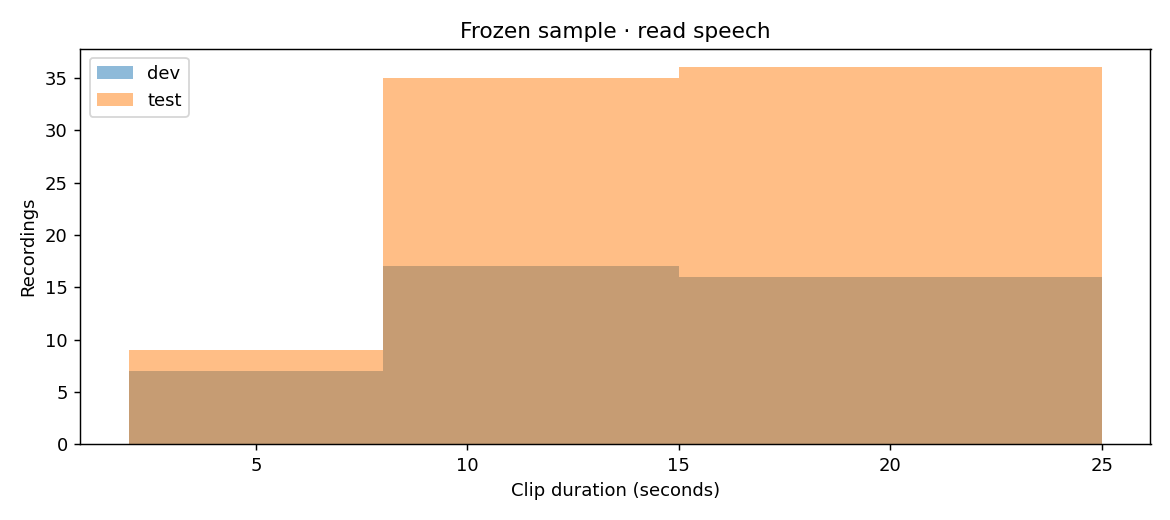

In [3]:
stage('prepare')
show_json('qualification.json')
picture('prepare.png')


In [4]:
corpus_rows = record('corpus.json')
dev_examples = [r for r in corpus_rows if r['role'] == 'dev'][:3]
for row in dev_examples:
    display(Markdown('**' + row['doc_id'] + '** — ' + row['reference']))
    display(Audio(filename=str(ROOT / row['path'])))


**fil-0c1a8429c9c00921** — Ang mga kilalang mang-aawit sa buong bansa ay naghandog ng bhajans, o mga banal na kanta, sa mga paa ng Shri Shyam.

**fil-0df8fae152961b7a** — Sinusubukan pa rin nilang alamin kung gaano talaga kalawak ang banggaan at kung paano maaapektuhan ang Earth.

**fil-0eec85083746457c** — Ang mga buwaya sa maalat na tubig ay hindi aktibong nananahan sa karagatan, ang kanilang pangunahing tirahan ay sa mga wawa ng ilog na nasa hilaga mula sa Rockhampton.

**What to notice:** duration bands are not speaker groups. The model sees recordings; retrieval later sees only their transcripts. The source text may itself contain unusual names or translation choices. Human review of query naturalness, reference/audio correspondence and full-corpus relevance is still pending. `annotation_review.csv` is a review aid, not completed evidence.


### 4. Transcribe and measure edits

Whisper transcribes Filipino/Tagalog using deterministic greedy decoding, without reference prompts or previous-clip context. Blank outputs remain in the experiment; a detected length-cap truncation is a failure.

**WER** counts word substitutions, deletions and insertions divided by reference words. **CER** does the same for characters, including normalized spaces. Corpus rates use summed edit counts and summed reference lengths. WER can exceed 100%; nothing is capped. Scoring applies NFC, lowercase, punctuation-to-space and whitespace collapse while preserving diacritics.


In [5]:
stage('asr')
show_csv('transcriptions.csv')
show_json('asr_timing.json')



Fetching 12 files: 100%|██████████| 12/12 [00:10<00:00,  1.10it/s]
`torch_dtype` is deprecated! Use `dtype` instead!
Transcribed 4/120
Transcribed 8/120
Transcribed 12/120
Transcribed 16/120
Transcribed 20/120
Transcribed 24/120
Transcribed 28/120
Transcribed 32/120
Transcribed 36/120
Transcribed 40/120
Transcribed 44/120
Transcribed 48/120
Transcribed 52/120
Transcribed 56/120
Transcribed 60/120
Transcribed 64/120
Transcribed 68/120
Transcribed 72/120
Transcribed 76/120
Transcribed 80/120
Transcribed 84/120
Transcribed 88/120
Transcribed 92/120
Transcribed 96/120
Transcribed 100/120
Transcribed 104/120
Transcribed 108/120
Transcribed 112/120
Transcribed 116/120
Transcribed 120/120
asr: PASS


doc_id,role,reference,hypothesis,empty_hypothesis
fil-027e061e5a9dffc2,test,"Tinatanggap ang mga pananaw ni Aristotle tungkol sa lahat ng usapin sa siyensya, kabilang ang sikolohiya.","Tinatanggap ang mga pananaw ni Aristotle tungkol sa lahat ng usapin sa siyensa, kabilang ang psikolohiya.",False
fil-044b100716ec2d2b,test,Ang aspect ratio ng pormat na ito (i-divide sa labindalawa upang makuha ang pinakasimpleng whole-number na ratio) sa makatuwid ay 3:2.,Ang aspect ratio ng format na ito sa mga ka-tweet ay 3s to 2.,False
fil-0a0ab810bfd25a30,test,"Matapos maitayo ang dam noong 1963, ang pana-panahong pagbaha na nagkakalat ng mga deposito sa buong ilog ay nahinto.","Matapos may tayo ang dam noong 1663, ang panapanahong pagbaha na nagkakalat ng mga deposito sa buong ilog ay nahinto.",False
fil-0acc50d2582cbc78,test,Sinalakay din nito ang anumang pumasok sa tubig; kahit na ang higanteng dinosauro gaya ng T. rex ay hindi mananaig dito.,Sinalakay din ito ang anumang pumasok sa tubig. Kahit na ang higanting dinasauro gaya ng P. rex ay hindi mananaig dito.,False
fil-0b24b1d224980b09,test,Kinansela ng Aerosmith ang mga nalalabi nilang konsyerto sa kanilang paglalakbay.,Kinansila ng Aerosmith ang mga nalalabi nilang konsyerto sa kanilang paglalakbay.,False
fil-0c1a8429c9c00921,dev,"Ang mga kilalang mang-aawit sa buong bansa ay naghandog ng bhajans, o mga banal na kanta, sa mga paa ng Shri Shyam.",Ang mga kilalang mga awit sa buong bansa ay naghandog ng badyans o mga banal na kanta sa mga paa ng shirisiam.,False
fil-0df8fae152961b7a,dev,Sinusubukan pa rin nilang alamin kung gaano talaga kalawak ang banggaan at kung paano maaapektuhan ang Earth.,Sinusubukan pa rin ng alamin kung gaana ka talaga kalawak ang banggaan at kung paano maapekto ka ng earth.,False
fil-0e11c0b26ee593d9,test,Ang Casablanca ay isa sa mga lugar sa buong Morocco na hindi kawili-wiling puntahan para mamili.,Ang Casablanca ay isa sa mga lugar sa buong Morocco na hindi ka wiliwiling puntahan para mamili.,False


Showing 8/120 rows. Full table: /content/dimer_fil_audio_preview/results/transcriptions.csv


**dev** — WER 0.140; CER 0.036. Word edits: {'errors': 125, 'substitutions': 94, 'deletions': 14, 'insertions': 17, 'reference_units': 895}; character edits: {'errors': 193, 'substitutions': 71, 'deletions': 82, 'insertions': 40, 'reference_units': 5387}

**test** — WER 0.136; CER 0.042. Word edits: {'errors': 251, 'substitutions': 191, 'deletions': 32, 'insertions': 28, 'reference_units': 1844}; character edits: {'errors': 462, 'substitutions': 161, 'deletions': 199, 'insertions': 102, 'reference_units': 11090}

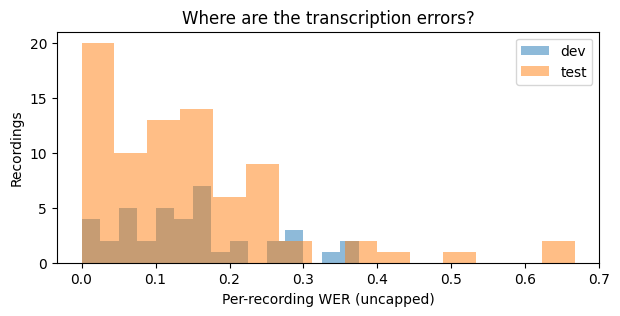

In [6]:
metrics = record('asr_metrics.json')
for role, values in metrics.items():
    display(Markdown(f"**{role}** — WER {values['wer']:.3f}; CER {values['cer']:.3f}. "
                     f"Word edits: {values['word']}; character edits: {values['character']}"))
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 3))
for role, values in metrics.items():
    ax.hist([r['wer'] for r in values['per_clip']], bins=15, alpha=0.5, label=role)
ax.set(xlabel='Per-recording WER (uncapped)', ylabel='Recordings', title='Where are the transcription errors?')
ax.legend(); plt.show()


In [7]:
import difflib, html
automatic = {r['doc_id']: r['text'] for r in record('asr_documents.json')}
for row in dev_examples:
    reference, hypothesis = row['reference'].split(), automatic[row['doc_id']].split()
    pieces = []
    for tag, i, j, k, l in difflib.SequenceMatcher(None, reference, hypothesis).get_opcodes():
        old, new = html.escape(' '.join(reference[i:j])), html.escape(' '.join(hypothesis[k:l]))
        pieces.append(old if tag == 'equal' else '<del>' + old + '</del> <mark>' + new + '</mark>')
    display(HTML('<strong>' + html.escape(row['doc_id']) + '</strong><p>' + ' '.join(pieces) + '</p>'))
print('Visual word diff only: strikethrough = removed/replaced reference; highlight = ASR addition/replacement.')
print('Scientific WER/CER above use the documented normalized Levenshtein alignment, not this display diff.')


Visual word diff only: strikethrough = removed/replaced reference; highlight = ASR addition/replacement.
Scientific WER/CER above use the documented normalized Levenshtein alignment, not this display diff.


**Interpret:** inspect substitutions involving names and numbers, and compare them with the words you predicted would matter. A correlation between WER and retrieval failure does not establish causation.

<details><summary>Worked interpretation</summary>An insertion-heavy hypothesis can have WER above 1. A blank hypothesis deletes all reference units. Neither case is silently removed. Search may still recover an imperfect transcript if the discriminating concept survives.</details>


### 5. Build lexical and semantic indexes

Each recording is one document. BM25 counts matching normalized words, with fixed `k1=1.2, b=0.75` and no stopword removal; each transcript condition fits its own statistics. Dense search compares normalized Qwen3 embeddings by exact cosine similarity. Ties use ascending document ID.

The reference and automatic indexes stay separate. Blank ASR documents retain their IDs. Query/document token ceilings are checked without silent truncation. Raw lexical, cosine and reranker scores are different ranking values, not comparable calibrated probabilities.


In [8]:
stage('index')
show_json('index_manifest.json')



Fetching 11 files: 100%|██████████| 11/11 [00:09<00:00,  1.12it/s]
`torch_dtype` is deprecated! Use `dtype` instead!
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
index: PASS


### 6. Compare the six systems

**Predict:** can a reranker rescue a recording absent from its ten dense candidates?

The experiment lock binds source, annotations, model identities, prompts and candidate depth. Evaluate the untouched query set only after this lock. In this preview, **anchor hit@5** asks whether the nominated draft target appears in the first five results; **anchor reciprocal rank@10** measures where that target appears in the first ten. They do not account for other potentially relevant recordings.

After complete human review, the graded branch reports Recall@5 over all grade-2 references, MRR@10 for the first grade-2 result and nDCG@10 with gains 0/1/3. Do not rename preview diagnostics to these metrics.


`torch_dtype` is deprecated! Use `dtype` instead!
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.

Fetching 13 files: 100%|██████████| 13/13 [00:11<00:00,  1.13it/s]
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
evaluate: PASS


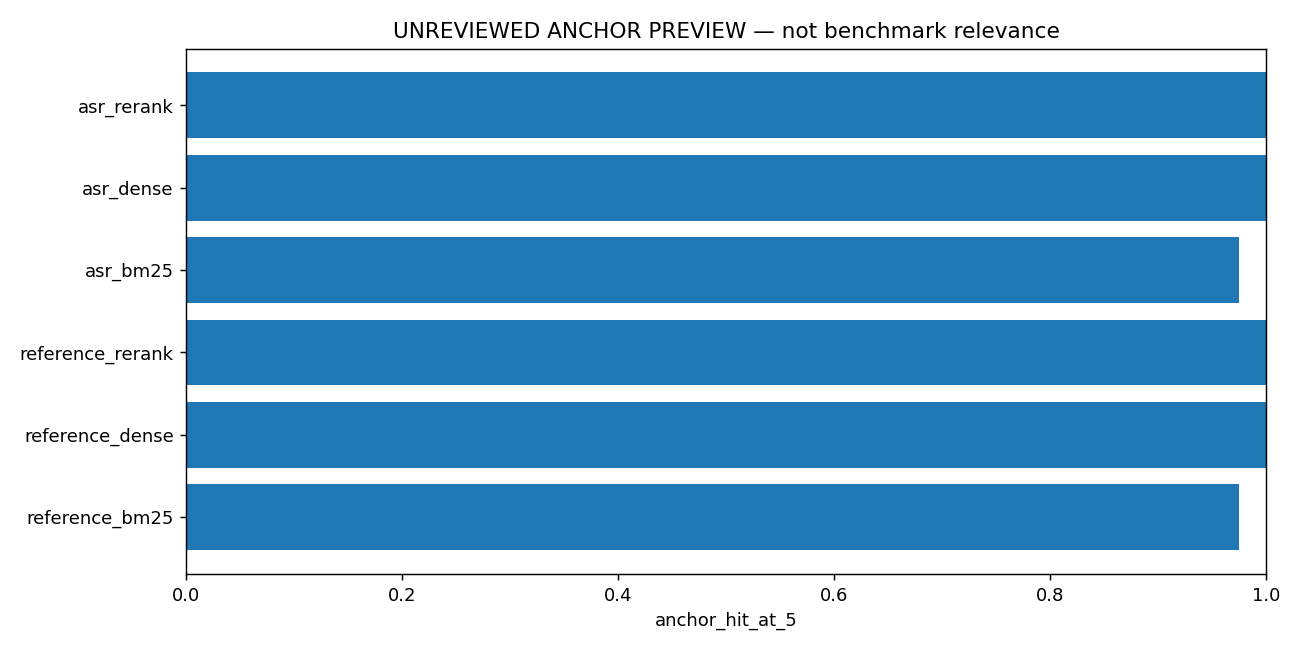

query_id,query,nominated_anchor,asr_dense_candidate_missing,asr_rerank_top5_missing,reference_rerank_top5_missing,annotation_status
test-01,Ano ang naging epekto sa Kanluran ng paghina ng kaalaman nito sa Griyego?,fil-d852e40b0ba16d01,False,False,False,unreviewed_anchor_only
test-02,Anu-anong mapaminsalang pangyayari ang binanggit bilang mga anyo o epekto ng matinding panahon?,fil-a22e88f4f0791d64,False,False,False,unreviewed_anchor_only
test-03,Ilang sunod na pagkatalo ang dinanas ng Springbooks?,fil-555099d59534da25,False,False,False,unreviewed_anchor_only
test-04,Aling mga insekto ang hindi kayang itiklop ang kanilang mga pakpak?,fil-aa7aa649ec95965f,False,False,False,unreviewed_anchor_only
test-05,Ilang miyembro ang bumubuo sa bagong CEP na nanumpa kay Martelly?,fil-f6a37952062b512e,False,False,False,unreviewed_anchor_only
test-06,Ano ang pinaniniwalaang sanhi ng pagbagsak na nangyari sa mataas na bulubunduking lugar?,fil-6b876371aae614f3,False,False,False,unreviewed_anchor_only
test-07,"Kaninong mga pananaw ang tinanggap sa iba't ibang larangan ng siyensya, pati sa sikolohiya?",fil-027e061e5a9dffc2,False,False,False,unreviewed_anchor_only
test-08,Paano pinagkaiba sa salaysay ang pangako ng eksperimental na bakuna sa Ebola at ang ebidensya para sa gamot sa umiiral na impeksyon?,fil-2d9eab69bd1f850c,False,False,False,unreviewed_anchor_only


Showing 8/40 rows. Full table: /content/dimer_fil_audio_preview/results/error_trace.csv


In [9]:
stage('evaluate')
show_json('retrieval_results.json')
picture('evaluate.png')
show_json('paired_comparisons.json')
show_csv('error_trace.csv')


In [10]:
draft_queries = json.loads((ROOT / 'queries.json').read_text(encoding='utf-8'))
ranked_runs = record('ranked_runs.json')
test_queries = [q for q in draft_queries if q['role'] == 'test']
failed = [q for q in test_queries if q['anchor_doc_id'] not in
          [r['doc_id'] for r in ranked_runs[q['query_id']]['asr_rerank'][:5]]]
example = (failed or test_queries)[0]
anchor = next(r for r in corpus_rows if r['doc_id'] == example['anchor_doc_id'])
display(Markdown('**Inspect a ' + ('missed' if failed else 'recovered') + ' draft anchor:** ' + example['text']))
display(Markdown('**Reference:** ' + anchor['reference']))
display(Markdown('**Whisper:** ' + automatic[anchor['doc_id']]))
display(Audio(filename=str(ROOT / anchor['path'])))
for name in ('reference_rerank', 'asr_dense', 'asr_rerank'):
    ids = [r['doc_id'] for r in ranked_runs[example['query_id']][name]]
    print(name, 'anchor rank:', ids.index(anchor['doc_id']) + 1 if anchor['doc_id'] in ids else 'absent',
          'top ten:', ids[:10])
print('An anchor miss is not proof that every returned recording is irrelevant; all qrels remain unjudged.')


**Inspect a recovered draft anchor:** Ano ang naging epekto sa Kanluran ng paghina ng kaalaman nito sa Griyego?

**Reference:** Sa nangyaring pagbaba ng kaalaman ng Griyego, nasumpungan ng Kanluran na nalayo na ito sa mga pinagmulan nitong pilisopiya at siyensiyang Griyego.

**Whisper:** Sa nangyaring pagbaba ng kaalaman ng Griego, nasumpungan ng kanluran na nalayo na ito sa mga pinagmula nitong filosofiya at siyensang Griego.

reference_rerank anchor rank: 1 top ten: ['fil-d852e40b0ba16d01', 'fil-baedb5085e878056', 'fil-cf85e87981b785bf', 'fil-d93f1de9ab243c25', 'fil-16f0138d81211918', 'fil-2d9eab69bd1f850c', 'fil-41b1db7990079a26', 'fil-12dc558141e0cbe9', 'fil-859035e1261a92c3', 'fil-29f34180216090a6']
asr_dense anchor rank: 1 top ten: ['fil-d852e40b0ba16d01', 'fil-29f34180216090a6', 'fil-cf85e87981b785bf', 'fil-baedb5085e878056', 'fil-41b1db7990079a26', 'fil-999ec61bd83d7079', 'fil-d93f1de9ab243c25', 'fil-859035e1261a92c3', 'fil-2d9eab69bd1f850c', 'fil-a22e88f4f0791d64']
asr_rerank anchor rank: 1 top ten: ['fil-d852e40b0ba16d01', 'fil-baedb5085e878056', 'fil-d93f1de9ab243c25', 'fil-999ec61bd83d7079', 'fil-859035e1261a92c3', 'fil-cf85e87981b785bf', 'fil-2d9eab69bd1f850c', 'fil-a22e88f4f0791d64', 'fil-41b1db7990079a26', 'fil-29f34180216090a6']
An anchor miss is not proof that every returned recording is irrelevant; all qrels remain unjudged.


In [11]:
# Competing evidence: what outranked the anchor? Automatic transcripts are what search saw.
PLAY_COMPETITORS = False  # set True to hear the top competing recordings
locations = {r['doc_id']: r for r in corpus_rows}

def rank_of(run, doc_id):
    ids = [r['doc_id'] for r in run]
    return ids.index(doc_id) + 1 if doc_id in ids else None

def candidate_table(query):
    runs, anchor_id = ranked_runs[query['query_id']], query['anchor_doc_id']
    dense = runs['asr_dense'][:10]
    rerank = {r['doc_id']: (i + 1, r['score']) for i, r in enumerate(runs['asr_rerank'])}
    rows = []
    for position, row in enumerate(dense, 1):
        rerank_rank, rerank_score = rerank.get(row['doc_id'], (None, None))
        rows.append([position, row['doc_id'] + (' ← anchor' if row['doc_id'] == anchor_id else ''),
                     f"{row['score']:.4f}", rerank_rank, '' if rerank_score is None else f'{rerank_score:.4f}',
                     automatic[row['doc_id']][:110]])
    if rank_of(dense, anchor_id) is None:
        full = rank_of(runs['asr_dense'], anchor_id)
        rows.append([full, anchor_id + ' ← anchor (outside candidates)', '', None, '', automatic[anchor_id][:110]])
    head = ['dense rank', 'doc_id', 'cosine', 'rerank rank', 'reranker score', 'Whisper transcript (excerpt)']
    cell = lambda v: '<td>' + html.escape('' if v is None else str(v)) + '</td>'
    display(HTML('<table><tr>' + ''.join('<th>' + h + '</th>' for h in head) + '</tr>'
                 + ''.join('<tr>' + ''.join(cell(v) for v in r) + '</tr>' for r in rows) + '</table>'))
    print('Scores are raw ranking values of different kinds (cosine vs reranker), not probabilities.')
    if PLAY_COMPETITORS:
        for row in runs['asr_rerank'][:2]:
            if row['doc_id'] != anchor_id:
                display(Markdown('Competitor **' + row['doc_id'] + '**'))
                display(Audio(filename=str(ROOT / locations[row['doc_id']]['path'])))

categories = {
    'Candidate miss (anchor not among the 10 dense candidates; reranking cannot recover it)':
        [q for q in test_queries if rank_of(ranked_runs[q['query_id']]['asr_dense'][:10], q['anchor_doc_id']) is None],
    'Reranker demotion (anchor among the candidates but ranked lower after reranking)':
        [q for q in test_queries
         if (d := rank_of(ranked_runs[q['query_id']]['asr_dense'][:10], q['anchor_doc_id'])) is not None
         and rank_of(ranked_runs[q['query_id']]['asr_rerank'], q['anchor_doc_id']) > d],
}
for label, cases in categories.items():
    display(Markdown(f'#### {label}: {len(cases)} of {len(test_queries)} evaluation queries'))
    if not cases:
        print('This category did not occur in this run.')
        continue
    display(Markdown('**Query:** ' + cases[0]['text'] + ' · **draft anchor:** ' + cases[0]['anchor_doc_id']))
    candidate_table(cases[0])
print('Competing recordings are unjudged, not negatives: a competitor may also be relevant.')


#### Candidate miss (anchor not among the 10 dense candidates; reranking cannot recover it): 0 of 40 evaluation queries

This category did not occur in this run.


#### Reranker demotion (anchor among the candidates but ranked lower after reranking): 0 of 40 evaluation queries

This category did not occur in this run.
Competing recordings are unjudged, not negatives: a competitor may also be relevant.


**What to notice:** primary paired differences compare automatic versus reference transcripts under the same method. Rerank-minus-dense isolates the reranking stage; dense-minus-BM25 compares semantic and lexical search. Uncertainty resamples entire target-family query groups, 2,000 times with seed 42. Small curated drafts do not represent real user traffic.

Trace a missed target through its source audio → reference → Whisper transcript → dense candidates → reranked list. A missing candidate cannot be rescued by reranking. A present candidate can be demoted. Good transcription does not guarantee search success. Log potential annotation issues for a new version and complete rerun; do not edit labels after seeing results.

<details><summary>Worked answer</summary>A reranker only reorders the candidates supplied to it. If the target is absent, improving its pairwise scoring cannot recover that target. Increasing candidate depth changes that constraint, but may increase latency.</details>


### 7. Change one thing — development candidate depth

**Predict → run → observe → explain:** increase candidate depth from **10 to 20** on development queries only. Keep models, corpus, prompts and labels fixed. Canonical evaluation files remain unchanged. Compare anchor recovery and measured latency; after label qualification, compare graded relevance too. More candidates do not guarantee improvement.

**Fair cost comparison:** the canonical run reranked 60 queries and this activity reranks 20, so their raw durations measure different workloads. The activity therefore times depth 10 and depth 20 on the **same 20 development queries**, in the same process with the reranker already loaded, alternating which depth runs first. Depth changes only reranking, so query embedding and dense search are excluded from both columns.


In [12]:
stage('activity')
show_json('activity_summary.json')
show_csv('activity_results.csv')
show_csv('activity_candidates.csv')
print('Compare against development scores above; evaluation configuration remains depth 10.')


`torch_dtype` is deprecated! Use `dtype` instead!
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
activity: PASS


query_id,group,role,system,anchor_hit_at_5,anchor_reciprocal_rank_at_10
dev-01,family-5adaee1bac01d17f,dev,reference_bm25,1.0,1.0
dev-01,family-5adaee1bac01d17f,dev,reference_dense,1.0,1.0
dev-01,family-5adaee1bac01d17f,dev,reference_rerank,1.0,1.0
dev-01,family-5adaee1bac01d17f,dev,asr_bm25,1.0,1.0
dev-01,family-5adaee1bac01d17f,dev,asr_dense,1.0,1.0
dev-01,family-5adaee1bac01d17f,dev,asr_rerank,1.0,1.0
dev-02,family-ed13d9df0c8e3035,dev,reference_bm25,1.0,1.0
dev-02,family-ed13d9df0c8e3035,dev,reference_dense,1.0,1.0


Showing 8/120 rows. Full table: /content/dimer_fil_audio_preview/results/activity_results.csv


query_id,condition,candidate_depth,measure,value,denominator,provisional
dev-01,reference,10,nominated_anchor_candidate_hit,1.0,1,True
dev-01,reference,20,nominated_anchor_candidate_hit,1.0,1,True
dev-01,asr,10,nominated_anchor_candidate_hit,1.0,1,True
dev-01,asr,20,nominated_anchor_candidate_hit,1.0,1,True
dev-02,reference,10,nominated_anchor_candidate_hit,1.0,1,True
dev-02,reference,20,nominated_anchor_candidate_hit,1.0,1,True
dev-02,asr,10,nominated_anchor_candidate_hit,1.0,1,True
dev-02,asr,20,nominated_anchor_candidate_hit,1.0,1,True


Showing 8/80 rows. Full table: /content/dimer_fil_audio_preview/results/activity_candidates.csv
Compare against development scores above; evaluation configuration remains depth 10.


In [13]:
import csv
summary = record('activity_summary.json')
with (RESULTS / 'activity_candidates.csv').open(encoding='utf-8', newline='') as handle:
    candidate_rows = list(csv.DictReader(handle))
rows = []
for condition in ('reference', 'asr'):
    paired = summary['paired_latency'][condition]
    quality = {}
    for depth in (10, 20):
        values = [float(r['value']) for r in candidate_rows
                  if r['condition'] == condition and int(r['candidate_depth']) == depth]
        assert [r['query_id'] for r in candidate_rows if r['condition'] == condition
                and int(r['candidate_depth']) == depth] == paired['query_ids'], 'query cohorts differ'
        quality[depth] = sum(values) / len(values)
    rows.append([condition, paired['queries'], f"{quality[10]:.3f}", f"{quality[20]:.3f}",
                 paired['depth10_pairs'], paired['depth20_pairs'],
                 f"{paired['depth10_mean_seconds_per_query']:.4f}", f"{paired['depth20_mean_seconds_per_query']:.4f}"])
head = ['transcripts', 'same dev queries', 'anchor in candidates @10', 'anchor in candidates @20',
        'reranked pairs @10', 'reranked pairs @20', 'rerank s/query @10', 'rerank s/query @20']
display(HTML('<table><tr>' + ''.join('<th>' + h + '</th>' for h in head) + '</tr>' + ''.join(
    '<tr>' + ''.join('<td>' + html.escape(str(v)) + '</td>' for v in r) + '</tr>' for r in rows) + '</table>'))
print(summary['paired_latency']['conditions'])
print('Per-query timings:', RESULTS / 'activity_latency.csv')


transcripts,same dev queries,anchor in candidates @10,anchor in candidates @20,reranked pairs @10,reranked pairs @20,rerank s/query @10,rerank s/query @20
reference,20,1.000,1.000,200,400,0.5713,1.0383
asr,20,0.950,0.950,200,400,0.5513,1.1024


Same development queries, same process and loaded reranker; one untimed warm-up call; depth order alternates per query; excludes model load, query embedding and dense search, which depth does not change. Wall-clock timing of one run, not a benchmark.
Per-query timings: /content/dimer_fil_audio_preview/results/activity_latency.csv


### 8. Reconstruct in a fresh process

Reload the automatic-transcript artifact, verify hashes and dimensions, replay fixed queries, re-embed a document subset and retranscribe three frozen clips. Ranked IDs must match, with declared score tolerance `atol=1e-5, rtol=1e-4`. A mismatch stops the run; tolerances are not silently loosened. This verifies reconstruction beyond reading cached results.


In [14]:
stage('reload')
show_json('verification.json')


`torch_dtype` is deprecated! Use `dtype` instead!
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
You're using a Qwen2TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
`torch_dtype` is deprecated! Use `dtype` instead!
reload: PASS


### 9. Export evidence and conclude

The automatic-transcript search artifact is separate from evaluation references and qrels. Numeric arrays use safe NumPy formats. The default ZIP excludes source audio and model weights, retaining source IDs, checksums and reacquisition information. Playback uses the validated local corpus, not stale exported Colab paths.

**Optional reflection:** What evidence changed your prediction? Which failure entered at transcription, candidate generation or reranking? What cannot be concluded while relevance labels are unreviewed? Would your conclusion transfer to noisy conversations? Record measured results and limitations rather than declaring a winning model in advance.


In [15]:
stage('report')
show_json('run_summary.json')
print('Evidence bundle:', RESULTS / 'results.zip')
DOWNLOAD_RESULTS = False
if DOWNLOAD_RESULTS:
    from google.colab import files
    files.download(str(RESULTS / 'results.zip'))


report: PASS


Evidence bundle: /content/dimer_fil_audio_preview/results/results.zip


### 10. Optional free-form search

Set `RUN_SEARCH=True` and enter a Filipino query. This uses automatic transcripts only. Results have no benchmark score because your new query has no reviewed relevance labels. Listen to the returned recordings and judge the evidence yourself.

The same search view serves the default archive and a BYOD archive (§11): each search package is verified (hashes, model identity and settings) before it is queried, and a recording plays only when its local file matches the SHA256 recorded in the package.


In [16]:
def show_search(query, index_dir=None, audio_base=ROOT):
    """Search a verified package and show top-five transcript evidence with hash-checked playback."""
    args = [PY, ROOT / 'audio_runtime.py', '--root', ROOT, '--query', query]
    if index_dir is not None:
        args += ['--index', index_dir]
    command(args, 'interactive-search.log')
    response = json.loads((ROOT / 'interactive_search.json').read_text(encoding='utf-8'))
    display(Markdown(f"**Query:** {response['query']} · **archive:** `{response['source']}` · "
                     'unscored: no reviewed relevance labels exist for a new query'))
    for rank, row in enumerate(response['results'], 1):
        display(Markdown(f"**{rank}. {row['doc_id']}** (reranker score {row['score']:.4f}) — {row['transcript']}"))
        audio_path = (Path(audio_base) / row['audio_path']).resolve()
        if audio_path.is_file() and hashlib.sha256(audio_path.read_bytes()).hexdigest() == row['audio_sha256']:
            display(Audio(filename=str(audio_path)))
        else:
            print('   audio unavailable or changed; supply/reacquire it via audio_acquisition.json')

RUN_SEARCH = False
SEARCH_QUERY = 'Ano ang epekto ng matinding panahon?'
if RUN_SEARCH:
    show_search(SEARCH_QUERY)


### 11. Optional bring-your-own recordings

Disabled by default; no microphone or upload dialog opens during Run all. Use recordings you have rights and consent to process. Prepare a local JSON manifest with `rights_confirmed: true`, nonempty `source_notes`, optional `probe_query`, and `records` containing stable `doc_id`, safe relative `path`, and optional nonempty `reference`. Example: `{"rights_confirmed": true, "source_notes": "My consented recording", "records": [{"doc_id": "clip_01", "path": "clip_01.wav"}]}`.

WAV/FLAC inputs are bounded to 1–120 clips, 4 MB each and the same audio eligibility checks. The BYOD build transcribes and embeds your recordings once, then exports a search package in **the same format as the default archive**, with the same `search_archive.py` consumer. A fresh process then re-embeds, replays a probe query and retranscribes up to three clips against your original audio.

Each build gets its own folder under `byod/`; the default index is never touched:
- `search/` and `search_index.zip`: the portable automatic-transcript package (transcripts, embeddings, audio identities, consumer, lock, `RECONSTRUCT.md`). It contains no references or evaluation records.
- `evaluation.json`: kept separate. WER/CER require references; retrieval metrics require reviewed labels. Missing evidence is reported as **not measurable**, never zero error.
- `verification.json`: the fresh-process reconstruction check.

BYOD needs separate hosted verification.


In [17]:
RUN_BYOD = False
BYOD_MANIFEST = ROOT / 'my_audio/manifest.json'
DOWNLOAD_BYOD = False
if RUN_BYOD:
    command([PY, ROOT / 'audio_byod.py', '--root', ROOT, '--manifest', BYOD_MANIFEST], 'byod.log')
    BYOD = json.loads((ROOT / 'byod/latest.json').read_text(encoding='utf-8'))
    evaluation = json.loads(Path(BYOD['evaluation']).read_text(encoding='utf-8'))
    display(Markdown(
        f"**BYOD archive built:** {evaluation['recordings']} recordings; references supplied for "
        f"{evaluation['reference_count']} of {evaluation['recordings']}. ASR: `{evaluation['asr_status']}`; "
        f"retrieval: `{evaluation['retrieval_status']}`."))
    if evaluation['asr']:
        print(f"WER {evaluation['asr']['wer']:.3f}, CER {evaluation['asr']['cer']:.3f} "
              f"on the {evaluation['reference_count']} referenced recordings only")
    for label, key in (('Search package', 'search_dir'), ('Portable ZIP', 'search_index_zip'),
                       ('Evaluation (separate)', 'evaluation'), ('Reconstruction check', 'verification')):
        print(f'{label}: {BYOD[key]}')
    if DOWNLOAD_BYOD:
        from google.colab import files
        files.download(BYOD['search_index_zip'])
else:
    print('BYOD disabled (RUN_BYOD = False).')


BYOD disabled (RUN_BYOD = False).


**Query your archive.** Change `BYOD_QUERY` and re-run only the next cell as often as you like: it searches the saved BYOD package without re-transcribing, and plays only your own recordings. To reuse the archive in a later session, keep `search_index.zip` and follow its `RECONSTRUCT.md`, or upload it with your audio and point `show_search` at the extracted folder.


In [18]:
BYOD_QUERY = ''
if 'BYOD' in globals() and BYOD_QUERY.strip():
    show_search(BYOD_QUERY, BYOD['search_dir'], Path(BYOD['audio_base']))
elif 'BYOD' in globals():
    print('Enter a BYOD_QUERY and re-run this cell to search your archive.')
else:
    print('No BYOD archive in this session; enable RUN_BYOD above first.')


No BYOD archive in this session; enable RUN_BYOD above first.


### AI Assistance Disclosure

Code, instructional text and initial query drafts were developed with generative AI assistance under maintainer direction. Draft annotations are explicitly distinguished from completed human review. The maintainer remains responsible for reviewing implementation, validating results and release decisions. AI assistance is not independent verification, provider endorsement or release approval.

**Current scope:** read-speech engineering preview; no speaker identification, translation, generated answers, weight training or production archive claim. Hosted execution and human relevance qualification remain separate evidence gates.
